# 2026-06-08 FA 요인분석

산불 발생 사례만 사용해 요인분석 입력 데이터를 준비한다.


# 데이터 준비

`jsw/강원_EDA/README.md`의 결합 방식을 따라 산불 발생 1건을 1행으로 두고, 날씨·지형·접근성 후보 변수를 만든다.


## 0. 환경 설정

In [63]:
from pathlib import Path
import gc
import math
import time
import warnings

import geopandas as gpd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from shapely import wkt
from shapely.strtree import STRtree
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

warnings.filterwarnings("ignore")

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print

    def Markdown(text):
        return text


font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
    if (candidate / "data").exists() and (candidate / "jsw").exists():
        ROOT = candidate
        break

WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
FIRE_DIR = ROOT / "data" / "강원도_데이터"
SPATIAL_DIR = FIRE_DIR / "강원도_공간데이터"
FIRE_SPATIAL_DIR = FIRE_DIR / "산불_공간데이터"

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
ADDR_ORDER = ["임야번지(산)", "일반번지"]
CAUSE_ORDER = ["입산활동 발화 후보", "기타 인간활동 발화 후보"]
RANDOM_STATE = 20260608

print("ROOT:", ROOT)
print("matplotlib font:", plt.rcParams["font.family"])


현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']
ROOT: d:\farm-system-public-02
matplotlib font: ['Malgun Gothic']


## 1. 공통 함수

In [11]:
def read_gpkg(path, columns=None):
    """pyogrio가 가능하면 사용하고, 아니면 geopandas 기본 엔진으로 읽는다."""
    try:
        return gpd.read_file(path, engine="pyogrio", columns=columns)
    except Exception:
        return gpd.read_file(path, columns=columns)


def valid_summary(df, columns):
    rows = []
    for col in columns:
        exists = col in df.columns
        rows.append({
            "변수": col,
            "전체행": len(df),
            "유효표본수": int(df[col].notna().sum()) if exists else 0,
            "결측수": int(df[col].isna().sum()) if exists else len(df),
            "결측률_pct": round(float(df[col].isna().mean() * 100), 2) if exists else 100.0,
        })
    return pd.DataFrame(rows)


def build_spatial_index(geoms):
    geom_arr = np.asarray(pd.Series(geoms).dropna().values, dtype=object)
    return geom_arr, STRtree(geom_arr)


def nearest_distance_from_index(points_gdf, geom_arr, tree, label):
    if len(geom_arr) == 0:
        return [np.nan] * len(points_gdf)
    out = []
    for pt in np.asarray(points_gdf.geometry.values, dtype=object):
        nearest = tree.nearest(pt)
        geom = geom_arr[int(nearest)] if isinstance(nearest, (int, np.integer)) else nearest
        out.append(pt.distance(geom))
    print(f"- {label} 최단거리 완료")
    return out


def add_rolling_weather(hourly):
    """현재 발생시각은 제외하고 직전 24/48/72시간 rolling 기상값을 만든다."""
    hourly = hourly.sort_values(["기상셀ID", "일시"]).reset_index(drop=True)
    shifted = hourly.groupby("기상셀ID", sort=False)[["풍속_m_s", "습도_pct", "강수량_mm"]].shift(1)
    grouped = shifted.groupby(hourly["기상셀ID"], sort=False)
    for window in [24, 48, 72]:
        hourly[f"직전{window}h_평균풍속"] = (
            grouped["풍속_m_s"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_최소습도"] = (
            grouped["습도_pct"].rolling(window, min_periods=1).min().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_강수량합"] = (
            grouped["강수량_mm"].rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
        )
    return hourly


## 2. 산불 기본정보, 기상셀, 기후지형유형, 지형 결합

In [12]:
t0 = time.time()

fire = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson").to_crs("EPSG:4326")
climate_type = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
topo = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_산불_지형특성계산.csv", encoding="utf-8-sig")

fire["발생일시"] = pd.to_datetime(
    dict(year=fire["연도"], month=fire["월"], day=fire["일"]),
    errors="coerce",
) + pd.to_timedelta(fire["시간"].fillna(0).astype(int), unit="h")
fire["날짜"] = fire["발생일시"].dt.floor("D")
fire["월_key"] = fire["발생일시"].dt.month
fire["시간_key"] = fire["발생일시"].dt.hour
fire["산불위험계절"] = np.where(
    fire["월_key"].isin([11, 12, 1, 2, 3, 4, 5]),
    "산불위험계절(11~5월)",
    "기타계절",
)
fire["addr_type"] = np.where(
    fire["발생지역번지"].fillna("").astype(str).str.strip().str.startswith("산"),
    "임야번지(산)",
    "일반번지",
)
fire["발생시간대구분"] = pd.cut(
    fire["시간_key"],
    bins=[-0.1, 5, 9, 13, 17, 23],
    labels=["야간(0~5시)", "아침(6~9시)", "한낮(10~13시)", "오후(14~17시)", "저녁(18~23시)"],
)

fire_gdf = gpd.GeoDataFrame(
    fire,
    geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
    crs="EPSG:4326",
)
fire_cells = gpd.sjoin(
    fire_gdf,
    grid[["기상셀ID", "기후권역", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])

unmatched_ids = fire_cells.loc[fire_cells["기상셀ID"].isna(), "fire_id"].tolist()
fire_cells = fire_cells[fire_cells["기상셀ID"].notna()].drop(columns=["geometry"]).copy()
fire_cells = fire_cells.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")

fire_core = fire_cells.merge(topo.drop(columns=["위도", "경도"]), on="fire_id", how="left")
fire_core.loc[fire_core["TWI(지형다습지수)"] > 1e8, "TWI(지형다습지수)"] = np.nan
fire_core["사면방향_deg"] = (
    np.degrees(np.arctan2(fire_core["사면방향_sin"], fire_core["사면방향_cos"])) + 360
) % 360

for col in ["기후지형유형", "addr_type"]:
    if col == "기후지형유형":
        fire_core[col] = pd.Categorical(fire_core[col], categories=TYPE_ORDER, ordered=True)
    else:
        fire_core[col] = pd.Categorical(fire_core[col], categories=ADDR_ORDER, ordered=True)

print(f"산불 원자료: {len(fire):,}건")
print(f"기상셀 매칭 후: {len(fire_core):,}건")
print(f"미매칭 제외 fire_id: {unmatched_ids}")

del topo, fire_gdf, fire_cells
gc.collect()


산불 원자료: 3,405건
기상셀 매칭 후: 3,401건
미매칭 제외 fire_id: ['F_006690', 'F_009678', 'F_010665', 'F_010893']


5

## 3. 토지피복과 접근성 최단거리 결합

In [13]:
land = read_gpkg(
    SPATIAL_DIR / "강원도_토지피복도_세분류_병합_1m.gpkg",
    columns=["L1_NAME", "L2_NAME"],
)
land["L1_NAME"] = land["L1_NAME"].fillna("미분류")
land["L2_NAME"] = land["L2_NAME"].fillna("미분류")

fire_points = gpd.GeoDataFrame(
    fire_core,
    geometry=gpd.points_from_xy(fire_core["경도"], fire_core["위도"]),
    crs="EPSG:4326",
).to_crs(land.crs)

fire_lc = gpd.sjoin(
    fire_points,
    land[["L1_NAME", "L2_NAME", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"])
fire_lc = fire_lc.drop_duplicates(subset="fire_id").reset_index(drop=True)
fire_lc["L1_NAME"] = fire_lc["L1_NAME"].fillna("미분류")
fire_lc["L2_NAME"] = fire_lc["L2_NAME"].fillna("미분류")

road = read_gpkg(SPATIAL_DIR / "강원도_병합_도로.gpkg", columns=[]).to_crs(land.crs)
trail_df = pd.read_csv(SPATIAL_DIR / "강원도_등산로.csv", encoding="utf-8-sig")
trail = gpd.GeoDataFrame(trail_df, geometry=trail_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)
imdo_df = pd.read_csv(SPATIAL_DIR / "강원도_임도망도.csv", encoding="utf-8-sig")
imdo = gpd.GeoDataFrame(imdo_df, geometry=imdo_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)

target_indices = {
    "도로": build_spatial_index(road.geometry),
    "임도": build_spatial_index(imdo.geometry),
    "등산로": build_spatial_index(trail.geometry),
    "산림지역": build_spatial_index(land.loc[land["L1_NAME"].eq("산림지역"), "geometry"]),
    "시가화건조지역": build_spatial_index(land.loc[land["L1_NAME"].eq("시가화건조지역"), "geometry"]),
    "농업지역": build_spatial_index(land.loc[land["L1_NAME"].eq("농업지역"), "geometry"]),
}

distance_specs = [
    ("도로", "도로_최단거리_m"),
    ("임도", "임도_최단거리_m"),
    ("등산로", "등산로_최단거리_m"),
    ("산림지역", "산림_최단거리_m"),
    ("시가화건조지역", "시가화_최단거리_m"),
    ("농업지역", "농업_최단거리_m"),
]
for label, col in distance_specs:
    geom_arr, tree = target_indices[label]
    fire_lc[col] = nearest_distance_from_index(fire_lc, geom_arr, tree, label)
    fire_lc[f"log1p_{col}"] = np.log1p(fire_lc[col])

fire_lc["생활권프록시"] = np.where(
    (fire_lc["도로_최단거리_m"] <= 30)
    | (fire_lc["시가화_최단거리_m"] <= 100)
    | (fire_lc["농업_최단거리_m"] <= 100),
    "도로/시가화/농업 인접",
    "비인접",
)
fire_lc["원인프록시_500m"] = np.where(
    (fire_lc["등산로_최단거리_m"] <= 500) | (fire_lc["임도_최단거리_m"] <= 500),
    "입산활동 발화 후보",
    "기타 인간활동 발화 후보",
)
fire_lc["원인프록시_500m"] = pd.Categorical(fire_lc["원인프록시_500m"], categories=CAUSE_ORDER, ordered=True)
fire_lc["기후지형_번지유형"] = (
    fire_lc["기후지형유형"].astype(str) + " / " + fire_lc["addr_type"].astype(str)
)

del fire_core, fire_points, road
gc.collect()

print("토지피복/접근성 결합 완료")


- 도로 최단거리 완료
- 임도 최단거리 완료
- 등산로 최단거리 완료
- 산림지역 최단거리 완료
- 시가화건조지역 최단거리 완료
- 농업지역 최단거리 완료
토지피복/접근성 결합 완료


## 4. 발생시각·선행 날씨 결합

In [14]:
daily = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_일단위.csv", encoding="utf-8-sig")
hourly = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")

daily["날짜"] = pd.to_datetime(daily["날짜"])
hourly["일시"] = pd.to_datetime(hourly["일시"])
hourly["날짜"] = hourly["일시"].dt.floor("D")
hourly["월_key"] = hourly["일시"].dt.month.astype("int8")
hourly["시간_key"] = hourly["일시"].dt.hour.astype("int8")
hourly = add_rolling_weather(hourly)

hourly_day = (
    hourly.groupby(["기상셀ID", "날짜"], as_index=False)
    .agg(
        최소습도_pct=("습도_pct", "min"),
        강수량합_mm=("강수량_mm", "sum"),
    )
)

hourly_features = hourly[
    [
        "기상셀ID", "일시", "날짜", "월_key", "시간_key",
        "풍속_m_s", "강수량_mm", "습도_pct",
        "직전24h_평균풍속", "직전24h_최소습도", "직전24h_강수량합",
        "직전48h_평균풍속", "직전48h_최소습도", "직전48h_강수량합",
        "직전72h_평균풍속", "직전72h_최소습도", "직전72h_강수량합",
    ]
].copy()
hourly_features = hourly_features.rename(
    columns={
        "풍속_m_s": "시점_풍속_m_s",
        "강수량_mm": "시점_강수량_mm",
        "습도_pct": "시점_습도_pct",
    }
)

daily_features = daily.rename(columns={"최대순간풍속_m_s": "당일_최대순간풍속_m_s"})
hourly_features = hourly_features.merge(
    daily_features[["기상셀ID", "날짜", "당일_최대순간풍속_m_s"]],
    on=["기상셀ID", "날짜"],
    how="left",
)

for lag in [1, 2, 3]:
    lag_df = hourly_day.copy()
    lag_df["날짜"] = lag_df["날짜"] + pd.Timedelta(days=lag)
    lag_df = lag_df.rename(
        columns={
            "최소습도_pct": f"D-{lag}_최소습도_pct",
            "강수량합_mm": f"D-{lag}_강수량합_mm",
        }
    )
    hourly_features = hourly_features.merge(lag_df, on=["기상셀ID", "날짜"], how="left")

float_cols = hourly_features.select_dtypes(include=["float64"]).columns
hourly_features[float_cols] = hourly_features[float_cols].astype("float32")

fire_lc = fire_lc.merge(
    hourly_features.rename(columns={"일시": "발생일시"}),
    on=["기상셀ID", "발생일시"],
    how="left",
    suffixes=("", "_weather"),
)

del daily, hourly, hourly_day, daily_features
gc.collect()

print(f"날씨 결합 완료: {time.time() - t0:.1f}초")
display(
    valid_summary(
        fire_lc,
        [
            "시점_습도_pct", "시점_풍속_m_s", "시점_강수량_mm",
            "직전24h_최소습도", "직전48h_최소습도", "직전72h_최소습도",
            "직전24h_평균풍속", "직전48h_평균풍속", "직전72h_평균풍속",
            "D-1_최소습도_pct", "D-2_최소습도_pct", "D-3_최소습도_pct",
            "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)",
            "도로_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
        ],
    )
)


날씨 결합 완료: 67.8초


,변수,전체행,유효표본수,결측수,결측률_pct
0,시점_습도_pct,3401,3401,0,0.00
1,시점_풍속_m_s,3401,3401,0,0.00
2,시점_강수량_mm,3401,3401,0,0.00
3,직전24h_최소습도,3401,3401,0,0.00
4,직전48h_최소습도,3401,3401,0,0.00
5,직전72h_최소습도,3401,3401,0,0.00
6,직전24h_평균풍속,3401,3401,0,0.00
7,직전48h_평균풍속,3401,3401,0,0.00
8,직전72h_평균풍속,3401,3401,0,0.00
9,D-1_최소습도_pct,3401,3399,2,0.06


## 5. FA 후보 데이터셋 구성

In [15]:
META_COLS = [
    "fire_id", "발생일시", "기상셀ID", "기후권역", "기후지형유형",
    "addr_type", "기후지형_번지유형", "월_key", "시간_key", "산불위험계절",
    "발생시간대구분", "L1_NAME", "L2_NAME",
    "생활권프록시", "원인프록시_500m",
]

WEATHER_FEATURE_COLS = [
    "시점_습도_pct", "시점_풍속_m_s", "시점_강수량_mm",
    "직전24h_최소습도", "직전48h_최소습도", "직전72h_최소습도",
    "직전24h_평균풍속", "직전48h_평균풍속", "직전72h_평균풍속",
    "직전24h_강수량합", "직전48h_강수량합", "직전72h_강수량합",
    "D-1_최소습도_pct", "D-2_최소습도_pct", "D-3_최소습도_pct",
    "D-1_강수량합_mm", "D-2_강수량합_mm", "D-3_강수량합_mm",
    "당일_최대순간풍속_m_s",
]

TOPO_FEATURE_COLS = [
    "고도(m)", "경사도(도)", "사면방향_sin", "사면방향_cos",
    "TPI(지형위치지수)", "TWI(지형다습지수)",
]

ACCESS_FEATURE_COLS = [
    "log1p_도로_최단거리_m", "log1p_임도_최단거리_m", "log1p_등산로_최단거리_m",
    "log1p_산림_최단거리_m", "log1p_시가화_최단거리_m", "log1p_농업_최단거리_m",
]

FA_FEATURE_COLS = WEATHER_FEATURE_COLS + TOPO_FEATURE_COLS + ACCESS_FEATURE_COLS
available_feature_cols = [col for col in FA_FEATURE_COLS if col in fire_lc.columns]
missing_feature_cols = [col for col in FA_FEATURE_COLS if col not in fire_lc.columns]

fa_source = fire_lc[META_COLS + available_feature_cols].copy()
for col in available_feature_cols:
    fa_source[col] = pd.to_numeric(fa_source[col], errors="coerce")

fa_X_raw = fa_source[available_feature_cols].copy()
fa_X_complete = fa_X_raw.dropna(axis=0, how="any").copy()
fa_meta_complete = fa_source.loc[fa_X_complete.index, META_COLS].copy()

summary = pd.DataFrame(
    {
        "항목": [
            "원 산불",
            "기상셀 매칭 산불",
            "FA 후보 변수 수",
            "FA 완전케이스 행 수",
            "누락 후보 변수 수",
        ],
        "값": [
            len(fire),
            len(fire_lc),
            len(available_feature_cols),
            len(fa_X_complete),
            len(missing_feature_cols),
        ],
    }
)

display(summary)
display(Markdown("### FA 후보 변수 결측 요약"))
display(valid_summary(fa_source, available_feature_cols).sort_values("결측률_pct", ascending=False))

if missing_feature_cols:
    print("누락된 후보 변수:", missing_feature_cols)

print("생성 객체:")
print("- fire_lc: EDA 방식 결합 완료 원본 테이블")
print("- fa_source: 메타 컬럼 + FA 후보 변수")
print("- fa_X_raw: FA 후보 변수 원자료")
print("- fa_X_complete: 결측 없는 FA 입력 후보")

,항목,값
0,원 산불,3405
1,기상셀 매칭 산불,3401
2,FA 후보 변수 수,31
3,FA 완전케이스 행 수,2670
4,누락 후보 변수 수,0


### FA 후보 변수 결측 요약

,변수,전체행,유효표본수,결측수,결측률_pct
24,TWI(지형다습지수),3401,2676,725,21.32
17,D-3_강수량합_mm,3401,3395,6,0.18
14,D-3_최소습도_pct,3401,3395,6,0.18
15,D-1_강수량합_mm,3401,3399,2,0.06
16,D-2_강수량합_mm,3401,3399,2,0.06
12,D-1_최소습도_pct,3401,3399,2,0.06
13,D-2_최소습도_pct,3401,3399,2,0.06
6,직전24h_평균풍속,3401,3401,0,0.00
5,직전72h_최소습도,3401,3401,0,0.00
4,직전48h_최소습도,3401,3401,0,0.00


생성 객체:
- fire_lc: EDA 방식 결합 완료 원본 테이블
- fa_source: 메타 컬럼 + FA 후보 변수
- fa_X_raw: FA 후보 변수 원자료
- fa_X_complete: 결측 없는 FA 입력 후보


# FA

여기서부터 `fa_X_complete`를 기준으로 요인분석을 진행한다.


## 요인분석적합성 점검

`fa_X_complete`를 기준으로 요인분석에 들어가기 전 변수 간 상관구조, KMO, Bartlett 구형성 검정을 확인한다.


### 상관행렬 확인

,항목,값
0,FA 적합성 점검 표본 수,2670
1,FA 적합성 점검 변수 수,31
2,상수/단일값 제거 변수 수,0


#### 절대상관계수 상위 변수쌍

,변수1,변수2,abs_corr,corr
0,직전48h_최소습도,직전72h_최소습도,0.9518,0.9518
1,직전48h_평균풍속,직전72h_평균풍속,0.9485,0.9485
2,직전24h_평균풍속,직전48h_평균풍속,0.9359,0.9359
3,직전48h_강수량합,D-1_강수량합_mm,0.9350,0.9350
4,직전24h_강수량합,직전48h_강수량합,0.9172,0.9172
5,직전24h_최소습도,직전48h_최소습도,0.8984,0.8984
6,log1p_도로_최단거리_m,log1p_시가화_최단거리_m,0.8842,0.8842
7,직전24h_강수량합,D-1_강수량합_mm,0.8822,0.8822
8,직전24h_평균풍속,직전72h_평균풍속,0.8655,0.8655
9,직전24h_최소습도,D-1_최소습도_pct,0.8509,0.8509


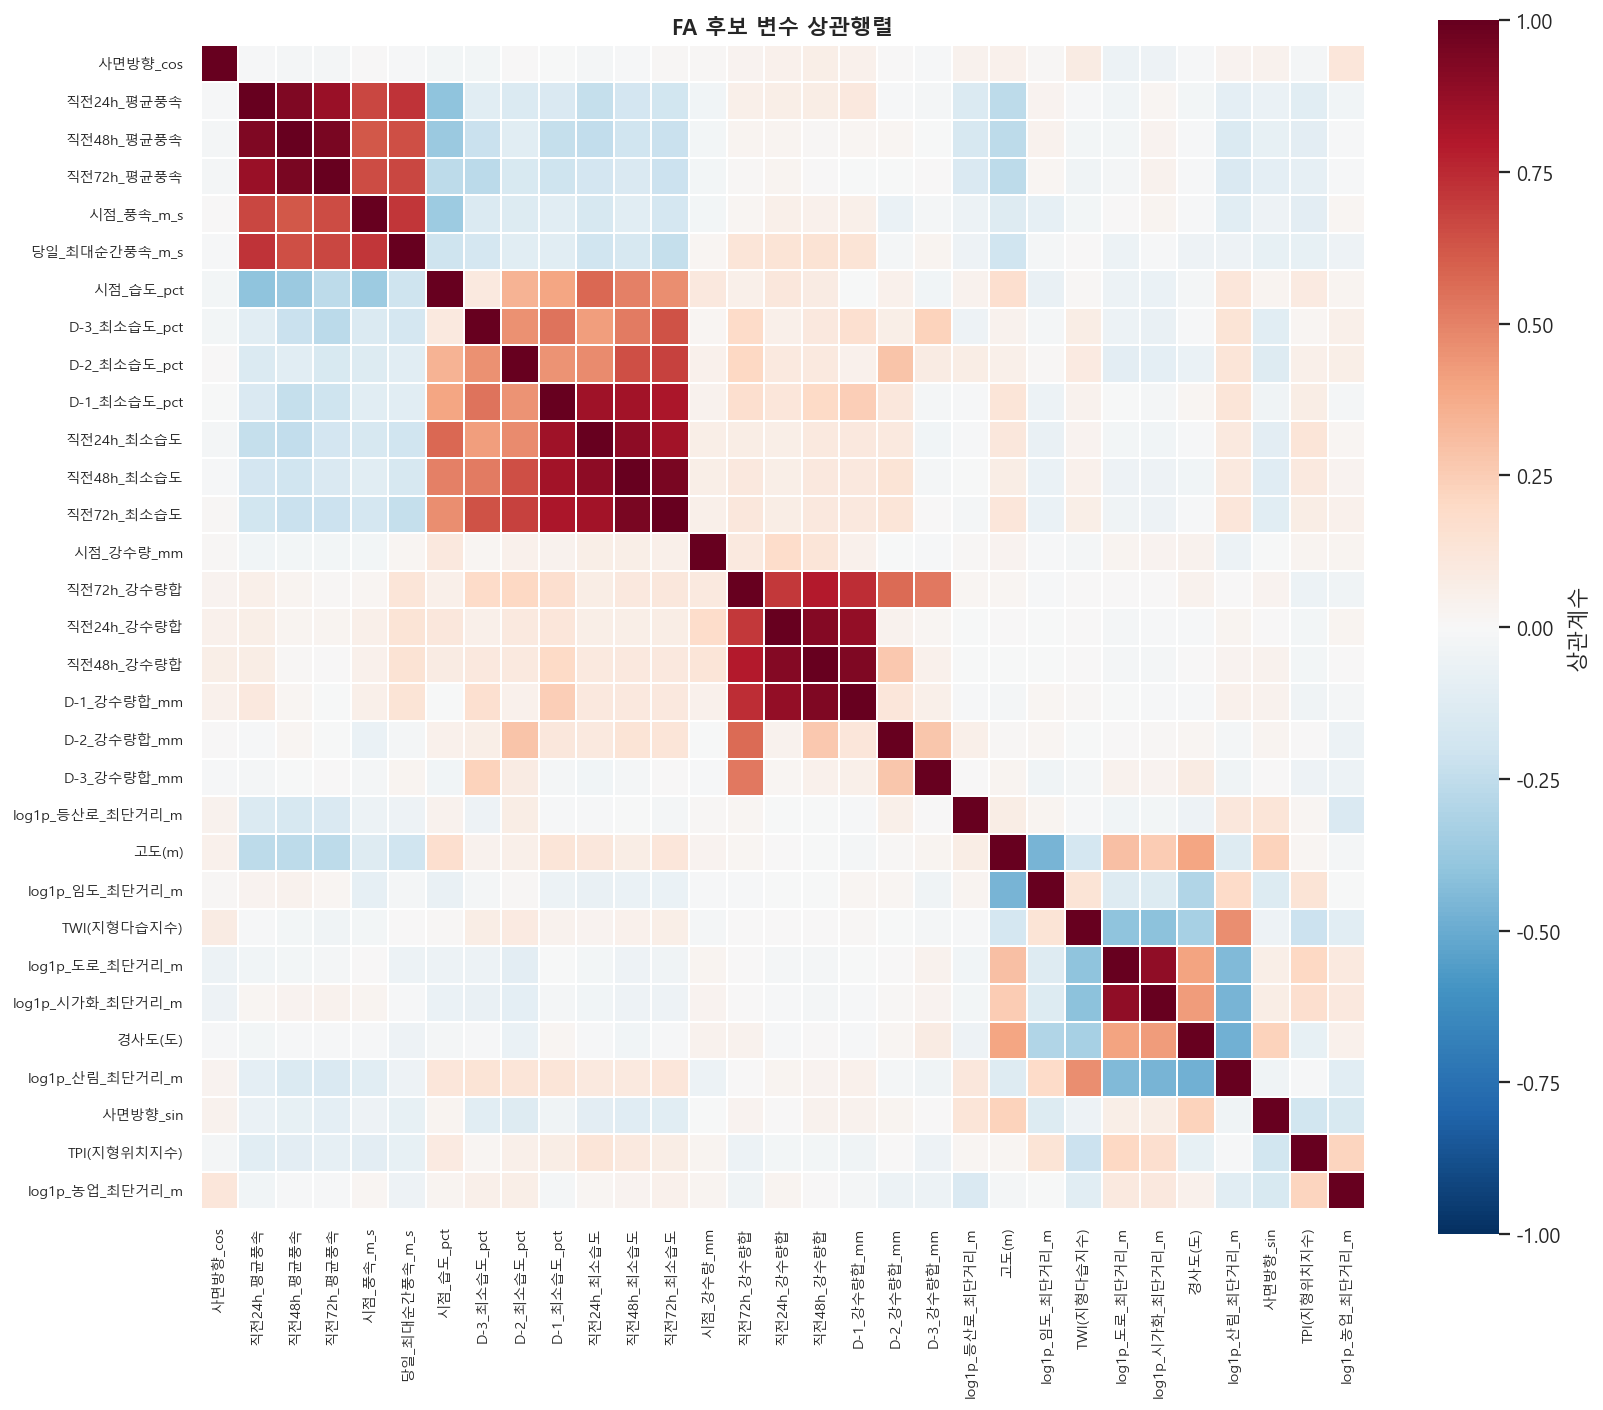

In [21]:


fa_fit_X = fa_X_complete.copy()
fa_fit_X = fa_fit_X.apply(pd.to_numeric, errors="coerce")

constant_cols = fa_fit_X.columns[fa_fit_X.nunique(dropna=True) <= 1].tolist()
if constant_cols:
    fa_fit_X = fa_fit_X.drop(columns=constant_cols)

fa_fit_X = fa_fit_X.dropna(axis=0, how="any")
fa_fit_corr = fa_fit_X.corr()

fit_summary = pd.DataFrame(
    {
        "항목": ["FA 적합성 점검 표본 수", "FA 적합성 점검 변수 수", "상수/단일값 제거 변수 수"],
        "값": [len(fa_fit_X), fa_fit_X.shape[1], len(constant_cols)],
    }
)
display(fit_summary)

if constant_cols:
    print("상수/단일값으로 제거한 변수:", constant_cols)

corr_abs = fa_fit_corr.abs()
upper_mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
high_corr_pairs = (
    corr_abs.where(upper_mask)
    .stack()
    .sort_values(ascending=False)
    .rename("abs_corr")
    .reset_index()
    .rename(columns={"level_0": "변수1", "level_1": "변수2"})
)
high_corr_pairs["corr"] = high_corr_pairs.apply(
    lambda row: fa_fit_corr.loc[row["변수1"], row["변수2"]],
    axis=1,
)

display(Markdown("#### 절대상관계수 상위 변수쌍"))
display(high_corr_pairs.head(20).round(4))

if fa_fit_corr.shape[0] >= 3:
    dist = (1 - corr_abs.fillna(0)).to_numpy(copy=True)
    np.fill_diagonal(dist, 0)
    order = leaves_list(linkage(squareform(dist, checks=False), method="average"))
    corr_plot = fa_fit_corr.iloc[order, order]
else:
    corr_plot = fa_fit_corr

fig, ax = plt.subplots(figsize=(13, 11), dpi=130)
sns.heatmap(
    corr_plot,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "상관계수"},
    ax=ax,
)
ax.set_title("FA 후보 변수 상관행렬", fontweight="bold")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()


### KMO (Kaiser-Meyer-Olkin)

In [19]:

kmo_per_variable, kmo_total = calculate_kmo(fa_fit_X)

kmo_table = (
    pd.DataFrame(
        {
            "변수": fa_fit_X.columns,
            "KMO": kmo_per_variable,
        }
    )
    .sort_values("KMO")
    .reset_index(drop=True)
)

def interpret_kmo(value):
    if value >= 0.90:
        return "매우 좋음"
    if value >= 0.80:
        return "좋음"
    if value >= 0.70:
        return "보통 이상"
    if value >= 0.60:
        return "허용"
    if value >= 0.50:
        return "낮지만 검토 가능"
    return "부적합"

kmo_result = pd.DataFrame(
    {
        "지표": ["KMO 전체"],
        "값": [kmo_total],
        "해석": [interpret_kmo(kmo_total)],
    }
)

display(kmo_result.round(4))
display(Markdown("#### 변수별 KMO (낮은 순)"))
display(kmo_table.round(4))


,지표,값,해석
0,KMO 전체,0.7174,보통 이상


#### 변수별 KMO (낮은 순)

,변수,KMO
0,D-3_강수량합_mm,0.2646
1,D-2_강수량합_mm,0.2766
2,사면방향_cos,0.3778
3,시점_강수량_mm,0.4346
4,log1p_농업_최단거리_m,0.5824
5,직전72h_강수량합,0.5989
6,TPI(지형위치지수),0.6456
7,log1p_등산로_최단거리_m,0.6463
8,직전24h_강수량합,0.6492
9,log1p_도로_최단거리_m,0.6661


### Bartlett 구형성 검정

In [22]:


bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(fa_fit_X)

bartlett_result = pd.DataFrame(
    {
        "검정": ["Bartlett 구형성 검정"],
        "chi_square": [bartlett_chi2],
        "p_value": [bartlett_p],
        "해석": [
            "요인분석 가능: 상관행렬이 단위행렬이라는 귀무가설 기각"
            if bartlett_p < 0.05
            else "주의: 상관행렬이 단위행렬과 다르다고 보기 어려움"
        ],
    }
)

display(bartlett_result.round(6))


,검정,chi_square,p_value,해석
0,Bartlett 구형성 검정,72835.838892,0.0,요인분석 가능: 상관행렬이 단위행렬이라는 귀무가설 기각


### 요인분석적합성 점검 결과 요약 및 결론

#### 결과 표 추출

| 항목 | 값 |
| --- | ---: |
| FA 적합성 점검 표본 수 | 2,670 |
| FA 적합성 점검 변수 수 | 31 |
| 상수/단일값 제거 변수 수 | 0 |
| KMO 전체 | 0.7174 |
| Bartlett chi-square | 72,835.8389 |
| Bartlett p-value | 0.0000 |

#### 절대상관계수 상위 변수쌍

| 순위 | 변수1 | 변수2 | 상관계수 |
| ---: | --- | --- | ---: |
| 1 | 직전48h_최소습도 | 직전72h_최소습도 | 0.9518 |
| 2 | 직전48h_평균풍속 | 직전72h_평균풍속 | 0.9485 |
| 3 | 직전24h_평균풍속 | 직전48h_평균풍속 | 0.9359 |
| 4 | 직전48h_강수량합 | D-1_강수량합_mm | 0.9350 |
| 5 | 직전24h_강수량합 | 직전48h_강수량합 | 0.9172 |
| 6 | 직전24h_최소습도 | 직전48h_최소습도 | 0.8984 |
| 7 | log1p_도로_최단거리_m | log1p_시가화_최단거리_m | 0.8842 |
| 8 | 직전24h_강수량합 | D-1_강수량합_mm | 0.8822 |
| 9 | 직전24h_평균풍속 | 직전72h_평균풍속 | 0.8655 |
| 10 | 직전24h_최소습도 | D-1_최소습도_pct | 0.8509 |

#### 변수별 KMO 하위 변수

| 변수 | KMO | 판단 |
| --- | ---: | --- |
| D-3_강수량합_mm | 0.2646 | 부적합 |
| D-2_강수량합_mm | 0.2766 | 부적합 |
| 사면방향_cos | 0.3778 | 부적합 |
| 시점_강수량_mm | 0.4346 | 부적합 |
| log1p_농업_최단거리_m | 0.5824 | 낮지만 검토 가능 |
| 직전72h_강수량합 | 0.5989 | 낮지만 검토 가능 |

#### 상관행렬 이미지 해석

상관행렬은 무작위적인 상관구조가 아니라, 의미 있는 변수 묶음이 뚜렷하게 나타난다.

1. `풍속 블록`
   - `직전24h_평균풍속`, `직전48h_평균풍속`, `직전72h_평균풍속`, `시점_풍속_m_s`, `당일_최대순간풍속_m_s`가 강한 양의 상관을 보인다.
   - 이는 산불 발생 시점의 바람이 단발성 값이 아니라 직전 24~72시간의 지속적 바람 조건과 연결된다는 EDA 해석과 일치한다.

2. `습도·건조 블록`
   - `시점_습도_pct`, `D-1~D-3_최소습도_pct`, `직전24~72h_최소습도`가 하나의 큰 양의 상관 블록을 형성한다.
   - 습도 관련 변수는 요인분석에서 `건조/습윤 상태` 요인으로 묶일 가능성이 높다.
   - 풍속 블록과는 대체로 음의 상관이 보여, 강풍 조건과 저습 조건이 함께 움직이는 구조도 일부 확인된다.

3. `강수량 블록`
   - `직전24~72h_강수량합`, `D-1~D-3_강수량합_mm`이 별도 양의 상관 블록을 이룬다.
   - 다만 `D-2_강수량합_mm`, `D-3_강수량합_mm`, `시점_강수량_mm`은 변수별 KMO가 낮아 현재 후보군 안에서 공통요인 설명력이 약하다.

4. `지형·접근성 블록`
   - `log1p_도로_최단거리_m`과 `log1p_시가화_최단거리_m`의 상관이 매우 높아 생활권 접근성 축으로 묶인다.
   - `고도(m)`, `경사도(도)`, `TWI`, `산림/도로/시가화 거리`도 일부 구조를 보이며, 산불 발생 지점의 공간적 입지 요인을 만들 가능성이 있다.

#### 결론

현재 31개 후보 변수는 요인분석을 진행할 수 있는 수준이다. 전체 KMO가 0.7174로 `보통 이상`이고, Bartlett 구형성 검정도 p-value가 0.0000으로 유의하므로 상관행렬이 단위행렬이라는 귀무가설을 기각한다. 즉 변수들 사이에 공통요인을 추출할 만한 상관구조가 존재한다.

다만 그대로 요인분석을 진행하면 일부 변수군이 과대표현될 수 있다. 특히 직전 24/48/72시간 풍속, 습도, 강수량 변수는 서로 매우 높은 상관을 갖기 때문에 같은 시간축 변수가 하나의 요인을 과도하게 지배할 수 있다. 따라서 다음 단계에서는 전체 변수로 1차 FA를 수행하되, 공통성/적재량/교차적재를 확인한 뒤 중복 시간창 변수는 대표 변수 중심으로 줄이는 것이 안전하다.

우선 제거 또는 보조변수 전환을 검토할 후보는 `D-3_강수량합_mm`, `D-2_강수량합_mm`, `시점_강수량_mm`, `사면방향_cos`이다. 이 변수들은 변수별 KMO가 낮아 현재 상관구조 안에서 공통요인에 잘 묶이지 않는다. 사면방향은 순환형 변수이므로 `sin/cos`를 함께 해석해야 하며, FA 핵심 변수로 쓰기보다 지형 보조변수로 둘지 검토가 필요하다.

요약하면, FA 진행은 가능하지만 다음 단계에서 `전체 변수 FA → 낮은 KMO/낮은 공통성 변수 제거 → 대표 시간창 변수 중심 재FA` 순서로 진행하는 것이 적절하다.


## 요인 수 결정: Parallel Analysis

요인분석적합성 점검 결과, 전체 KMO와 Bartlett 검정은 요인분석 진행이 가능하다고 판단되었다.  
이제 실제 상관행렬의 고유값과 같은 표본수·변수수의 무작위 자료 고유값을 비교해 요인 수 후보를 결정한다.

- `observed_eigenvalue`: 실제 FA 후보 변수 상관행렬의 고유값
- `random_mean`: 무작위 자료 고유값 평균
- `random_p95`: 무작위 자료 고유값의 95퍼센타일
- 보수적 기준: `observed_eigenvalue > random_p95`
- 참고 기준: `observed_eigenvalue > random_mean`


In [23]:
# Parallel Analysis 설정
N_PARALLEL_ITER = 500
PARALLEL_PERCENTILE = 95

try:
    fa_fit_X
except NameError:
    fa_fit_X = fa_X_complete.copy()
    fa_fit_X = fa_fit_X.apply(pd.to_numeric, errors="coerce")
    constant_cols = fa_fit_X.columns[fa_fit_X.nunique(dropna=True) <= 1].tolist()
    if constant_cols:
        fa_fit_X = fa_fit_X.drop(columns=constant_cols)
    fa_fit_X = fa_fit_X.dropna(axis=0, how="any")

parallel_X = fa_fit_X.copy()
parallel_X = parallel_X.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
parallel_X = parallel_X.loc[:, parallel_X.nunique(dropna=True) > 1]

n_obs, n_vars = parallel_X.shape
observed_corr = parallel_X.corr().to_numpy()
observed_eigen = np.linalg.eigvalsh(observed_corr)[::-1]

rng = np.random.default_rng(RANDOM_STATE)
random_eigen = np.empty((N_PARALLEL_ITER, n_vars))

for i in range(N_PARALLEL_ITER):
    random_data = rng.normal(size=(n_obs, n_vars))
    random_corr = np.corrcoef(random_data, rowvar=False)
    random_eigen[i] = np.linalg.eigvalsh(random_corr)[::-1]

random_mean = random_eigen.mean(axis=0)
random_p95 = np.percentile(random_eigen, PARALLEL_PERCENTILE, axis=0)

pa_table = pd.DataFrame(
    {
        "요인번호": np.arange(1, n_vars + 1),
        "observed_eigenvalue": observed_eigen,
        "random_mean": random_mean,
        "random_p95": random_p95,
        "observed_gt_random_mean": observed_eigen > random_mean,
        "observed_gt_random_p95": observed_eigen > random_p95,
        "kaiser_gt_1": observed_eigen > 1,
    }
)

pa_n_factors_mean = int(pa_table["observed_gt_random_mean"].sum())
pa_n_factors_p95 = int(pa_table["observed_gt_random_p95"].sum())
kaiser_n_factors = int(pa_table["kaiser_gt_1"].sum())

pa_summary = pd.DataFrame(
    {
        "기준": [
            "Parallel Analysis 95퍼센타일 기준",
            "Parallel Analysis 평균 기준",
            "Kaiser 기준(eigenvalue > 1)",
        ],
        "요인 수": [pa_n_factors_p95, pa_n_factors_mean, kaiser_n_factors],
    }
)

display(
    pd.DataFrame(
        {
            "항목": ["표본 수", "변수 수", "무작위 반복 수", "무작위 고유값 기준 퍼센타일"],
            "값": [n_obs, n_vars, N_PARALLEL_ITER, PARALLEL_PERCENTILE],
        }
    )
)
display(pa_summary)
display(Markdown("### Parallel Analysis 고유값 비교표"))
display(pa_table.head(15).round(4))


,항목,값
0,표본 수,2670
1,변수 수,31
2,무작위 반복 수,500
3,무작위 고유값 기준 퍼센타일,95


,기준,요인 수
0,Parallel Analysis 95퍼센타일 기준,7
1,Parallel Analysis 평균 기준,8
2,Kaiser 기준(eigenvalue > 1),9


### Parallel Analysis 고유값 비교표

,요인번호,observed_eigenvalue,random_mean,random_p95,observed_gt_random_mean,observed_gt_random_p95,kaiser_gt_1
0,1,5.7510,1.2032,1.2301,True,True,True
1,2,4.0631,1.1776,1.1944,True,True,True
2,3,3.3008,1.1582,1.1740,True,True,True
3,4,2.8650,1.1423,1.1565,True,True,True
4,5,1.6856,1.1271,1.1421,True,True,True
5,6,1.5553,1.1127,1.1261,True,True,True
6,7,1.1850,1.0996,1.1121,True,True,True
7,8,1.0976,1.0872,1.0981,True,False,True
8,9,1.0333,1.0750,1.0869,False,False,True
9,10,0.9456,1.0628,1.0733,False,False,False


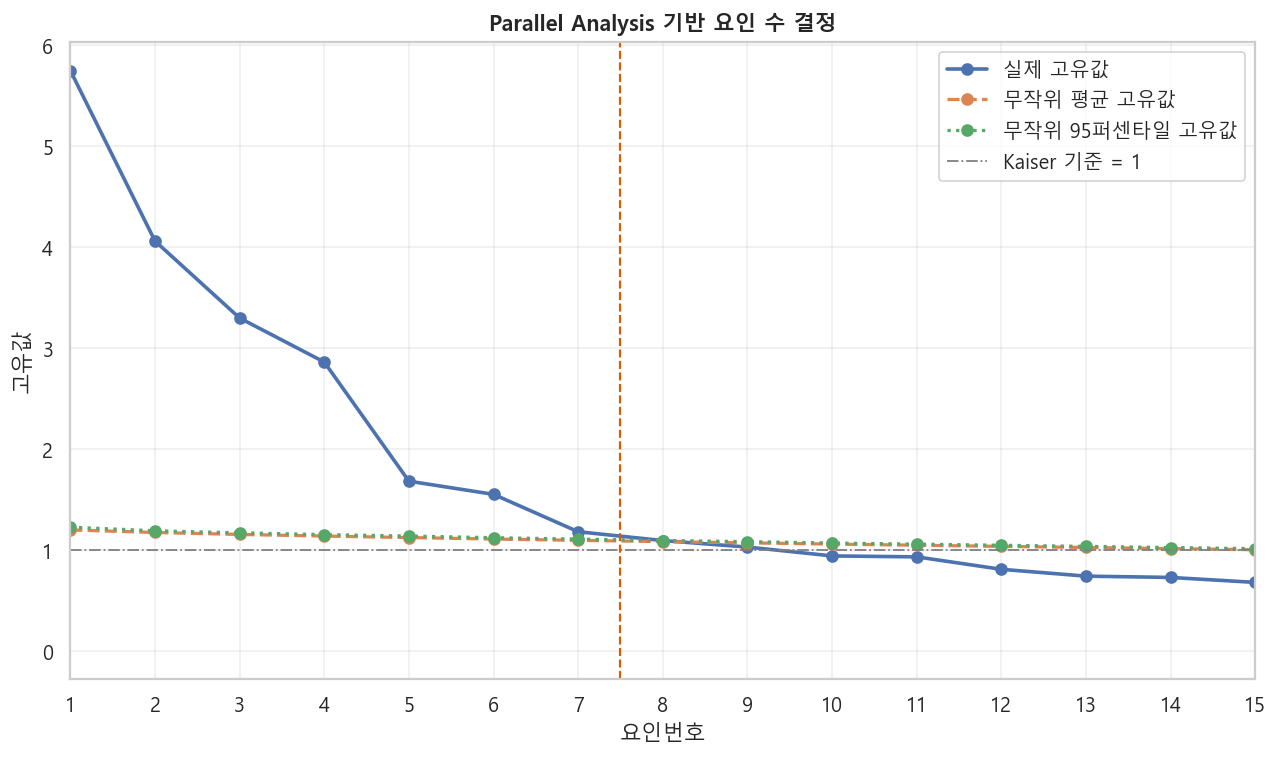

In [24]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

ax.plot(
    pa_table["요인번호"],
    pa_table["observed_eigenvalue"],
    marker="o",
    linewidth=2,
    label="실제 고유값",
)
ax.plot(
    pa_table["요인번호"],
    pa_table["random_mean"],
    marker="o",
    linewidth=1.8,
    linestyle="--",
    label="무작위 평균 고유값",
)
ax.plot(
    pa_table["요인번호"],
    pa_table["random_p95"],
    marker="o",
    linewidth=1.8,
    linestyle=":",
    label=f"무작위 {PARALLEL_PERCENTILE}퍼센타일 고유값",
)
ax.axhline(1, color="gray", linewidth=1, linestyle="-.", label="Kaiser 기준 = 1")
ax.axvline(pa_n_factors_p95 + 0.5, color="#D55E00", linewidth=1.2, linestyle="--")

ax.set_title("Parallel Analysis 기반 요인 수 결정", fontweight="bold")
ax.set_xlabel("요인번호")
ax.set_ylabel("고유값")
ax.set_xticks(pa_table["요인번호"])
ax.set_xlim(1, min(n_vars, 15))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
pa_recommendation = (
    f"Parallel Analysis 95퍼센타일 기준으로는 {pa_n_factors_p95}개 요인이 권장된다. "
    f"평균 기준은 {pa_n_factors_mean}개, Kaiser 기준은 {kaiser_n_factors}개이다. "
    "요인 수는 보수적인 95퍼센타일 기준을 우선 사용하고, 이후 적재량/공통성/해석 가능성을 함께 확인한다."
)

display(Markdown(f"### Parallel Analysis 결론\n\n{pa_recommendation}"))


### Parallel Analysis 결론

Parallel Analysis 95퍼센타일 기준으로는 7개 요인이 권장된다. 평균 기준은 8개, Kaiser 기준은 9개이다. 요인 수는 보수적인 95퍼센타일 기준을 우선 사용하고, 이후 적재량/공통성/해석 가능성을 함께 확인한다.

### Parallel Analysis 결과 요약 및 요인 수 결정

#### 결과 표

| 기준 | 요인 수 |
| --- | ---: |
| Parallel Analysis 95퍼센타일 기준 | 7 |
| Parallel Analysis 평균 기준 | 8 |
| Kaiser 기준(eigenvalue > 1) | 9 |

#### 고유값 비교

| 요인번호 | 실제 고유값 | 무작위 평균 고유값 | 무작위 95퍼센타일 고유값 | 95퍼센타일 기준 채택 |
| ---: | ---: | ---: | ---: | --- |
| 1 | 5.7510 | 1.2032 | 1.2301 | 채택 |
| 2 | 4.0631 | 1.1776 | 1.1944 | 채택 |
| 3 | 3.3008 | 1.1582 | 1.1740 | 채택 |
| 4 | 2.8650 | 1.1423 | 1.1565 | 채택 |
| 5 | 1.6856 | 1.1271 | 1.1421 | 채택 |
| 6 | 1.5553 | 1.1127 | 1.1261 | 채택 |
| 7 | 1.1850 | 1.0996 | 1.1121 | 채택 |
| 8 | 1.0976 | 1.0872 | 1.0981 | 제외 |
| 9 | 1.0333 | 1.0750 | 1.0869 | 제외 |

#### 결론

Parallel Analysis의 보수적 기준인 95퍼센타일 기준에서는 **7개 요인**이 적절하다.  
평균 기준은 8개, Kaiser 기준은 9개를 제안하지만, 8번째 요인은 실제 고유값이 1.0976으로 무작위 95퍼센타일 고유값 1.0981보다 근소하게 낮아 보수 기준에서는 제외된다.

따라서 다음 FA 본 분석은 우선 **7요인 해**를 기준으로 진행한다.  
다만 8번째 요인이 경계값에 매우 가깝기 때문에, 이후 적재량과 해석 가능성을 확인하면서 **7요인 해와 8요인 해를 보조 비교**하는 것이 좋다.


## 요인 회전 방식 비교: Varimax vs Promax

Parallel Analysis 결과에 따라 기본 요인 수는 **7개**로 둔다.  
이 단계에서는 같은 7요인 해를 `varimax`와 `promax`로 각각 회전한 뒤, 요인 간 상관과 적재량 구조를 비교해 최종 회전 방식을 선택한다.

- `varimax`: 직교회전. 요인 간 상관을 0으로 가정한다.
- `promax`: 사각회전. 요인 간 상관을 허용한다.
- 선택 기준: 요인 간 상관이 의미 있게 존재하거나 날씨·지형·접근성 요인이 구조적으로 연결되어 있으면 `promax`를 우선한다.


In [26]:
from factor_analyzer import FactorAnalyzer

FA_N_FACTORS = 7
PRIMARY_LOADING_CUTOFF = 0.40
CROSS_LOADING_CUTOFF = 0.30
FA_ROTATIONS = ["varimax", "promax"]

try:
    fa_fit_X
except NameError:
    fa_fit_X = fa_X_complete.copy()
    fa_fit_X = fa_fit_X.apply(pd.to_numeric, errors="coerce")
    constant_cols = fa_fit_X.columns[fa_fit_X.nunique(dropna=True) <= 1].tolist()
    if constant_cols:
        fa_fit_X = fa_fit_X.drop(columns=constant_cols)
    fa_fit_X = fa_fit_X.dropna(axis=0, how="any")

fa_rotation_X = fa_fit_X.copy()
fa_rotation_X = fa_rotation_X.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
fa_rotation_X = fa_rotation_X.loc[:, fa_rotation_X.nunique(dropna=True) > 1]
fa_rotation_Z = (fa_rotation_X - fa_rotation_X.mean()) / fa_rotation_X.std(ddof=0)
fa_rotation_Z = fa_rotation_Z.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

factor_names = [f"F{i}" for i in range(1, FA_N_FACTORS + 1)]


def fit_rotated_fa(rotation):
    model = FactorAnalyzer(n_factors=FA_N_FACTORS, rotation=rotation, method="minres")
    model.fit(fa_rotation_Z)

    loadings = pd.DataFrame(model.loadings_, index=fa_rotation_Z.columns, columns=factor_names)
    communalities = pd.Series(model.get_communalities(), index=fa_rotation_Z.columns, name="공통성")
    uniquenesses = pd.Series(model.get_uniquenesses(), index=fa_rotation_Z.columns, name="고유성")

    variance, prop_var, cum_var = model.get_factor_variance()
    variance_table = pd.DataFrame(
        {
            "요인": factor_names,
            "SS_Loadings": variance,
            "Proportion_Var": prop_var,
            "Cumulative_Var": cum_var,
        }
    )

    phi = getattr(model, "phi_", None)
    if phi is None:
        phi_table = pd.DataFrame(np.eye(FA_N_FACTORS), index=factor_names, columns=factor_names)
    else:
        phi_table = pd.DataFrame(phi, index=factor_names, columns=factor_names)

    abs_loadings = loadings.abs()
    loading_detail = pd.DataFrame(
        {
            "변수": loadings.index,
            "주요인": abs_loadings.idxmax(axis=1),
            "주적재량": loadings.to_numpy()[np.arange(loadings.shape[0]), abs_loadings.values.argmax(axis=1)],
            "주적재량_abs": abs_loadings.max(axis=1).values,
            "적재량_0.30이상_개수": (abs_loadings >= CROSS_LOADING_CUTOFF).sum(axis=1).values,
            "적재량_0.40이상_개수": (abs_loadings >= PRIMARY_LOADING_CUTOFF).sum(axis=1).values,
            "공통성": communalities.values,
            "고유성": uniquenesses.values,
        }
    )
    loading_detail["교차적재_후보"] = loading_detail["적재량_0.30이상_개수"] >= 2
    loading_detail["약한_주적재"] = loading_detail["주적재량_abs"] < PRIMARY_LOADING_CUTOFF

    off_diag = phi_table.where(~np.eye(FA_N_FACTORS, dtype=bool))
    max_factor_corr = off_diag.abs().max().max()
    factor_corr_ge_030 = int((off_diag.abs() >= 0.30).sum().sum() / 2)

    summary = {
        "rotation": rotation,
        "n_obs": len(fa_rotation_Z),
        "n_vars": fa_rotation_Z.shape[1],
        "n_factors": FA_N_FACTORS,
        "mean_communality": communalities.mean(),
        "min_communality": communalities.min(),
        "communality_lt_020_n": int((communalities < 0.20).sum()),
        "weak_primary_loading_n": int(loading_detail["약한_주적재"].sum()),
        "cross_loading_n": int(loading_detail["교차적재_후보"].sum()),
        "min_salient_vars_per_factor": int((abs_loadings >= PRIMARY_LOADING_CUTOFF).sum(axis=0).min()),
        "max_abs_factor_corr": float(max_factor_corr) if pd.notna(max_factor_corr) else 0.0,
        "factor_corr_ge_030_n": factor_corr_ge_030,
        "cumulative_variance": float(variance_table["Cumulative_Var"].iloc[-1]),
    }

    return {
        "model": model,
        "loadings": loadings,
        "abs_loadings": abs_loadings,
        "loading_detail": loading_detail,
        "communalities": communalities,
        "uniquenesses": uniquenesses,
        "variance": variance_table,
        "phi": phi_table,
        "summary": summary,
    }


rotation_results = {rotation: fit_rotated_fa(rotation) for rotation in FA_ROTATIONS}
rotation_summary = pd.DataFrame([rotation_results[r]["summary"] for r in FA_ROTATIONS])

display(Markdown("### 회전 방식 비교 요약"))
display(rotation_summary.round(4))


### 회전 방식 비교 요약

,rotation,n_obs,n_vars,n_factors,mean_communality,min_communality,communality_lt_020_n,weak_primary_loading_n,cross_loading_n,min_salient_vars_per_factor,max_abs_factor_corr,factor_corr_ge_030_n,cumulative_variance
0,varimax,2670,31,7,0.5767,0.0089,5,5,5,1,0.0000,0,0.5767
1,promax,2670,31,7,0.5985,0.0093,5,6,4,1,0.3089,1,0.5985


### Promax 요인상관 행렬

,F1,F2,F3,F4,F5,F6,F7
F1,1.000,0.158,0.095,-0.309,0.089,-0.114,-0.104
F2,0.158,1.000,-0.052,-0.033,0.150,0.095,-0.105
F3,0.095,-0.052,1.000,0.032,-0.135,-0.030,0.019
F4,-0.309,-0.033,0.032,1.000,-0.038,-0.105,0.287
F5,0.089,0.150,-0.135,-0.038,1.000,0.153,-0.041
F6,-0.114,0.095,-0.030,-0.105,0.153,1.000,-0.132
F7,-0.104,-0.105,0.019,0.287,-0.041,-0.132,1.000


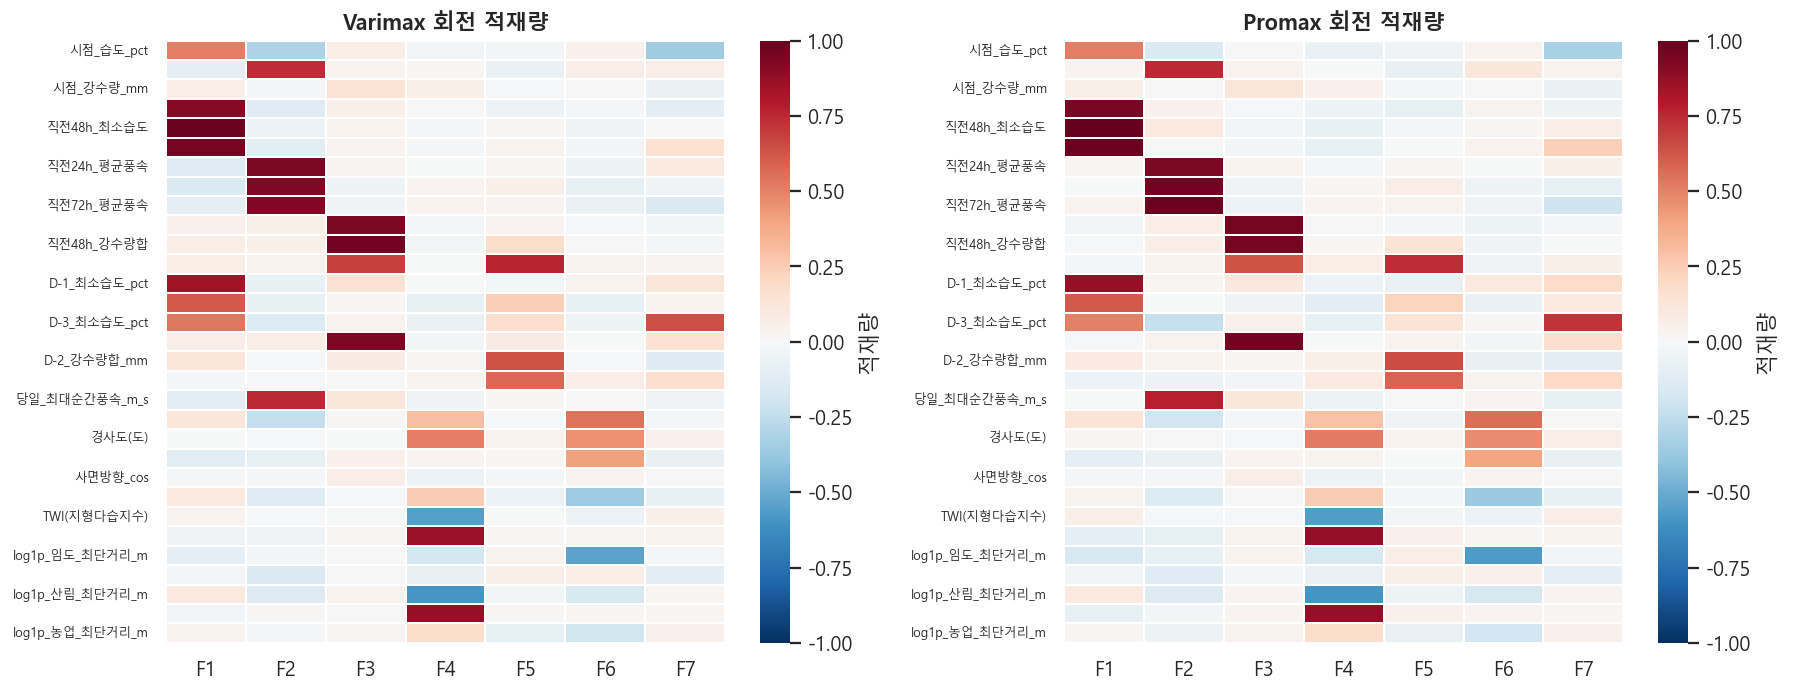

In [27]:
display(Markdown("### Promax 요인상관 행렬"))
display(rotation_results["promax"]["phi"].round(3))

promax_phi = rotation_results["promax"]["phi"].copy()
promax_off_diag = promax_phi.where(~np.eye(FA_N_FACTORS, dtype=bool))
promax_max_corr = float(promax_off_diag.abs().max().max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=130)

sns.heatmap(
    rotation_results["varimax"]["loadings"],
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    cbar_kws={"label": "적재량"},
    ax=axes[0],
)
axes[0].set_title("Varimax 회전 적재량", fontweight="bold")
axes[0].tick_params(axis="y", labelsize=7)

sns.heatmap(
    rotation_results["promax"]["loadings"],
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    cbar_kws={"label": "적재량"},
    ax=axes[1],
)
axes[1].set_title("Promax 회전 적재량", fontweight="bold")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()


In [28]:
selected_rotation = "promax" if promax_max_corr >= 0.30 else "varimax"
selected_fa = rotation_results[selected_rotation]

if selected_rotation == "promax":
    rotation_decision = (
        f"Promax 요인상관의 최대 절대값이 {promax_max_corr:.3f}로 0.30 이상이므로, "
        "요인 간 상관을 허용하는 promax를 채택한다."
    )
else:
    rotation_decision = (
        f"Promax 요인상관의 최대 절대값이 {promax_max_corr:.3f}로 0.30 미만이므로, "
        "요인 간 독립 가정이 크게 무리하지 않아 varimax를 채택한다."
    )

display(Markdown(f"### 회전 방식 선택 결론\n\n{rotation_decision}"))

display(Markdown(f"### 선택 회전 방식: `{selected_rotation}` 변수별 주적재량"))
selected_loading_detail = (
    selected_fa["loading_detail"]
    .sort_values(["주요인", "주적재량_abs"], ascending=[True, False])
    .reset_index(drop=True)
)
display(selected_loading_detail.round(4))


### 회전 방식 선택 결론

Promax 요인상관의 최대 절대값이 0.309로 0.30 이상이므로, 요인 간 상관을 허용하는 promax를 채택한다.

### 선택 회전 방식: `promax` 변수별 주적재량

,변수,주요인,주적재량,주적재량_abs,적재량_0.30이상_개수,적재량_0.40이상_개수,공통성,고유성,교차적재_후보,약한_주적재
0,직전48h_최소습도,F1,1.0287,1.0287,1,1,1.0821,-0.0821,False,False
1,직전72h_최소습도,F1,0.9888,0.9888,1,1,1.0455,-0.0455,False,False
2,직전24h_최소습도,F1,0.9520,0.9520,1,1,0.9240,0.0760,False,False
3,D-1_최소습도_pct,F1,0.8682,0.8682,1,1,0.8210,0.1790,False,False
4,D-2_최소습도_pct,F1,0.6190,0.6190,1,1,0.4619,0.5381,False,False
5,시점_습도_pct,F1,0.5139,0.5139,2,1,0.4003,0.5997,True,False
6,직전72h_평균풍속,F2,0.9918,0.9918,1,1,1.0342,-0.0342,False,False
7,직전48h_평균풍속,F2,0.9635,0.9635,1,1,0.9460,0.0540,False,False
8,직전24h_평균풍속,F2,0.9440,0.9440,1,1,0.8970,0.1030,False,False
9,당일_최대순간풍속_m_s,F2,0.7806,0.7806,1,1,0.6323,0.3677,False,False


### 회전 방식 판단 메모

이 데이터의 잠재 요인은 기상·지형·접근성이 서로 완전히 독립이라고 보기 어렵다.  
EDA에서도 강풍과 저습, 기후지형유형과 고도·접근성, 생활권 접근성과 토지피복 거리 변수가 함께 움직이는 구조가 확인되었다.

따라서 `promax`의 요인상관이 충분히 작지 않다면, 해석 단계에서는 `varimax`보다 `promax`를 우선하는 것이 타당하다.  
단, 최종 요인명은 선택된 회전 방식의 적재량표에서 `주적재량`, `교차적재`, `공통성`을 함께 확인해 붙인다.


### 회전 방식 비교 결과 요약 및 최종 선택

#### 비교 결과

| 회전 방식 | 평균 공통성 | 공통성 0.20 미만 변수 수 | 약한 주적재 변수 수 | 교차적재 변수 수 | 최대 요인상관 절대값 | 누적 설명분산 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| varimax | 0.5767 | 5 | 5 | 5 | 0.0000 | 0.5767 |
| promax | 0.5985 | 5 | 6 | 4 | 0.3089 | 0.5985 |

#### Promax 요인상관 핵심

| 요인쌍 | 상관 |
| --- | ---: |
| F1 - F4 | -0.309 |
| F4 - F7 | 0.287 |
| F1 - F2 | 0.158 |
| F5 - F6 | 0.153 |

#### 선택

최종 회전 방식은 **promax**로 선택한다.

이유는 다음과 같다.

- `promax`의 최대 요인상관 절대값이 0.3089로 0.30 기준을 넘는다.
- 따라서 요인들이 완전히 독립이라는 `varimax` 가정보다는, 요인 간 상관을 허용하는 `promax`가 데이터 구조에 더 맞다.
- `promax`는 `varimax`보다 교차적재 후보가 5개에서 4개로 줄어 적재 구조도 약간 더 단순하다.
- 평균 공통성도 `varimax` 0.5767보다 `promax` 0.5985로 더 높다.

#### 주의점

`promax` 결과에서 일부 변수의 공통성이 1을 넘고 고유성이 음수가 되는 Heywood 징후가 있다.  
이는 `직전24h/48h/72h` 습도·풍속·강수량처럼 매우 높은 상관을 갖는 중복 시간창 변수가 함께 들어간 영향일 가능성이 크다.

따라서 다음 단계는 다음 순서로 진행한다.

1. 우선 `7요인 + promax` 해를 기준으로 적재량을 해석한다.
2. 공통성 1 초과, 공통성 0.20 미만, 약한 주적재, 교차적재 변수를 점검한다.
3. 중복 시간창 변수는 대표 변수 중심으로 축소한 뒤 재FA를 수행한다.
4. 재FA에서도 `promax`를 기본 회전 방식으로 사용한다.


## 요인 Loading 해석

7요인 `promax` 해를 기준으로 요인 loading을 해석한다.  
해석은 주적재량만 보지 않고, 각 요인에 배치된 모든 변수, 교차적재 후보, 약한 주적재 변수, 공통성을 함께 확인한다.


In [29]:
if "selected_fa" not in globals() or "selected_loading_detail" not in globals():
    raise RuntimeError("먼저 varimax/promax 회전 비교 셀을 실행해 selected_fa와 selected_loading_detail을 생성하세요.")

loading_matrix = selected_fa["loadings"].copy()
loading_detail_for_review = selected_loading_detail.copy()

salient_loadings = (
    loading_matrix
    .reset_index(names="변수")
    .melt(id_vars="변수", var_name="요인", value_name="적재량")
)
salient_loadings["적재량_abs"] = salient_loadings["적재량"].abs()
salient_loadings = (
    salient_loadings[salient_loadings["적재량_abs"] >= 0.30]
    .sort_values(["요인", "적재량_abs"], ascending=[True, False])
    .reset_index(drop=True)
)

factor_name_map = {
    "F1": "선행 습도/건조 상태",
    "F2": "지속·당일 강풍",
    "F3": "최근 24~48h 및 D-1 강수",
    "F4": "생활권-산림사면 입지",
    "F5": "중기 누적강수",
    "F6": "고도-임도 인접 지형",
    "F7": "D-3 선행습도 잔여",
}

loading_detail_for_review["요인명_초안"] = loading_detail_for_review["주요인"].map(factor_name_map)

display(Markdown("### 요인별 |loading| >= 0.30 변수"))
display(salient_loadings.round(4))

display(Markdown("### 변수별 주적재량/공통성/교차적재 점검"))
display(loading_detail_for_review.round(4))

cross_or_weak = loading_detail_for_review[
    loading_detail_for_review["교차적재_후보"] | loading_detail_for_review["약한_주적재"]
].copy()
display(Markdown("### 교차적재 또는 약한 주적재 변수"))
display(cross_or_weak.round(4))

display(Markdown("### 교차적재/약한 변수의 전체 loading"))
display(loading_matrix.loc[cross_or_weak["변수"]].round(4))


### 요인별 |loading| >= 0.30 변수

,변수,요인,적재량,적재량_abs
0,직전48h_최소습도,F1,1.0287,1.0287
1,직전72h_최소습도,F1,0.9888,0.9888
2,직전24h_최소습도,F1,0.9520,0.9520
3,D-1_최소습도_pct,F1,0.8682,0.8682
4,D-2_최소습도_pct,F1,0.6190,0.6190
5,시점_습도_pct,F1,0.5139,0.5139
6,D-3_최소습도_pct,F1,0.5031,0.5031
7,직전72h_평균풍속,F2,0.9918,0.9918
8,직전48h_평균풍속,F2,0.9635,0.9635
9,직전24h_평균풍속,F2,0.9440,0.9440


### 변수별 주적재량/공통성/교차적재 점검

,변수,주요인,주적재량,주적재량_abs,적재량_0.30이상_개수,적재량_0.40이상_개수,공통성,고유성,교차적재_후보,약한_주적재,요인명_초안
0,직전48h_최소습도,F1,1.0287,1.0287,1,1,1.0821,-0.0821,False,False,선행 습도/건조 상태
1,직전72h_최소습도,F1,0.9888,0.9888,1,1,1.0455,-0.0455,False,False,선행 습도/건조 상태
2,직전24h_최소습도,F1,0.9520,0.9520,1,1,0.9240,0.0760,False,False,선행 습도/건조 상태
3,D-1_최소습도_pct,F1,0.8682,0.8682,1,1,0.8210,0.1790,False,False,선행 습도/건조 상태
4,D-2_최소습도_pct,F1,0.6190,0.6190,1,1,0.4619,0.5381,False,False,선행 습도/건조 상태
5,시점_습도_pct,F1,0.5139,0.5139,2,1,0.4003,0.5997,True,False,선행 습도/건조 상태
6,직전72h_평균풍속,F2,0.9918,0.9918,1,1,1.0342,-0.0342,False,False,지속·당일 강풍
7,직전48h_평균풍속,F2,0.9635,0.9635,1,1,0.9460,0.0540,False,False,지속·당일 강풍
8,직전24h_평균풍속,F2,0.9440,0.9440,1,1,0.8970,0.1030,False,False,지속·당일 강풍
9,당일_최대순간풍속_m_s,F2,0.7806,0.7806,1,1,0.6323,0.3677,False,False,지속·당일 강풍


### 교차적재 또는 약한 주적재 변수

,변수,주요인,주적재량,주적재량_abs,적재량_0.30이상_개수,적재량_0.40이상_개수,공통성,고유성,교차적재_후보,약한_주적재,요인명_초안
5,시점_습도_pct,F1,0.5139,0.5139,2,1,0.4003,0.5997,True,False,선행 습도/건조 상태
11,log1p_등산로_최단거리_m,F2,-0.1232,0.1232,0,0,0.0373,0.9627,False,True,지속·당일 강풍
15,시점_강수량_mm,F3,0.1286,0.1286,0,0,0.0271,0.9729,False,True,최근 24~48h 및 D-1 강수
16,사면방향_cos,F3,0.0646,0.0646,0,0,0.0093,0.9907,False,True,최근 24~48h 및 D-1 강수
21,경사도(도),F4,0.5166,0.5166,2,2,0.4970,0.5030,True,False,생활권-산림사면 입지
22,직전72h_강수량합,F5,0.7407,0.7407,2,2,0.9697,0.0303,True,False,중기 누적강수
27,사면방향_sin,F6,0.3979,0.3979,1,0,0.1789,0.8211,False,True,고도-임도 인접 지형
28,TPI(지형위치지수),F6,-0.3743,0.3743,1,0,0.2312,0.7688,False,True,고도-임도 인접 지형
29,log1p_농업_최단거리_m,F6,-0.1822,0.1822,0,0,0.0784,0.9216,False,True,고도-임도 인접 지형
30,D-3_최소습도_pct,F7,0.7248,0.7248,2,2,0.8581,0.1419,True,False,D-3 선행습도 잔여


### 교차적재/약한 변수의 전체 loading

,F1,F2,F3,F4,F5,F6,F7
시점_습도_pct,0.5139,-0.1447,0.0032,-0.0637,-0.0428,0.0425,-0.3280
log1p_등산로_최단거리_m,-0.0304,-0.1232,-0.0170,-0.0674,0.0578,0.0519,-0.1015
시점_강수량_mm,0.0552,0.0051,0.1286,0.0542,-0.0180,0.0011,-0.0652
사면방향_cos,-0.0208,-0.0221,0.0646,-0.0537,-0.0236,0.0273,0.0047
경사도(도),0.0151,0.0034,-0.0143,0.5166,0.0377,0.4731,0.0665
직전72h_강수량합,-0.0214,0.0436,0.6378,0.0777,0.7407,-0.0458,0.0610
사면방향_sin,-0.0958,-0.0636,0.0249,0.0387,-0.0022,0.3979,-0.0725
TPI(지형위치지수),0.0364,-0.1346,0.0068,0.2538,-0.0213,-0.3743,-0.0819
log1p_농업_최단거리_m,0.0113,-0.0528,0.0397,0.1816,-0.0703,-0.1822,0.0532
D-3_최소습도_pct,0.5031,-0.2269,0.0500,-0.0829,0.1362,0.0151,0.7248


### 요인별 해석

#### F1. 선행 습도/건조 상태 요인

F1에는 `직전48h_최소습도`(1.0287), `직전72h_최소습도`(0.9888), `직전24h_최소습도`(0.9520), `D-1_최소습도_pct`(0.8682), `D-2_최소습도_pct`(0.6190), `시점_습도_pct`(0.5139)가 주로 적재된다.

이 요인은 산불 발생 전 1~3일과 직전 24~72시간의 습도 상태를 나타낸다. 적재량 부호상 점수가 높을수록 습도가 높은 상태이고, 산불 위험 해석에서는 반대로 **점수가 낮을수록 선행 건조가 강한 상태**로 해석하는 것이 맞다.

주의할 점은 `직전48h_최소습도`, `직전72h_최소습도`의 공통성이 1을 넘는다는 점이다. 이는 직전 24/48/72시간 최소습도 변수들이 거의 같은 정보를 반복해서 담고 있기 때문에 생긴 Heywood 징후로 볼 수 있다. F1 자체는 해석 가능하지만, 최종 재FA에서는 최소습도 시간창을 대표 변수 중심으로 줄일 필요가 있다.

`시점_습도_pct`는 F1에 주적재되지만 F7에도 -0.3280으로 교차적재된다. 발생시각 습도는 선행 습도 축에 포함되지만, D-3 선행습도 잔여 축과도 일부 연결되어 있어 순수한 F1 변수로만 해석하면 안 된다.

#### F2. 지속·당일 강풍 요인

F2에는 `직전72h_평균풍속`(0.9918), `직전48h_평균풍속`(0.9635), `직전24h_평균풍속`(0.9440), `당일_최대순간풍속_m_s`(0.7806), `시점_풍속_m_s`(0.7492)가 강하게 적재된다.

이 요인은 발생시각 한 시점의 바람보다, 직전 24~72시간 동안 이어진 지속적 바람과 당일 돌풍 조건을 함께 나타낸다. EDA에서 확인한 “산불 발생 시점의 바람은 단발성보다 지속 강풍 환경과 연결된다”는 해석과 잘 맞는다.

다만 `직전72h_평균풍속`의 공통성이 1을 넘는다. 풍속도 시간창 간 상관이 매우 높으므로, 재FA에서는 `직전24h_평균풍속`, `직전48h_평균풍속`, `직전72h_평균풍속` 중 대표 시간창을 고르는 것이 필요하다.

`log1p_등산로_최단거리_m`은 F2에 배치되었지만 주적재량이 -0.1232, 공통성이 0.0373으로 매우 낮다. 이 변수는 F2 해석에 사용하지 않는 것이 맞고, 현 변수군에서는 FA 핵심 변수라기보다 보조 메타/공간 변수에 가깝다.

#### F3. 최근 24~48시간 및 D-1 강수 요인

F3에는 `D-1_강수량합_mm`(0.9627), `직전48h_강수량합`(0.9592), `직전24h_강수량합`(0.9545)이 강하게 적재된다.

이 요인은 산불 발생 직전 하루와 직전 24~48시간의 단기 강수 상태를 나타낸다. 값이 높을수록 최근 강수가 많았다는 뜻이고, 산불 위험 관점에서는 낮은 점수가 최근 무강수/강수 부족 상태를 의미한다.

`시점_강수량_mm`은 주적재량 0.1286, 공통성 0.0271로 매우 낮아 F3 해석에 포함하지 않는다. 산불 발생 정각의 강수 여부는 대부분 0에 가까운 희소 변수라 공통요인으로 묶이기 어렵다.

`사면방향_cos`도 F3에 배치되었지만 주적재량 0.0646, 공통성 0.0093으로 사실상 설명되지 않는다. 사면방향은 순환형 지형 변수이므로 이 FA 구조에서는 핵심 요인으로 보기 어렵다.

#### F4. 생활권-산림사면 입지 요인

F4에는 `log1p_시가화_최단거리_m`(0.8818), `log1p_도로_최단거리_m`(0.8811), `log1p_산림_최단거리_m`(-0.5989), `TWI(지형다습지수)`(-0.5552), `경사도(도)`(0.5166)가 적재된다.

이 요인은 단순 거리 하나가 아니라, 생활권/도로와 산림·사면 조건이 결합된 공간 입지 축이다. 부호상 F4 점수가 높을수록 도로·시가화지역과는 멀고, 산림지역에는 가까우며, TWI가 낮고 경사가 큰 사면 쪽으로 해석된다. 반대로 F4 점수가 낮으면 도로·시가화지역에 가까운 생활권 접점 성격이 강해진다.

`경사도(도)`는 F4에 0.5166으로 주적재되지만 F6에도 0.4731로 교차적재된다. 따라서 경사도는 생활권-산림사면 입지와 고도-임도 지형을 동시에 연결하는 변수로 보아야 한다.

Promax 요인상관에서 F1-F4 상관이 -0.309로 나타난 점도 중요하다. 공간 입지 축과 습도/건조 축이 완전히 독립적이지 않다는 뜻이며, `promax` 선택을 뒷받침한다.

#### F5. 중기 누적강수 요인

F5에는 `직전72h_강수량합`(0.7407), `D-2_강수량합_mm`(0.6521), `D-3_강수량합_mm`(0.5806)이 적재된다.

이 요인은 발생 직전 하루보다는 2~3일 전까지 포함하는 중기 누적강수 축으로 해석된다. F3가 직전 24~48시간 및 D-1 강수를 나타낸다면, F5는 그보다 긴 72시간 또는 D-2~D-3 강수 기억을 나타낸다.

다만 `직전72h_강수량합`은 F5에 0.7407로 주적재되면서 F3에도 0.6378로 크게 교차적재된다. 72시간 누적강수는 당연히 직전 24/48시간 강수를 포함하므로 두 강수 요인을 동시에 설명한다. 최종 모델에서는 F3와 F5를 분리할지, 강수 대표 변수를 줄여 하나의 강수 요인으로 정리할지 검토해야 한다.

#### F6. 고도-임도 인접 지형 요인

F6에는 `log1p_임도_최단거리_m`(-0.5696), `고도(m)`(0.5582)가 가장 뚜렷하게 적재된다. `사면방향_sin`(0.3979), `TPI(지형위치지수)`(-0.3743), `log1p_농업_최단거리_m`(-0.1822)은 약한 적재 또는 낮은 공통성을 보인다.

이 요인은 고도가 높으면서 임도와 가까운 산지 접근성 축으로 해석할 수 있다. `log1p_임도_최단거리_m`의 적재량이 음수이므로, F6 점수가 높을수록 임도까지의 거리는 짧아지는 방향이다. 즉 고도가 높은 산지 중 임도 접근성이 있는 지형을 나타낸다.

다만 F6은 강한 변수 수가 적고, `사면방향_sin`, `TPI`, `농업거리`는 약한 주적재 변수다. 특히 `log1p_농업_최단거리_m`은 주적재량 -0.1822, 공통성 0.0784로 매우 낮아 F6 해석에서 제외하는 것이 맞다. F6은 유지하되 안정성이 F1~F5보다 낮은 요인으로 본다.

#### F7. D-3 선행습도 잔여 요인

F7은 사실상 `D-3_최소습도_pct`(0.7248)가 단독으로 강하게 적재되는 요인이다. 그러나 같은 변수는 F1에도 0.5031로 크게 교차적재된다.

따라서 F7은 독립적인 실체가 뚜렷한 요인이라기보다, F1의 선행 습도 요인에서 완전히 흡수되지 않은 3일 전 최소습도의 잔여 시간축으로 보는 것이 적절하다. 7요인 해에서 수치적으로는 추출되지만, 해석 안정성은 낮다.

최종 재FA에서는 `D-3_최소습도_pct`를 F1에 통합할지, D-1/D-2/D-3 최소습도 중 대표 변수를 고를지 검토해야 한다.


### 교차적재 및 약한 적재 변수 점검

#### 교차적재 후보

| 변수 | 주요 해석 | 주의점 |
| --- | --- | --- |
| `시점_습도_pct` | F1 선행 습도 요인 | F7에도 -0.3280으로 적재되어 발생시각 습도와 D-3 잔여축이 일부 연결된다. |
| `경사도(도)` | F4 생활권-산림사면 입지 | F6에도 0.4731로 적재되어 고도-임도 지형과도 연결된다. |
| `직전72h_강수량합` | F5 중기 누적강수 | F3에도 0.6378로 크게 적재되어 단기 강수와 중기 강수를 동시에 반영한다. |
| `D-3_최소습도_pct` | F7 D-3 선행습도 잔여 | F1에도 0.5031로 적재되어 독립 요인으로 보기 어렵다. |

#### 약한 주적재 또는 낮은 공통성 변수

| 변수 | 판단 |
| --- | --- |
| `log1p_등산로_최단거리_m` | 주적재량 -0.1232, 공통성 0.0373으로 FA 요인에 거의 설명되지 않는다. |
| `시점_강수량_mm` | 주적재량 0.1286, 공통성 0.0271로 희소한 정각 강수 변수라 공통요인성이 낮다. |
| `사면방향_cos` | 주적재량 0.0646, 공통성 0.0093으로 제거 또는 보조변수 전환 후보이다. |
| `사면방향_sin` | 주적재량 0.3979, 공통성 0.1789로 기준 0.40에 못 미친다. |
| `TPI(지형위치지수)` | 주적재량 -0.3743, 공통성 0.2312로 약한 보조 지형 변수에 가깝다. |
| `log1p_농업_최단거리_m` | 주적재량 -0.1822, 공통성 0.0784로 현 FA 구조에서는 설명력이 낮다. |

### 종합 결론

현재 7요인 promax 해는 큰 방향에서는 해석 가능하다. 특히 F1 선행 습도, F2 지속 강풍, F3 최근 강수, F4 생활권-산림사면 입지, F5 중기 누적강수는 비교적 명확하다. 반면 F6은 고도와 임도 접근성 중심의 약한 공간 요인이고, F7은 D-3 최소습도 단일 변수에 가까운 잔여 요인이므로 안정성이 낮다.

따라서 현재 해는 “1차 탐색 FA”로 사용하고, 최종 요인 구조를 확정하기 전에는 변수 축소가 필요하다. 우선 검토할 방향은 다음과 같다.

1. 습도 변수는 `직전24h/48h/72h 최소습도`, `D-1~D-3 최소습도` 중 대표 시간창을 줄인다.
2. 풍속 변수는 `직전24h/48h/72h 평균풍속` 중 대표 시간창과 `당일_최대순간풍속_m_s`를 중심으로 정리한다.
3. 강수 변수는 F3/F5가 겹치므로 `직전24h`, `직전72h`, `D-1~D-3` 중 분석 목적에 맞는 대표 변수만 남기는 방안을 검토한다.
4. `시점_강수량_mm`, `사면방향_cos`, `log1p_등산로_최단거리_m`, `log1p_농업_최단거리_m`은 제거 또는 메타/보조변수 전환을 우선 검토한다.
5. 변수 축소 후에도 `7요인 + promax`를 기준으로 재FA를 수행하되, F7이 계속 단일 변수 요인으로 남는지 확인한다.


## 중복 적재를 허용한 요인별 Loading 재해석

앞선 해석표는 각 변수를 절대 적재량이 가장 큰 `주요인` 하나에만 배정했다.  
하지만 실제 FA에서는 하나의 변수가 여러 요인에 동시에 의미 있게 적재될 수 있다.

따라서 여기서는 `|loading| >= 0.30`인 모든 요인에 변수를 **중복 포함**해서 다시 해석한다.


In [31]:
MULTI_LOADING_CUTOFF = 0.30
STRONG_LOADING_CUTOFF = 0.40

if "selected_fa" not in globals():
    raise RuntimeError("먼저 7요인 promax 회전 셀을 실행해 selected_fa를 생성하세요.")

multi_loading_matrix = selected_fa["loadings"].copy()

multi_loading_long = (
    multi_loading_matrix
    .reset_index(names="변수")
    .melt(id_vars="변수", var_name="요인", value_name="loading")
)
multi_loading_long["abs_loading"] = multi_loading_long["loading"].abs()
multi_loading_long["loading_강도"] = np.where(
    multi_loading_long["abs_loading"] >= STRONG_LOADING_CUTOFF,
    "강한 적재(|loading|>=0.40)",
    np.where(
        multi_loading_long["abs_loading"] >= MULTI_LOADING_CUTOFF,
        "보조 적재(0.30~0.40)",
        "해석 제외",
    ),
)

multi_factor_membership = (
    multi_loading_long[multi_loading_long["abs_loading"] >= MULTI_LOADING_CUTOFF]
    .sort_values(["요인", "abs_loading"], ascending=[True, False])
    .reset_index(drop=True)
)

membership_count = (
    multi_factor_membership.groupby("변수")
    .size()
    .rename("해석요인_개수")
    .reset_index()
)

multi_factor_membership = multi_factor_membership.merge(membership_count, on="변수", how="left")
multi_factor_membership["중복해석_변수"] = multi_factor_membership["해석요인_개수"] >= 2

factor_member_summary = (
    multi_factor_membership
    .groupby("요인")
    .agg(
        해석변수수=("변수", "count"),
        강한적재수=("loading_강도", lambda s: (s == "강한 적재(|loading|>=0.40)").sum()),
        보조적재수=("loading_강도", lambda s: (s == "보조 적재(0.30~0.40)").sum()),
        중복해석변수수=("중복해석_변수", "sum"),
    )
    .reset_index()
)

multi_vars = (
    membership_count[membership_count["해석요인_개수"] >= 2]
    .sort_values("해석요인_개수", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### 요인별 중복 포함 loading 표 (`|loading| >= 0.30`)"))
display(multi_factor_membership.round(4))

display(Markdown("### 요인별 해석 변수 수 요약"))
display(factor_member_summary)

display(Markdown("### 여러 요인에 중복 포함되는 변수"))
display(multi_vars)

display(Markdown("### 중복 포함 변수의 전체 loading"))
display(multi_loading_matrix.loc[multi_vars["변수"]].round(4))


### 요인별 중복 포함 loading 표 (`|loading| >= 0.30`)

,변수,요인,loading,abs_loading,loading_강도,해석요인_개수,중복해석_변수
0,직전48h_최소습도,F1,1.0287,1.0287,강한 적재(|loading|>=0.40),1,False
1,직전72h_최소습도,F1,0.9888,0.9888,강한 적재(|loading|>=0.40),1,False
2,직전24h_최소습도,F1,0.9520,0.9520,강한 적재(|loading|>=0.40),1,False
3,D-1_최소습도_pct,F1,0.8682,0.8682,강한 적재(|loading|>=0.40),1,False
4,D-2_최소습도_pct,F1,0.6190,0.6190,강한 적재(|loading|>=0.40),1,False
5,시점_습도_pct,F1,0.5139,0.5139,강한 적재(|loading|>=0.40),2,True
6,D-3_최소습도_pct,F1,0.5031,0.5031,강한 적재(|loading|>=0.40),2,True
7,직전72h_평균풍속,F2,0.9918,0.9918,강한 적재(|loading|>=0.40),1,False
8,직전48h_평균풍속,F2,0.9635,0.9635,강한 적재(|loading|>=0.40),1,False
9,직전24h_평균풍속,F2,0.9440,0.9440,강한 적재(|loading|>=0.40),1,False


### 요인별 해석 변수 수 요약

,요인,해석변수수,강한적재수,보조적재수,중복해석변수수
0,F1,7,7,0,2
1,F2,5,5,0,0
2,F3,4,4,0,1
3,F4,5,5,0,1
4,F5,3,3,0,1
5,F6,5,3,2,1
6,F7,2,1,1,2


### 여러 요인에 중복 포함되는 변수

,변수,해석요인_개수
0,D-3_최소습도_pct,2
1,경사도(도),2
2,시점_습도_pct,2
3,직전72h_강수량합,2


### 중복 포함 변수의 전체 loading

,F1,F2,F3,F4,F5,F6,F7
D-3_최소습도_pct,0.5031,-0.2269,0.0500,-0.0829,0.1362,0.0151,0.7248
경사도(도),0.0151,0.0034,-0.0143,0.5166,0.0377,0.4731,0.0665
시점_습도_pct,0.5139,-0.1447,0.0032,-0.0637,-0.0428,0.0425,-0.3280
직전72h_강수량합,-0.0214,0.0436,0.6378,0.0777,0.7407,-0.0458,0.0610


### 중복 포함 기준 요인별 해석

#### F1. 선행 습도/건조 상태

F1에는 `직전48h_최소습도`, `직전72h_최소습도`, `직전24h_최소습도`, `D-1_최소습도_pct`, `D-2_최소습도_pct`, `시점_습도_pct`, `D-3_최소습도_pct`가 포함된다.

이전 주적재 기준에서는 `D-3_최소습도_pct`가 F7에만 배정됐지만, 중복 포함 기준에서는 F1에도 0.5031로 강하게 포함된다. 따라서 F1은 발생시각부터 직전 72시간, D-1~D-3까지 이어지는 넓은 의미의 **선행 습도/건조 상태 축**으로 해석하는 것이 더 자연스럽다.

다만 F1의 핵심은 `직전24h~72h 최소습도`와 `D-1 최소습도`이고, `D-3_최소습도_pct`는 F7과 중복되는 장기 선행습도 성분이다.

#### F2. 지속·당일 강풍

F2에는 `직전72h_평균풍속`, `직전48h_평균풍속`, `직전24h_평균풍속`, `당일_최대순간풍속_m_s`, `시점_풍속_m_s`가 포함된다.

중복 포함 기준에서도 F2는 거의 순수한 강풍 요인이다. 다른 요인에 강하게 걸치는 핵심 풍속 변수는 없으므로 해석 안정성이 높다. 다만 직전 24/48/72시간 평균풍속끼리 상관이 매우 높기 때문에, 최종 재FA에서는 대표 시간창을 줄일 필요가 있다.

#### F3. 단기 강수 축

F3에는 `D-1_강수량합_mm`, `직전48h_강수량합`, `직전24h_강수량합`, `직전72h_강수량합`이 포함된다.

`직전72h_강수량합`은 F3에 0.6378, F5에 0.7407로 동시에 적재된다. 즉 F3는 D-1 및 직전 24~48시간 중심의 **단기 강수 축**이고, `직전72h_강수량합`은 단기 강수와 중기 누적강수를 연결하는 중복 변수다.

`시점_강수량_mm`은 F3에 포함되지 않는다. 정각 강수량은 요인구조에서 설명력이 거의 없으므로 강수 요인 해석에서 제외한다.

#### F4. 생활권-산림사면 입지

F4에는 `log1p_시가화_최단거리_m`, `log1p_도로_최단거리_m`, `log1p_산림_최단거리_m`, `TWI(지형다습지수)`, `경사도(도)`가 포함된다.

F4는 도로·시가화지역과의 거리, 산림과의 거리, 지형다습도, 경사도가 함께 묶인 공간 입지 요인이다. 점수가 높을수록 도로·시가화지역과 멀고, 산림에는 가까우며, 상대적으로 건조한 경사 사면 쪽으로 해석된다.

`경사도(도)`는 F4에 0.5166, F6에 0.4731로 중복 적재된다. 따라서 경사도는 생활권-산림사면 입지와 고도-임도 지형을 연결하는 변수이며, 어느 한 요인에만 단독 귀속시키면 해석이 좁아진다.

#### F5. 중기 누적강수

F5에는 `직전72h_강수량합`, `D-2_강수량합_mm`, `D-3_강수량합_mm`이 포함된다.

이 요인은 발생 직전 하루보다 긴 2~3일 전 강수 및 72시간 누적강수를 나타낸다. F3가 단기 강수라면 F5는 **중기 누적강수 축**이다.

중요한 점은 `직전72h_강수량합`이 F3와 F5 모두에 강하게 적재된다는 것이다. 72시간 합계가 24/48시간 강수를 포함하므로 구조적으로 중복될 수밖에 없다. 최종 변수 축소 시 `직전72h_강수량합`을 남기면 단기/중기 강수 축을 동시에 대표할 수 있지만, F3-F5 분리를 흐릴 수 있다.

#### F6. 고도-임도 인접 지형

F6에는 `log1p_임도_최단거리_m`, `고도(m)`, `경사도(도)`, `사면방향_sin`, `TPI(지형위치지수)`가 포함된다.

이 요인은 고도가 높고, 임도와 가까우며, 경사·지형 위치 특성이 일부 결합된 산지 접근성 요인이다. `log1p_임도_최단거리_m` 적재량이 음수이므로 F6 점수가 높을수록 임도까지 거리가 짧아지는 방향이다.

다만 F6은 강한 핵심 변수가 `임도거리`, `고도`, `경사도` 정도이고, `사면방향_sin`, `TPI`는 0.30~0.40대의 보조 적재다. `log1p_농업_최단거리_m`은 중복 포함 기준에도 들어오지 않으므로 F6 해석에서 제외한다.

#### F7. D-3 선행습도 잔여

F7에는 `D-3_최소습도_pct`와 `시점_습도_pct`가 포함된다.

F7은 독립적인 넓은 요인이라기보다, F1의 습도 요인에서 분리된 **D-3 선행습도 잔여축**에 가깝다. `D-3_최소습도_pct`는 F7에 0.7248로 가장 높지만 F1에도 0.5031로 강하게 걸친다. `시점_습도_pct`도 F1에 0.5139, F7에 -0.3280으로 걸친다.

따라서 F7은 최종 요인으로 유지하기에는 불안정하다. 7요인 해에서는 수치적으로 추출되지만, 변수 축소 후에도 독립 요인으로 남는지 반드시 확인해야 한다.


### 중복 포함 해석 결론

중복 포함 기준으로 보면 현재 7요인 구조는 다음처럼 정리된다.

| 요인 | 해석명 | 안정성 | 주요 주의점 |
| --- | --- | --- | --- |
| F1 | 선행 습도/건조 상태 | 높음 | D-3 최소습도는 F7과 중복 |
| F2 | 지속·당일 강풍 | 높음 | 시간창 풍속 변수 중복 |
| F3 | 단기 강수 | 보통 이상 | 직전72h 강수량합이 F5와 중복 |
| F4 | 생활권-산림사면 입지 | 보통 이상 | 경사도가 F6과 중복 |
| F5 | 중기 누적강수 | 보통 | 직전72h 강수량합이 F3와 중복 |
| F6 | 고도-임도 인접 지형 | 낮음~보통 | 보조 적재 변수가 많음 |
| F7 | D-3 선행습도 잔여 | 낮음 | 단독/잔여 요인 가능성 큼 |

따라서 변수 축소 우선순위는 다음과 같다.

1. `시점_강수량_mm`, `사면방향_cos`, `log1p_등산로_최단거리_m`, `log1p_농업_최단거리_m`은 제거 또는 보조변수 전환을 우선 검토한다.
2. 습도 시간창은 F1과 F7 분리를 줄이기 위해 대표 변수 중심으로 축소한다.
3. 강수 시간창은 F3/F5 중복을 줄이기 위해 단기 강수와 중기 강수를 의도적으로 분리할지, 하나의 강수 요인으로 통합할지 결정해야 한다.
4. 경사도는 F4와 F6을 연결하는 변수이므로 제거보다 유지 후 해석상 교차변수로 표시하는 것이 좋다.


## 변수 축소 후 재FA: 대표 시간창 기준

1차 FA에서는 EDA에서 중요하게 본 기상 시간창을 모두 넣어 탐색 구조를 확인했다. 그 결과 선행 습도, 강풍, 강수 요인은 명확했지만, `직전24h/48h/72h`처럼 거의 같은 정보를 반복하는 변수들이 함께 들어가 공통성 1 초과와 단일 잔여 요인이 나타났다.

따라서 재FA는 중요한 기상 메커니즘을 버리는 것이 아니라, 중복 측정치를 줄여 요인 구조를 안정화하는 방향으로 진행한다.

- 요인명과 기본 보고는 주적재 기준으로 정리한다.
- `|loading| >= 0.30`의 중복 적재 변수는 교차적재 변수로 별도 표시한다.
- `사면방향_sin`, `사면방향_cos`는 한 세트이므로 한쪽만 제거하지 않고 둘 다 FA 핵심 변수에서 제외한다.
- `시점_강수량_mm`, `log1p_등산로_최단거리_m`, `log1p_농업_최단거리_m`은 1차 FA에서 공통요인성이 낮았으므로 제외 또는 보조변수로 전환한다.


In [32]:
REDUCED_WEATHER_FEATURE_COLS = [
    # 습도: 발생시점, 직전 24h, 전일, D-3 장기 선행 상태를 남긴다.
    "시점_습도_pct",
    "직전24h_최소습도",
    "D-1_최소습도_pct",
    "D-3_최소습도_pct",
    # 풍속: 발생시점, 직전 24h 지속풍, 당일 돌풍을 남긴다.
    "시점_풍속_m_s",
    "직전24h_평균풍속",
    "당일_최대순간풍속_m_s",
    # 강수: 단기 강수와 72h 누적 강수 정보를 남긴다.
    "직전24h_강수량합",
    "직전72h_강수량합",
    "D-1_강수량합_mm",
]

REDUCED_TOPO_FEATURE_COLS = [
    "고도(m)",
    "경사도(도)",
    "TPI(지형위치지수)",
    "TWI(지형다습지수)",
]

REDUCED_ACCESS_FEATURE_COLS = [
    "log1p_도로_최단거리_m",
    "log1p_임도_최단거리_m",
    "log1p_산림_최단거리_m",
    "log1p_시가화_최단거리_m",
]

REDUCED_EXCLUDED_FEATURE_COLS = [
    ("직전48h_최소습도", "습도 시간창 중복 축소"),
    ("직전72h_최소습도", "습도 시간창 중복 축소"),
    ("D-2_최소습도_pct", "습도 시간창 중복 축소"),
    ("직전48h_평균풍속", "풍속 시간창 중복 축소"),
    ("직전72h_평균풍속", "풍속 시간창 중복 축소"),
    ("직전48h_강수량합", "강수 시간창 중복 축소"),
    ("D-2_강수량합_mm", "강수 시간창 중복 축소"),
    ("D-3_강수량합_mm", "강수 시간창 중복 축소"),
    ("시점_강수량_mm", "희소한 정각 강수 변수로 공통요인성 낮음"),
    ("사면방향_sin", "사면방향 sin/cos 세트 보조변수 전환"),
    ("사면방향_cos", "사면방향 sin/cos 세트 보조변수 전환"),
    ("log1p_등산로_최단거리_m", "1차 FA에서 공통요인성 낮음"),
    ("log1p_농업_최단거리_m", "1차 FA에서 공통요인성 낮음"),
]

reduced_fa_feature_cols = (
    REDUCED_WEATHER_FEATURE_COLS
    + REDUCED_TOPO_FEATURE_COLS
    + REDUCED_ACCESS_FEATURE_COLS
)
reduced_available_feature_cols = [col for col in reduced_fa_feature_cols if col in fa_source.columns]
reduced_missing_feature_cols = [col for col in reduced_fa_feature_cols if col not in fa_source.columns]

reduced_fa_source = fa_source[META_COLS + reduced_available_feature_cols].copy()
for col in reduced_available_feature_cols:
    reduced_fa_source[col] = pd.to_numeric(reduced_fa_source[col], errors="coerce")

reduced_fa_X_raw = reduced_fa_source[reduced_available_feature_cols].copy()
reduced_fa_X_complete = reduced_fa_X_raw.dropna(axis=0, how="any").copy()
reduced_fa_meta_complete = reduced_fa_source.loc[reduced_fa_X_complete.index, META_COLS].copy()

reduced_summary = pd.DataFrame(
    {
        "항목": [
            "원 FA 후보 변수 수",
            "축소 FA 후보 변수 수",
            "축소 제외/보조 전환 변수 수",
            "축소 FA 완전케이스 행 수",
            "누락 후보 변수 수",
        ],
        "값": [
            len(available_feature_cols),
            len(reduced_available_feature_cols),
            len(REDUCED_EXCLUDED_FEATURE_COLS),
            len(reduced_fa_X_complete),
            len(reduced_missing_feature_cols),
        ],
    }
)

reduced_variable_policy = pd.DataFrame(
    REDUCED_EXCLUDED_FEATURE_COLS,
    columns=["제외/보조 전환 변수", "사유"],
)

display(reduced_summary)
display(Markdown("### 축소 변수셋"))
display(pd.DataFrame({"FA 핵심 변수": reduced_available_feature_cols}))
display(Markdown("### 제외 또는 보조변수 전환"))
display(reduced_variable_policy)
display(Markdown("### 축소 변수셋 결측 요약"))
display(valid_summary(reduced_fa_source, reduced_available_feature_cols).sort_values("결측률_pct", ascending=False))

if reduced_missing_feature_cols:
    print("누락된 축소 후보 변수:", reduced_missing_feature_cols)

print("생성 객체:")
print("- reduced_fa_source: 메타 컬럼 + 축소 FA 후보 변수")
print("- reduced_fa_X_raw: 축소 FA 후보 변수 원자료")
print("- reduced_fa_X_complete: 결측 없는 축소 FA 입력 후보")
print("- reduced_fa_meta_complete: 축소 FA 완전케이스 메타데이터")


,항목,값
0,원 FA 후보 변수 수,31
1,축소 FA 후보 변수 수,18
2,축소 제외/보조 전환 변수 수,13
3,축소 FA 완전케이스 행 수,2670
4,누락 후보 변수 수,0


### 축소 변수셋

,FA 핵심 변수
0,시점_습도_pct
1,직전24h_최소습도
2,D-1_최소습도_pct
3,D-3_최소습도_pct
4,시점_풍속_m_s
5,직전24h_평균풍속
6,당일_최대순간풍속_m_s
7,직전24h_강수량합
8,직전72h_강수량합
9,D-1_강수량합_mm


### 제외 또는 보조변수 전환

,제외/보조 전환 변수,사유
0,직전48h_최소습도,습도 시간창 중복 축소
1,직전72h_최소습도,습도 시간창 중복 축소
2,D-2_최소습도_pct,습도 시간창 중복 축소
3,직전48h_평균풍속,풍속 시간창 중복 축소
4,직전72h_평균풍속,풍속 시간창 중복 축소
5,직전48h_강수량합,강수 시간창 중복 축소
6,D-2_강수량합_mm,강수 시간창 중복 축소
7,D-3_강수량합_mm,강수 시간창 중복 축소
8,시점_강수량_mm,희소한 정각 강수 변수로 공통요인성 낮음
9,사면방향_sin,사면방향 sin/cos 세트 보조변수 전환


### 축소 변수셋 결측 요약

,변수,전체행,유효표본수,결측수,결측률_pct
13,TWI(지형다습지수),3401,2676,725,21.32
3,D-3_최소습도_pct,3401,3395,6,0.18
9,D-1_강수량합_mm,3401,3399,2,0.06
2,D-1_최소습도_pct,3401,3399,2,0.06
1,직전24h_최소습도,3401,3401,0,0.00
0,시점_습도_pct,3401,3401,0,0.00
5,직전24h_평균풍속,3401,3401,0,0.00
6,당일_최대순간풍속_m_s,3401,3401,0,0.00
7,직전24h_강수량합,3401,3401,0,0.00
4,시점_풍속_m_s,3401,3401,0,0.00


생성 객체:
- reduced_fa_source: 메타 컬럼 + 축소 FA 후보 변수
- reduced_fa_X_raw: 축소 FA 후보 변수 원자료
- reduced_fa_X_complete: 결측 없는 축소 FA 입력 후보
- reduced_fa_meta_complete: 축소 FA 완전케이스 메타데이터


### 축소 변수셋 요인분석 적합성 점검

축소 변수셋에서도 먼저 상수/단일값 변수 제거 여부, KMO, Bartlett 검정, 높은 상관쌍을 확인한다. 변수 축소의 목적은 KMO를 무조건 높이는 것이 아니라, Heywood 징후와 시간창 중복을 줄여 해석 가능한 요인 구조를 만드는 것이다.


In [33]:
reduced_fa_fit_X = reduced_fa_X_complete.copy()
reduced_fa_fit_X = reduced_fa_fit_X.apply(pd.to_numeric, errors="coerce")
reduced_constant_cols = reduced_fa_fit_X.columns[reduced_fa_fit_X.nunique(dropna=True) <= 1].tolist()
if reduced_constant_cols:
    reduced_fa_fit_X = reduced_fa_fit_X.drop(columns=reduced_constant_cols)
reduced_fa_fit_X = reduced_fa_fit_X.dropna(axis=0, how="any")

reduced_fit_summary = pd.DataFrame(
    {
        "항목": [
            "축소 FA 적합성 점검 표본 수",
            "축소 FA 적합성 점검 변수 수",
            "상수/단일값 제거 변수 수",
        ],
        "값": [
            len(reduced_fa_fit_X),
            reduced_fa_fit_X.shape[1],
            len(reduced_constant_cols),
        ],
    }
)
display(reduced_fit_summary)

reduced_corr = reduced_fa_fit_X.corr()
reduced_corr_pairs = (
    reduced_corr.where(np.triu(np.ones(reduced_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
reduced_corr_pairs.columns = ["변수1", "변수2", "corr"]
reduced_corr_pairs["abs_corr"] = reduced_corr_pairs["corr"].abs()
reduced_corr_pairs = reduced_corr_pairs.sort_values("abs_corr", ascending=False).reset_index(drop=True)

display(Markdown("### 축소 변수셋 높은 상관쌍 Top 20"))
display(reduced_corr_pairs[["변수1", "변수2", "abs_corr", "corr"]].head(20).round(4))

reduced_kmo_per_variable, reduced_kmo_total = calculate_kmo(reduced_fa_fit_X)
reduced_kmo_table = (
    pd.DataFrame({"변수": reduced_fa_fit_X.columns, "KMO": reduced_kmo_per_variable})
    .sort_values("KMO")
    .reset_index(drop=True)
)
reduced_bartlett_chi2, reduced_bartlett_p = calculate_bartlett_sphericity(reduced_fa_fit_X)

reduced_suitability_summary = pd.DataFrame(
    {
        "지표": ["KMO 전체", "Bartlett chi-square", "Bartlett p-value"],
        "값": [reduced_kmo_total, reduced_bartlett_chi2, reduced_bartlett_p],
        "해석": [
            interpret_kmo(reduced_kmo_total),
            "상관행렬이 단위행렬이라는 귀무가설 검정",
            "0.05 미만이면 요인분석 가능한 상관구조",
        ],
    }
)

display(Markdown("### 축소 변수셋 KMO/Bartlett"))
display(reduced_suitability_summary.round(4))
display(Markdown("### 축소 변수셋 변수별 KMO"))
display(reduced_kmo_table.round(4))


,항목,값
0,축소 FA 적합성 점검 표본 수,2670
1,축소 FA 적합성 점검 변수 수,18
2,상수/단일값 제거 변수 수,0


### 축소 변수셋 높은 상관쌍 Top 20

,변수1,변수2,abs_corr,corr
0,log1p_도로_최단거리_m,log1p_시가화_최단거리_m,0.8842,0.8842
1,직전24h_강수량합,D-1_강수량합_mm,0.8822,0.8822
2,직전24h_최소습도,D-1_최소습도_pct,0.8509,0.8509
3,직전72h_강수량합,D-1_강수량합_mm,0.7370,0.7370
4,직전24h_평균풍속,당일_최대순간풍속_m_s,0.7231,0.7231
5,시점_풍속_m_s,당일_최대순간풍속_m_s,0.7115,0.7115
6,직전24h_강수량합,직전72h_강수량합,0.7061,0.7061
7,시점_풍속_m_s,직전24h_평균풍속,0.6690,0.6690
8,시점_습도_pct,직전24h_최소습도,0.5778,0.5778
9,D-1_최소습도_pct,D-3_최소습도_pct,0.5449,0.5449


### 축소 변수셋 KMO/Bartlett

,지표,값,해석
0,KMO 전체,0.6815,허용
1,Bartlett chi-square,26923.7264,상관행렬이 단위행렬이라는 귀무가설 검정
2,Bartlett p-value,0.0000,0.05 미만이면 요인분석 가능한 상관구조


### 축소 변수셋 변수별 KMO

,변수,KMO
0,D-1_최소습도_pct,0.5861
1,D-1_강수량합_mm,0.5991
2,TPI(지형위치지수),0.6012
3,직전24h_최소습도,0.6027
4,시점_습도_pct,0.6053
5,직전24h_강수량합,0.6128
6,log1p_도로_최단거리_m,0.6597
7,log1p_임도_최단거리_m,0.6626
8,log1p_시가화_최단거리_m,0.6692
9,당일_최대순간풍속_m_s,0.6702


### 축소 변수셋 요인 수 결정: Parallel Analysis

축소 변수셋은 변수 수와 상관구조가 1차 FA와 달라졌으므로 요인 수를 다시 결정한다. 기준은 기존 분석과 동일하게 Parallel Analysis 95퍼센타일 기준을 우선한다.


,항목,값
0,표본 수,2670
1,변수 수,18
2,무작위 반복 수,500
3,무작위 고유값 기준 퍼센타일,95


,기준,요인 수
0,Parallel Analysis 95퍼센타일 기준,5
1,Parallel Analysis 평균 기준,5
2,Kaiser 기준(eigenvalue > 1),5
3,재FA 적용 요인 수,5


### 축소 변수셋 Parallel Analysis 고유값 비교표

,요인번호,observed_eigenvalue,random_mean,random_p95,observed_gt_random_mean,observed_gt_random_p95,kaiser_gt_1
0,1,3.3007,1.1449,1.1689,True,True,True
1,2,3.2200,1.1179,1.1390,True,True,True
2,3,2.7732,1.0974,1.1140,True,True,True
3,4,1.6404,1.0797,1.0945,True,True,True
4,5,1.4226,1.0627,1.0767,True,True,True
5,6,0.9927,1.0479,1.0603,False,False,False
6,7,0.8535,1.0327,1.0450,False,False,False
7,8,0.7805,1.0187,1.0302,False,False,False
8,9,0.5551,1.0048,1.0148,False,False,False
9,10,0.4995,0.9912,1.0024,False,False,False


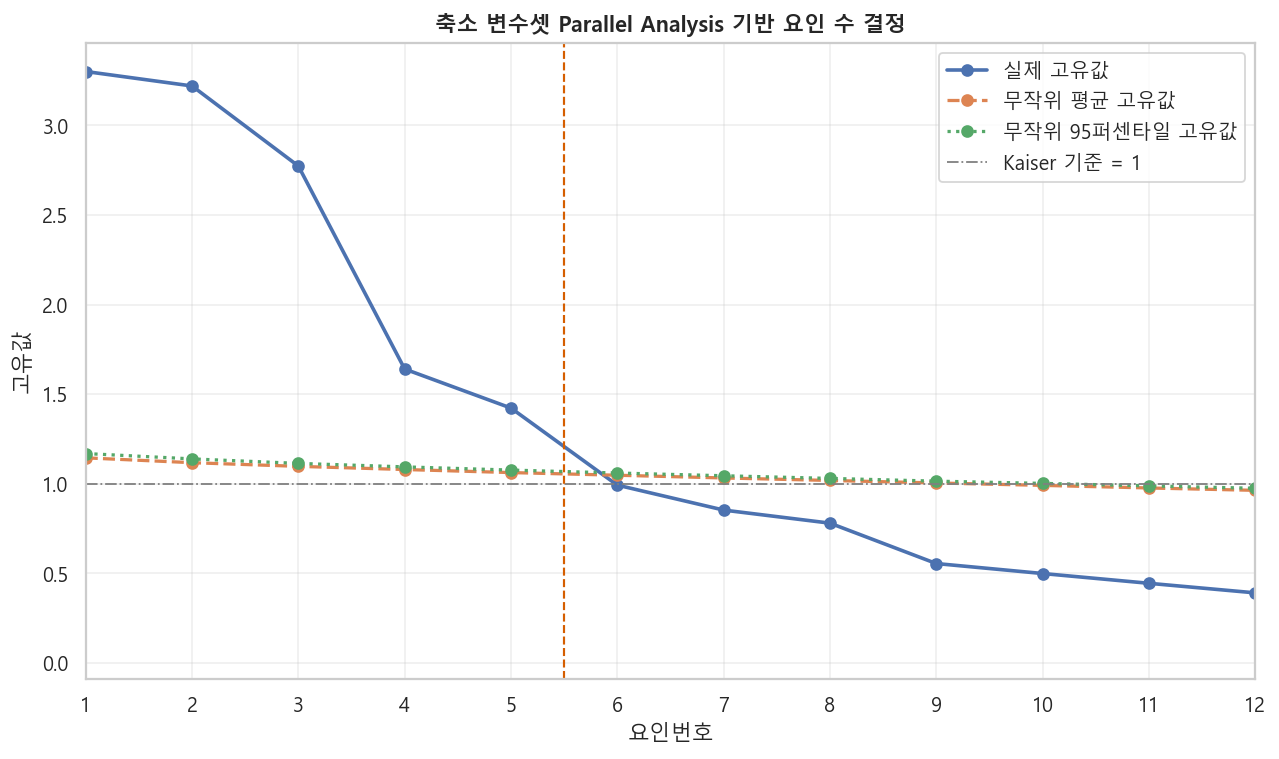

In [34]:
REDUCED_N_PARALLEL_ITER = globals().get("N_PARALLEL_ITER", 500)
REDUCED_PARALLEL_PERCENTILE = globals().get("PARALLEL_PERCENTILE", 95)
base_random_state = globals().get("RANDOM_STATE", 20260608)

reduced_parallel_X = reduced_fa_fit_X.copy()
reduced_parallel_X = reduced_parallel_X.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
reduced_parallel_X = reduced_parallel_X.loc[:, reduced_parallel_X.nunique(dropna=True) > 1]

reduced_n_obs, reduced_n_vars = reduced_parallel_X.shape
reduced_observed_corr = reduced_parallel_X.corr().to_numpy()
reduced_observed_eigen = np.linalg.eigvalsh(reduced_observed_corr)[::-1]

reduced_rng = np.random.default_rng(base_random_state + 101)
reduced_random_eigen = np.empty((REDUCED_N_PARALLEL_ITER, reduced_n_vars))

for i in range(REDUCED_N_PARALLEL_ITER):
    random_data = reduced_rng.normal(size=(reduced_n_obs, reduced_n_vars))
    random_corr = np.corrcoef(random_data, rowvar=False)
    reduced_random_eigen[i] = np.linalg.eigvalsh(random_corr)[::-1]

reduced_random_mean = reduced_random_eigen.mean(axis=0)
reduced_random_p95 = np.percentile(
    reduced_random_eigen,
    REDUCED_PARALLEL_PERCENTILE,
    axis=0,
)

reduced_pa_table = pd.DataFrame(
    {
        "요인번호": np.arange(1, reduced_n_vars + 1),
        "observed_eigenvalue": reduced_observed_eigen,
        "random_mean": reduced_random_mean,
        "random_p95": reduced_random_p95,
        "observed_gt_random_mean": reduced_observed_eigen > reduced_random_mean,
        "observed_gt_random_p95": reduced_observed_eigen > reduced_random_p95,
        "kaiser_gt_1": reduced_observed_eigen > 1,
    }
)

reduced_pa_n_factors_mean = int(reduced_pa_table["observed_gt_random_mean"].sum())
reduced_pa_n_factors_p95 = int(reduced_pa_table["observed_gt_random_p95"].sum())
reduced_kaiser_n_factors = int(reduced_pa_table["kaiser_gt_1"].sum())
REDUCED_FA_N_FACTORS = max(2, min(reduced_pa_n_factors_p95, reduced_n_vars - 1))

reduced_pa_summary = pd.DataFrame(
    {
        "기준": [
            "Parallel Analysis 95퍼센타일 기준",
            "Parallel Analysis 평균 기준",
            "Kaiser 기준(eigenvalue > 1)",
            "재FA 적용 요인 수",
        ],
        "요인 수": [
            reduced_pa_n_factors_p95,
            reduced_pa_n_factors_mean,
            reduced_kaiser_n_factors,
            REDUCED_FA_N_FACTORS,
        ],
    }
)

display(
    pd.DataFrame(
        {
            "항목": ["표본 수", "변수 수", "무작위 반복 수", "무작위 고유값 기준 퍼센타일"],
            "값": [
                reduced_n_obs,
                reduced_n_vars,
                REDUCED_N_PARALLEL_ITER,
                REDUCED_PARALLEL_PERCENTILE,
            ],
        }
    )
)
display(reduced_pa_summary)
display(Markdown("### 축소 변수셋 Parallel Analysis 고유값 비교표"))
display(reduced_pa_table.head(12).round(4))

fig, ax = plt.subplots(figsize=(10, 6), dpi=130)
ax.plot(
    reduced_pa_table["요인번호"],
    reduced_pa_table["observed_eigenvalue"],
    marker="o",
    linewidth=2,
    label="실제 고유값",
)
ax.plot(
    reduced_pa_table["요인번호"],
    reduced_pa_table["random_mean"],
    marker="o",
    linewidth=1.8,
    linestyle="--",
    label="무작위 평균 고유값",
)
ax.plot(
    reduced_pa_table["요인번호"],
    reduced_pa_table["random_p95"],
    marker="o",
    linewidth=1.8,
    linestyle=":",
    label=f"무작위 {REDUCED_PARALLEL_PERCENTILE}퍼센타일 고유값",
)
ax.axhline(1, color="gray", linewidth=1, linestyle="-.", label="Kaiser 기준 = 1")
ax.axvline(REDUCED_FA_N_FACTORS + 0.5, color="#D55E00", linewidth=1.2, linestyle="--")
ax.set_title("축소 변수셋 Parallel Analysis 기반 요인 수 결정", fontweight="bold")
ax.set_xlabel("요인번호")
ax.set_ylabel("고유값")
ax.set_xticks(reduced_pa_table["요인번호"])
ax.set_xlim(1, min(reduced_n_vars, 12))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 축소 변수셋 재FA: Promax 회전

요인 수는 축소 변수셋의 Parallel Analysis 결과를 사용한다. 회전 방식은 기존 결론과 해석 연속성을 위해 `promax`를 주 분석으로 사용하고, `varimax`는 비교용으로 함께 확인한다.


In [35]:
REDUCED_PRIMARY_LOADING_CUTOFF = 0.40
REDUCED_CROSS_LOADING_CUTOFF = 0.30
REDUCED_FA_ROTATIONS = ["varimax", "promax"]

reduced_fa_rotation_X = reduced_fa_fit_X.copy()
reduced_fa_rotation_X = reduced_fa_rotation_X.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
reduced_fa_rotation_X = reduced_fa_rotation_X.loc[:, reduced_fa_rotation_X.nunique(dropna=True) > 1]
reduced_fa_rotation_Z = (
    (reduced_fa_rotation_X - reduced_fa_rotation_X.mean())
    / reduced_fa_rotation_X.std(ddof=0)
)
reduced_fa_rotation_Z = reduced_fa_rotation_Z.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

reduced_factor_names = [f"RF{i}" for i in range(1, REDUCED_FA_N_FACTORS + 1)]


def fit_reduced_rotated_fa(rotation):
    model = FactorAnalyzer(n_factors=REDUCED_FA_N_FACTORS, rotation=rotation, method="minres")
    model.fit(reduced_fa_rotation_Z)

    loadings = pd.DataFrame(
        model.loadings_,
        index=reduced_fa_rotation_Z.columns,
        columns=reduced_factor_names,
    )
    communalities = pd.Series(
        model.get_communalities(),
        index=reduced_fa_rotation_Z.columns,
        name="공통성",
    )
    uniquenesses = pd.Series(
        model.get_uniquenesses(),
        index=reduced_fa_rotation_Z.columns,
        name="고유성",
    )

    variance, prop_var, cum_var = model.get_factor_variance()
    variance_table = pd.DataFrame(
        {
            "요인": reduced_factor_names,
            "SS_Loadings": variance,
            "Proportion_Var": prop_var,
            "Cumulative_Var": cum_var,
        }
    )

    phi = getattr(model, "phi_", None)
    if phi is None:
        phi_table = pd.DataFrame(
            np.eye(REDUCED_FA_N_FACTORS),
            index=reduced_factor_names,
            columns=reduced_factor_names,
        )
    else:
        phi_table = pd.DataFrame(phi, index=reduced_factor_names, columns=reduced_factor_names)

    abs_loadings = loadings.abs()
    loading_detail = pd.DataFrame(
        {
            "변수": loadings.index,
            "주요인": abs_loadings.idxmax(axis=1),
            "주적재량": loadings.to_numpy()[
                np.arange(loadings.shape[0]),
                abs_loadings.values.argmax(axis=1),
            ],
            "주적재량_abs": abs_loadings.max(axis=1).values,
            "적재량_0.30이상_개수": (abs_loadings >= REDUCED_CROSS_LOADING_CUTOFF).sum(axis=1).values,
            "적재량_0.40이상_개수": (abs_loadings >= REDUCED_PRIMARY_LOADING_CUTOFF).sum(axis=1).values,
            "공통성": communalities.values,
            "고유성": uniquenesses.values,
        }
    )
    loading_detail["교차적재_후보"] = loading_detail["적재량_0.30이상_개수"] >= 2
    loading_detail["약한_주적재"] = loading_detail["주적재량_abs"] < REDUCED_PRIMARY_LOADING_CUTOFF

    off_diag = phi_table.where(~np.eye(REDUCED_FA_N_FACTORS, dtype=bool))
    max_factor_corr = off_diag.abs().max().max()
    factor_corr_ge_030 = int((off_diag.abs() >= 0.30).sum().sum() / 2)

    summary = {
        "rotation": rotation,
        "n_obs": len(reduced_fa_rotation_Z),
        "n_vars": reduced_fa_rotation_Z.shape[1],
        "n_factors": REDUCED_FA_N_FACTORS,
        "mean_communality": communalities.mean(),
        "min_communality": communalities.min(),
        "communality_lt_020_n": int((communalities < 0.20).sum()),
        "communality_gt_1_n": int((communalities > 1.00).sum()),
        "negative_uniqueness_n": int((uniquenesses < 0).sum()),
        "weak_primary_loading_n": int(loading_detail["약한_주적재"].sum()),
        "cross_loading_n": int(loading_detail["교차적재_후보"].sum()),
        "min_salient_vars_per_factor": int((abs_loadings >= REDUCED_PRIMARY_LOADING_CUTOFF).sum(axis=0).min()),
        "max_abs_factor_corr": float(max_factor_corr) if pd.notna(max_factor_corr) else 0.0,
        "factor_corr_ge_030_n": factor_corr_ge_030,
        "cumulative_variance": float(variance_table["Cumulative_Var"].iloc[-1]),
    }

    return {
        "model": model,
        "loadings": loadings,
        "abs_loadings": abs_loadings,
        "loading_detail": loading_detail,
        "communalities": communalities,
        "uniquenesses": uniquenesses,
        "variance": variance_table,
        "phi": phi_table,
        "summary": summary,
    }


reduced_rotation_results = {
    rotation: fit_reduced_rotated_fa(rotation)
    for rotation in REDUCED_FA_ROTATIONS
}
reduced_rotation_summary = pd.DataFrame(
    [reduced_rotation_results[rotation]["summary"] for rotation in REDUCED_FA_ROTATIONS]
)

reduced_selected_rotation = "promax"
reduced_selected_fa = reduced_rotation_results[reduced_selected_rotation]
reduced_selected_loading_detail = (
    reduced_selected_fa["loading_detail"]
    .sort_values(["주요인", "주적재량_abs"], ascending=[True, False])
    .reset_index(drop=True)
)

display(Markdown("### 축소 변수셋 회전 방식 비교 요약"))
display(reduced_rotation_summary.round(4))

display(Markdown("### 축소 변수셋 Promax 요인상관 행렬"))
display(reduced_selected_fa["phi"].round(3))

display(Markdown("### 축소 변수셋 Promax 변수별 주적재량"))
display(reduced_selected_loading_detail.round(4))

reduced_salient_loadings = (
    reduced_selected_fa["loadings"]
    .reset_index(names="변수")
    .melt(id_vars="변수", var_name="요인", value_name="적재량")
)
reduced_salient_loadings["적재량_abs"] = reduced_salient_loadings["적재량"].abs()
reduced_salient_loadings = (
    reduced_salient_loadings[
        reduced_salient_loadings["적재량_abs"] >= REDUCED_CROSS_LOADING_CUTOFF
    ]
    .sort_values(["요인", "적재량_abs"], ascending=[True, False])
    .reset_index(drop=True)
)

display(Markdown("### 축소 변수셋 요인별 |loading| >= 0.30 변수"))
display(reduced_salient_loadings.round(4))

reduced_cross_or_weak = reduced_selected_loading_detail[
    reduced_selected_loading_detail["교차적재_후보"]
    | reduced_selected_loading_detail["약한_주적재"]
].copy()
display(Markdown("### 축소 변수셋 교차적재 또는 약한 주적재 변수"))
display(reduced_cross_or_weak.round(4))

if len(reduced_cross_or_weak) > 0:
    display(Markdown("### 축소 변수셋 교차적재/약한 변수의 전체 loading"))
    display(reduced_selected_fa["loadings"].loc[reduced_cross_or_weak["변수"]].round(4))

reduced_fa_scores = pd.DataFrame(
    reduced_selected_fa["model"].transform(reduced_fa_rotation_Z),
    index=reduced_fa_rotation_Z.index,
    columns=reduced_factor_names,
)
reduced_fa_scores_source = pd.concat(
    [
        reduced_fa_meta_complete.loc[reduced_fa_scores.index].reset_index(drop=True),
        reduced_fa_scores.reset_index(drop=True),
    ],
    axis=1,
)

print("생성 객체:")
print("- reduced_selected_fa: 축소 변수셋 promax FA 결과")
print("- reduced_selected_loading_detail: 축소 변수셋 주적재/공통성 점검표")
print("- reduced_salient_loadings: 축소 변수셋 |loading| >= 0.30 적재표")
print("- reduced_fa_scores: 축소 변수셋 요인점수")
print("- reduced_fa_scores_source: 메타데이터 + 축소 변수셋 요인점수")


### 축소 변수셋 회전 방식 비교 요약

,rotation,n_obs,n_vars,n_factors,mean_communality,min_communality,communality_lt_020_n,communality_gt_1_n,negative_uniqueness_n,weak_primary_loading_n,cross_loading_n,min_salient_vars_per_factor,max_abs_factor_corr,factor_corr_ge_030_n,cumulative_variance
0,varimax,2670,18,5,0.5910,0.1376,1,0,0,1,2,3,0.0000,0,0.5910
1,promax,2670,18,5,0.6058,0.1582,1,2,2,1,1,3,0.4102,1,0.6058


### 축소 변수셋 Promax 요인상관 행렬

,RF1,RF2,RF3,RF4,RF5
RF1,1.000,-0.025,0.162,-0.410,0.034
RF2,-0.025,1.000,-0.069,-0.075,-0.241
RF3,0.162,-0.069,1.000,0.110,-0.053
RF4,-0.410,-0.075,0.110,1.000,0.001
RF5,0.034,-0.241,-0.053,0.001,1.000


### 축소 변수셋 Promax 변수별 주적재량

...

### 축소 변수셋 교차적재 또는 약한 주적재 변수

,변수,주요인,주적재량,주적재량_abs,적재량_0.30이상_개수,적재량_0.40이상_개수,공통성,고유성,교차적재_후보,약한_주적재
4,경사도(도),RF1,0.4216,0.4216,2,2,0.3520,0.6480,True,False
17,TPI(지형위치지수),RF5,0.2638,0.2638,0,0,0.1582,0.8418,False,True


### 축소 변수셋 교차적재/약한 변수의 전체 loading

,RF1,RF2,RF3,RF4,RF5
경사도(도),0.4216,-0.0102,-0.0120,0.0142,-0.4169
TPI(지형위치지수),0.2627,0.1069,-0.0824,-0.0377,0.2638


생성 객체:
- reduced_selected_fa: 축소 변수셋 promax FA 결과
- reduced_selected_loading_detail: 축소 변수셋 주적재/공통성 점검표
- reduced_salient_loadings: 축소 변수셋 |loading| >= 0.30 적재표
- reduced_fa_scores: 축소 변수셋 요인점수
- reduced_fa_scores_source: 메타데이터 + 축소 변수셋 요인점수


In [ ]:
reduced_summary_row = reduced_rotation_summary[
    reduced_rotation_summary["rotation"] == reduced_selected_rotation
].iloc[0]

reduced_factor_name_map = {
    "RF1": "생활권 이격-산림사면 입지",
    "RF2": "선행 습도/건조 상태",
    "RF3": "발생시점·직전24h 강풍",
    "RF4": "단기~72h 누적강수",
    "RF5": "임도 이격-저고도 지형",
}

reduced_factor_variable_summary = (
    reduced_salient_loadings.assign(
        변수_적재=lambda df: (
            df["변수"]
            + " ("
            + df["적재량"].map(lambda value: f"{value:.4f}")
            + ")"
        )
    )
    .groupby("요인", sort=False)["변수_적재"]
    .apply(lambda values: ", ".join(values))
    .reindex(reduced_factor_names)
    .reset_index()
    .rename(columns={"요인": "요인", "변수_적재": "주요 적재 변수"})
)
reduced_factor_variable_summary["요인명_해석"] = reduced_factor_variable_summary["요인"].map(
    reduced_factor_name_map
)
reduced_factor_variable_summary = reduced_factor_variable_summary[
    ["요인", "요인명_해석", "주요 적재 변수"]
]

reduced_cross_variables = reduced_selected_loading_detail.loc[
    reduced_selected_loading_detail["교차적재_후보"],
    "변수",
].tolist()
reduced_weak_variables = reduced_selected_loading_detail.loc[
    reduced_selected_loading_detail["약한_주적재"],
    "변수",
].tolist()


def _markdown_table(df, index=False):
    table_df = df.copy()
    if index:
        table_df = table_df.reset_index()

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, float):
            return f"{value:.4f}"
        return str(value).replace("|", "\\|").replace("\n", "<br>")

    columns = [str(col) for col in table_df.columns]
    rows = []
    rows.append("| " + " | ".join(columns) + " |")
    rows.append("| " + " | ".join(["---"] * len(columns)) + " |")
    for _, row in table_df.iterrows():
        rows.append("| " + " | ".join(fmt(row[col]) for col in table_df.columns) + " |")
    return "\n".join(rows)


def display_full_table(title, df, index=False):
    display(Markdown(f"### {title}"))
    display(Markdown(_markdown_table(df, index=index)))
    print(f"\n[{title}]")
    print(df.to_string(index=index))


reduced_fa_progress_markdown = f"""### 축소 변수셋 재FA 결과 요약

- 축소 변수셋은 {len(reduced_available_feature_cols)}개 변수, {len(reduced_fa_fit_X):,}개 완전케이스로 구성했다.
- KMO 전체 값은 {reduced_kmo_total:.4f}, Bartlett p-value는 {reduced_bartlett_p:.4g}이다.
- Parallel Analysis 95퍼센타일 기준은 {reduced_pa_n_factors_p95}개 요인, 평균 기준은 {reduced_pa_n_factors_mean}개 요인, Kaiser 기준은 {reduced_kaiser_n_factors}개 요인이다.
- 재FA는 {REDUCED_FA_N_FACTORS}요인 promax 해를 기준으로 진행했다.
- Promax 평균 공통성은 {reduced_summary_row['mean_communality']:.4f}, 누적 설명분산은 {reduced_summary_row['cumulative_variance']:.4f}이다.
- 공통성 1 초과 변수는 {int(reduced_summary_row['communality_gt_1_n'])}개, 음수 고유성 변수는 {int(reduced_summary_row['negative_uniqueness_n'])}개이다.
- 교차적재 후보는 {int(reduced_summary_row['cross_loading_n'])}개, 약한 주적재 변수는 {int(reduced_summary_row['weak_primary_loading_n'])}개이다.

아래 표는 문자열이 잘리지 않도록 Markdown 표와 `to_string()` 출력을 함께 제공한다.
"""

display(Markdown(reduced_fa_progress_markdown))

display_full_table("요인별 주요 적재 변수 전체 표시", reduced_factor_variable_summary)
display_full_table("Promax 변수별 주적재량 전체 표시", reduced_selected_loading_detail.round(4))
display_full_table("요인별 |loading| >= 0.30 전체 표시", reduced_salient_loadings.round(4))
display_full_table(
    "Promax 요인상관 행렬 전체 표시",
    reduced_selected_fa["phi"].round(4),
    index=True,
)

if len(reduced_cross_or_weak) > 0:
    display_full_table("교차적재 또는 약한 주적재 변수 전체 표시", reduced_cross_or_weak.round(4))
    display_full_table(
        "교차적재/약한 변수의 전체 loading 표시",
        reduced_selected_fa["loadings"].loc[reduced_cross_or_weak["변수"]].round(4),
        index=True,
    )

print("교차적재 후보:", reduced_cross_variables)
print("약한 주적재 변수:", reduced_weak_variables)


### 축소 변수셋 재FA 해석

#### 전체 판단

대표 시간창으로 축소한 재FA에서는 18개 변수에서 5요인 구조가 도출되었다. Parallel Analysis 95퍼센타일, 평균 기준, Kaiser 기준이 모두 5요인을 가리키므로 요인 수 판단은 1차 FA보다 명확하다.

`promax` 기준 평균 공통성은 0.6058, 누적 설명분산은 0.6058이다. 교차적재 후보는 `경사도(도)` 1개로 줄었고, 약한 주적재 변수는 `TPI(지형위치지수)` 1개만 남았다. 따라서 1차 FA의 큰 구조는 유지하면서 시간창 중복과 잔여 요인이 상당히 줄어든 해로 볼 수 있다.

다만 `D-1_최소습도_pct`와 `직전24h_최소습도`의 공통성이 1을 약간 넘고 고유성이 음수로 나타나므로, 습도 축에는 아직 Heywood 징후가 남아 있다. 두 변수의 상관이 높기 때문에 최종 확정 단계에서 둘 중 하나를 대표 변수로 더 줄이는 보조안을 검토할 수 있다.

#### 요인별 해석

| 요인 | 해석명 | 주요 적재 구조 | 해석 |
| --- | --- | --- | --- |
| RF1 | 생활권 이격-산림사면 입지 | 시가화거리 0.9221, 도로거리 0.9130, 산림거리 -0.5380, TWI -0.5139, 경사도 0.4216 | 점수가 높을수록 도로·시가화지역과 멀고, 산림에는 가까우며, TWI가 낮고 경사가 큰 산림 사면 입지에 가깝다. |
| RF2 | 선행 습도/건조 상태 | D-1 최소습도 1.0002, 직전24h 최소습도 0.9985, D-3 최소습도 0.4759, 시점 습도 0.4127 | 점수가 높을수록 습윤 상태이고, 산불 위험 해석에서는 점수가 낮을수록 선행 건조가 강한 상태로 해석한다. |
| RF3 | 발생시점·직전24h 강풍 | 직전24h 평균풍속 0.8734, 시점 풍속 0.8720, 당일 최대순간풍속 0.8522 | 발생시점의 바람, 직전 24시간 지속풍, 당일 돌풍이 하나의 안정적인 강풍 축으로 묶였다. |
| RF4 | 단기~72h 누적강수 | D-1 강수량합 0.9574, 직전24h 강수량합 0.9215, 직전72h 강수량합 0.7738 | 1차 FA에서 분리되던 단기 강수와 중기 누적강수가 하나의 강수 축으로 정리되었다. 점수가 낮을수록 최근 강수 부족 상태로 해석한다. |
| RF5 | 임도 이격-저고도 지형 | 임도거리 0.6797, 고도 -0.5610, 경사도 -0.4169 | 점수가 높을수록 임도와 멀고 고도·경사가 낮은 방향이다. 반대로 점수가 낮으면 고도가 높고 임도와 가까운 산지 접근성 성격이 강하다. |

#### 교차적재 및 약한 변수

`경사도(도)`는 RF1에 0.4216, RF5에 -0.4169로 교차적재된다. 따라서 경사도는 생활권-산림사면 입지와 고도-임도 지형을 동시에 연결하는 변수로 해석해야 하며, 한 요인에만 단독 귀속시키면 해석이 좁아진다.

`TPI(지형위치지수)`는 주적재량 0.2638, 공통성 0.1582로 약하다. 현재 축소 FA에서는 핵심 요인 변수라기보다 보조 지형 변수에 가깝다. 최종 모델을 더 단순하게 만들 경우 제거 후보로 둘 수 있다.

#### 1차 FA 대비 변화

- 기존 F1/F7로 갈라지던 습도 구조가 RF2 하나로 정리되었다.
- 기존 F3/F5로 나뉘던 강수 구조가 RF4 하나로 통합되었다.
- 풍속 요인은 RF3으로 매우 안정적으로 유지되었다.
- 사면방향 `sin/cos`는 둘 다 FA 핵심 변수에서 제외되어 방향 정보의 비대칭 제거 문제를 피했다.
- 등산로거리와 농업거리도 제외되어 공통요인성이 낮은 접근성 변수가 요인 해석을 흐리는 문제가 줄었다.

#### 다음 판단

현재 재FA 구조는 1차 탐색 FA보다 보고용 구조에 더 적합하다. 최종 해석은 주적재 기준으로 RF1~RF5 요인명을 사용하고, `경사도(도)`만 교차적재 변수로 주석 처리하는 방식이 적절하다.

단, Heywood 징후를 완전히 없애야 한다면 습도 대표 변수에서 `D-1_최소습도_pct`와 `직전24h_최소습도` 중 하나만 남긴 추가 민감도 분석을 수행한다.


## 요인점수 생성

축소 변수셋의 5요인 `promax` 해를 기준으로 factor score를 생성한다. 요인점수는 이후 메타데이터별 비교와 군집분석의 입력값으로 사용한다.

생성 객체는 다음과 같다.

- `factor_scores`: 원 FA 부호를 유지한 최종 요인점수 (`F1_score`~`F5_score`)
- `factor_scores_source`: 메타데이터와 원 부호 요인점수를 결합한 테이블
- `factor_scores_oriented`: 해석 방향을 맞춘 요인점수
- `factor_scores_oriented_source`: 메타데이터와 해석 방향 요인점수를 결합한 테이블
- `factor_scores_for_clustering`: 군집분석 입력용 요인점수

주의할 점은 FA 요인 부호가 통계적으로 임의적이라는 것이다. 그래서 원 부호 점수는 재현 가능한 산출물로 보존하고, 메타데이터 해석과 군집분석에는 해석 방향을 맞춘 점수를 함께 만든다.


In [37]:
required_factor_score_objects = [
    "reduced_selected_fa",
    "reduced_fa_rotation_Z",
    "reduced_fa_meta_complete",
    "reduced_factor_names",
]
missing_factor_score_objects = [
    name for name in required_factor_score_objects if name not in globals()
]
if missing_factor_score_objects:
    raise RuntimeError(
        "먼저 축소 변수셋 재FA 셀을 실행하세요. "
        f"누락 객체: {missing_factor_score_objects}"
    )

FINAL_FACTOR_NAME_MAP = {
    "RF1": "생활권 이격-산림사면 입지",
    "RF2": "선행 습도/건조 상태",
    "RF3": "발생시점·직전24h 강풍",
    "RF4": "단기~72h 누적강수",
    "RF5": "임도 이격-저고도 지형",
}

FINAL_FACTOR_RAW_DIRECTION_MAP = {
    "RF1": "높을수록 도로·시가화지역과 멀고 산림 사면 입지 성격이 강함",
    "RF2": "높을수록 습도가 높은 상태, 낮을수록 선행 건조가 강함",
    "RF3": "높을수록 발생시점·직전24h 강풍 성격이 강함",
    "RF4": "높을수록 최근 강수량이 많고, 낮을수록 강수 부족 상태",
    "RF5": "높을수록 임도와 멀고 저고도·완경사 방향, 낮을수록 고도 높고 임도 인접",
}

FINAL_FACTOR_ORIENTED_SCORE_MAP = {
    "RF1": ("생활권접점_score", -1, "높을수록 도로·시가화지역에 가까운 생활권 접점 성격"),
    "RF2": ("선행건조_score", -1, "높을수록 선행 건조가 강한 상태"),
    "RF3": ("강풍_score", 1, "높을수록 발생시점·직전24h 강풍 성격"),
    "RF4": ("강수부족_score", -1, "높을수록 최근 강수 부족 상태"),
    "RF5": ("산지접근성_score", -1, "높을수록 고도 높고 임도에 가까운 산지 접근성 성격"),
}

final_factor_order = list(reduced_factor_names)
final_score_columns = [f"F{i}_score" for i in range(1, len(final_factor_order) + 1)]
final_factor_to_score_col = dict(zip(final_factor_order, final_score_columns))

factor_score_values = reduced_selected_fa["model"].transform(reduced_fa_rotation_Z)
factor_scores = pd.DataFrame(
    factor_score_values,
    index=reduced_fa_rotation_Z.index,
    columns=final_score_columns,
)
factor_scores.index.name = "source_index"

factor_score_meta = reduced_fa_meta_complete.loc[factor_scores.index].copy()
factor_score_meta.index.name = "source_index"

factor_scores_source = pd.concat([factor_score_meta, factor_scores], axis=1)

factor_scores_oriented = pd.DataFrame(index=factor_scores.index)
for factor_name in final_factor_order:
    raw_col = final_factor_to_score_col[factor_name]
    oriented_col, sign, _ = FINAL_FACTOR_ORIENTED_SCORE_MAP[factor_name]
    factor_scores_oriented[oriented_col] = factor_scores[raw_col] * sign
factor_scores_oriented.index.name = "source_index"

factor_scores_oriented_source = pd.concat(
    [factor_score_meta, factor_scores_oriented],
    axis=1,
)

factor_scores_for_clustering = factor_scores_oriented.copy()
factor_score_cols = factor_scores.columns.tolist()
oriented_factor_score_cols = factor_scores_oriented.columns.tolist()

factor_score_direction = pd.DataFrame(
    [
        {
            "원요인": factor_name,
            "원점수컬럼": final_factor_to_score_col[factor_name],
            "요인명": FINAL_FACTOR_NAME_MAP[factor_name],
            "원점수_높을수록": FINAL_FACTOR_RAW_DIRECTION_MAP[factor_name],
            "해석방향점수컬럼": FINAL_FACTOR_ORIENTED_SCORE_MAP[factor_name][0],
            "해석방향": FINAL_FACTOR_ORIENTED_SCORE_MAP[factor_name][2],
            "변환": (
                "원점수 그대로"
                if FINAL_FACTOR_ORIENTED_SCORE_MAP[factor_name][1] == 1
                else "원점수 * -1"
            ),
        }
        for factor_name in final_factor_order
    ]
)

factor_score_summary = factor_scores.describe().T
factor_score_summary["skew"] = factor_scores.skew()
factor_score_summary["kurtosis"] = factor_scores.kurtosis()
factor_score_summary = factor_score_summary.reset_index(names="점수컬럼")

factor_score_oriented_summary = factor_scores_oriented.describe().T
factor_score_oriented_summary["skew"] = factor_scores_oriented.skew()
factor_score_oriented_summary["kurtosis"] = factor_scores_oriented.kurtosis()
factor_score_oriented_summary = factor_score_oriented_summary.reset_index(names="점수컬럼")


def markdown_table_full(df, index=False, float_digits=4):
    table_df = df.copy()
    if index:
        table_df = table_df.reset_index()

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, float):
            return f"{value:.{float_digits}f}"
        return str(value).replace("|", "\\|").replace("\n", "<br>")

    columns = [str(col) for col in table_df.columns]
    rows = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for _, row in table_df.iterrows():
        rows.append("| " + " | ".join(fmt(row[col]) for col in table_df.columns) + " |")
    return "\n".join(rows)


def display_full_table(title, df, index=False, float_digits=4):
    display(Markdown(f"### {title}"))
    display(Markdown(markdown_table_full(df, index=index, float_digits=float_digits)))
    print(f"\n[{title}]")
    print(df.to_string(index=index))


FA_OUTPUT_DIR = ROOT / "jsw" / "Analysis" / "outputs"
FA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

factor_scores_source_path = FA_OUTPUT_DIR / "2026-06-08_FA_factor_scores_raw.csv"
factor_scores_oriented_source_path = FA_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"
factor_score_direction_path = FA_OUTPUT_DIR / "2026-06-08_FA_factor_score_direction.csv"

factor_scores_source.to_csv(factor_scores_source_path, encoding="utf-8-sig")
factor_scores_oriented_source.to_csv(factor_scores_oriented_source_path, encoding="utf-8-sig")
factor_score_direction.to_csv(factor_score_direction_path, index=False, encoding="utf-8-sig")

display_full_table("요인점수 방향 해석표", factor_score_direction)
display_full_table("원 부호 요인점수 요약", factor_score_summary.round(4))
display_full_table("해석 방향 요인점수 요약", factor_score_oriented_summary.round(4))

display(Markdown("### 요인점수 미리보기"))
display(factor_scores_source.head(20))

display(Markdown("### 해석 방향 요인점수 미리보기"))
display(factor_scores_oriented_source.head(20))

print("생성 객체:")
print("- factor_scores: 원 부호 최종 요인점수")
print("- factor_scores_source: 메타데이터 + 원 부호 최종 요인점수")
print("- factor_scores_oriented: 해석 방향 요인점수")
print("- factor_scores_oriented_source: 메타데이터 + 해석 방향 요인점수")
print("- factor_scores_for_clustering: 군집분석 입력용 요인점수")
print("- factor_score_direction: 요인점수 방향 해석표")
print()
print("저장 파일:")
print(f"- {factor_scores_source_path}")
print(f"- {factor_scores_oriented_source_path}")
print(f"- {factor_score_direction_path}")
print()
print("군집분석 입력 컬럼:", oriented_factor_score_cols)


### 요인점수 방향 해석표

| 원요인 | 원점수컬럼 | 요인명 | 원점수_높을수록 | 해석방향점수컬럼 | 해석방향 | 변환 |
| --- | --- | --- | --- | --- | --- | --- |
| RF1 | F1_score | 생활권 이격-산림사면 입지 | 높을수록 도로·시가화지역과 멀고 산림 사면 입지 성격이 강함 | 생활권접점_score | 높을수록 도로·시가화지역에 가까운 생활권 접점 성격 | 원점수 * -1 |
| RF2 | F2_score | 선행 습도/건조 상태 | 높을수록 습도가 높은 상태, 낮을수록 선행 건조가 강함 | 선행건조_score | 높을수록 선행 건조가 강한 상태 | 원점수 * -1 |
| RF3 | F3_score | 발생시점·직전24h 강풍 | 높을수록 발생시점·직전24h 강풍 성격이 강함 | 강풍_score | 높을수록 발생시점·직전24h 강풍 성격 | 원점수 그대로 |
| RF4 | F4_score | 단기~72h 누적강수 | 높을수록 최근 강수량이 많고, 낮을수록 강수 부족 상태 | 강수부족_score | 높을수록 최근 강수 부족 상태 | 원점수 * -1 |
| RF5 | F5_score | 임도 이격-저고도 지형 | 높을수록 임도와 멀고 저고도·완경사 방향, 낮을수록 고도 높고 임도 인접 | 산지접근성_score | 높을수록 고도 높고 임도에 가까운 산지 접근성 성격 | 원점수 * -1 |


[요인점수 방향 해석표]
원요인    원점수컬럼            요인명                                 원점수_높을수록    해석방향점수컬럼                         해석방향       변환
RF1 F1_score 생활권 이격-산림사면 입지        높을수록 도로·시가화지역과 멀고 산림 사면 입지 성격이 강함 생활권접점_score 높을수록 도로·시가화지역에 가까운 생활권 접점 성격 원점수 * -1
RF2 F2_score    선행 습도/건조 상태           높을수록 습도가 높은 상태, 낮을수록 선행 건조가 강함  선행건조_score            높을수록 선행 건조가 강한 상태 원점수 * -1
RF3 F3_score  발생시점·직전24h 강풍                높을수록 발생시점·직전24h 강풍 성격이 강함    강풍_score        높을수록 발생시점·직전24h 강풍 성격  원점수 그대로
RF4 F4_score    단기~72h 누적강수           높을수록 최근 강수량이 많고, 낮을수록 강수 부족 상태  강수부족_score             높을수록 최근 강수 부족 상태 원점수 * -1
RF5 F5_score   임도 이격-저고도 지형 높을수록 임도와 멀고 저고도·완경사 방향, 낮을수록 고도 높고 임도 인접 산지접근성_score 높을수록 고도 높고 임도에 가까운 산지 접근성 성격 원점수 * -1


### 원 부호 요인점수 요약

| 점수컬럼 | count | mean | std | min | 25% | 50% | 75% | max | skew | kurtosis |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| F1_score | 2670.0000 | 0.0000 | 0.9500 | -1.4940 | -0.8184 | -0.2626 | 0.6311 | 3.4153 | 0.9047 | 0.1686 |
| F2_score | 2670.0000 | 0.0000 | 0.9811 | -2.0154 | -0.6667 | -0.0902 | 0.5069 | 4.3640 | 0.8735 | 1.0705 |
| F3_score | 2670.0000 | 0.0000 | 0.9445 | -1.8802 | -0.8048 | -0.0970 | 0.7568 | 4.5591 | 0.6411 | 0.5890 |
| F4_score | 2670.0000 | -0.0000 | 0.9757 | -0.3850 | -0.1791 | -0.1403 | -0.0650 | 31.9643 | 27.0548 | 866.1400 |
| F5_score | 2670.0000 | 0.0000 | 0.8199 | -4.4979 | -0.4898 | 0.1358 | 0.6427 | 1.5441 | -1.1881 | 2.2899 |

...

### 요인점수 미리보기

,fire_id,발생일시,기상셀ID,기후권역,기후지형유형,addr_type,기후지형_번지유형,월_key,시간_key,산불위험계절,발생시간대구분,L1_NAME,L2_NAME,생활권프록시,원인프록시_500m,F1_score,F2_score,F3_score,F4_score,F5_score
source_index,,,,,,,,,,,,,,,,,,,,
0,F_003556,2020-04-30 18:00:00,YS_0064,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),4,18,산불위험계절(11~5월),저녁(18~23시),산림지역,활엽수림,비인접,기타 인간활동 발화 후보,2.768149,-0.507630,0.520273,-0.178606,-0.710586
1,F_006688,2020-04-30 18:00:00,YS_0064,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),4,18,산불위험계절(11~5월),저녁(18~23시),산림지역,활엽수림,비인접,기타 인간활동 발화 후보,2.768149,-0.507630,0.520273,-0.178606,-0.710586
5,F_007618,2020-01-04 13:00:00,YS_0037,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),1,13,산불위험계절(11~5월),한낮(10~13시),산림지역,침엽수림,도로/시가화/농업 인접,기타 인간활동 발화 후보,2.061195,-0.350059,-0.870964,-0.119556,-1.337774
6,F_007619,2020-01-04 13:00:00,YS_0037,영서,영서 내륙형,일반번지,영서 내륙형 / 일반번지,1,13,산불위험계절(11~5월),한낮(10~13시),초지,인공초지,도로/시가화/농업 인접,기타 인간활동 발화 후보,0.055026,-0.208224,-0.854799,-0.147131,-0.507055
7,F_007620,2020-01-04 15:00:00,YS_0037,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),1,15,산불위험계절(11~5월),오후(14~17시),나지,인공나지,도로/시가화/농업 인접,입산활동 발화 후보,2.013945,-0.182940,-0.862153,-0.215273,-0.816550
8,F_007621,2020-01-04 14:00:00,YS_0019,영서,고지·산간형,일반번지,고지·산간형 / 일반번지,1,14,산불위험계절(11~5월),오후(14~17시),초지,인공초지,도로/시가화/농업 인접,기타 인간활동 발화 후보,0.370581,0.298637,-0.059688,-0.189655,0.547562
10,F_007623,2020-01-06 12:00:00,YS_0037,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),1,12,산불위험계절(11~5월),한낮(10~13시),산림지역,혼효림,비인접,입산활동 발화 후보,2.509147,0.053530,-1.473465,-0.178562,-0.832429
11,F_007624,2020-01-15 13:00:00,YD_0020,영동,영동 해안형,일반번지,영동 해안형 / 일반번지,1,13,산불위험계절(11~5월),한낮(10~13시),시가화건조지역,도로,도로/시가화/농업 인접,기타 인간활동 발화 후보,-1.131782,-0.277992,0.727581,-0.104500,0.268671
12,F_007625,2020-01-20 17:00:00,YS_0008,영서,영서 내륙형,일반번지,영서 내륙형 / 일반번지,1,17,산불위험계절(11~5월),오후(14~17시),초지,인공초지,도로/시가화/농업 인접,입산활동 발화 후보,0.067003,0.589322,-0.013386,-0.143843,-1.610251


### 해석 방향 요인점수 미리보기

,fire_id,발생일시,기상셀ID,기후권역,기후지형유형,addr_type,기후지형_번지유형,월_key,시간_key,산불위험계절,발생시간대구분,L1_NAME,L2_NAME,생활권프록시,원인프록시_500m,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
source_index,,,,,,,,,,,,,,,,,,,,
0,F_003556,2020-04-30 18:00:00,YS_0064,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),4,18,산불위험계절(11~5월),저녁(18~23시),산림지역,활엽수림,비인접,기타 인간활동 발화 후보,-2.768149,0.507630,0.520273,0.178606,0.710586
1,F_006688,2020-04-30 18:00:00,YS_0064,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),4,18,산불위험계절(11~5월),저녁(18~23시),산림지역,활엽수림,비인접,기타 인간활동 발화 후보,-2.768149,0.507630,0.520273,0.178606,0.710586
5,F_007618,2020-01-04 13:00:00,YS_0037,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),1,13,산불위험계절(11~5월),한낮(10~13시),산림지역,침엽수림,도로/시가화/농업 인접,기타 인간활동 발화 후보,-2.061195,0.350059,-0.870964,0.119556,1.337774
6,F_007619,2020-01-04 13:00:00,YS_0037,영서,영서 내륙형,일반번지,영서 내륙형 / 일반번지,1,13,산불위험계절(11~5월),한낮(10~13시),초지,인공초지,도로/시가화/농업 인접,기타 인간활동 발화 후보,-0.055026,0.208224,-0.854799,0.147131,0.507055
7,F_007620,2020-01-04 15:00:00,YS_0037,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),1,15,산불위험계절(11~5월),오후(14~17시),나지,인공나지,도로/시가화/농업 인접,입산활동 발화 후보,-2.013945,0.182940,-0.862153,0.215273,0.816550
8,F_007621,2020-01-04 14:00:00,YS_0019,영서,고지·산간형,일반번지,고지·산간형 / 일반번지,1,14,산불위험계절(11~5월),오후(14~17시),초지,인공초지,도로/시가화/농업 인접,기타 인간활동 발화 후보,-0.370581,-0.298637,-0.059688,0.189655,-0.547562
10,F_007623,2020-01-06 12:00:00,YS_0037,영서,영서 내륙형,임야번지(산),영서 내륙형 / 임야번지(산),1,12,산불위험계절(11~5월),한낮(10~13시),산림지역,혼효림,비인접,입산활동 발화 후보,-2.509147,-0.053530,-1.473465,0.178562,0.832429
11,F_007624,2020-01-15 13:00:00,YD_0020,영동,영동 해안형,일반번지,영동 해안형 / 일반번지,1,13,산불위험계절(11~5월),한낮(10~13시),시가화건조지역,도로,도로/시가화/농업 인접,기타 인간활동 발화 후보,1.131782,0.277992,0.727581,0.104500,-0.268671
12,F_007625,2020-01-20 17:00:00,YS_0008,영서,영서 내륙형,일반번지,영서 내륙형 / 일반번지,1,17,산불위험계절(11~5월),오후(14~17시),초지,인공초지,도로/시가화/농업 인접,입산활동 발화 후보,-0.067003,-0.589322,-0.013386,0.143843,1.610251


생성 객체:
- factor_scores: 원 부호 최종 요인점수
- factor_scores_source: 메타데이터 + 원 부호 최종 요인점수
- factor_scores_oriented: 해석 방향 요인점수
- factor_scores_oriented_source: 메타데이터 + 해석 방향 요인점수
- factor_scores_for_clustering: 군집분석 입력용 요인점수
- factor_score_direction: 요인점수 방향 해석표

저장 파일:
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_factor_scores_raw.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_factor_scores_oriented.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_factor_score_direction.csv

군집분석 입력 컬럼: ['생활권접점_score', '선행건조_score', '강풍_score', '강수부족_score', '산지접근성_score']


### 요인점수 사용 기준

`factor_scores`는 FA 모델에서 나온 원 부호 점수이다. 원 부호 기준으로는 `F2_score`가 높을수록 습윤, `F4_score`가 높을수록 강수량이 많은 상태이므로 산불 위험 방향과 반대인 축이 있다.

메타데이터별 해석과 군집분석에는 `factor_scores_oriented` 또는 `factor_scores_for_clustering`을 우선 사용한다. 이 테이블은 해석이 직관적이도록 다음 방향으로 부호를 맞췄다.

| 해석 방향 점수 | 의미 |
| --- | --- |
| `생활권접점_score` | 높을수록 도로·시가화지역에 가까운 생활권 접점 성격 |
| `선행건조_score` | 높을수록 선행 건조가 강한 상태 |
| `강풍_score` | 높을수록 발생시점·직전24h 강풍 성격 |
| `강수부족_score` | 높을수록 최근 강수 부족 상태 |
| `산지접근성_score` | 높을수록 고도가 높고 임도에 가까운 산지 접근성 성격 |

부호 반전은 축의 방향만 바꾸는 것이므로 KMeans 같은 거리 기반 군집분석의 거리 구조는 변하지 않는다. 따라서 이후 군집분석에서는 `factor_scores_for_clustering`을 입력으로 사용한다.


## 4. 메타데이터별 요인점수 해석

군집분석으로 넘어가기 전에 최종 요인점수가 기존 EDA 결론과 맞게 움직이는지 메타데이터별로 검증한다.

이 단계에서는 원 부호 요인점수가 아니라 해석 방향을 맞춘 `factor_scores_oriented_source`를 사용한다.

비교 대상은 `기후지형유형`, `기후권역`, `addr_type`, `기후지형_번지유형`, `발생시간대구분`, `산불위험계절`, `L1_NAME`, `L2_NAME`, `원인프록시_500m`이다.

해석 원칙은 다음과 같다.

- 전체 결과는 CSV로 저장하고, 노트북 화면에는 표본 수 기준을 통과한 핵심 차이를 중심으로 표시한다.
- `평균차_sd`는 그룹 평균이 전체 평균에서 몇 표준편차만큼 벗어났는지를 본다.
- `평균차_sd >= 0.30`이면 상대적으로 높음, `평균차_sd <= -0.30`이면 상대적으로 낮음으로 해석한다.
- `강수부족_score`는 큰 음수 이상값이 있으므로 평균뿐 아니라 중앙값도 함께 확인한다.
- `L2_NAME`처럼 표본 수가 작은 세부 그룹은 확정 결론이 아니라 후보 패턴으로 본다.


In [38]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print

    def Markdown(text):
        return text


if "ROOT" not in globals():
    ROOT = Path.cwd()
    for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
        if (candidate / "data").exists() and (candidate / "jsw").exists():
            ROOT = candidate
            break

FA_OUTPUT_DIR = ROOT / "jsw" / "Analysis" / "outputs"
FA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

factor_scores_oriented_source_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"
)

if "factor_scores_oriented_source" in globals():
    metadata_score_source = factor_scores_oriented_source.copy()
else:
    if not factor_scores_oriented_source_path.exists():
        raise FileNotFoundError(
            "해석 방향 요인점수 CSV가 없습니다. "
            "먼저 `## 요인점수 생성` 셀을 실행하세요."
        )
    metadata_score_source = pd.read_csv(
        factor_scores_oriented_source_path,
        encoding="utf-8-sig",
    )

META_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]

META_COMPARE_COLS = [
    "기후지형유형",
    "기후권역",
    "addr_type",
    "기후지형_번지유형",
    "발생시간대구분",
    "산불위험계절",
    "L1_NAME",
    "L2_NAME",
    "원인프록시_500m",
]

MIN_GROUP_N_FOR_TEST = 5
MIN_GROUP_N_FOR_RANK = 10
EFFECT_THRESHOLD_SD = 0.30

missing_score_cols = [
    col for col in META_SCORE_COLS if col not in metadata_score_source.columns
]
if missing_score_cols:
    raise KeyError(f"요인점수 컬럼이 없습니다: {missing_score_cols}")

metadata_score_source[META_SCORE_COLS] = metadata_score_source[META_SCORE_COLS].apply(
    pd.to_numeric,
    errors="coerce",
)

available_meta_compare_cols = [
    col for col in META_COMPARE_COLS if col in metadata_score_source.columns
]
missing_meta_compare_cols = [
    col for col in META_COMPARE_COLS if col not in metadata_score_source.columns
]
if not available_meta_compare_cols:
    raise KeyError("사용 가능한 메타데이터 컬럼이 없습니다.")

score_overall = metadata_score_source[META_SCORE_COLS].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T
score_overall = score_overall.rename(
    columns={
        "count": "n",
        "mean": "전체평균",
        "median": "전체중앙값",
        "std": "전체표준편차",
        "min": "전체최소",
        "max": "전체최대",
    }
)
score_overall["왜도"] = metadata_score_source[META_SCORE_COLS].skew()
score_overall["첨도"] = metadata_score_source[META_SCORE_COLS].kurtosis()

print("메타데이터별 요인점수 분석 입력")
print("- 행 수:", len(metadata_score_source))
print("- 사용 메타데이터:", available_meta_compare_cols)
print("- 누락 메타데이터:", missing_meta_compare_cols)
print("- 사용 요인점수:", META_SCORE_COLS)
print("- 검정 최소 그룹 표본 수:", MIN_GROUP_N_FOR_TEST)
print("- Top/Bottom 표시 최소 그룹 표본 수:", MIN_GROUP_N_FOR_RANK)


메타데이터별 요인점수 분석 입력
- 행 수: 2670
- 사용 메타데이터: ['기후지형유형', '기후권역', 'addr_type', '기후지형_번지유형', '발생시간대구분', '산불위험계절', 'L1_NAME', 'L2_NAME', '원인프록시_500m']
- 누락 메타데이터: []
- 사용 요인점수: ['생활권접점_score', '선행건조_score', '강풍_score', '강수부족_score', '산지접근성_score']
- 검정 최소 그룹 표본 수: 5
- Top/Bottom 표시 최소 그룹 표본 수: 10


In [39]:
def classify_delta_sd(value, threshold=EFFECT_THRESHOLD_SD):
    if pd.isna(value):
        return "판정불가"
    if value >= threshold:
        return "높음"
    if value <= -threshold:
        return "낮음"
    return "전체 평균과 큰 차이 작음"


def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    q = np.full(p.shape, np.nan, dtype=float)
    valid_mask = np.isfinite(p)
    if not valid_mask.any():
        return q

    valid_idx = np.where(valid_mask)[0]
    valid_p = p[valid_mask]
    order = np.argsort(valid_p)
    sorted_p = valid_p[order]
    m = len(sorted_p)
    ranks = np.arange(1, m + 1)
    adjusted = sorted_p * m / ranks
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    q[valid_idx[order]] = adjusted
    return q


summary_records = []
for meta_col in available_meta_compare_cols:
    meta_values = metadata_score_source[meta_col].fillna("(결측)").astype(str)
    work = metadata_score_source[META_SCORE_COLS].copy()
    work["_group"] = meta_values

    for group_value, group_df in work.groupby("_group", dropna=False, sort=True):
        group_n = len(group_df)
        share_pct = group_n / len(metadata_score_source) * 100
        for score_col in META_SCORE_COLS:
            values = group_df[score_col].dropna()
            overall_mean = score_overall.loc[score_col, "전체평균"]
            overall_median = score_overall.loc[score_col, "전체중앙값"]
            overall_std = score_overall.loc[score_col, "전체표준편차"]
            mean_value = values.mean()
            median_value = values.median()
            mean_delta = mean_value - overall_mean
            median_delta = median_value - overall_median
            mean_delta_sd = (
                mean_delta / overall_std
                if pd.notna(overall_std) and overall_std != 0
                else np.nan
            )
            median_delta_sd = (
                median_delta / overall_std
                if pd.notna(overall_std) and overall_std != 0
                else np.nan
            )
            summary_records.append(
                {
                    "메타데이터": meta_col,
                    "그룹": group_value,
                    "n": group_n,
                    "score_n": values.size,
                    "비중_pct": share_pct,
                    "요인점수": score_col,
                    "평균": mean_value,
                    "중앙값": median_value,
                    "표준편차": values.std(),
                    "최소": values.min(),
                    "최대": values.max(),
                    "전체평균": overall_mean,
                    "평균차": mean_delta,
                    "평균차_sd": mean_delta_sd,
                    "전체중앙값": overall_median,
                    "중앙값차": median_delta,
                    "중앙값차_sd": median_delta_sd,
                    "abs_평균차_sd": abs(mean_delta_sd),
                    "판정": classify_delta_sd(mean_delta_sd),
                }
            )

metadata_factor_score_summary_long = pd.DataFrame(summary_records)

metadata_factor_score_summary_wide = (
    metadata_factor_score_summary_long.pivot_table(
        index=["메타데이터", "그룹", "n", "비중_pct"],
        columns="요인점수",
        values=["평균", "중앙값", "평균차_sd", "중앙값차_sd", "판정"],
        aggfunc="first",
    )
    .sort_index()
)
metadata_factor_score_summary_wide.columns = [
    f"{metric}_{score}" for metric, score in metadata_factor_score_summary_wide.columns
]
metadata_factor_score_summary_wide = metadata_factor_score_summary_wide.reset_index()

kruskal_records = []
for meta_col in available_meta_compare_cols:
    meta_values = metadata_score_source[meta_col].fillna("(결측)").astype(str)
    group_sizes = meta_values.value_counts()
    valid_groups = group_sizes[group_sizes >= MIN_GROUP_N_FOR_TEST].index.tolist()

    for score_col in META_SCORE_COLS:
        arrays = [
            metadata_score_source.loc[meta_values == group, score_col].dropna().to_numpy()
            for group in valid_groups
        ]
        arrays = [arr for arr in arrays if len(arr) >= MIN_GROUP_N_FOR_TEST]
        if len(arrays) >= 2:
            stat, p_value = stats.kruskal(*arrays)
            total_n = sum(len(arr) for arr in arrays)
            group_k = len(arrays)
            epsilon_sq = (
                max(0, (stat - group_k + 1) / (total_n - group_k))
                if total_n > group_k
                else np.nan
            )
        else:
            stat, p_value, total_n, group_k, epsilon_sq = (
                np.nan,
                np.nan,
                0,
                len(arrays),
                np.nan,
            )

        meta_score_rows = metadata_factor_score_summary_long[
            (metadata_factor_score_summary_long["메타데이터"] == meta_col)
            & (metadata_factor_score_summary_long["요인점수"] == score_col)
            & (metadata_factor_score_summary_long["n"] >= MIN_GROUP_N_FOR_TEST)
        ]
        kruskal_records.append(
            {
                "메타데이터": meta_col,
                "요인점수": score_col,
                "검정그룹수": group_k,
                "검정표본수": total_n,
                "Kruskal_H": stat,
                "p_value": p_value,
                "epsilon_sq": epsilon_sq,
                "최대평균": meta_score_rows["평균"].max(),
                "최소평균": meta_score_rows["평균"].min(),
                "평균범위": meta_score_rows["평균"].max()
                - meta_score_rows["평균"].min(),
                "최대_abs_평균차_sd": meta_score_rows["abs_평균차_sd"].max(),
            }
        )

metadata_factor_score_kruskal = pd.DataFrame(kruskal_records)
metadata_factor_score_kruskal["p_fdr_bh"] = benjamini_hochberg(
    metadata_factor_score_kruskal["p_value"]
)
metadata_factor_score_kruskal["검정판정"] = np.where(
    metadata_factor_score_kruskal["p_fdr_bh"] < 0.05,
    "FDR 0.05 기준 유의",
    "유의하지 않음",
)

rank_base = metadata_factor_score_summary_long[
    metadata_factor_score_summary_long["n"] >= MIN_GROUP_N_FOR_RANK
].copy()
rank_base = rank_base.sort_values(
    ["메타데이터", "요인점수", "평균차_sd"],
    ascending=[True, True, False],
)

metadata_factor_score_top_groups = (
    rank_base.groupby(["메타데이터", "요인점수"], as_index=False)
    .head(3)
    .reset_index(drop=True)
)

metadata_factor_score_bottom_groups = (
    rank_base.sort_values(
        ["메타데이터", "요인점수", "평균차_sd"],
        ascending=[True, True, True],
    )
    .groupby(["메타데이터", "요인점수"], as_index=False)
    .head(3)
    .reset_index(drop=True)
)

metadata_factor_score_interpretation_candidates = (
    rank_base[rank_base["abs_평균차_sd"] >= EFFECT_THRESHOLD_SD]
    .sort_values(["abs_평균차_sd", "n"], ascending=[False, False])
    .reset_index(drop=True)
)

metadata_factor_score_overall_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_overall.csv"
)
metadata_factor_score_summary_long_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_summary_long.csv"
)
metadata_factor_score_summary_wide_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_summary_wide.csv"
)
metadata_factor_score_kruskal_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_kruskal.csv"
)
metadata_factor_score_top_groups_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_top_groups.csv"
)
metadata_factor_score_bottom_groups_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_bottom_groups.csv"
)
metadata_factor_score_interpretation_candidates_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_interpretation_candidates.csv"
)

score_overall.to_csv(metadata_factor_score_overall_path, encoding="utf-8-sig")
metadata_factor_score_summary_long.to_csv(
    metadata_factor_score_summary_long_path,
    index=False,
    encoding="utf-8-sig",
)
metadata_factor_score_summary_wide.to_csv(
    metadata_factor_score_summary_wide_path,
    index=False,
    encoding="utf-8-sig",
)
metadata_factor_score_kruskal.to_csv(
    metadata_factor_score_kruskal_path,
    index=False,
    encoding="utf-8-sig",
)
metadata_factor_score_top_groups.to_csv(
    metadata_factor_score_top_groups_path,
    index=False,
    encoding="utf-8-sig",
)
metadata_factor_score_bottom_groups.to_csv(
    metadata_factor_score_bottom_groups_path,
    index=False,
    encoding="utf-8-sig",
)
metadata_factor_score_interpretation_candidates.to_csv(
    metadata_factor_score_interpretation_candidates_path,
    index=False,
    encoding="utf-8-sig",
)

print("저장 파일:")
print(f"- {metadata_factor_score_overall_path}")
print(f"- {metadata_factor_score_summary_long_path}")
print(f"- {metadata_factor_score_summary_wide_path}")
print(f"- {metadata_factor_score_kruskal_path}")
print(f"- {metadata_factor_score_top_groups_path}")
print(f"- {metadata_factor_score_bottom_groups_path}")
print(f"- {metadata_factor_score_interpretation_candidates_path}")


저장 파일:
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_overall.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_summary_long.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_summary_wide.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_kruskal.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_top_groups.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_bottom_groups.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_interpretation_candidates.csv


In [40]:
def markdown_table_full(df, index=False, float_digits=4):
    table_df = df.copy()
    if index:
        table_df = table_df.reset_index()

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, (float, np.floating)):
            return f"{value:.{float_digits}f}"
        return str(value).replace("|", "\\|").replace("\n", "<br>")

    columns = [str(col) for col in table_df.columns]
    rows = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for _, row in table_df.iterrows():
        rows.append("| " + " | ".join(fmt(row[col]) for col in table_df.columns) + " |")
    return "\n".join(rows)


def display_full_table(title, df, index=False, float_digits=4, max_rows=None):
    display(Markdown(f"### {title}"))
    display_df = df.copy()
    if max_rows is not None:
        display_df = display_df.head(max_rows)
    display(Markdown(markdown_table_full(display_df, index=index, float_digits=float_digits)))
    print(f"\n[{title}]")
    print(display_df.to_string(index=index))
    if max_rows is not None and len(df) > max_rows:
        print(f"... 전체 {len(df):,}행 중 {max_rows:,}행만 표시. 전체 결과는 CSV를 확인.")


display_full_table(
    "전체 요인점수 요약",
    score_overall.round(4),
    index=True,
)

kruskal_display = metadata_factor_score_kruskal.sort_values(
    ["p_fdr_bh", "최대_abs_평균차_sd"],
    ascending=[True, False],
)
display_full_table(
    "메타데이터별 요인점수 Kruskal-Wallis 검정",
    kruskal_display.round(4),
    max_rows=80,
)

candidate_cols = [
    "메타데이터",
    "그룹",
    "n",
    "요인점수",
    "평균",
    "중앙값",
    "평균차_sd",
    "중앙값차_sd",
    "판정",
]
display_full_table(
    "해석 후보 그룹: n 기준 통과 및 |평균차_sd| >= 0.30",
    metadata_factor_score_interpretation_candidates[candidate_cols].round(4),
    max_rows=120,
)

top_bottom_cols = [
    "메타데이터",
    "그룹",
    "n",
    "요인점수",
    "평균차_sd",
    "중앙값차_sd",
    "판정",
]
display_full_table(
    "메타데이터/요인별 평균차 상위 그룹 Top 3",
    metadata_factor_score_top_groups[top_bottom_cols].round(4),
    max_rows=120,
)
display_full_table(
    "메타데이터/요인별 평균차 하위 그룹 Bottom 3",
    metadata_factor_score_bottom_groups[top_bottom_cols].round(4),
    max_rows=120,
)


### 전체 요인점수 요약

| index | n | 전체평균 | 전체중앙값 | 전체표준편차 | 전체최소 | 전체최대 | 왜도 | 첨도 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 생활권접점_score | 2670.0000 | 0.0000 | 0.2626 | 0.9500 | -3.4153 | 1.4940 | -0.9047 | 0.1686 |
| 선행건조_score | 2670.0000 | -0.0000 | 0.0902 | 0.9811 | -4.3640 | 2.0154 | -0.8735 | 1.0705 |
| 강풍_score | 2670.0000 | 0.0000 | -0.0970 | 0.9445 | -1.8802 | 4.5591 | 0.6411 | 0.5890 |
| 강수부족_score | 2670.0000 | 0.0000 | 0.1403 | 0.9757 | -31.9643 | 0.3850 | -27.0548 | 866.1400 |
| 산지접근성_score | 2670.0000 | -0.0000 | -0.1358 | 0.8199 | -1.5441 | 4.4979 | 1.1881 | 2.2899 |


[전체 요인점수 요약]
                  n  전체평균   전체중앙값  전체표준편차     전체최소    전체최대       왜도        첨도
생활권접점_score  2670.0   0.0  0.2626  0.9500  -3.4153  1.4940  -0.9047    0.1686
선행건조_score   2670.0  -0.0  0.0902  0.9811  -4.3640  2.0154  -0.8735    1.0705
강풍_score     2670.0   0.0 -0.0970  0.9445  -1.8802  4.5591   0.6411    0.5890
강수부족_score   2670.0   0.0  0.1403  0.9757 -31.9643  0.3850 -27.0548  866.1400
산지접근성_score  2670.0  -0.0 -0.1358  0.8199  -1.5441  4.4979   1.1881    2.2899


### 메타데이터별 요인점수 Kruskal-Wallis 검정

| 메타데이터 | 요인점수 | 검정그룹수 | 검정표본수 | Kruskal_H | p_value | epsilon_sq | 최대평균 | 최소평균 | 평균범위 | 최대_abs_평균차_sd | p_fdr_bh | 검정판정 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| L2_NAME | 생활권접점_score | 18 | 2666 | 1904.1753 | 0.0000 | 0.7127 | 0.8719 | -1.4151 | 2.2870 | 1.4896 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 생활권접점_score | 7 | 2668 | 1788.1962 | 0.0000 | 0.6697 | 0.7827 | -1.3051 | 2.0878 | 1.3738 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형_번지유형 | 산지접근성_score | 6 | 2670 | 1091.5287 | 0.0000 | 0.4079 | 0.8780 | -0.5327 | 1.4107 | 1.0709 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형유형 | 산지접근성_score | 3 | 2670 | 906.3186 | 0.0000 | 0.3391 | 0.7658 | -0.4609 | 1.2267 | 0.9341 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형_번지유형 | 생활권접점_score | 6 | 2670 | 841.3690 | 0.0000 | 0.3140 | 0.4413 | -1.0615 | 1.5028 | 1.1174 | 0.0000 | FDR 0.05 기준 유의 |
| addr_type | 생활권접점_score | 2 | 2670 | 739.4144 | 0.0000 | 0.2768 | 0.3171 | -0.8941 | 1.2112 | 0.9412 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형_번지유형 | 강풍_score | 6 | 2670 | 734.2821 | 0.0000 | 0.2738 | 0.8130 | -0.4638 | 1.2768 | 0.8607 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형유형 | 강풍_score | 3 | 2670 | 689.3360 | 0.0000 | 0.2577 | 0.5779 | -0.4086 | 0.9865 | 0.6118 | 0.0000 | FDR 0.05 기준 유의 |
| 기후권역 | 강풍_score | 2 | 2670 | 680.0776 | 0.0000 | 0.2545 | 0.5779 | -0.3314 | 0.9093 | 0.6118 | 0.0000 | FDR 0.05 기준 유의 |
| 산불위험계절 | 강풍_score | 2 | 2670 | 659.1398 | 0.0000 | 0.2467 | 0.2541 | -0.7465 | 1.0006 | 0.7903 | 0.0000 | FDR 0.05 기준 유의 |
| 기후권역 | 산지접근성_score | 2 | 2670 | 583.8678 | 0.0000 | 0.2185 | 0.2643 | -0.4609 | 0.7251 | 0.5622 | 0.0000 | FDR 0.05 기준 유의 |
| 산불위험계절 | 선행건조_score | 2 | 2670 | 437.6143 | 0.0000 | 0.1636 | 0.1928 | -0.5664 | 0.7591 | 0.5773 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형_번지유형 | 강수부족_score | 6 | 2670 | 342.9529 | 0.0000 | 0.1269 | 0.1522 | -0.0951 | 0.2472 | 0.1560 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 산지접근성_score | 7 | 2668 | 281.4847 | 0.0000 | 0.1035 | 0.4974 | -0.5354 | 1.0328 | 0.6530 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 산지접근성_score | 18 | 2666 | 320.0246 | 0.0000 | 0.1144 | 1.0721 | -0.5354 | 1.6074 | 1.3076 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형_번지유형 | 선행건조_score | 6 | 2670 | 244.0348 | 0.0000 | 0.0897 | 0.6860 | -0.6444 | 1.3304 | 0.6992 | 0.0000 | FDR 0.05 기준 유의 |
| addr_type | 산지접근성_score | 2 | 2670 | 215.5661 | 0.0000 | 0.0804 | 0.3835 | -0.1360 | 0.5195 | 0.4678 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 강수부족_score | 18 | 2666 | 262.2716 | 0.0000 | 0.0926 | 0.1821 | -0.2692 | 0.4513 | 0.2759 | 0.0000 | FDR 0.05 기준 유의 |
| 기후권역 | 강수부족_score | 2 | 2670 | 178.6029 | 0.0000 | 0.0666 | 0.0454 | -0.0260 | 0.0715 | 0.0466 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형유형 | 강수부족_score | 3 | 2670 | 178.8746 | 0.0000 | 0.0663 | 0.0454 | -0.0552 | 0.1006 | 0.0566 | 0.0000 | FDR 0.05 기준 유의 |
| 산불위험계절 | 강수부족_score | 2 | 2670 | 170.2769 | 0.0000 | 0.0634 | 0.0528 | -0.0180 | 0.0708 | 0.0541 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 강수부족_score | 7 | 2668 | 176.1622 | 0.0000 | 0.0639 | 0.1298 | -0.2473 | 0.3771 | 0.2535 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형유형 | 생활권접점_score | 3 | 2670 | 159.0165 | 0.0000 | 0.0589 | 0.1966 | -0.3651 | 0.5617 | 0.3844 | 0.0000 | FDR 0.05 기준 유의 |
| 발생시간대구분 | 강수부족_score | 5 | 2670 | 145.9948 | 0.0000 | 0.0533 | 0.0448 | -0.3300 | 0.3748 | 0.3382 | 0.0000 | FDR 0.05 기준 유의 |
| addr_type | 강수부족_score | 2 | 2670 | 130.7175 | 0.0000 | 0.0486 | 0.0830 | -0.0294 | 0.1124 | 0.0850 | 0.0000 | FDR 0.05 기준 유의 |
| 발생시간대구분 | 강풍_score | 5 | 2670 | 120.2774 | 0.0000 | 0.0436 | 0.4718 | -0.2467 | 0.7186 | 0.4995 | 0.0000 | FDR 0.05 기준 유의 |
| 기후지형유형 | 선행건조_score | 3 | 2670 | 100.7783 | 0.0000 | 0.0370 | 0.1821 | -0.2166 | 0.3987 | 0.2208 | 0.0000 | FDR 0.05 기준 유의 |
| 기후권역 | 선행건조_score | 2 | 2670 | 87.1703 | 0.0000 | 0.0323 | 0.1821 | -0.1044 | 0.2865 | 0.1856 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 강풍_score | 18 | 2666 | 134.1341 | 0.0000 | 0.0442 | 0.6003 | -0.8619 | 1.4622 | 0.9125 | 0.0000 | FDR 0.05 기준 유의 |
| 기후권역 | 생활권접점_score | 2 | 2670 | 65.4072 | 0.0000 | 0.0241 | 0.1966 | -0.1127 | 0.3093 | 0.2070 | 0.0000 | FDR 0.05 기준 유의 |
| 발생시간대구분 | 선행건조_score | 5 | 2670 | 54.0606 | 0.0000 | 0.0188 | 0.0790 | -0.3121 | 0.3911 | 0.3181 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 선행건조_score | 18 | 2666 | 83.9141 | 0.0000 | 0.0253 | 0.7299 | -0.7864 | 1.5162 | 0.8015 | 0.0000 | FDR 0.05 기준 유의 |
| 발생시간대구분 | 생활권접점_score | 5 | 2670 | 46.0928 | 0.0000 | 0.0158 | 0.1520 | -0.3561 | 0.5081 | 0.3748 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 선행건조_score | 7 | 2668 | 48.4820 | 0.0000 | 0.0160 | 0.2447 | -0.1018 | 0.3465 | 0.2494 | 0.0000 | FDR 0.05 기준 유의 |
| 원인프록시_500m | 강풍_score | 2 | 2670 | 21.2326 | 0.0000 | 0.0076 | 0.0844 | -0.0415 | 0.1259 | 0.0893 | 0.0000 | FDR 0.05 기준 유의 |
| 원인프록시_500m | 선행건조_score | 2 | 2670 | 20.0103 | 0.0000 | 0.0071 | 0.0538 | -0.1092 | 0.1630 | 0.1113 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 강풍_score | 7 | 2668 | 24.3127 | 0.0005 | 0.0069 | 0.4604 | -0.1053 | 0.5657 | 0.4874 | 0.0006 | FDR 0.05 기준 유의 |
| addr_type | 선행건조_score | 2 | 2670 | 11.6665 | 0.0006 | 0.0040 | 0.0386 | -0.0137 | 0.0523 | 0.0394 | 0.0008 | FDR 0.05 기준 유의 |
| 발생시간대구분 | 산지접근성_score | 5 | 2670 | 19.1006 | 0.0008 | 0.0057 | 0.1821 | -0.0451 | 0.2272 | 0.2221 | 0.0009 | FDR 0.05 기준 유의 |
| 산불위험계절 | 산지접근성_score | 2 | 2670 | 5.6757 | 0.0172 | 0.0018 | 0.0382 | -0.1122 | 0.1504 | 0.1369 | 0.0194 | FDR 0.05 기준 유의 |
| 원인프록시_500m | 산지접근성_score | 2 | 2670 | 4.4357 | 0.0352 | 0.0013 | 0.1498 | -0.0738 | 0.2235 | 0.1827 | 0.0386 | FDR 0.05 기준 유의 |
| 산불위험계절 | 생활권접점_score | 2 | 2670 | 3.7147 | 0.0539 | 0.0010 | 0.0350 | -0.0119 | 0.0470 | 0.0369 | 0.0578 | 유의하지 않음 |
| 원인프록시_500m | 생활권접점_score | 2 | 2670 | 0.5693 | 0.4506 | 0.0000 | 0.0016 | -0.0032 | 0.0048 | 0.0034 | 0.4715 | 유의하지 않음 |
| 원인프록시_500m | 강수부족_score | 2 | 2670 | 0.3942 | 0.5301 | 0.0000 | 0.0327 | -0.0664 | 0.0991 | 0.0681 | 0.5301 | 유의하지 않음 |
| addr_type | 강풍_score | 2 | 2670 | 0.4085 | 0.5227 | 0.0000 | 0.0062 | -0.0175 | 0.0237 | 0.0185 | 0.5301 | 유의하지 않음 |

...

| 메타데이터 | 그룹 | n | 요인점수 | 평균차_sd | 중앙값차_sd | 판정 |
| --- | --- | --- | --- | --- | --- | --- |
| L1_NAME | 미분류 | 46 | 강수부족_score | 0.1330 | 0.0043 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 초지 | 568 | 강수부족_score | 0.1123 | 0.0198 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 산림지역 | 437 | 강수부족_score | 0.0529 | 0.0095 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 미분류 | 46 | 강풍_score | 0.4874 | 0.7898 | 높음 |
| L1_NAME | 습지 | 55 | 강풍_score | 0.2133 | 0.2114 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 농업지역 | 250 | 강풍_score | 0.0293 | 0.1150 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 산림지역 | 437 | 산지접근성_score | 0.6067 | 0.8636 | 높음 |
| L1_NAME | 나지 | 183 | 산지접근성_score | 0.1676 | 0.3092 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 농업지역 | 250 | 산지접근성_score | 0.1439 | 0.4331 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 시가화건조지역 | 1129 | 생활권접점_score | 0.8239 | 0.6215 | 높음 |
| L1_NAME | 습지 | 55 | 생활권접점_score | 0.1002 | -0.1387 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 초지 | 568 | 생활권접점_score | -0.2546 | -0.6020 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 산림지역 | 437 | 선행건조_score | 0.2494 | 0.2404 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 습지 | 55 | 선행건조_score | 0.1940 | 0.1933 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 미분류 | 46 | 선행건조_score | 0.1562 | 0.2269 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 과수원 | 12 | 강수부족_score | 0.1866 | 0.0349 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 강수부족_score | 0.1561 | 0.0183 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 시설재배지 | 11 | 강수부족_score | 0.1355 | 0.0124 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 과수원 | 12 | 강풍_score | 0.6355 | 0.9029 | 높음 |
| L2_NAME | 미분류 | 46 | 강풍_score | 0.4874 | 0.7898 | 높음 |
| L2_NAME | 자연나지 | 11 | 강풍_score | 0.4052 | 1.0459 | 높음 |
| L2_NAME | 자연나지 | 11 | 산지접근성_score | 1.3076 | 0.8338 | 높음 |
| L2_NAME | 혼효림 | 50 | 산지접근성_score | 0.8605 | 0.8671 | 높음 |
| L2_NAME | 활엽수림 | 170 | 산지접근성_score | 0.6364 | 0.7184 | 높음 |
| L2_NAME | 도로 | 847 | 생활권접점_score | 0.9178 | 0.6627 | 높음 |
| L2_NAME | 상업지역 | 145 | 생활권접점_score | 0.5747 | 0.2789 | 높음 |
| L2_NAME | 주거지역 | 50 | 생활권접점_score | 0.5406 | 0.2889 | 높음 |
| L2_NAME | 과수원 | 12 | 선행건조_score | 0.7439 | 1.3408 | 높음 |
| L2_NAME | 활엽수림 | 170 | 선행건조_score | 0.3470 | 0.4278 | 높음 |
| L2_NAME | 침엽수림 | 217 | 선행건조_score | 0.2555 | 0.2184 | 전체 평균과 큰 차이 작음 |
| addr_type | 임야번지(산) | 699 | 강수부족_score | 0.0850 | 0.0268 | 전체 평균과 큰 차이 작음 |
| addr_type | 일반번지 | 1971 | 강수부족_score | -0.0302 | -0.0087 | 전체 평균과 큰 차이 작음 |
| addr_type | 일반번지 | 1971 | 강풍_score | 0.0066 | -0.0036 | 전체 평균과 큰 차이 작음 |
| addr_type | 임야번지(산) | 699 | 강풍_score | -0.0185 | 0.0364 | 전체 평균과 큰 차이 작음 |
| addr_type | 임야번지(산) | 699 | 산지접근성_score | 0.4678 | 0.4110 | 높음 |
| addr_type | 일반번지 | 1971 | 산지접근성_score | -0.1659 | -0.1455 | 전체 평균과 큰 차이 작음 |
| addr_type | 일반번지 | 1971 | 생활권접점_score | 0.3338 | 0.3272 | 높음 |
| addr_type | 임야번지(산) | 699 | 생활권접점_score | -0.9412 | -1.2611 | 낮음 |
| addr_type | 임야번지(산) | 699 | 선행건조_score | 0.0394 | 0.1634 | 전체 평균과 큰 차이 작음 |
| addr_type | 일반번지 | 1971 | 선행건조_score | -0.0140 | -0.0120 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영동 | 973 | 강수부족_score | 0.0466 | 0.0185 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영서 | 1697 | 강수부족_score | -0.0267 | -0.0168 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영동 | 973 | 강풍_score | 0.6118 | 0.8810 | 높음 |
| 기후권역 | 영서 | 1697 | 강풍_score | -0.3508 | -0.4332 | 낮음 |
| 기후권역 | 영서 | 1697 | 산지접근성_score | 0.3223 | 0.3493 | 높음 |
| 기후권역 | 영동 | 973 | 산지접근성_score | -0.5622 | -0.6036 | 낮음 |
| 기후권역 | 영동 | 973 | 생활권접점_score | 0.2070 | 0.3002 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영서 | 1697 | 생활권접점_score | -0.1187 | -0.1461 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영동 | 973 | 선행건조_score | 0.1856 | 0.1947 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영서 | 1697 | 선행건조_score | -0.1064 | -0.0922 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영동 해안형 / 임야번지(산) | 227 | 강수부족_score | 0.1560 | 0.0326 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영서 내륙형 / 임야번지(산) | 267 | 강수부족_score | 0.0786 | 0.0106 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 고지·산간형 / 임야번지(산) | 205 | 강수부족_score | 0.0148 | 0.0501 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영동 해안형 / 임야번지(산) | 227 | 강풍_score | 0.8607 | 0.9582 | 높음 |
| 기후지형_번지유형 | 영동 해안형 / 일반번지 | 746 | 강풍_score | 0.5361 | 0.8245 | 높음 |
| 기후지형_번지유형 | 고지·산간형 / 일반번지 | 358 | 강풍_score | -0.0113 | -0.3202 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 고지·산간형 / 임야번지(산) | 205 | 산지접근성_score | 1.0709 | 1.0019 | 높음 |
| 기후지형_번지유형 | 고지·산간형 / 일반번지 | 358 | 산지접근성_score | 0.8557 | 0.9302 | 높음 |
| 기후지형_번지유형 | 영서 내륙형 / 임야번지(산) | 267 | 산지접근성_score | 0.6355 | 0.6574 | 높음 |
| 기후지형_번지유형 | 영동 해안형 / 일반번지 | 746 | 생활권접점_score | 0.4645 | 0.4901 | 높음 |
| 기후지형_번지유형 | 영서 내륙형 / 일반번지 | 867 | 생활권접점_score | 0.3615 | 0.3192 | 높음 |
| 기후지형_번지유형 | 고지·산간형 / 일반번지 | 358 | 생활권접점_score | -0.0057 | -0.0422 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영동 해안형 / 임야번지(산) | 227 | 선행건조_score | 0.6992 | 1.0720 | 높음 |
| 기후지형_번지유형 | 영동 해안형 / 일반번지 | 746 | 선행건조_score | 0.0293 | 0.0509 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 고지·산간형 / 일반번지 | 358 | 선행건조_score | 0.0289 | -0.1209 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영동 해안형 | 973 | 강수부족_score | 0.0466 | 0.0185 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 강수부족_score | -0.0119 | -0.0151 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 고지·산간형 | 563 | 강수부족_score | -0.0566 | -0.0168 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영동 해안형 | 973 | 강풍_score | 0.6118 | 0.8810 | 높음 |
| 기후지형유형 | 고지·산간형 | 563 | 강풍_score | -0.1860 | -0.4372 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 강풍_score | -0.4326 | -0.4062 | 낮음 |
| 기후지형유형 | 고지·산간형 | 563 | 산지접근성_score | 0.9341 | 0.9808 | 높음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 산지접근성_score | 0.0186 | -0.0188 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영동 해안형 | 973 | 산지접근성_score | -0.5622 | -0.6036 | 낮음 |
| 기후지형유형 | 영동 해안형 | 973 | 생활권접점_score | 0.2070 | 0.3002 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 생활권접점_score | 0.0133 | 0.0177 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 고지·산간형 | 563 | 생활권접점_score | -0.3844 | -0.7252 | 낮음 |
| 기후지형유형 | 영동 해안형 | 973 | 선행건조_score | 0.1856 | 0.1947 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 선행건조_score | -0.0496 | -0.0014 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 고지·산간형 | 563 | 선행건조_score | -0.2208 | -0.2042 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 한낮(10~13시) | 1399 | 강수부족_score | 0.0459 | 0.0002 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 저녁(18~23시) | 161 | 강수부족_score | 0.0082 | 0.0010 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 강수부족_score | 0.0080 | 0.0084 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 야간(0~5시) | 26 | 강풍_score | 0.4995 | 1.1279 | 높음 |
| 발생시간대구분 | 한낮(10~13시) | 1399 | 강풍_score | 0.1525 | 0.3056 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 아침(6~9시) | 288 | 강풍_score | -0.0172 | -0.1419 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 저녁(18~23시) | 161 | 산지접근성_score | 0.2221 | 0.2600 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 산지접근성_score | 0.0426 | 0.1928 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 아침(6~9시) | 288 | 산지접근성_score | 0.0285 | 0.0400 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 아침(6~9시) | 288 | 생활권접점_score | 0.1601 | 0.1753 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 한낮(10~13시) | 1399 | 생활권접점_score | 0.0768 | 0.1077 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 생활권접점_score | -0.1452 | -0.1483 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 한낮(10~13시) | 1399 | 선행건조_score | 0.0805 | 0.0939 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 야간(0~5시) | 26 | 선행건조_score | 0.0703 | 0.4532 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 선행건조_score | 0.0253 | 0.0000 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 강수부족_score | 0.0541 | 0.0171 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 강수부족_score | -0.0184 | -0.0155 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 강풍_score | 0.2690 | 0.3768 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 강풍_score | -0.7903 | -0.7968 | 낮음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 산지접근성_score | 0.0466 | 0.0349 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 산지접근성_score | -0.1369 | -0.0329 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 생활권접점_score | 0.0369 | 0.0976 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 생활권접점_score | -0.0126 | -0.0198 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 선행건조_score | 0.1965 | 0.2172 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 선행건조_score | -0.5773 | -0.4197 | 낮음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 강수부족_score | 0.0335 | -0.0003 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 강수부족_score | -0.0681 | 0.0002 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 강풍_score | 0.0893 | 0.0291 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 강풍_score | -0.0440 | -0.1133 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 산지접근성_score | 0.1827 | 0.1292 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 산지접근성_score | -0.0900 | -0.0206 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 생활권접점_score | 0.0017 | -0.0230 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 생활권접점_score | -0.0034 | 0.0516 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 선행건조_score | 0.0548 | 0.0587 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 선행건조_score | -0.1113 | -0.1133 | 전체 평균과 큰 차이 작음 |


[메타데이터/요인별 평균차 상위 그룹 Top 3]
     메타데이터               그룹    n        요인점수  평균차_sd  중앙값차_sd             판정
   L1_NAME              미분류   46  강수부족_score  0.1330   0.0043 전체 평균과 큰 차이 작음
   L1_NAME               초지  568  강수부족_score  0.1123   0.0198 전체 평균과 큰 차이 작음
   L1_NAME             산림지역  437  강수부족_score  0.0529   0.0095 전체 평균과 큰 차이 작음
   L1_NAME              미분류   46    강풍_score  0.4874   0.7898             높음
   L1_NAME               습지   55    강풍_score  0.2133   0.2114 전체 평균과 큰 차이 작음
   L1_NAME             농업지역  250    강풍_score  0.0293   0.1150 전체 평균과 큰 차이 작음
   L1_NAME             산림지역  437 산지접근성_score  0.6067   0.8636             높음
   L1_NAME               나지  183 산지접근성_score  0.1676   0.3092 전체 평균과 큰 차이 작음
   L1_NAME             농업지역  250 산지접근성_score  0.1439   0.4331 전체 평균과 큰 차이 작음
   L1_NAME          시가화건조지역 1129 생활권접점_score  0.8239   0.6215             높음
   L1_NAME               습지   55 생활권접점_score  0.1002  -0.1387 전체 평균과 큰 차이 작음
   L1_NAME               초지  568 생활권접점_score -0

### 메타데이터/요인별 평균차 하위 그룹 Bottom 3

| 메타데이터 | 그룹 | n | 요인점수 | 평균차_sd | 중앙값차_sd | 판정 |
| --- | --- | --- | --- | --- | --- | --- |
| L1_NAME | 나지 | 183 | 강수부족_score | -0.2535 | -0.0102 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 농업지역 | 250 | 강수부족_score | -0.0952 | -0.0087 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 습지 | 55 | 강수부족_score | -0.0577 | -0.0224 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 나지 | 183 | 강풍_score | -0.1115 | -0.3502 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 초지 | 568 | 강풍_score | -0.0894 | -0.1601 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 산림지역 | 437 | 강풍_score | 0.0112 | 0.0116 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 미분류 | 46 | 산지접근성_score | -0.6530 | -0.5597 | 낮음 |
| L1_NAME | 습지 | 55 | 산지접근성_score | -0.2014 | -0.1774 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 시가화건조지역 | 1129 | 산지접근성_score | -0.2004 | -0.2675 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 산림지역 | 437 | 생활권접점_score | -1.3738 | -1.6517 | 낮음 |
| L1_NAME | 농업지역 | 250 | 생활권접점_score | -0.4864 | -0.6429 | 낮음 |
| L1_NAME | 나지 | 183 | 생활권접점_score | -0.3035 | -0.6498 | 낮음 |
| L1_NAME | 나지 | 183 | 선행건조_score | -0.1038 | -0.0530 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 농업지역 | 250 | 선행건조_score | -0.0696 | -0.1263 | 전체 평균과 큰 차이 작음 |
| L1_NAME | 시가화건조지역 | 1129 | 선행건조_score | -0.0597 | -0.0368 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 인공나지 | 172 | 강수부족_score | -0.2759 | -0.0101 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 상업지역 | 145 | 강수부족_score | -0.1757 | -0.0946 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 논 | 23 | 강수부족_score | -0.1628 | 0.0214 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 강풍_score | -0.9125 | -0.8001 | 낮음 |
| L2_NAME | 혼효림 | 50 | 강풍_score | -0.7135 | -0.9778 | 낮음 |
| L2_NAME | 인공나지 | 172 | 강풍_score | -0.1446 | -0.4457 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 미분류 | 46 | 산지접근성_score | -0.6530 | -0.5597 | 낮음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 산지접근성_score | -0.4469 | -0.1705 | 낮음 |
| L2_NAME | 논 | 23 | 산지접근성_score | -0.3245 | -0.3823 | 낮음 |
| L2_NAME | 활엽수림 | 170 | 생활권접점_score | -1.4896 | -1.6348 | 낮음 |
| L2_NAME | 침엽수림 | 217 | 생활권접점_score | -1.4271 | -1.7807 | 낮음 |
| L2_NAME | 혼효림 | 50 | 생활권접점_score | -0.7489 | -0.8467 | 낮음 |
| L2_NAME | 자연나지 | 11 | 선행건조_score | -0.8015 | -0.9946 | 낮음 |
| L2_NAME | 논 | 23 | 선행건조_score | -0.1460 | 0.0226 | 전체 평균과 큰 차이 작음 |
| L2_NAME | 상업지역 | 145 | 선행건조_score | -0.1270 | -0.0983 | 전체 평균과 큰 차이 작음 |
| addr_type | 일반번지 | 1971 | 강수부족_score | -0.0302 | -0.0087 | 전체 평균과 큰 차이 작음 |
| addr_type | 임야번지(산) | 699 | 강수부족_score | 0.0850 | 0.0268 | 전체 평균과 큰 차이 작음 |
| addr_type | 임야번지(산) | 699 | 강풍_score | -0.0185 | 0.0364 | 전체 평균과 큰 차이 작음 |
| addr_type | 일반번지 | 1971 | 강풍_score | 0.0066 | -0.0036 | 전체 평균과 큰 차이 작음 |
| addr_type | 일반번지 | 1971 | 산지접근성_score | -0.1659 | -0.1455 | 전체 평균과 큰 차이 작음 |
| addr_type | 임야번지(산) | 699 | 산지접근성_score | 0.4678 | 0.4110 | 높음 |
| addr_type | 임야번지(산) | 699 | 생활권접점_score | -0.9412 | -1.2611 | 낮음 |
| addr_type | 일반번지 | 1971 | 생활권접점_score | 0.3338 | 0.3272 | 높음 |
| addr_type | 일반번지 | 1971 | 선행건조_score | -0.0140 | -0.0120 | 전체 평균과 큰 차이 작음 |
| addr_type | 임야번지(산) | 699 | 선행건조_score | 0.0394 | 0.1634 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영서 | 1697 | 강수부족_score | -0.0267 | -0.0168 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영동 | 973 | 강수부족_score | 0.0466 | 0.0185 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영서 | 1697 | 강풍_score | -0.3508 | -0.4332 | 낮음 |
| 기후권역 | 영동 | 973 | 강풍_score | 0.6118 | 0.8810 | 높음 |
| 기후권역 | 영동 | 973 | 산지접근성_score | -0.5622 | -0.6036 | 낮음 |
| 기후권역 | 영서 | 1697 | 산지접근성_score | 0.3223 | 0.3493 | 높음 |
| 기후권역 | 영서 | 1697 | 생활권접점_score | -0.1187 | -0.1461 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영동 | 973 | 생활권접점_score | 0.2070 | 0.3002 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영서 | 1697 | 선행건조_score | -0.1064 | -0.0922 | 전체 평균과 큰 차이 작음 |
| 기후권역 | 영동 | 973 | 선행건조_score | 0.1856 | 0.1947 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 고지·산간형 / 일반번지 | 358 | 강수부족_score | -0.0974 | -0.0518 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영서 내륙형 / 일반번지 | 867 | 강수부족_score | -0.0397 | -0.0363 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영동 해안형 / 일반번지 | 746 | 강수부족_score | 0.0133 | 0.0152 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 고지·산간형 / 임야번지(산) | 205 | 강풍_score | -0.4911 | -0.8848 | 낮음 |
| 기후지형_번지유형 | 영서 내륙형 / 일반번지 | 867 | 강풍_score | -0.4417 | -0.4352 | 낮음 |
| 기후지형_번지유형 | 영서 내륙형 / 임야번지(산) | 267 | 강풍_score | -0.4033 | -0.3357 | 낮음 |
| 기후지형_번지유형 | 영동 해안형 / 일반번지 | 746 | 산지접근성_score | -0.6498 | -0.6406 | 낮음 |
| 기후지형_번지유형 | 영동 해안형 / 임야번지(산) | 227 | 산지접근성_score | -0.2742 | -0.2983 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영서 내륙형 / 일반번지 | 867 | 산지접근성_score | -0.1714 | -0.0956 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영서 내륙형 / 임야번지(산) | 267 | 생활권접점_score | -1.1174 | -1.3680 | 낮음 |
| 기후지형_번지유형 | 고지·산간형 / 임야번지(산) | 205 | 생활권접점_score | -1.0457 | -1.2611 | 낮음 |
| 기후지형_번지유형 | 영동 해안형 / 임야번지(산) | 227 | 생활권접점_score | -0.6395 | -0.9355 | 낮음 |
| 기후지형_번지유형 | 고지·산간형 / 임야번지(산) | 205 | 선행건조_score | -0.6568 | -0.5953 | 낮음 |
| 기후지형_번지유형 | 영서 내륙형 / 일반번지 | 867 | 선행건조_score | -0.0689 | -0.0214 | 전체 평균과 큰 차이 작음 |
| 기후지형_번지유형 | 영서 내륙형 / 임야번지(산) | 267 | 선행건조_score | 0.0129 | 0.0939 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 고지·산간형 | 563 | 강수부족_score | -0.0566 | -0.0168 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 강수부족_score | -0.0119 | -0.0151 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영동 해안형 | 973 | 강수부족_score | 0.0466 | 0.0185 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 강풍_score | -0.4326 | -0.4062 | 낮음 |
| 기후지형유형 | 고지·산간형 | 563 | 강풍_score | -0.1860 | -0.4372 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영동 해안형 | 973 | 강풍_score | 0.6118 | 0.8810 | 높음 |
| 기후지형유형 | 영동 해안형 | 973 | 산지접근성_score | -0.5622 | -0.6036 | 낮음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 산지접근성_score | 0.0186 | -0.0188 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 고지·산간형 | 563 | 산지접근성_score | 0.9341 | 0.9808 | 높음 |
| 기후지형유형 | 고지·산간형 | 563 | 생활권접점_score | -0.3844 | -0.7252 | 낮음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 생활권접점_score | 0.0133 | 0.0177 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영동 해안형 | 973 | 생활권접점_score | 0.2070 | 0.3002 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 고지·산간형 | 563 | 선행건조_score | -0.2208 | -0.2042 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영서 내륙형 | 1134 | 선행건조_score | -0.0496 | -0.0014 | 전체 평균과 큰 차이 작음 |
| 기후지형유형 | 영동 해안형 | 973 | 선행건조_score | 0.1856 | 0.1947 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 야간(0~5시) | 26 | 강수부족_score | -0.3382 | -0.0695 | 낮음 |
| 발생시간대구분 | 아침(6~9시) | 288 | 강수부족_score | -0.2193 | -0.0765 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 강수부족_score | 0.0080 | 0.0084 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 강풍_score | -0.2612 | -0.3806 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 저녁(18~23시) | 161 | 강풍_score | -0.0837 | -0.2536 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 아침(6~9시) | 288 | 강풍_score | -0.0172 | -0.1419 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 한낮(10~13시) | 1399 | 산지접근성_score | -0.0551 | -0.0591 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 야간(0~5시) | 26 | 산지접근성_score | -0.0328 | 0.0454 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 아침(6~9시) | 288 | 산지접근성_score | 0.0285 | 0.0400 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 야간(0~5시) | 26 | 생활권접점_score | -0.3748 | -0.6042 | 낮음 |
| 발생시간대구분 | 저녁(18~23시) | 161 | 생활권접점_score | -0.1750 | -0.1547 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 생활권접점_score | -0.1452 | -0.1483 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 아침(6~9시) | 288 | 선행건조_score | -0.3181 | -0.3043 | 낮음 |
| 발생시간대구분 | 저녁(18~23시) | 161 | 선행건조_score | -0.2671 | -0.1446 | 전체 평균과 큰 차이 작음 |
| 발생시간대구분 | 오후(14~17시) | 796 | 선행건조_score | 0.0253 | 0.0000 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 강수부족_score | -0.0184 | -0.0155 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 강수부족_score | 0.0541 | 0.0171 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 강풍_score | -0.7903 | -0.7968 | 낮음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 강풍_score | 0.2690 | 0.3768 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 산지접근성_score | -0.1369 | -0.0329 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 산지접근성_score | 0.0466 | 0.0349 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 생활권접점_score | -0.0126 | -0.0198 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 생활권접점_score | 0.0369 | 0.0976 | 전체 평균과 큰 차이 작음 |
| 산불위험계절 | 기타계절 | 678 | 선행건조_score | -0.5773 | -0.4197 | 낮음 |
| 산불위험계절 | 산불위험계절(11~5월) | 1992 | 선행건조_score | 0.1965 | 0.2172 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 강수부족_score | -0.0681 | 0.0002 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 강수부족_score | 0.0335 | -0.0003 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 강풍_score | -0.0440 | -0.1133 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 강풍_score | 0.0893 | 0.0291 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 산지접근성_score | -0.0900 | -0.0206 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 산지접근성_score | 0.1827 | 0.1292 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 생활권접점_score | -0.0034 | 0.0516 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 생활권접점_score | 0.0017 | -0.0230 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 입산활동 발화 후보 | 881 | 선행건조_score | -0.1113 | -0.1133 | 전체 평균과 큰 차이 작음 |
| 원인프록시_500m | 기타 인간활동 발화 후보 | 1789 | 선행건조_score | 0.0548 | 0.0587 | 전체 평균과 큰 차이 작음 |


[메타데이터/요인별 평균차 하위 그룹 Bottom 3]
     메타데이터               그룹    n        요인점수  평균차_sd  중앙값차_sd             판정
   L1_NAME               나지  183  강수부족_score -0.2535  -0.0102 전체 평균과 큰 차이 작음
   L1_NAME             농업지역  250  강수부족_score -0.0952  -0.0087 전체 평균과 큰 차이 작음
   L1_NAME               습지   55  강수부족_score -0.0577  -0.0224 전체 평균과 큰 차이 작음
   L1_NAME               나지  183    강풍_score -0.1115  -0.3502 전체 평균과 큰 차이 작음
   L1_NAME               초지  568    강풍_score -0.0894  -0.1601 전체 평균과 큰 차이 작음
   L1_NAME             산림지역  437    강풍_score  0.0112   0.0116 전체 평균과 큰 차이 작음
   L1_NAME              미분류   46 산지접근성_score -0.6530  -0.5597             낮음
   L1_NAME               습지   55 산지접근성_score -0.2014  -0.1774 전체 평균과 큰 차이 작음
   L1_NAME          시가화건조지역 1129 산지접근성_score -0.2004  -0.2675 전체 평균과 큰 차이 작음
   L1_NAME             산림지역  437 생활권접점_score -1.3738  -1.6517             낮음
   L1_NAME             농업지역  250 생활권접점_score -0.4864  -0.6429             낮음
   L1_NAME               나지  183 생활권접점_score

In [41]:
KEY_METADATA_QUESTIONS = [
    {
        "질문": "영동 해안형은 강풍 요인이 높은가?",
        "메타데이터": "기후지형유형",
        "그룹": "영동 해안형",
        "요인점수": "강풍_score",
    },
    {
        "질문": "영동 권역은 강풍 요인이 높은가?",
        "메타데이터": "기후권역",
        "그룹": "영동",
        "요인점수": "강풍_score",
    },
    {
        "질문": "고지·산간형은 산지접근성 요인이 높은가?",
        "메타데이터": "기후지형유형",
        "그룹": "고지·산간형",
        "요인점수": "산지접근성_score",
    },
    {
        "질문": "임야번지(산)는 산지접근성 요인이 높은가?",
        "메타데이터": "addr_type",
        "그룹": "임야번지(산)",
        "요인점수": "산지접근성_score",
    },
    {
        "질문": "일반번지는 생활권접점 요인이 높은가?",
        "메타데이터": "addr_type",
        "그룹": "일반번지",
        "요인점수": "생활권접점_score",
    },
    {
        "질문": "산불위험계절은 선행건조 요인이 높은가?",
        "메타데이터": "산불위험계절",
        "그룹": "산불위험계절(11~5월)",
        "요인점수": "선행건조_score",
    },
    {
        "질문": "산불위험계절은 강수부족 요인이 높은가?",
        "메타데이터": "산불위험계절",
        "그룹": "산불위험계절(11~5월)",
        "요인점수": "강수부족_score",
    },
]

question_records = []
for item in KEY_METADATA_QUESTIONS:
    meta_col = item["메타데이터"]
    group_value = item["그룹"]
    score_col = item["요인점수"]

    if meta_col not in available_meta_compare_cols:
        question_records.append({**item, "판정": "메타데이터 없음"})
        continue

    source_rows = metadata_factor_score_summary_long[
        (metadata_factor_score_summary_long["메타데이터"] == meta_col)
        & (metadata_factor_score_summary_long["요인점수"] == score_col)
    ].copy()
    if source_rows.empty:
        question_records.append({**item, "판정": "요인점수 없음"})
        continue

    source_rows["평균순위_내림차순"] = source_rows["평균"].rank(
        method="min",
        ascending=False,
    )
    source_rows["중앙값순위_내림차순"] = source_rows["중앙값"].rank(
        method="min",
        ascending=False,
    )
    sub = source_rows[source_rows["그룹"] == group_value].copy()
    if sub.empty:
        question_records.append({**item, "판정": "그룹 없음"})
        continue

    row = sub.iloc[0].to_dict()
    question_records.append(
        {
            **item,
            "n": row["n"],
            "평균": row["평균"],
            "중앙값": row["중앙값"],
            "평균차": row["평균차"],
            "평균차_sd": row["평균차_sd"],
            "중앙값차_sd": row["중앙값차_sd"],
            "평균순위_내림차순": row["평균순위_내림차순"],
            "중앙값순위_내림차순": row["중앙값순위_내림차순"],
            "판정": classify_delta_sd(row["평균차_sd"]),
        }
    )

metadata_factor_score_key_questions = pd.DataFrame(question_records)

CAUSE_GROUP_LABEL = "입산활동 발화 후보"
cause_records = []
if "원인프록시_500m" in available_meta_compare_cols:
    cause_rows = metadata_factor_score_summary_long[
        (metadata_factor_score_summary_long["메타데이터"] == "원인프록시_500m")
        & (metadata_factor_score_summary_long["그룹"] == CAUSE_GROUP_LABEL)
    ].copy()
    cause_rows = cause_rows.sort_values("평균차_sd", ascending=False)
    for _, row in cause_rows.iterrows():
        cause_records.append(
            {
                "질문": "입산활동 후보는 어떤 요인점수가 높은가?",
                "그룹": CAUSE_GROUP_LABEL,
                "요인점수": row["요인점수"],
                "n": row["n"],
                "평균": row["평균"],
                "중앙값": row["중앙값"],
                "평균차": row["평균차"],
                "평균차_sd": row["평균차_sd"],
                "중앙값차_sd": row["중앙값차_sd"],
                "판정": classify_delta_sd(row["평균차_sd"]),
            }
        )
else:
    cause_records.append(
        {
            "질문": "입산활동 후보는 어떤 요인점수가 높은가?",
            "그룹": CAUSE_GROUP_LABEL,
            "판정": "원인프록시_500m 없음",
        }
    )

metadata_factor_score_cause_profile = pd.DataFrame(cause_records)

metadata_factor_score_key_questions_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_key_questions.csv"
)
metadata_factor_score_cause_profile_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_metadata_factor_score_cause_profile.csv"
)
metadata_factor_score_key_questions.to_csv(
    metadata_factor_score_key_questions_path,
    index=False,
    encoding="utf-8-sig",
)
metadata_factor_score_cause_profile.to_csv(
    metadata_factor_score_cause_profile_path,
    index=False,
    encoding="utf-8-sig",
)

display_full_table(
    "핵심 질문 검증표",
    metadata_factor_score_key_questions.round(4),
)
display_full_table(
    "입산활동 후보 요인점수 프로파일",
    metadata_factor_score_cause_profile.round(4),
)

print("저장 파일:")
print(f"- {metadata_factor_score_key_questions_path}")
print(f"- {metadata_factor_score_cause_profile_path}")


### 핵심 질문 검증표

| 질문 | 메타데이터 | 그룹 | 요인점수 | n | 평균 | 중앙값 | 평균차 | 평균차_sd | 중앙값차_sd | 평균순위_내림차순 | 중앙값순위_내림차순 | 판정 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 영동 해안형은 강풍 요인이 높은가? | 기후지형유형 | 영동 해안형 | 강풍_score | 973 | 0.5779 | 0.7351 | 0.5779 | 0.6118 | 0.8810 | 1.0000 | 1.0000 | 높음 |
| 영동 권역은 강풍 요인이 높은가? | 기후권역 | 영동 | 강풍_score | 973 | 0.5779 | 0.7351 | 0.5779 | 0.6118 | 0.8810 | 1.0000 | 1.0000 | 높음 |
| 고지·산간형은 산지접근성 요인이 높은가? | 기후지형유형 | 고지·산간형 | 산지접근성_score | 563 | 0.7658 | 0.6683 | 0.7658 | 0.9341 | 0.9808 | 1.0000 | 1.0000 | 높음 |
| 임야번지(산)는 산지접근성 요인이 높은가? | addr_type | 임야번지(산) | 산지접근성_score | 699 | 0.3835 | 0.2012 | 0.3835 | 0.4678 | 0.4110 | 1.0000 | 1.0000 | 높음 |
| 일반번지는 생활권접점 요인이 높은가? | addr_type | 일반번지 | 생활권접점_score | 1971 | 0.3171 | 0.5735 | 0.3171 | 0.3338 | 0.3272 | 1.0000 | 1.0000 | 높음 |
| 산불위험계절은 선행건조 요인이 높은가? | 산불위험계절 | 산불위험계절(11~5월) | 선행건조_score | 1992 | 0.1928 | 0.3033 | 0.1928 | 0.1965 | 0.2172 | 1.0000 | 1.0000 | 전체 평균과 큰 차이 작음 |
| 산불위험계절은 강수부족 요인이 높은가? | 산불위험계절 | 산불위험계절(11~5월) | 강수부족_score | 1992 | -0.0180 | 0.1252 | -0.0180 | -0.0184 | -0.0155 | 2.0000 | 2.0000 | 전체 평균과 큰 차이 작음 |


[핵심 질문 검증표]
                     질문     메타데이터            그룹        요인점수    n      평균    중앙값     평균차  평균차_sd  중앙값차_sd  평균순위_내림차순  중앙값순위_내림차순             판정
    영동 해안형은 강풍 요인이 높은가?    기후지형유형        영동 해안형    강풍_score  973  0.5779 0.7351  0.5779  0.6118   0.8810        1.0         1.0             높음
     영동 권역은 강풍 요인이 높은가?      기후권역            영동    강풍_score  973  0.5779 0.7351  0.5779  0.6118   0.8810        1.0         1.0             높음
 고지·산간형은 산지접근성 요인이 높은가?    기후지형유형        고지·산간형 산지접근성_score  563  0.7658 0.6683  0.7658  0.9341   0.9808        1.0         1.0             높음
임야번지(산)는 산지접근성 요인이 높은가? addr_type       임야번지(산) 산지접근성_score  699  0.3835 0.2012  0.3835  0.4678   0.4110        1.0         1.0             높음
   일반번지는 생활권접점 요인이 높은가? addr_type          일반번지 생활권접점_score 1971  0.3171 0.5735  0.3171  0.3338   0.3272        1.0         1.0             높음
  산불위험계절은 선행건조 요인이 높은가?    산불위험계절 산불위험계절(11~5월)  선행건조_score 1992  0.1928 0.3033  0.1928  0.1965   0.2172        1.0         1.0 전

### 입산활동 후보 요인점수 프로파일

| 질문 | 그룹 | 요인점수 | n | 평균 | 중앙값 | 평균차 | 평균차_sd | 중앙값차_sd | 판정 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 입산활동 후보는 어떤 요인점수가 높은가? | 입산활동 발화 후보 | 산지접근성_score | 881 | 0.1498 | -0.0299 | 0.1498 | 0.1827 | 0.1292 | 전체 평균과 큰 차이 작음 |
| 입산활동 후보는 어떤 요인점수가 높은가? | 입산활동 발화 후보 | 강풍_score | 881 | 0.0844 | -0.0696 | 0.0844 | 0.0893 | 0.0291 | 전체 평균과 큰 차이 작음 |
| 입산활동 후보는 어떤 요인점수가 높은가? | 입산활동 발화 후보 | 생활권접점_score | 881 | -0.0032 | 0.3117 | -0.0032 | -0.0034 | 0.0516 | 전체 평균과 큰 차이 작음 |
| 입산활동 후보는 어떤 요인점수가 높은가? | 입산활동 발화 후보 | 강수부족_score | 881 | -0.0664 | 0.1405 | -0.0664 | -0.0681 | 0.0002 | 전체 평균과 큰 차이 작음 |
| 입산활동 후보는 어떤 요인점수가 높은가? | 입산활동 발화 후보 | 선행건조_score | 881 | -0.1092 | -0.0210 | -0.1092 | -0.1113 | -0.1133 | 전체 평균과 큰 차이 작음 |


[입산활동 후보 요인점수 프로파일]
                    질문         그룹        요인점수   n      평균     중앙값     평균차  평균차_sd  중앙값차_sd             판정
입산활동 후보는 어떤 요인점수가 높은가? 입산활동 발화 후보 산지접근성_score 881  0.1498 -0.0299  0.1498  0.1827   0.1292 전체 평균과 큰 차이 작음
입산활동 후보는 어떤 요인점수가 높은가? 입산활동 발화 후보    강풍_score 881  0.0844 -0.0696  0.0844  0.0893   0.0291 전체 평균과 큰 차이 작음
입산활동 후보는 어떤 요인점수가 높은가? 입산활동 발화 후보 생활권접점_score 881 -0.0032  0.3117 -0.0032 -0.0034   0.0516 전체 평균과 큰 차이 작음
입산활동 후보는 어떤 요인점수가 높은가? 입산활동 발화 후보  강수부족_score 881 -0.0664  0.1405 -0.0664 -0.0681   0.0002 전체 평균과 큰 차이 작음
입산활동 후보는 어떤 요인점수가 높은가? 입산활동 발화 후보  선행건조_score 881 -0.1092 -0.0210 -0.1092 -0.1113  -0.1133 전체 평균과 큰 차이 작음
저장 파일:
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_key_questions.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_metadata_factor_score_cause_profile.csv


### 4번 결과 해석 기준

4번 분석이 끝나면 먼저 `핵심 질문 검증표`를 보고 EDA에서 기대한 방향과 요인점수가 일치하는지 확인한다.

그 다음 `해석 후보 그룹`과 `Kruskal-Wallis 검정`을 함께 본다. p-value가 작더라도 `평균차_sd`가 작으면 실제 차이는 작을 수 있으므로, 최종 해석은 `평균차_sd`, `중앙값차_sd`, 표본 수 `n`을 같이 기준으로 삼는다.

이 확인이 끝난 뒤에 `factor_scores_for_clustering` 또는 저장된 `2026-06-08_FA_factor_scores_oriented.csv`의 5개 해석 방향 점수를 사용해 군집분석으로 넘어간다.


### 4번 실행 결과 해석

메타데이터별 요인점수 해석 결과, EDA에서 기대한 방향과 FA 요인점수의 움직임은 대체로 일치한다.

핵심 질문별 결과는 다음과 같다.

| 질문 | 결과 |
| --- | --- |
| 영동 해안형은 강풍 요인이 높은가? | 예. `강풍_score 평균차_sd = +0.612`, 중앙값 기준 `+0.881`로 뚜렷하게 높다. |
| 영동 권역은 강풍 요인이 높은가? | 예. `강풍_score 평균차_sd = +0.612`, 중앙값 기준 `+0.881`로 영동 해안형과 동일하게 높다. |
| 고지·산간형은 산지접근성 요인이 높은가? | 예. `산지접근성_score 평균차_sd = +0.934`로 매우 뚜렷하다. |
| 임야번지(산)는 산지접근성 요인이 높은가? | 예. `산지접근성_score 평균차_sd = +0.468`이다. 동시에 `생활권접점_score = -0.941`로 생활권 접점과는 멀다. |
| 일반번지는 생활권접점 요인이 높은가? | 예. `생활권접점_score 평균차_sd = +0.334`로 높다. |
| 산불위험계절은 선행건조 요인이 높은가? | 약하다. `선행건조_score 평균차_sd = +0.196`으로 기준값 `0.30` 미만이다. |
| 산불위험계절은 강수부족 요인이 높은가? | 아니다. `강수부족_score 평균차_sd = -0.018`로 거의 차이가 없다. |
| 입산활동 후보는 어떤 요인점수가 높은가? | 뚜렷하게 높은 요인은 없다. 가장 높은 축은 `산지접근성_score 평균차_sd = +0.183`이지만 기준값 `0.30` 미만이다. |

기후·지형 메타데이터에서는 `영동 해안형 = 강풍`, `고지·산간형 = 산지접근성`, `일반번지 = 생활권접점`, `임야번지(산) = 산지접근성 및 낮은 생활권접점` 구조가 분명하다.

특히 `기후지형_번지유형` 조합에서 패턴이 가장 선명하다.

| 그룹 | 주요 해석 |
| --- | --- |
| `영동 해안형 / 임야번지(산)` | `강풍_score +0.861`, `선행건조_score +0.699`로 바람과 건조가 함께 강하다. |
| `고지·산간형 / 임야번지(산)` | `산지접근성_score +1.071`, `생활권접점_score -1.046`으로 산지 접근성 성격이 가장 강하다. |
| `영동 해안형 / 일반번지` | `강풍_score +0.536`, `생활권접점_score +0.465`로 해안 강풍과 생활권 접점이 함께 나타난다. |
| `영서 내륙형 / 임야번지(산)` | `산지접근성_score +0.635`, `생활권접점_score -1.117`로 생활권에서 떨어진 산지 성격이 강하다. |

다만 `산불위험계절`은 예상과 달리 선행건조·강수부족 축을 강하게 구분하지 못했다. 산불위험계절에서는 `강풍_score`가 평균 기준 `+0.269`, 중앙값 기준 `+0.377`로 상대적으로 더 눈에 띈다.

`강수부족_score`는 큰 음수 이상값이 있어 평균 해석이 흔들릴 수 있다. 이후 군집분석에서는 원점수 그대로 쓰기보다 robust scaling 또는 winsorizing을 민감도 분석으로 비교한다.


## 5. L1/L2 토지피복별 요인점수 상세 해석

4번의 전체 메타데이터 해석에서 `L1_NAME`과 `L2_NAME`은 생활권접점, 산지접근성, 일부 강풍 요인에서 차이가 크게 나타났다.

이 섹션에서는 토지피복별로 어떤 요인점수가 높고 낮은지 더 자세히 정리한다. 군집분석 전에 토지피복 축이 군집 해석에 어떤 보조 설명력을 갖는지 확인하는 목적이다.

이 코드는 기존 4번 결과 CSV를 읽어 실행할 수 있도록 만들었다. 앞 셀을 다시 실행하지 않아도 `jsw/Analysis/outputs/`에 저장된 결과 파일이 있으면 동작한다.


In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print

    def Markdown(text):
        return text


if "ROOT" not in globals():
    ROOT = Path.cwd()
    for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
        if (candidate / "data").exists() and (candidate / "jsw").exists():
            ROOT = candidate
            break

FA_OUTPUT_DIR = ROOT / "jsw" / "Analysis" / "outputs"
FA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def read_fa_output_csv(file_name, required=True):
    path = FA_OUTPUT_DIR / file_name
    if not path.exists():
        if required:
            raise FileNotFoundError(f"필요한 결과 CSV가 없습니다: {path}")
        return None
    return pd.read_csv(path, encoding="utf-8-sig")


LANDCOVER_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]
LANDCOVER_META_COLS = ["L1_NAME", "L2_NAME"]
LANDCOVER_MIN_GROUP_N = 10
LANDCOVER_STRONG_EFFECT_SD = 0.30
LANDCOVER_PRIMARY_EFFECT_SD = 0.50

metadata_factor_score_summary_long = globals().get(
    "metadata_factor_score_summary_long",
    read_fa_output_csv("2026-06-08_FA_metadata_factor_score_summary_long.csv"),
)
metadata_factor_score_summary_wide = globals().get(
    "metadata_factor_score_summary_wide",
    read_fa_output_csv("2026-06-08_FA_metadata_factor_score_summary_wide.csv"),
)
metadata_factor_score_kruskal = globals().get(
    "metadata_factor_score_kruskal",
    read_fa_output_csv("2026-06-08_FA_metadata_factor_score_kruskal.csv"),
)
metadata_score_source = globals().get(
    "metadata_score_source",
    read_fa_output_csv("2026-06-08_FA_factor_scores_oriented.csv"),
)

print("토지피복 상세 해석 입력")
print("- summary_long:", metadata_factor_score_summary_long.shape)
print("- summary_wide:", metadata_factor_score_summary_wide.shape)
print("- kruskal:", metadata_factor_score_kruskal.shape)
print("- score source:", metadata_score_source.shape)
print("- 최소 표시 표본 수:", LANDCOVER_MIN_GROUP_N)


토지피복 상세 해석 입력
- summary_long: (255, 19)
- summary_wide: (51, 29)
- kruskal: (45, 13)
- score source: (2670, 20)
- 최소 표시 표본 수: 10


In [43]:
def classify_landcover_delta(value, threshold=LANDCOVER_STRONG_EFFECT_SD):
    if pd.isna(value):
        return "판정불가"
    if value >= threshold:
        return "높음"
    if value <= -threshold:
        return "낮음"
    return "전체 평균과 큰 차이 작음"


landcover_factor_score_summary_long = metadata_factor_score_summary_long[
    metadata_factor_score_summary_long["메타데이터"].isin(LANDCOVER_META_COLS)
].copy()

landcover_factor_score_summary_long["토지피복해석판정"] = (
    landcover_factor_score_summary_long["평균차_sd"].apply(classify_landcover_delta)
)

landcover_factor_score_summary_wide = metadata_factor_score_summary_wide[
    metadata_factor_score_summary_wide["메타데이터"].isin(LANDCOVER_META_COLS)
].copy()

landcover_factor_score_kruskal = metadata_factor_score_kruskal[
    metadata_factor_score_kruskal["메타데이터"].isin(LANDCOVER_META_COLS)
].copy()
if "p_fdr_bh" in landcover_factor_score_kruskal.columns:
    landcover_factor_score_kruskal = landcover_factor_score_kruskal.sort_values(
        ["p_fdr_bh", "최대_abs_평균차_sd"],
        ascending=[True, False],
    )

landcover_rank_base = landcover_factor_score_summary_long[
    landcover_factor_score_summary_long["n"] >= LANDCOVER_MIN_GROUP_N
].copy()

landcover_factor_score_interpretation_candidates = (
    landcover_rank_base[
        landcover_rank_base["abs_평균차_sd"] >= LANDCOVER_STRONG_EFFECT_SD
    ]
    .sort_values(["abs_평균차_sd", "n"], ascending=[False, False])
    .reset_index(drop=True)
)

landcover_group_dominant_factors = (
    landcover_rank_base.sort_values(
        ["메타데이터", "그룹", "abs_평균차_sd"],
        ascending=[True, True, False],
    )
    .groupby(["메타데이터", "그룹"], as_index=False)
    .head(2)
    .reset_index(drop=True)
)
landcover_group_dominant_factors["방향"] = np.where(
    landcover_group_dominant_factors["평균차_sd"] >= 0,
    "높음",
    "낮음",
)

top_groups = (
    landcover_rank_base.sort_values(
        ["메타데이터", "요인점수", "평균차_sd"],
        ascending=[True, True, False],
    )
    .groupby(["메타데이터", "요인점수"], as_index=False)
    .head(5)
)
top_groups["방향"] = "상위"

bottom_groups = (
    landcover_rank_base.sort_values(
        ["메타데이터", "요인점수", "평균차_sd"],
        ascending=[True, True, True],
    )
    .groupby(["메타데이터", "요인점수"], as_index=False)
    .head(5)
)
bottom_groups["방향"] = "하위"

landcover_factor_score_top_bottom_groups = (
    pd.concat([top_groups, bottom_groups], ignore_index=True)
    .sort_values(["메타데이터", "요인점수", "방향", "평균차_sd"], ascending=[True, True, False, False])
    .reset_index(drop=True)
)

LANDCOVER_KEY_PATTERNS = [
    {
        "질문": "시가화건조지역은 생활권접점 요인이 높은가?",
        "메타데이터": "L1_NAME",
        "그룹": "시가화건조지역",
        "요인점수": "생활권접점_score",
    },
    {
        "질문": "산림지역은 산지접근성 요인이 높은가?",
        "메타데이터": "L1_NAME",
        "그룹": "산림지역",
        "요인점수": "산지접근성_score",
    },
    {
        "질문": "산림지역은 생활권접점 요인이 낮은가?",
        "메타데이터": "L1_NAME",
        "그룹": "산림지역",
        "요인점수": "생활권접점_score",
    },
    {
        "질문": "도로는 생활권접점 요인이 높은가?",
        "메타데이터": "L2_NAME",
        "그룹": "도로",
        "요인점수": "생활권접점_score",
    },
    {
        "질문": "침엽수림은 산지접근성 요인이 높은가?",
        "메타데이터": "L2_NAME",
        "그룹": "침엽수림",
        "요인점수": "산지접근성_score",
    },
    {
        "질문": "활엽수림은 산지접근성 요인이 높은가?",
        "메타데이터": "L2_NAME",
        "그룹": "활엽수림",
        "요인점수": "산지접근성_score",
    },
    {
        "질문": "상업지역은 생활권접점 요인이 높은가?",
        "메타데이터": "L2_NAME",
        "그룹": "상업지역",
        "요인점수": "생활권접점_score",
    },
    {
        "질문": "밭은 생활권접점 요인이 낮은가?",
        "메타데이터": "L2_NAME",
        "그룹": "밭",
        "요인점수": "생활권접점_score",
    },
]

key_pattern_records = []
for item in LANDCOVER_KEY_PATTERNS:
    row = landcover_factor_score_summary_long[
        (landcover_factor_score_summary_long["메타데이터"] == item["메타데이터"])
        & (landcover_factor_score_summary_long["그룹"] == item["그룹"])
        & (landcover_factor_score_summary_long["요인점수"] == item["요인점수"])
    ].copy()
    if row.empty:
        key_pattern_records.append({**item, "판정": "그룹 또는 요인점수 없음"})
        continue

    row = row.iloc[0]
    key_pattern_records.append(
        {
            **item,
            "n": row["n"],
            "비중_pct": row["비중_pct"],
            "평균": row["평균"],
            "중앙값": row["중앙값"],
            "평균차_sd": row["평균차_sd"],
            "중앙값차_sd": row["중앙값차_sd"],
            "판정": classify_landcover_delta(row["평균차_sd"]),
        }
    )

landcover_factor_score_key_patterns = pd.DataFrame(key_pattern_records)

landcover_summary_long_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_landcover_factor_score_summary_long.csv"
)
landcover_summary_wide_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_landcover_factor_score_summary_wide.csv"
)
landcover_kruskal_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_landcover_factor_score_kruskal.csv"
)
landcover_candidates_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_landcover_factor_score_interpretation_candidates.csv"
)
landcover_dominant_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_landcover_factor_score_dominant_factors.csv"
)
landcover_top_bottom_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_landcover_factor_score_top_bottom_groups.csv"
)
landcover_key_patterns_path = (
    FA_OUTPUT_DIR / "2026-06-08_FA_landcover_factor_score_key_patterns.csv"
)

landcover_factor_score_summary_long.to_csv(
    landcover_summary_long_path,
    index=False,
    encoding="utf-8-sig",
)
landcover_factor_score_summary_wide.to_csv(
    landcover_summary_wide_path,
    index=False,
    encoding="utf-8-sig",
)
landcover_factor_score_kruskal.to_csv(
    landcover_kruskal_path,
    index=False,
    encoding="utf-8-sig",
)
landcover_factor_score_interpretation_candidates.to_csv(
    landcover_candidates_path,
    index=False,
    encoding="utf-8-sig",
)
landcover_group_dominant_factors.to_csv(
    landcover_dominant_path,
    index=False,
    encoding="utf-8-sig",
)
landcover_factor_score_top_bottom_groups.to_csv(
    landcover_top_bottom_path,
    index=False,
    encoding="utf-8-sig",
)
landcover_factor_score_key_patterns.to_csv(
    landcover_key_patterns_path,
    index=False,
    encoding="utf-8-sig",
)

print("저장 파일:")
print(f"- {landcover_summary_long_path}")
print(f"- {landcover_summary_wide_path}")
print(f"- {landcover_kruskal_path}")
print(f"- {landcover_candidates_path}")
print(f"- {landcover_dominant_path}")
print(f"- {landcover_top_bottom_path}")
print(f"- {landcover_key_patterns_path}")


저장 파일:
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_landcover_factor_score_summary_long.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_landcover_factor_score_summary_wide.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_landcover_factor_score_kruskal.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_landcover_factor_score_interpretation_candidates.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_landcover_factor_score_dominant_factors.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_landcover_factor_score_top_bottom_groups.csv
- d:\farm-system-public-02\jsw\Analysis\outputs\2026-06-08_FA_landcover_factor_score_key_patterns.csv


In [44]:
def markdown_table_full(df, index=False, float_digits=4):
    table_df = df.copy()
    if index:
        table_df = table_df.reset_index()

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, (float, np.floating)):
            return f"{value:.{float_digits}f}"
        return str(value).replace("|", "\\|").replace("\n", "<br>")

    columns = [str(col) for col in table_df.columns]
    rows = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for _, row in table_df.iterrows():
        rows.append("| " + " | ".join(fmt(row[col]) for col in table_df.columns) + " |")
    return "\n".join(rows)


def display_full_table(title, df, index=False, float_digits=4, max_rows=None):
    display(Markdown(f"### {title}"))
    display_df = df.copy()
    if max_rows is not None:
        display_df = display_df.head(max_rows)
    display(Markdown(markdown_table_full(display_df, index=index, float_digits=float_digits)))
    print(f"\n[{title}]")
    print(display_df.to_string(index=index))
    if max_rows is not None and len(df) > max_rows:
        print(f"... 전체 {len(df):,}행 중 {max_rows:,}행만 표시. 전체 결과는 CSV를 확인.")


display_cols = [
    "메타데이터",
    "그룹",
    "n",
    "비중_pct",
    "요인점수",
    "평균",
    "중앙값",
    "평균차_sd",
    "중앙값차_sd",
    "토지피복해석판정",
]

display_full_table(
    "토지피복 요인점수 Kruskal-Wallis 검정",
    landcover_factor_score_kruskal.round(4),
    max_rows=20,
)

display_full_table(
    "토지피복 해석 후보: n 기준 통과 및 |평균차_sd| >= 0.30",
    landcover_factor_score_interpretation_candidates[display_cols].round(4),
    max_rows=80,
)

display_full_table(
    "토지피복 그룹별 지배 요인 Top 2",
    landcover_group_dominant_factors[
        ["메타데이터", "그룹", "n", "요인점수", "평균차_sd", "중앙값차_sd", "방향"]
    ].round(4),
    max_rows=120,
)

display_full_table(
    "토지피복 핵심 패턴 검증표",
    landcover_factor_score_key_patterns.round(4),
)


### 토지피복 요인점수 Kruskal-Wallis 검정

| 메타데이터 | 요인점수 | 검정그룹수 | 검정표본수 | Kruskal_H | p_value | epsilon_sq | 최대평균 | 최소평균 | 평균범위 | 최대_abs_평균차_sd | p_fdr_bh | 검정판정 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| L2_NAME | 생활권접점_score | 18 | 2666 | 1904.1753 | 0.0000 | 0.7127 | 0.8719 | -1.4151 | 2.2870 | 1.4896 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 생활권접점_score | 7 | 2668 | 1788.1962 | 0.0000 | 0.6697 | 0.7827 | -1.3051 | 2.0878 | 1.3738 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 산지접근성_score | 7 | 2668 | 281.4847 | 0.0000 | 0.1035 | 0.4974 | -0.5354 | 1.0328 | 0.6530 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 산지접근성_score | 18 | 2666 | 320.0246 | 0.0000 | 0.1144 | 1.0721 | -0.5354 | 1.6074 | 1.3076 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 강수부족_score | 18 | 2666 | 262.2716 | 0.0000 | 0.0926 | 0.1821 | -0.2692 | 0.4513 | 0.2759 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 강수부족_score | 7 | 2668 | 176.1622 | 0.0000 | 0.0639 | 0.1298 | -0.2473 | 0.3771 | 0.2535 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 강풍_score | 18 | 2666 | 134.1341 | 0.0000 | 0.0442 | 0.6003 | -0.8619 | 1.4622 | 0.9125 | 0.0000 | FDR 0.05 기준 유의 |
| L2_NAME | 선행건조_score | 18 | 2666 | 83.9141 | 0.0000 | 0.0253 | 0.7299 | -0.7864 | 1.5162 | 0.8015 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 선행건조_score | 7 | 2668 | 48.4820 | 0.0000 | 0.0160 | 0.2447 | -0.1018 | 0.3465 | 0.2494 | 0.0000 | FDR 0.05 기준 유의 |
| L1_NAME | 강풍_score | 7 | 2668 | 24.3127 | 0.0005 | 0.0069 | 0.4604 | -0.1053 | 0.5657 | 0.4874 | 0.0006 | FDR 0.05 기준 유의 |


[토지피복 요인점수 Kruskal-Wallis 검정]
  메타데이터        요인점수  검정그룹수  검정표본수  Kruskal_H  p_value  epsilon_sq   최대평균    최소평균   평균범위  최대_abs_평균차_sd  p_fdr_bh           검정판정
L2_NAME 생활권접점_score     18   2666  1904.1753   0.0000      0.7127 0.8719 -1.4151 2.2870         1.4896    0.0000 FDR 0.05 기준 유의
L1_NAME 생활권접점_score      7   2668  1788.1962   0.0000      0.6697 0.7827 -1.3051 2.0878         1.3738    0.0000 FDR 0.05 기준 유의
L1_NAME 산지접근성_score      7   2668   281.4847   0.0000      0.1035 0.4974 -0.5354 1.0328         0.6530    0.0000 FDR 0.05 기준 유의
L2_NAME 산지접근성_score     18   2666   320.0246   0.0000      0.1144 1.0721 -0.5354 1.6074         1.3076    0.0000 FDR 0.05 기준 유의
L2_NAME  강수부족_score     18   2666   262.2716   0.0000      0.0926 0.1821 -0.2692 0.4513         0.2759    0.0000 FDR 0.05 기준 유의
L1_NAME  강수부족_score      7   2668   176.1622   0.0000      0.0639 0.1298 -0.2473 0.3771         0.2535    0.0000 FDR 0.05 기준 유의
L2_NAME    강풍_score     18   2666   134.1341   0.0000      0.0442 0.6003 

### 토지피복 해석 후보: n 기준 통과 및 |평균차_sd| >= 0.30

| 메타데이터 | 그룹 | n | 비중_pct | 요인점수 | 평균 | 중앙값 | 평균차_sd | 중앙값차_sd | 토지피복해석판정 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| L2_NAME | 활엽수림 | 170 | 6.3670 | 생활권접점_score | -1.4151 | -1.2904 | -1.4896 | -1.6348 | 낮음 |
| L2_NAME | 침엽수림 | 217 | 8.1273 | 생활권접점_score | -1.3557 | -1.4290 | -1.4271 | -1.7807 | 낮음 |
| L1_NAME | 산림지역 | 437 | 16.3670 | 생활권접점_score | -1.3051 | -1.3064 | -1.3738 | -1.6517 | 낮음 |
| L2_NAME | 자연나지 | 11 | 0.4120 | 산지접근성_score | 1.0721 | 0.5478 | 1.3076 | 0.8338 | 높음 |
| L2_NAME | 도로 | 847 | 31.7228 | 생활권접점_score | 0.8719 | 0.8922 | 0.9178 | 0.6627 | 높음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 1.9850 | 강풍_score | -0.8619 | -0.8527 | -0.9125 | -0.8001 | 낮음 |
| L2_NAME | 혼효림 | 50 | 1.8727 | 산지접근성_score | 0.7055 | 0.5751 | 0.8605 | 0.8671 | 높음 |
| L1_NAME | 시가화건조지역 | 1129 | 42.2846 | 생활권접점_score | 0.7827 | 0.8530 | 0.8239 | 0.6215 | 높음 |
| L2_NAME | 자연나지 | 11 | 0.4120 | 선행건조_score | -0.7864 | -0.8856 | -0.8015 | -0.9946 | 낮음 |
| L2_NAME | 혼효림 | 50 | 1.8727 | 생활권접점_score | -0.7114 | -0.5417 | -0.7489 | -0.8467 | 낮음 |
| L2_NAME | 과수원 | 12 | 0.4494 | 선행건조_score | 0.7299 | 1.4056 | 0.7439 | 1.3408 | 높음 |
| L2_NAME | 혼효림 | 50 | 1.8727 | 강풍_score | -0.6739 | -1.0206 | -0.7135 | -0.9778 | 낮음 |
| L1_NAME | 미분류 | 46 | 1.7228 | 산지접근성_score | -0.5354 | -0.5947 | -0.6530 | -0.5597 | 낮음 |
| L2_NAME | 미분류 | 46 | 1.7228 | 산지접근성_score | -0.5354 | -0.5947 | -0.6530 | -0.5597 | 낮음 |
| L2_NAME | 활엽수림 | 170 | 6.3670 | 산지접근성_score | 0.5218 | 0.4532 | 0.6364 | 0.7184 | 높음 |
| L2_NAME | 과수원 | 12 | 0.4494 | 강풍_score | 0.6003 | 0.7558 | 0.6355 | 0.9029 | 높음 |
| L1_NAME | 산림지역 | 437 | 16.3670 | 산지접근성_score | 0.4974 | 0.5723 | 0.6067 | 0.8636 | 높음 |
| L2_NAME | 자연초지 | 10 | 0.3745 | 생활권접점_score | -0.5551 | -0.2053 | -0.5844 | -0.4926 | 낮음 |
| L2_NAME | 밭 | 203 | 7.6030 | 생활권접점_score | -0.5461 | -0.4853 | -0.5748 | -0.7873 | 낮음 |
| L2_NAME | 상업지역 | 145 | 5.4307 | 생활권접점_score | 0.5459 | 0.5276 | 0.5747 | 0.2789 | 높음 |
| L2_NAME | 주거지역 | 50 | 1.8727 | 생활권접점_score | 0.5135 | 0.5370 | 0.5406 | 0.2889 | 높음 |
| L2_NAME | 침엽수림 | 217 | 8.1273 | 산지접근성_score | 0.4304 | 0.5713 | 0.5250 | 0.8624 | 높음 |
| L2_NAME | 자연나지 | 11 | 0.4120 | 생활권접점_score | -0.4804 | -0.3368 | -0.5057 | -0.6310 | 낮음 |
| L2_NAME | 공공시설지역 | 33 | 1.2360 | 생활권접점_score | 0.4717 | 0.4683 | 0.4966 | 0.2165 | 높음 |
| L1_NAME | 미분류 | 46 | 1.7228 | 강풍_score | 0.4604 | 0.6489 | 0.4874 | 0.7898 | 높음 |
| L2_NAME | 미분류 | 46 | 1.7228 | 강풍_score | 0.4604 | 0.6489 | 0.4874 | 0.7898 | 높음 |
| L1_NAME | 농업지역 | 250 | 9.3633 | 생활권접점_score | -0.4621 | -0.3481 | -0.4864 | -0.6429 | 낮음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 1.9850 | 생활권접점_score | 0.4544 | 0.5148 | 0.4784 | 0.2655 | 높음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 1.9850 | 산지접근성_score | -0.3664 | -0.2756 | -0.4469 | -0.1705 | 낮음 |
| L2_NAME | 자연나지 | 11 | 0.4120 | 강풍_score | 0.3827 | 0.8908 | 0.4052 | 1.0459 | 높음 |
| L2_NAME | 활엽수림 | 170 | 6.3670 | 선행건조_score | 0.3405 | 0.5099 | 0.3470 | 0.4278 | 높음 |
| L2_NAME | 논 | 23 | 0.8614 | 산지접근성_score | -0.2660 | -0.4492 | -0.3245 | -0.3823 | 낮음 |
| L2_NAME | 상업지역 | 145 | 5.4307 | 산지접근성_score | -0.2524 | -0.3863 | -0.3079 | -0.3055 | 낮음 |
| L1_NAME | 나지 | 183 | 6.8539 | 생활권접점_score | -0.2883 | -0.3547 | -0.3035 | -0.6498 | 낮음 |

...

| 메타데이터 | 그룹 | n | 요인점수 | 평균차_sd | 중앙값차_sd | 방향 |
| --- | --- | --- | --- | --- | --- | --- |
| L1_NAME | 나지 | 183 | 생활권접점_score | -0.3035 | -0.6498 | 낮음 |
| L1_NAME | 나지 | 183 | 강수부족_score | -0.2535 | -0.0102 | 낮음 |
| L1_NAME | 농업지역 | 250 | 생활권접점_score | -0.4864 | -0.6429 | 낮음 |
| L1_NAME | 농업지역 | 250 | 산지접근성_score | 0.1439 | 0.4331 | 높음 |
| L1_NAME | 미분류 | 46 | 산지접근성_score | -0.6530 | -0.5597 | 낮음 |
| L1_NAME | 미분류 | 46 | 강풍_score | 0.4874 | 0.7898 | 높음 |
| L1_NAME | 산림지역 | 437 | 생활권접점_score | -1.3738 | -1.6517 | 낮음 |
| L1_NAME | 산림지역 | 437 | 산지접근성_score | 0.6067 | 0.8636 | 높음 |
| L1_NAME | 습지 | 55 | 강풍_score | 0.2133 | 0.2114 | 높음 |
| L1_NAME | 습지 | 55 | 산지접근성_score | -0.2014 | -0.1774 | 낮음 |
| L1_NAME | 시가화건조지역 | 1129 | 생활권접점_score | 0.8239 | 0.6215 | 높음 |
| L1_NAME | 시가화건조지역 | 1129 | 산지접근성_score | -0.2004 | -0.2675 | 낮음 |
| L1_NAME | 초지 | 568 | 생활권접점_score | -0.2546 | -0.6020 | 낮음 |
| L1_NAME | 초지 | 568 | 산지접근성_score | -0.1177 | 0.0379 | 낮음 |
| L2_NAME | 공공시설지역 | 33 | 생활권접점_score | 0.4966 | 0.2165 | 높음 |
| L2_NAME | 공공시설지역 | 33 | 산지접근성_score | -0.1262 | 0.0721 | 낮음 |
| L2_NAME | 과수원 | 12 | 선행건조_score | 0.7439 | 1.3408 | 높음 |
| L2_NAME | 과수원 | 12 | 강풍_score | 0.6355 | 0.9029 | 높음 |
| L2_NAME | 내륙습지 | 55 | 강풍_score | 0.2133 | 0.2114 | 높음 |
| L2_NAME | 내륙습지 | 55 | 산지접근성_score | -0.2014 | -0.1774 | 낮음 |
| L2_NAME | 논 | 23 | 산지접근성_score | -0.3245 | -0.3823 | 낮음 |
| L2_NAME | 논 | 23 | 강풍_score | 0.2543 | 0.2469 | 높음 |
| L2_NAME | 도로 | 847 | 생활권접점_score | 0.9178 | 0.6627 | 높음 |
| L2_NAME | 도로 | 847 | 산지접근성_score | -0.1927 | -0.3132 | 낮음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 강풍_score | -0.9125 | -0.8001 | 낮음 |
| L2_NAME | 문화·체육·휴양지역 | 53 | 생활권접점_score | 0.4784 | 0.2655 | 높음 |
| L2_NAME | 미분류 | 46 | 산지접근성_score | -0.6530 | -0.5597 | 낮음 |
| L2_NAME | 미분류 | 46 | 강풍_score | 0.4874 | 0.7898 | 높음 |
| L2_NAME | 밭 | 203 | 생활권접점_score | -0.5748 | -0.7873 | 낮음 |
| L2_NAME | 밭 | 203 | 산지접근성_score | 0.2435 | 0.7694 | 높음 |
| L2_NAME | 상업지역 | 145 | 생활권접점_score | 0.5747 | 0.2789 | 높음 |
| L2_NAME | 상업지역 | 145 | 산지접근성_score | -0.3079 | -0.3055 | 낮음 |
| L2_NAME | 시설재배지 | 11 | 산지접근성_score | -0.2961 | -0.0629 | 낮음 |
| L2_NAME | 시설재배지 | 11 | 선행건조_score | 0.2445 | 0.1192 | 높음 |
| L2_NAME | 인공나지 | 172 | 생활권접점_score | -0.2906 | -0.6622 | 낮음 |
| L2_NAME | 인공나지 | 172 | 강수부족_score | -0.2759 | -0.0101 | 낮음 |
| L2_NAME | 인공초지 | 558 | 생활권접점_score | -0.2486 | -0.6031 | 낮음 |
| L2_NAME | 인공초지 | 558 | 산지접근성_score | -0.1194 | 0.0289 | 낮음 |
| L2_NAME | 자연나지 | 11 | 산지접근성_score | 1.3076 | 0.8338 | 높음 |
| L2_NAME | 자연나지 | 11 | 선행건조_score | -0.8015 | -0.9946 | 낮음 |
| L2_NAME | 자연초지 | 10 | 생활권접점_score | -0.5844 | -0.4926 | 낮음 |
| L2_NAME | 자연초지 | 10 | 선행건조_score | 0.1246 | -0.0968 | 높음 |
| L2_NAME | 주거지역 | 50 | 생활권접점_score | 0.5406 | 0.2889 | 높음 |
| L2_NAME | 주거지역 | 50 | 산지접근성_score | 0.1644 | 0.3685 | 높음 |
| L2_NAME | 침엽수림 | 217 | 생활권접점_score | -1.4271 | -1.7807 | 낮음 |
| L2_NAME | 침엽수림 | 217 | 산지접근성_score | 0.5250 | 0.8624 | 높음 |
| L2_NAME | 혼효림 | 50 | 산지접근성_score | 0.8605 | 0.8671 | 높음 |
| L2_NAME | 혼효림 | 50 | 생활권접점_score | -0.7489 | -0.8467 | 낮음 |
| L2_NAME | 활엽수림 | 170 | 생활권접점_score | -1.4896 | -1.6348 | 낮음 |
| L2_NAME | 활엽수림 | 170 | 산지접근성_score | 0.6364 | 0.7184 | 높음 |


[토지피복 그룹별 지배 요인 Top 2]
  메타데이터         그룹    n        요인점수  평균차_sd  중앙값차_sd 방향
L1_NAME         나지  183 생활권접점_score -0.3035  -0.6498 낮음
L1_NAME         나지  183  강수부족_score -0.2535  -0.0102 낮음
L1_NAME       농업지역  250 생활권접점_score -0.4864  -0.6429 낮음
L1_NAME       농업지역  250 산지접근성_score  0.1439   0.4331 높음
L1_NAME        미분류   46 산지접근성_score -0.6530  -0.5597 낮음
L1_NAME        미분류   46    강풍_score  0.4874   0.7898 높음
L1_NAME       산림지역  437 생활권접점_score -1.3738  -1.6517 낮음
L1_NAME       산림지역  437 산지접근성_score  0.6067   0.8636 높음
L1_NAME         습지   55    강풍_score  0.2133   0.2114 높음
L1_NAME         습지   55 산지접근성_score -0.2014  -0.1774 낮음
L1_NAME    시가화건조지역 1129 생활권접점_score  0.8239   0.6215 높음
L1_NAME    시가화건조지역 1129 산지접근성_score -0.2004  -0.2675 낮음
L1_NAME         초지  568 생활권접점_score -0.2546  -0.6020 낮음
L1_NAME         초지  568 산지접근성_score -0.1177   0.0379 낮음
L2_NAME     공공시설지역   33 생활권접점_score  0.4966   0.2165 높음
L2_NAME     공공시설지역   33 산지접근성_score -0.1262   0.0721 낮음
L2_NAME        과수원   12 

### 토지피복 핵심 패턴 검증표

| 질문 | 메타데이터 | 그룹 | 요인점수 | n | 비중_pct | 평균 | 중앙값 | 평균차_sd | 중앙값차_sd | 판정 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 시가화건조지역은 생활권접점 요인이 높은가? | L1_NAME | 시가화건조지역 | 생활권접점_score | 1129 | 42.2846 | 0.7827 | 0.8530 | 0.8239 | 0.6215 | 높음 |
| 산림지역은 산지접근성 요인이 높은가? | L1_NAME | 산림지역 | 산지접근성_score | 437 | 16.3670 | 0.4974 | 0.5723 | 0.6067 | 0.8636 | 높음 |
| 산림지역은 생활권접점 요인이 낮은가? | L1_NAME | 산림지역 | 생활권접점_score | 437 | 16.3670 | -1.3051 | -1.3064 | -1.3738 | -1.6517 | 낮음 |
| 도로는 생활권접점 요인이 높은가? | L2_NAME | 도로 | 생활권접점_score | 847 | 31.7228 | 0.8719 | 0.8922 | 0.9178 | 0.6627 | 높음 |
| 침엽수림은 산지접근성 요인이 높은가? | L2_NAME | 침엽수림 | 산지접근성_score | 217 | 8.1273 | 0.4304 | 0.5713 | 0.5250 | 0.8624 | 높음 |
| 활엽수림은 산지접근성 요인이 높은가? | L2_NAME | 활엽수림 | 산지접근성_score | 170 | 6.3670 | 0.5218 | 0.4532 | 0.6364 | 0.7184 | 높음 |
| 상업지역은 생활권접점 요인이 높은가? | L2_NAME | 상업지역 | 생활권접점_score | 145 | 5.4307 | 0.5459 | 0.5276 | 0.5747 | 0.2789 | 높음 |
| 밭은 생활권접점 요인이 낮은가? | L2_NAME | 밭 | 생활권접점_score | 203 | 7.6030 | -0.5461 | -0.4853 | -0.5748 | -0.7873 | 낮음 |


[토지피복 핵심 패턴 검증표]
                     질문   메타데이터      그룹        요인점수    n  비중_pct      평균     중앙값  평균차_sd  중앙값차_sd 판정
시가화건조지역은 생활권접점 요인이 높은가? L1_NAME 시가화건조지역 생활권접점_score 1129 42.2846  0.7827  0.8530  0.8239   0.6215 높음
   산림지역은 산지접근성 요인이 높은가? L1_NAME    산림지역 산지접근성_score  437 16.3670  0.4974  0.5723  0.6067   0.8636 높음
   산림지역은 생활권접점 요인이 낮은가? L1_NAME    산림지역 생활권접점_score  437 16.3670 -1.3051 -1.3064 -1.3738  -1.6517 낮음
     도로는 생활권접점 요인이 높은가? L2_NAME      도로 생활권접점_score  847 31.7228  0.8719  0.8922  0.9178   0.6627 높음
   침엽수림은 산지접근성 요인이 높은가? L2_NAME    침엽수림 산지접근성_score  217  8.1273  0.4304  0.5713  0.5250   0.8624 높음
   활엽수림은 산지접근성 요인이 높은가? L2_NAME    활엽수림 산지접근성_score  170  6.3670  0.5218  0.4532  0.6364   0.7184 높음
   상업지역은 생활권접점 요인이 높은가? L2_NAME    상업지역 생활권접점_score  145  5.4307  0.5459  0.5276  0.5747   0.2789 높음
      밭은 생활권접점 요인이 낮은가? L2_NAME       밭 생활권접점_score  203  7.6030 -0.5461 -0.4853 -0.5748  -0.7873 낮음


In [ ]:
landcover_heatmap_paths = []

for meta_col in LANDCOVER_META_COLS:
    heat_source = landcover_factor_score_summary_long[
        (landcover_factor_score_summary_long["메타데이터"] == meta_col)
        & (landcover_factor_score_summary_long["n"] >= LANDCOVER_MIN_GROUP_N)
    ].copy()
    if heat_source.empty:
        continue

    heat = heat_source.pivot_table(
        index="그룹",
        columns="요인점수",
        values="평균차_sd",
        aggfunc="first",
    )
    heat = heat[[col for col in LANDCOVER_SCORE_COLS if col in heat.columns]]

    group_n = (
        heat_source[["그룹", "n"]]
        .drop_duplicates()
        .set_index("그룹")["n"]
    )
    order = heat.abs().max(axis=1).sort_values(ascending=False).index
    heat = heat.loc[order]

    yticklabels = [f"{group} (n={int(group_n.loc[group])})" for group in heat.index]
    height = max(4.5, 0.45 * len(heat) + 1.8)
    fig, ax = plt.subplots(figsize=(11, height), dpi=130)
    sns.heatmap(
        heat,
        cmap="RdBu_r",
        center=0,
        vmin=-1.5,
        vmax=1.5,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "평균차_sd"},
        ax=ax,
    )
    ax.set_title(f"{meta_col}별 요인점수 평균차_sd")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels(yticklabels, rotation=0)
    plt.tight_layout()

    path = FA_OUTPUT_DIR / f"2026-06-08_FA_landcover_{meta_col}_factor_score_heatmap.png"
    fig.savefig(path, bbox_inches="tight")
    landcover_heatmap_paths.append(path)
    plt.show()

print("저장 그림:")
for path in landcover_heatmap_paths:
    print(f"- {path}")


### L1/L2 상세 해석 후 판단 기준

이 섹션을 실행한 뒤에는 다음을 확인한다.

- `시가화건조지역`, `도로`, `상업지역`, `주거지역`이 `생활권접점_score`를 실제로 높이는지 확인한다.
- `산림지역`, `침엽수림`, `활엽수림`, `혼효림`이 `산지접근성_score`를 실제로 높이고 `생활권접점_score`를 낮추는지 확인한다.
- 표본 수가 작은 `L2_NAME` 그룹은 `평균차_sd`가 커도 확정 결론이 아니라 후보 패턴으로 표시한다.
- 토지피복별 해석이 안정적이면 다음 단계에서 5개 해석 방향 요인점수로 군집분석을 수행한다.


### 5번 실행 결과 해석: L1/L2 토지피복별 요인점수

토지피복별 요인점수 해석은 `L1_NAME`, `L2_NAME`이 산불 발생지의 공간적 성격을 얼마나 잘 설명하는지 확인하기 위한 단계이다. 여기서는 5개 해석 방향 요인점수 중 어떤 축이 토지피복과 강하게 연결되는지 본다.

해석 기준은 다음과 같다.

- `평균차_sd`는 해당 토지피복 그룹의 평균 요인점수가 전체 평균에서 몇 표준편차 벗어났는지를 뜻한다.
- `|평균차_sd| >= 0.30`이면 해석 가능한 차이로 보고, `|평균차_sd| >= 0.50`이면 비교적 뚜렷한 차이로 본다.
- `중앙값차_sd`를 함께 확인해 평균이 일부 이상값에 끌려간 결과인지 점검한다.
- `n`이 작은 `L2_NAME` 그룹은 값이 커도 확정 결론이 아니라 후보 패턴으로 둔다.

#### 5-1. 검정 결과와 해석 우선순위

Kruskal-Wallis 검정은 모든 토지피복-요인점수 조합에서 FDR 0.05 기준 유의했다. 다만 표본 수가 크기 때문에 p-value만으로 해석하지 않고, 효과크기(`epsilon_sq`)와 `최대_abs_평균차_sd`를 같이 본다.

| 메타데이터 | 요인점수 | epsilon_sq | 최대_abs_평균차_sd | 해석 |
| --- | ---: | ---: | ---: | --- |
| `L2_NAME` | `생활권접점_score` | 0.7127 | 1.4896 | 토지피복과 가장 강하게 연결되는 핵심 축 |
| `L1_NAME` | `생활권접점_score` | 0.6697 | 1.3738 | 대분류에서도 매우 강한 차이 |
| `L2_NAME` | `산지접근성_score` | 0.1144 | 1.3076 | 산림·산지 세부 유형 구분에 의미 있음 |
| `L1_NAME` | `산지접근성_score` | 0.1035 | 0.6530 | 산림지역과 비산림지역을 구분하는 보조 축 |
| `L2_NAME` | `강수부족_score` | 0.0926 | 0.2759 | 통계적으로 유의하지만 기준값 0.30 미만이라 핵심 해석축은 아님 |
| `L2_NAME` | `강풍_score` | 0.0442 | 0.9125 | 일부 소분류에서 차이가 있으나 토지피복 고유 효과보다 지역·기후 혼합 가능성 큼 |
| `L2_NAME` | `선행건조_score` | 0.0253 | 0.8015 | 소표본 그룹 영향이 커 보조 해석에 한정 |
| `L1_NAME` | `강풍_score` | 0.0069 | 0.4874 | L1 대분류 기준에서는 강풍 차이가 약함 |

따라서 토지피복 해석의 중심은 `생활권접점_score`이고, 그 다음이 `산지접근성_score`이다. `강풍_score`, `선행건조_score`, `강수부족_score`는 토지피복 자체보다는 기후지형유형, 계절, 소표본 그룹의 영향이 섞일 수 있으므로 보조 해석으로 둔다.

#### 5-2. L1_NAME 대분류 해석

`L1_NAME`에서는 `시가화건조지역`과 `산림지역`의 대비가 가장 뚜렷하다.

| L1_NAME | n | 비중 | 주요 결과 | 해석 |
| --- | ---: | ---: | --- | --- |
| `시가화건조지역` | 1,129 | 42.28% | `생활권접점_score +0.824`, 중앙값 `+0.622` | 도로·시가화지역에 가까운 생활권 접점형 산불을 대표한다. |
| `산림지역` | 437 | 16.37% | `생활권접점_score -1.374`, `산지접근성_score +0.607` | 생활권과 멀고 산지 접근성 성격이 강한 산림·산지형 산불을 대표한다. |
| `농업지역` | 250 | 9.36% | `생활권접점_score -0.486`, 중앙값 `-0.643` | 도시 접점보다는 농촌·외곽형 성격이 강하다. 산지접근성은 평균 기준 `+0.144`로 강하지 않다. |
| `나지` | 183 | 6.85% | `생활권접점_score -0.304`, 중앙값 `-0.650` | 생활권 접점은 낮은 편이나 강한 핵심 유형으로 보기는 어렵다. |
| `초지` | 568 | 21.27% | `생활권접점_score -0.255`, 중앙값 `-0.602` | 평균 기준은 기준값 0.30 미만이나, 중앙값은 생활권 접점이 낮은 방향이다. |
| `습지` | 55 | 2.06% | 주요 요인 모두 `|평균차_sd| < 0.30` | 뚜렷한 요인 특성이 약하다. |
| `미분류` | 46 | 1.72% | `강풍_score +0.487`, `산지접근성_score -0.653` | 의미가 불명확한 분류라 본 해석에는 사용하지 않고 보조 확인 대상으로 둔다. |

L1 수준에서는 `생활권접점_score` 하나만으로도 `시가화건조지역`과 `산림지역`이 강하게 분리된다. 이는 재FA의 RF1/해석방향 `생활권접점_score`가 토지피복 대분류와 매우 잘 맞는다는 의미이다.

#### 5-3. L2_NAME 세분류 해석

`L2_NAME`에서는 생활권 접점형과 산림·산지형이 더 선명하게 갈라진다.

생활권 접점형으로 해석되는 세분류는 다음과 같다.

| L2_NAME | n | 주요 결과 | 해석 |
| --- | ---: | --- | --- |
| `도로` | 847 | `생활권접점_score +0.918`, 중앙값 `+0.663` | 가장 뚜렷한 생활권 접점형이다. 산불 발생지가 도로 인접 또는 도로계 토지피복과 강하게 연결된다. |
| `상업지역` | 145 | `생활권접점_score +0.575`, `산지접근성_score -0.308` | 도시·상업 접점형이며 산지 접근성은 낮은 편이다. |
| `주거지역` | 50 | `생활권접점_score +0.541` | 생활권 접점형이다. 표본 수는 크지 않지만 방향은 명확하다. |
| `공공시설지역` | 33 | `생활권접점_score +0.497` | 생활권 시설 주변 산불 후보로 볼 수 있다. |
| `문화·체육·휴양지역` | 53 | `생활권접점_score +0.478`, `강풍_score -0.913` | 생활권 접점은 높지만 강풍 축은 낮다. 휴양·시설 주변 산불 후보로 보되 강풍형과는 구분된다. |

산림·산지형으로 해석되는 세분류는 다음과 같다.

| L2_NAME | n | 주요 결과 | 해석 |
| --- | ---: | --- | --- |
| `활엽수림` | 170 | `생활권접점_score -1.490`, `산지접근성_score +0.636`, `선행건조_score +0.347` | 생활권과 가장 멀고 산지성이 강하다. 선행건조도 다소 높아 산림 내 건조 조건과 연결될 수 있다. |
| `침엽수림` | 217 | `생활권접점_score -1.427`, `산지접근성_score +0.525` | 활엽수림과 함께 전형적인 산림·산지형이다. |
| `혼효림` | 50 | `생활권접점_score -0.749`, `산지접근성_score +0.860`, `강풍_score -0.714` | 산지접근성은 매우 높지만 강풍 축은 낮다. 산지형이되 강풍형과는 다른 유형이다. |
| `밭` | 203 | `생활권접점_score -0.575`, 중앙값 `-0.787` | 농촌·외곽형으로 해석된다. 평균 기준 산지접근성은 `+0.244`로 기준값 미만이지만 중앙값 기준 `+0.769`라 일부 산지형 사례가 섞였을 수 있다. |
| `자연나지` | 11 | `산지접근성_score +1.308`, `생활권접점_score -0.506` | 산지형 후보지만 표본 수가 11건으로 작아 확정 결론보다는 후보 패턴으로 둔다. |
| `자연초지` | 10 | `생활권접점_score -0.584` | 표본 수가 작아 보조 패턴으로만 해석한다. |

기타 그룹은 다음처럼 해석한다.

- `인공초지`는 `n=558`로 표본 수는 크지만 모든 평균차가 `|0.30|` 미만이다. 특정 요인형을 대표하기보다는 중간 또는 혼합 유형에 가깝다.
- `인공나지`는 `생활권접점_score -0.291`, `강수부족_score -0.276`으로 기준값에 근접하지만 넘지 않는다. 강한 해석축으로 두지 않는다.
- `논`은 `산지접근성_score -0.325`로 산지성은 낮으나 `n=23`이라 조심스럽게 본다.
- `과수원`은 `선행건조_score +0.744`, `강풍_score +0.636`이지만 `n=12`라 소표본 후보 패턴이다.
- `미분류`는 `강풍_score +0.487`, `산지접근성_score -0.653`이지만 분류 의미가 불분명해 본 해석의 핵심 근거로 쓰지 않는다.

#### 5-4. 요인별 토지피복 해석

`생활권접점_score`는 토지피복을 가장 잘 설명하는 축이다.

- 상위 그룹: `도로 +0.918`, `상업지역 +0.575`, `주거지역 +0.541`, `공공시설지역 +0.497`, `문화·체육·휴양지역 +0.478`
- 하위 그룹: `활엽수림 -1.490`, `침엽수림 -1.427`, `혼효림 -0.749`, `밭 -0.575`, `자연초지 -0.584`
- 해석: 점수가 높으면 생활권·도로·시가화 접점, 낮으면 산림 또는 농촌·외곽형이다.

`산지접근성_score`는 산림 세부 유형을 설명하는 보조 축이다.

- 상위 그룹: `혼효림 +0.860`, `활엽수림 +0.636`, `침엽수림 +0.525`, `자연나지 +1.308`
- 하위 그룹: `상업지역 -0.308`, `논 -0.325`, `문화·체육·휴양지역 -0.447`, `미분류 -0.653`
- 해석: 산림지역 안에서도 산지 접근성 정도를 분리한다. 단, `자연나지`는 `n=11`이라 후보 패턴이다.

`강풍_score`는 토지피복의 핵심 축으로 보기 어렵다.

- `과수원 +0.636`, `자연나지 +0.405`, `미분류 +0.487`은 모두 표본 수가 작거나 의미가 불명확하다.
- `혼효림 -0.714`, `문화·체육·휴양지역 -0.913`은 낮게 나타나지만, 토지피복 자체보다는 해당 위치의 기후권역·지형 조건이 섞였을 가능성이 크다.
- 강풍은 토지피복보다 `영동 해안형`, `영동 권역`, `기후지형_번지유형`에서 해석하는 것이 더 적절하다.

`선행건조_score`와 `강수부족_score`도 토지피복 주해석축은 아니다.

- `선행건조_score`에서 `과수원 +0.744`는 `n=12`라 후보 패턴이다.
- `활엽수림 +0.347`은 기준을 넘지만 크지 않다. 산림 내 건조 경향으로 보조 해석할 수 있다.
- `강수부족_score`는 L1/L2 주요 그룹 모두 `|평균차_sd| < 0.30`에 머문다. 토지피복별 차이보다는 이상값과 시기별 강수 사건의 영향을 먼저 점검해야 한다.

#### 5-5. EDA와의 연결

토지피복별 결과는 EDA에서 확인한 공간적 발화 환경과 대체로 일치한다.

- 도로·시가화·상업·주거 계열은 `생활권접점_score`가 높아 인간 활동 접점과 가까운 산불 유형으로 해석된다.
- 산림지역과 침엽수림·활엽수림·혼효림은 `생활권접점_score`가 낮고 `산지접근성_score`가 높아 산림·산지형 산불 유형으로 해석된다.
- 농업지역과 밭은 생활권 접점이 낮은 농촌·외곽형으로 나타나며, 일반 도시 접점형과는 구분된다.
- 강풍·건조·강수부족은 토지피복보다는 기후지형유형, 기후권역, 계절, 시간창 변수에서 해석하는 것이 더 타당하다.

#### 5-6. 군집분석으로 넘길 때의 사용 방식

토지피복 변수는 군집분석 입력 변수로 직접 넣기보다, 군집 결과를 해석하는 메타데이터로 사용하는 것이 적절하다.

- 군집 입력: `생활권접점_score`, `선행건조_score`, `강풍_score`, `강수부족_score`, `산지접근성_score`
- 군집 해석 메타데이터: `L1_NAME`, `L2_NAME`, `기후지형유형`, `기후권역`, `addr_type`, `기후지형_번지유형`, `원인프록시_500m`
- 기대되는 군집 해석: `생활권 접점형`, `산림·산지형`, `영동 강풍형`, `건조·강수부족형`, `혼합형`

이 단계의 결론은 토지피복이 FA 요인 자체를 새로 정의한다기보다, 최종 군집의 공간적 성격을 설명하는 강한 메타데이터라는 것이다.


## 6. 군집분석

최종 재FA에서 생성한 방향 보정 요인점수 5개를 군집분석 입력값으로 사용한다.

군집 입력 변수는 다음 5개이다.

- `생활권접점_score`
- `선행건조_score`
- `강풍_score`
- `강수부족_score`
- `산지접근성_score`

`기후지형유형`, `기후권역`, `addr_type`, `L1_NAME`, `L2_NAME`, `원인프록시_500m` 등 메타데이터는 군집을 만들 때 직접 넣지 않는다. 이 변수들은 최종 군집 배정 후 군집별 특성을 해석하는 데 사용한다.

먼저 `k=2~12` 범위에서 KMeans 군집을 만들고, Silhouette score로 군집 개수 후보를 탐색한다. `강수부족_score`에 큰 이상치가 있었으므로 입력 스케일링은 `standard`, `robust`, `winsor01_standard` 3개 버전을 비교한다.

In [45]:
# 6-1. 군집 입력 데이터 준비
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colormaps

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    from IPython.display import display
except ImportError:
    display = print


CLUSTER_RANDOM_STATE = 42
CLUSTER_K_MIN = 2
CLUSTER_K_MAX = 12

CLUSTER_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]


def resolve_analysis_dir():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "jsw" / "Analysis",
        Path("jsw/Analysis"),
    ]
    for candidate in candidates:
        if (candidate / "2026-06-08_FA.ipynb").exists() or (candidate / "outputs").exists():
            return candidate
    return cwd


CLUSTER_ANALYSIS_DIR = resolve_analysis_dir()
CLUSTER_OUTPUT_DIR = CLUSTER_ANALYSIS_DIR / "outputs"
oriented_scores_path = CLUSTER_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"

if "factor_scores_oriented_source" in globals():
    cluster_base = factor_scores_oriented_source.copy()
    cluster_source = "memory: factor_scores_oriented_source"
elif "factor_scores_oriented" in globals():
    cluster_base = factor_scores_oriented.copy()
    cluster_source = "memory: factor_scores_oriented"
elif oriented_scores_path.exists():
    cluster_base = pd.read_csv(oriented_scores_path, encoding="utf-8-sig")
    cluster_source = str(oriented_scores_path)
else:
    raise FileNotFoundError(
        "방향 보정 요인점수 데이터가 없습니다. 먼저 '요인점수 생성' 섹션을 실행하거나 "
        f"{oriented_scores_path} 파일을 생성해야 합니다."
    )

missing_cluster_cols = [col for col in CLUSTER_SCORE_COLS if col not in cluster_base.columns]
if missing_cluster_cols:
    raise KeyError(f"군집분석 입력 요인점수 컬럼이 없습니다: {missing_cluster_cols}")

cluster_score_raw = cluster_base[CLUSTER_SCORE_COLS].apply(pd.to_numeric, errors="coerce")
cluster_complete_mask = cluster_score_raw.notna().all(axis=1)

cluster_analysis_df = cluster_base.loc[cluster_complete_mask].copy()
cluster_score_df = cluster_score_raw.loc[cluster_complete_mask].copy()

if cluster_score_df.empty:
    raise ValueError("군집분석에 사용할 완전 사례가 없습니다.")

cluster_input_summary = (
    cluster_score_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
    .rename(columns={"50%": "median"})
)
cluster_input_summary["missing_n"] = cluster_score_raw.isna().sum()

print(f"군집분석 입력 원천: {cluster_source}")
print(f"군집분석 입력 행 수: {len(cluster_score_df):,}")
print(f"군집분석 입력 변수 수: {len(CLUSTER_SCORE_COLS):,}")
display(cluster_input_summary.round(4))

군집분석 입력 원천: memory: factor_scores_oriented_source
군집분석 입력 행 수: 2,670
군집분석 입력 변수 수: 5


,count,mean,std,min,1%,5%,25%,median,75%,95%,99%,max,missing_n
생활권접점_score,2670.0,0.0,0.9500,-3.4153,-2.7681,-1.7737,-0.6311,0.2626,0.8184,1.0455,1.1615,1.4940,0
선행건조_score,2670.0,-0.0,0.9811,-4.3640,-3.0559,-2.0684,-0.5069,0.0902,0.6667,1.3937,1.4840,2.0154,0
강풍_score,2670.0,0.0,0.9445,-1.8802,-1.5927,-1.2501,-0.8048,-0.0970,0.7568,1.5322,2.5655,4.5591,0
강수부족_score,2670.0,0.0,0.9757,-31.9643,-1.6756,-0.7582,0.0650,0.1403,0.1791,0.2282,0.2743,0.3850,0
산지접근성_score,2670.0,-0.0,0.8199,-1.5441,-1.2216,-1.0262,-0.6427,-0.1358,0.4898,1.4669,2.8509,4.4979,0


In [46]:
# 6-2. 스케일링 버전 생성
def standardize_frame(df, scaler):
    scaled = scaler.fit_transform(df)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)


def winsorize_by_quantile(df, lower_q=0.01, upper_q=0.99):
    lower = df.quantile(lower_q)
    upper = df.quantile(upper_q)
    return df.clip(lower=lower, upper=upper, axis=1), lower, upper


cluster_input_variants = {}
cluster_input_variants["standard"] = standardize_frame(cluster_score_df, StandardScaler())
cluster_input_variants["robust"] = standardize_frame(cluster_score_df, RobustScaler())

cluster_score_winsor01, cluster_winsor01_lower, cluster_winsor01_upper = winsorize_by_quantile(
    cluster_score_df,
    lower_q=0.01,
    upper_q=0.99,
)
cluster_input_variants["winsor01_standard"] = standardize_frame(
    cluster_score_winsor01,
    StandardScaler(),
)

cluster_winsor_bounds = pd.DataFrame(
    {
        "lower_q01": cluster_winsor01_lower,
        "upper_q99": cluster_winsor01_upper,
    }
)

cluster_variant_summary = []
for variant_name, variant_df in cluster_input_variants.items():
    desc = variant_df.describe().T
    desc.insert(0, "variant", variant_name)
    cluster_variant_summary.append(desc)

cluster_variant_summary = pd.concat(cluster_variant_summary)

print("후보 탐색 단계이므로 중간 스케일링 결과는 파일로 저장하지 않습니다.")
display(cluster_winsor_bounds.round(4))
display(cluster_variant_summary.round(4))

후보 탐색 단계이므로 중간 스케일링 결과는 파일로 저장하지 않습니다.


,lower_q01,upper_q99
생활권접점_score,-2.7681,1.1615
선행건조_score,-3.0559,1.4840
강풍_score,-1.5927,2.5655
강수부족_score,-1.6756,0.2743
산지접근성_score,-1.2216,2.8509


,variant,count,mean,std,min,25%,50%,75%,max
생활권접점_score,standard,2670.0,0.0000,1.0002,-3.5959,-0.6644,0.2765,0.8617,1.5730
선행건조_score,standard,2670.0,-0.0000,1.0002,-4.4489,-0.5168,0.0919,0.6796,2.0546
강풍_score,standard,2670.0,0.0000,1.0002,-1.9910,-0.8522,-0.1027,0.8014,4.8277
강수부족_score,standard,2670.0,-0.0000,1.0002,-32.7652,0.0666,0.1438,0.1835,0.3946
산지접근성_score,standard,2670.0,-0.0000,1.0002,-1.8837,-0.7841,-0.1657,0.5976,5.4872
생활권접점_score,robust,2670.0,-0.1812,0.6554,-2.5374,-0.6166,-0.0000,0.3834,0.8495
선행건조_score,robust,2670.0,-0.0768,0.8360,-3.7953,-0.5088,0.0000,0.4912,1.6405
강풍_score,robust,2670.0,0.0621,0.6048,-1.1419,-0.4533,0.0000,0.5467,2.9816
강수부족_score,robust,2670.0,-1.2302,8.5543,-281.4622,-0.6605,0.0000,0.3395,2.1450
산지접근성_score,robust,2670.0,0.1199,0.7239,-1.2435,-0.4476,-0.0000,0.5524,4.0912


전체 최고 Silhouette 후보: robust, k=2, score=0.9875


입력버전,robust,standard,winsor01_standard
k,,,
2,0.9875,0.2207,0.2141
3,0.8707,0.2210,0.2390
4,0.6765,0.2502,0.2582
5,0.6407,0.2616,0.2405
6,0.2409,0.2699,0.2527
7,0.2435,0.2403,0.2557
8,0.2567,0.2380,0.2381
9,0.2709,0.2401,0.2465
10,0.2752,0.2326,0.2421


,입력버전,k,silhouette_score,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집크기
0,robust,2,0.9875,2,2668,0.0007,0.9993,"C0=2668, C1=2"
1,standard,6,0.2699,2,969,0.0007,0.3629,"C0=360, C1=969, C2=469, C3=2, C4=694, C5=176"
2,winsor01_standard,4,0.2582,185,974,0.0693,0.3648,"C0=974, C1=185, C2=855, C3=656"


,입력버전,k,silhouette_score,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집크기
0,robust,2,0.9875,2,2668,0.0007,0.9993,"C0=2668, C1=2"
1,robust,3,0.8707,2,2634,0.0007,0.9865,"C0=2634, C1=2, C2=34"
2,robust,4,0.6765,2,2387,0.0007,0.8940,"C0=2387, C1=2, C2=270, C3=11"
3,robust,5,0.6407,2,2360,0.0007,0.8839,"C0=273, C1=2, C2=9, C3=2360, C4=26"
4,robust,6,0.2409,2,1333,0.0007,0.4993,"C0=1030, C1=2, C2=26, C3=270, C4=9, C5=1333"
5,robust,7,0.2435,1,1202,0.0004,0.4502,"C0=1161, C1=2, C2=24, C3=10, C4=270, C5=1202, ..."
6,robust,8,0.2567,1,1236,0.0004,0.4629,"C0=998, C1=2, C2=24, C3=10, C4=280, C5=1236, C..."
7,robust,9,0.2709,1,1133,0.0004,0.4243,"C0=120, C1=625, C2=2, C3=10, C4=23, C5=273, C6..."
8,robust,10,0.2752,1,1021,0.0004,0.3824,"C0=499, C1=2, C2=24, C3=1021, C4=115, C5=10, C..."
9,robust,11,0.2561,1,666,0.0004,0.2494,"C0=371, C1=2, C2=115, C3=10, C4=397, C5=666, C..."


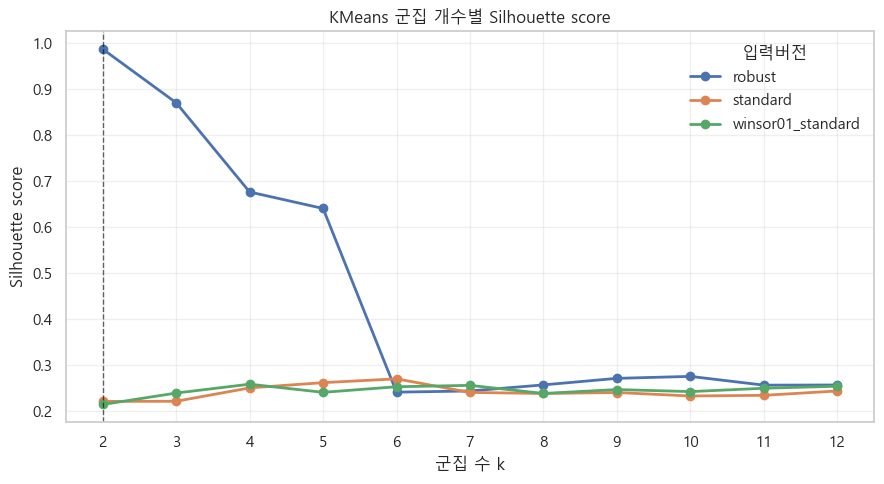

In [47]:
# 6-3. 군집 개수 후보 탐색: KMeans k=2~12 Silhouette score
cluster_silhouette_rows = []

for variant_name, variant_df in cluster_input_variants.items():
    data = variant_df.to_numpy()

    for k in range(CLUSTER_K_MIN, CLUSTER_K_MAX + 1):
        kmeans = KMeans(
            n_clusters=k,
            random_state=CLUSTER_RANDOM_STATE,
            n_init=10,
            init="k-means++",
        )
        labels = kmeans.fit_predict(data)
        sil_score = silhouette_score(data, labels)

        counts = pd.Series(labels).value_counts().sort_index()
        cluster_silhouette_rows.append(
            {
                "입력버전": variant_name,
                "k": k,
                "silhouette_score": sil_score,
                "최소군집크기": int(counts.min()),
                "최대군집크기": int(counts.max()),
                "최소군집비율": counts.min() / len(labels),
                "최대군집비율": counts.max() / len(labels),
                "군집크기": ", ".join([f"C{idx}={count}" for idx, count in counts.items()]),
            }
        )

cluster_silhouette_results = pd.DataFrame(cluster_silhouette_rows)
cluster_silhouette_results = cluster_silhouette_results.sort_values(
    ["입력버전", "k"]
).reset_index(drop=True)

cluster_silhouette_best_by_variant = (
    cluster_silhouette_results
    .sort_values(["입력버전", "silhouette_score"], ascending=[True, False])
    .groupby("입력버전", as_index=False)
    .head(1)
    .sort_values("silhouette_score", ascending=False)
    .reset_index(drop=True)
)

cluster_silhouette_pivot = cluster_silhouette_results.pivot(
    index="k",
    columns="입력버전",
    values="silhouette_score",
)

best_silhouette_row = cluster_silhouette_results.loc[
    cluster_silhouette_results["silhouette_score"].idxmax()
]
SELECTED_CLUSTER_INPUT_VARIANT = best_silhouette_row["입력버전"]
SELECTED_CLUSTER_K_BY_SILHOUETTE = int(best_silhouette_row["k"])

print(
    "전체 최고 Silhouette 후보: "
    f"{SELECTED_CLUSTER_INPUT_VARIANT}, k={SELECTED_CLUSTER_K_BY_SILHOUETTE}, "
    f"score={best_silhouette_row['silhouette_score']:.4f}"
)

display(cluster_silhouette_pivot.round(4))
display(cluster_silhouette_best_by_variant.round(4))
display(cluster_silhouette_results.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
for variant_name in cluster_silhouette_pivot.columns:
    ax.plot(
        cluster_silhouette_pivot.index,
        cluster_silhouette_pivot[variant_name],
        marker="o",
        linewidth=2,
        label=variant_name,
    )

ax.axvline(
    SELECTED_CLUSTER_K_BY_SILHOUETTE,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
)
ax.set_title("KMeans 군집 개수별 Silhouette score")
ax.set_xlabel("군집 수 k")
ax.set_ylabel("Silhouette score")
ax.set_xticks(range(CLUSTER_K_MIN, CLUSTER_K_MAX + 1))
ax.legend(title="입력버전", frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

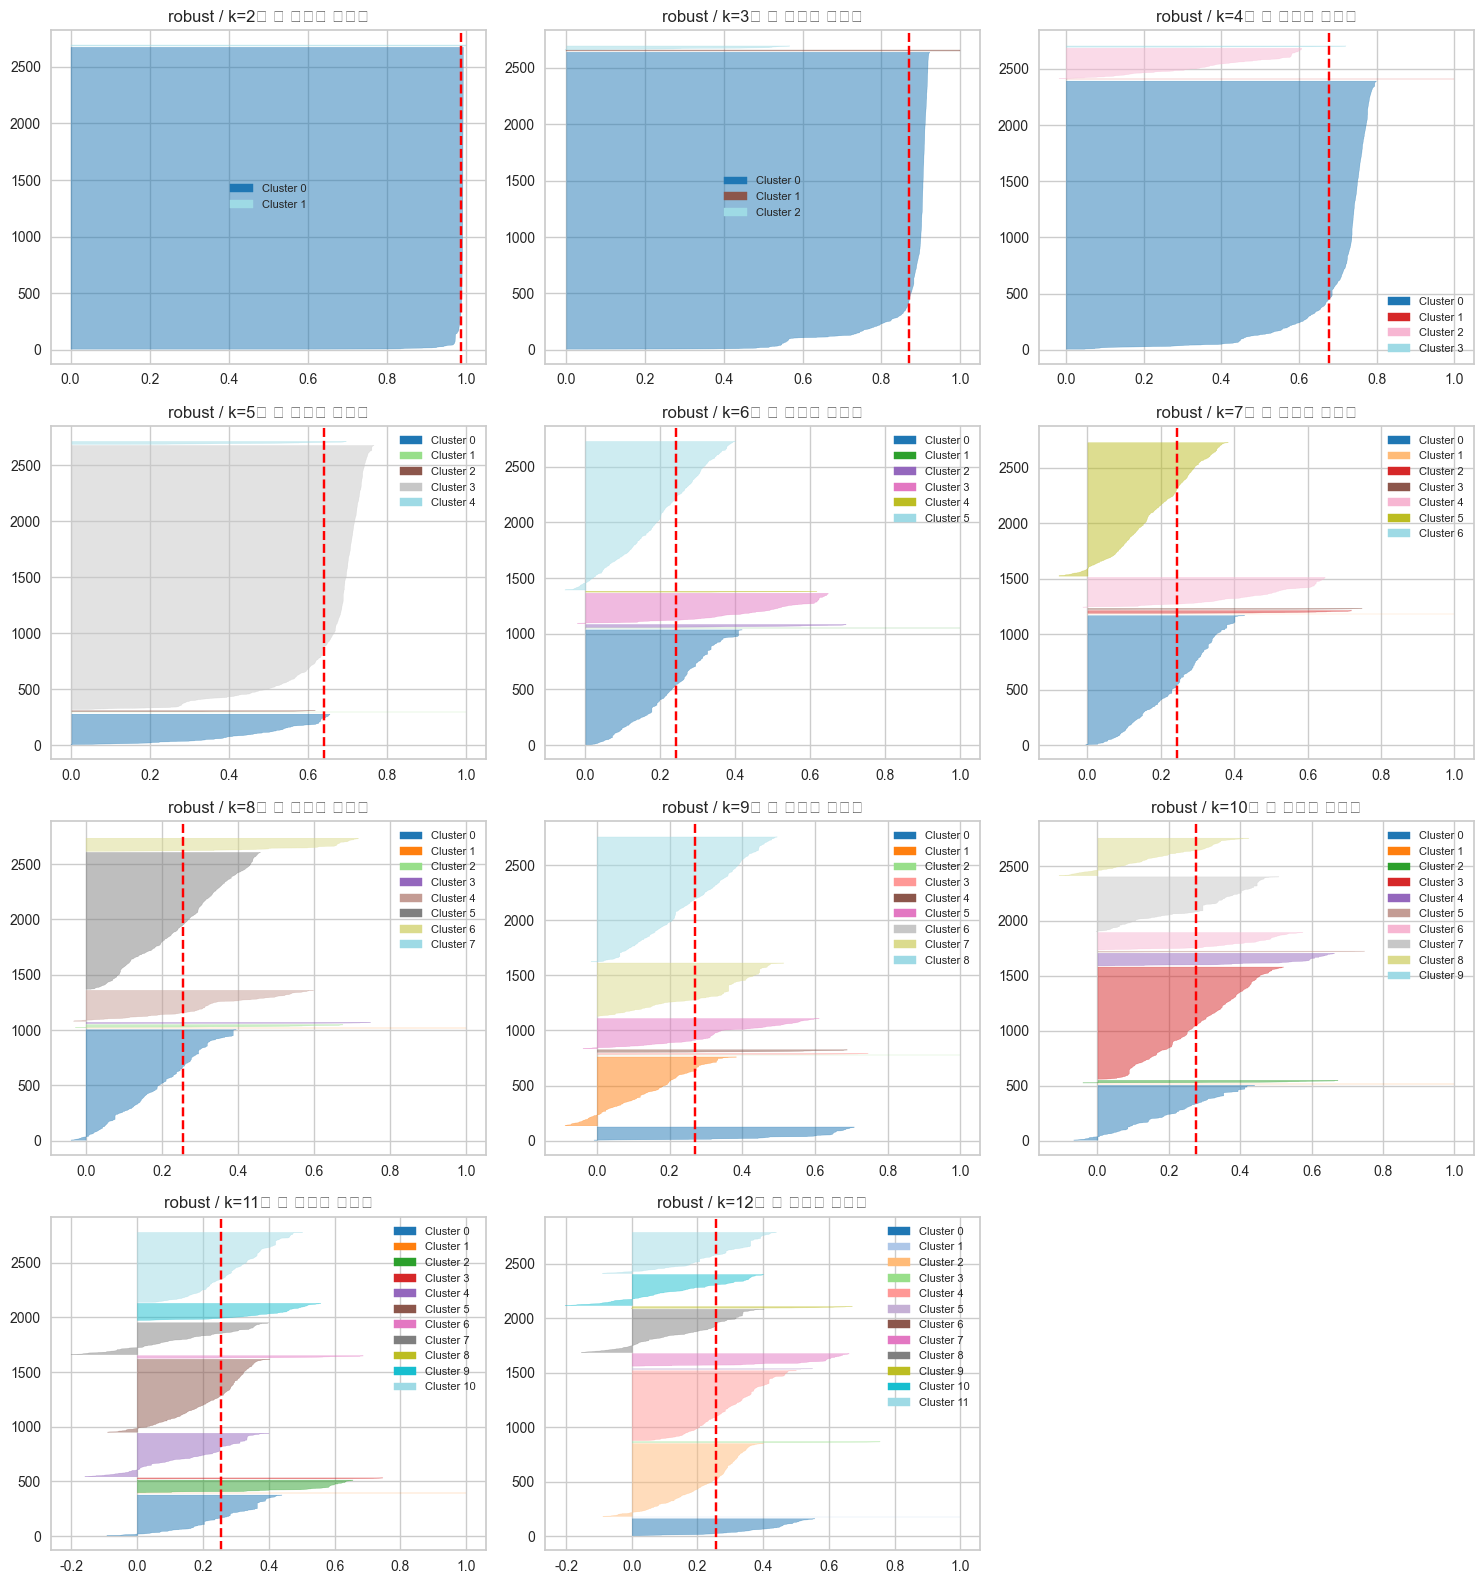

In [50]:
# 6-4. SilhouetteVisualizer 시각화
# 기본값은 6-3에서 Silhouette score가 가장 높았던 입력 버전이다.
# 다른 입력 버전을 보고 싶으면 아래 값을 "standard", "robust", "winsor01_standard" 중 하나로 바꿔서 실행한다.
VISUALIZE_CLUSTER_INPUT_VARIANT = SELECTED_CLUSTER_INPUT_VARIANT

try:
    from yellowbrick.cluster import SilhouetteVisualizer
except ImportError as exc:
    raise ImportError(
        "SilhouetteVisualizer를 사용하려면 yellowbrick 패키지가 필요합니다. "
        "설치 후 이 셀을 다시 실행하세요: pip install yellowbrick"
    ) from exc

data = cluster_input_variants[VISUALIZE_CLUSTER_INPUT_VARIANT].to_numpy()

# 몇 개의 클러스터링까지 볼 것인가
sil_k = CLUSTER_K_MAX
rows = math.ceil((sil_k - 1) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(range(2, sil_k + 1)):
    # 클러스터링
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init="k-means++")

    # 색상 설정
    cmap = colormaps["tab20"]
    colors = [cmap(i / (k - 1)) for i in range(k)]

    # 실루엣 시각화
    viz = SilhouetteVisualizer(kmeans, ax=axes[idx], colors=colors)
    viz.fit(data)
    axes[idx].set_title(f"{VISUALIZE_CLUSTER_INPUT_VARIANT} / k={k}일 때 실루엣 시각화")

    # legend
    handles = [
        mpatches.Patch(color=colors[i], label=f"Cluster {i}")
        for i in range(k)
    ]
    axes[idx].legend(handles=handles, loc="best", fontsize=8, frameon=False)

# 남은 subplot 삭제
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 군집 개수 후보 탐색 후 확인 기준

이 단계가 끝나면 먼저 `2026-06-08_FA_cluster_silhouette_model_selection.csv`와 Silhouette score 선 그래프를 확인한다.

판단 순서는 다음과 같다.

- `silhouette_score`가 높은 입력 버전과 k를 확인한다.
- 같은 점수대라면 `최소군집크기`, `최소군집비율`을 함께 확인해 너무 작은 군집이 생기는지 본다.
- `SilhouetteVisualizer`에서 음수 실루엣이 많은 k, 특정 군집 폭이 지나치게 얇은 k는 해석 후보에서 낮춘다.
- 최종 k는 Silhouette score만으로 확정하지 않고, 다음 단계에서 군집별 요인점수 평균과 메타데이터 분포를 같이 본 뒤 결정한다.

### 6번 실행 결과 해석: Silhouette 기반 군집 후보 탐색

5개 방향 보정 요인점수(`생활권접점_score`, `선행건조_score`, `강풍_score`, `강수부족_score`, `산지접근성_score`)를 입력으로 KMeans 군집 개수 후보를 탐색했다. 입력 사례 수는 `n=2,670`이고 결측은 없었다.

먼저 입력 요약에서 가장 큰 문제는 `강수부족_score`의 비대칭성과 극단값이다. 이 변수는 중앙값이 `0.1403`, 1퍼센타일이 `-1.6756`, 99퍼센타일이 `0.2743`인데 최솟값은 `-31.9643`이다. 대부분의 값은 좁은 범위에 모여 있지만 일부 매우 큰 음의 극단값이 존재한다. `robust` 스케일링에서는 이 극단값이 `-281.4622`까지 벌어져 KMeans 거리 계산을 사실상 지배했다.

Silhouette score 결과는 다음과 같이 해석한다.

| 입력버전 | 최고 후보 | Silhouette score | 군집 크기 | 판단 |
| --- | ---: | ---: | --- | --- |
| `robust` | `k=2` | `0.9875` | `2668 / 2` | 기각. 실제 군집 구조가 아니라 극단값 2개 분리 효과 |
| `standard` | `k=6` | `0.2699` | `360 / 969 / 469 / 2 / 694 / 176` | 낮음. 최고 후보에도 `n=2` 군집이 있어 불안정 |
| `winsor01_standard` | `k=4` | `0.2582` | `974 / 185 / 855 / 656` | 가장 현실적인 후보이나 분리력은 약함 |

시각화에서도 같은 결론이 나온다. `robust` 기준 `k=2~5`는 평균 Silhouette score가 높아 보이지만, 대부분의 표본이 하나의 큰 군집에 몰리고 극소수 사례가 별도 군집으로 떨어진다. 이는 산불 유형 군집이라기보다 `강수부족_score` 극단값을 분리한 결과이다. `standard`, `winsor01_standard`는 전체적으로 `0.21~0.27` 수준에서 평평하며, 뚜렷한 최적 k나 자연스러운 군집 분리가 보이지 않는다.

따라서 현 단계에서 KMeans 군집분석을 본 분석의 핵심 결론으로 사용하기에는 무리가 있다. 다만 `강수부족_score` 극단값이 실제 기상 사건인지, 데이터 결합/계산 문제인지 확인한 뒤, 극단값을 제외한 민감도 분석으로 군집 구조가 여전히 약한지 재점검할 필요가 있다.

## 7. 강수 극단값 확인 및 군집 재점검

6번 결과에서 `robust` 기준 높은 Silhouette score는 실질적인 군집 구조가 아니라 `강수부족_score` 극단값 분리 효과로 판단된다.

이 섹션에서는 먼저 `강수부족_score`의 극단 사례를 확인한다. 그 다음 기본값으로 `z <= -3`에 해당하는 극단 사례만 제외하고 KMeans Silhouette score를 다시 계산한다. 하위 1퍼센타일 제거는 실제 강수 사건까지 과도하게 제외할 수 있으므로, 기본 재점검 기준으로는 사용하지 않는다.

이 단계 역시 후보 탐색이므로 CSV나 이미지 파일은 저장하지 않는다.

In [51]:
# 7-1. 강수부족_score 극단값 기준 확인
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colormaps

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    from IPython.display import display
except ImportError:
    display = print


RAIN_SCORE_COL = "강수부족_score"
RAIN_Z_EXTREME_CUTOFF = -3.0

if "CLUSTER_SCORE_COLS" not in globals():
    CLUSTER_SCORE_COLS = [
        "생활권접점_score",
        "선행건조_score",
        "강풍_score",
        "강수부족_score",
        "산지접근성_score",
    ]

if "CLUSTER_RANDOM_STATE" not in globals():
    CLUSTER_RANDOM_STATE = 42

if "cluster_base" not in globals() or "cluster_score_df" not in globals():
    def resolve_analysis_dir_for_extreme_check():
        cwd = Path.cwd()
        candidates = [
            cwd,
            cwd / "jsw" / "Analysis",
            Path("jsw/Analysis"),
        ]
        for candidate in candidates:
            if (candidate / "2026-06-08_FA.ipynb").exists() or (candidate / "outputs").exists():
                return candidate
        return cwd

    CLUSTER_ANALYSIS_DIR = resolve_analysis_dir_for_extreme_check()
    CLUSTER_OUTPUT_DIR = CLUSTER_ANALYSIS_DIR / "outputs"
    oriented_scores_path = CLUSTER_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"
    cluster_base = pd.read_csv(oriented_scores_path, encoding="utf-8-sig")

    missing_cluster_cols = [col for col in CLUSTER_SCORE_COLS if col not in cluster_base.columns]
    if missing_cluster_cols:
        raise KeyError(f"군집분석 입력 요인점수 컬럼이 없습니다: {missing_cluster_cols}")

    cluster_score_raw = cluster_base[CLUSTER_SCORE_COLS].apply(pd.to_numeric, errors="coerce")
    cluster_complete_mask = cluster_score_raw.notna().all(axis=1)
    cluster_analysis_df = cluster_base.loc[cluster_complete_mask].copy()
    cluster_score_df = cluster_score_raw.loc[cluster_complete_mask].copy()

if RAIN_SCORE_COL not in cluster_score_df.columns:
    raise KeyError(f"{RAIN_SCORE_COL} 컬럼이 없습니다.")

rain_score = cluster_score_df[RAIN_SCORE_COL].astype(float)
rain_mean = rain_score.mean()
rain_std = rain_score.std(ddof=1)
rain_z = (rain_score - rain_mean) / rain_std

rain_q005 = rain_score.quantile(0.005)
rain_q01 = rain_score.quantile(0.01)
rain_q05 = rain_score.quantile(0.05)
rain_q25 = rain_score.quantile(0.25)
rain_q75 = rain_score.quantile(0.75)
rain_iqr = rain_q75 - rain_q25
rain_iqr_lower = rain_q25 - 1.5 * rain_iqr
rain_z3_lower = rain_mean + RAIN_Z_EXTREME_CUTOFF * rain_std

rain_extreme_masks = {
    "z3_lower": rain_z <= RAIN_Z_EXTREME_CUTOFF,
    "q005_lower": rain_score <= rain_q005,
    "q01_lower": rain_score <= rain_q01,
    "q05_lower": rain_score <= rain_q05,
    "iqr_lower": rain_score <= rain_iqr_lower,
}

rain_extreme_thresholds = pd.DataFrame(
    [
        {
            "기준": "z <= -3",
            "rule": "z3_lower",
            "threshold": rain_z3_lower,
            "n": int(rain_extreme_masks["z3_lower"].sum()),
        },
        {
            "기준": "하위 0.5%",
            "rule": "q005_lower",
            "threshold": rain_q005,
            "n": int(rain_extreme_masks["q005_lower"].sum()),
        },
        {
            "기준": "하위 1%",
            "rule": "q01_lower",
            "threshold": rain_q01,
            "n": int(rain_extreme_masks["q01_lower"].sum()),
        },
        {
            "기준": "하위 5%",
            "rule": "q05_lower",
            "threshold": rain_q05,
            "n": int(rain_extreme_masks["q05_lower"].sum()),
        },
        {
            "기준": "IQR lower fence",
            "rule": "iqr_lower",
            "threshold": rain_iqr_lower,
            "n": int(rain_extreme_masks["iqr_lower"].sum()),
        },
    ]
)
rain_extreme_thresholds["비율"] = rain_extreme_thresholds["n"] / len(rain_score)

rain_score_summary = pd.Series(
    {
        "n": len(rain_score),
        "mean": rain_mean,
        "std": rain_std,
        "min": rain_score.min(),
        "0.5%": rain_q005,
        "1%": rain_q01,
        "5%": rain_q05,
        "25%": rain_q25,
        "median": rain_score.median(),
        "75%": rain_q75,
        "95%": rain_score.quantile(0.95),
        "99%": rain_score.quantile(0.99),
        "max": rain_score.max(),
    },
    name=RAIN_SCORE_COL,
).to_frame()

print("강수부족_score 분포 요약")
display(rain_score_summary.round(4))

print("극단값 후보 기준별 사례 수")
display(rain_extreme_thresholds.round(4))

강수부족_score 분포 요약


,강수부족_score
n,2670.0000
mean,0.0000
std,0.9757
min,-31.9643
0.5%,-2.5099
1%,-1.6756
5%,-0.7582
25%,0.0650
median,0.1403
75%,0.1791


극단값 후보 기준별 사례 수


,기준,rule,threshold,n,비율
0,z <= -3,z3_lower,-2.9272,13,0.0049
1,하위 0.5%,q005_lower,-2.5099,14,0.0052
2,하위 1%,q01_lower,-1.6756,28,0.0105
3,하위 5%,q05_lower,-0.7582,134,0.0502
4,IQR lower fence,iqr_lower,-0.1061,402,0.1506


In [52]:
# 7-2. 강수 극단 사례 상세 확인
RAIN_EXTREME_DETAIL_N = 30
RAIN_EXTREME_SUMMARY_RULE = "z3_lower"

rain_extreme_context = cluster_analysis_df.copy()
rain_extreme_context["강수부족_z"] = rain_z.reindex(rain_extreme_context.index)
for rule_name, mask in rain_extreme_masks.items():
    rain_extreme_context[f"강수극단_{rule_name}"] = mask.reindex(rain_extreme_context.index).fillna(False)

raw_weather_context_cols = [
    "시점_강수량_mm",
    "직전24h_강수량합",
    "직전48h_강수량합",
    "직전72h_강수량합",
    "D-1_강수량합_mm",
    "D-2_강수량합_mm",
    "D-3_강수량합_mm",
    "시점_습도_pct",
    "직전24h_최소습도",
    "D-1_최소습도_pct",
    "시점_풍속_m_s",
    "직전24h_평균풍속",
    "당일_최대순간풍속_m_s",
]

if "reduced_fa_meta_complete" in globals() and "source_index" in rain_extreme_context.columns:
    raw_context_cols = [
        col for col in raw_weather_context_cols
        if col in reduced_fa_meta_complete.columns and col not in rain_extreme_context.columns
    ]
    if raw_context_cols:
        raw_context = reduced_fa_meta_complete[raw_context_cols].copy()
        raw_context["source_index"] = raw_context.index
        rain_extreme_context = rain_extreme_context.merge(
            raw_context,
            on="source_index",
            how="left",
        )

detail_candidate_cols = [
    "source_index",
    "fire_id",
    "발생일시",
    "기상셀ID",
    "기후권역",
    "기후지형유형",
    "addr_type",
    "기후지형_번지유형",
    "산불위험계절",
    "발생시간대구분",
    "L1_NAME",
    "L2_NAME",
    "원인프록시_500m",
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "강수부족_z",
    "산지접근성_score",
    "강수극단_z3_lower",
    "강수극단_q01_lower",
] + raw_weather_context_cols

detail_cols = [col for col in detail_candidate_cols if col in rain_extreme_context.columns]
rain_extreme_detail = (
    rain_extreme_context
    .sort_values(RAIN_SCORE_COL, ascending=True)
    .head(RAIN_EXTREME_DETAIL_N)
    [detail_cols]
)

print(f"강수부족_score 하위 {RAIN_EXTREME_DETAIL_N}개 사례")
display(rain_extreme_detail.round(4))

summary_flag_col = f"강수극단_{RAIN_EXTREME_SUMMARY_RULE}"
summary_meta_cols = [
    "기후권역",
    "기후지형유형",
    "addr_type",
    "기후지형_번지유형",
    "산불위험계절",
    "발생시간대구분",
    "L1_NAME",
    "L2_NAME",
    "원인프록시_500m",
]

rain_extreme_meta_rows = []
for meta_col in summary_meta_cols:
    if meta_col not in rain_extreme_context.columns:
        continue

    meta_summary = (
        rain_extreme_context
        .groupby(meta_col, dropna=False)[summary_flag_col]
        .agg(전체_n="size", 극단_n="sum")
        .reset_index()
    )
    meta_summary["극단비율"] = meta_summary["극단_n"] / meta_summary["전체_n"]
    meta_summary = meta_summary[meta_summary["극단_n"] > 0].copy()
    meta_summary.insert(0, "메타데이터", meta_col)
    meta_summary = meta_summary.rename(columns={meta_col: "그룹"})
    rain_extreme_meta_rows.append(meta_summary)

if rain_extreme_meta_rows:
    rain_extreme_meta_summary = (
        pd.concat(rain_extreme_meta_rows, ignore_index=True)
        .sort_values(["극단_n", "극단비율"], ascending=[False, False])
        .reset_index(drop=True)
    )
else:
    rain_extreme_meta_summary = pd.DataFrame(
        columns=["메타데이터", "그룹", "전체_n", "극단_n", "극단비율"]
    )

print(f"{RAIN_EXTREME_SUMMARY_RULE} 기준 강수 극단 사례가 포함된 메타데이터 그룹")
display(rain_extreme_meta_summary.round(4))

강수부족_score 하위 30개 사례


,fire_id,발생일시,기상셀ID,기후권역,기후지형유형,addr_type,기후지형_번지유형,산불위험계절,발생시간대구분,L1_NAME,L2_NAME,원인프록시_500m,생활권접점_score,선행건조_score,강풍_score,강수부족_score,강수부족_z,산지접근성_score,강수극단_z3_lower,강수극단_q01_lower
source_index,,,,,,,,,,,,,,,,,,,,
3242,F_010993,2020-09-03 15:00:00,YD_0014,영동,영동 해안형,일반번지,영동 해안형 / 일반번지,기타계절,오후(14~17시),나지,인공나지,입산활동 발화 후보,1.1194,-3.6186,3.1557,-31.9643,-32.7591,0.0353,True,True
205,F_007818,2020-09-03 15:00:00,YD_0014,영동,영동 해안형,일반번지,영동 해안형 / 일반번지,기타계절,오후(14~17시),나지,인공나지,입산활동 발화 후보,1.1194,-3.6186,3.1557,-31.9643,-32.7591,0.0353,True,True
3217,F_010943,2020-05-19 04:00:00,YD_0017,영동,영동 해안형,일반번지,영동 해안형 / 일반번지,산불위험계절(11~5월),야간(0~5시),시가화건조지역,도로,입산활동 발화 후보,1.1731,-4.3640,0.0284,-8.8934,-9.1145,-0.5769,True,True
3400,F_011274,2021-05-18 09:00:00,YS_0013,영서,고지·산간형,일반번지,고지·산간형 / 일반번지,산불위험계절(11~5월),아침(6~9시),산림지역,침엽수림,기타 인간활동 발화 후보,-0.1578,-4.2341,-1.5162,-5.4855,-5.6219,1.4880,True,True
2867,F_010483,2021-04-13 15:00:00,YD_0013,영동,영동 해안형,일반번지,영동 해안형 / 일반번지,산불위험계절(11~5월),오후(14~17시),시가화건조지역,도로,입산활동 발화 후보,1.0918,-1.0041,0.2961,-4.5589,-4.6722,-0.8553,True,True
3214,F_010939,2020-05-16 15:00:00,YS_0021,영서,고지·산간형,임야번지(산),고지·산간형 / 임야번지(산),산불위험계절(11~5월),오후(14~17시),산림지역,침엽수림,입산활동 발화 후보,-2.3441,-2.4360,-1.2212,-4.5124,-4.6246,1.9374,True,True
2856,F_010472,2021-04-10 09:00:00,YD_0018,영동,영동 해안형,일반번지,영동 해안형 / 일반번지,산불위험계절(11~5월),아침(6~9시),습지,내륙습지,입산활동 발화 후보,-0.2512,-2.7882,-0.2200,-4.4005,-4.5099,-1.0389,True,True
2779,F_010395,2021-03-28 09:00:00,YS_0035,영서,고지·산간형,일반번지,고지·산간형 / 일반번지,산불위험계절(11~5월),아침(6~9시),농업지역,밭,입산활동 발화 후보,0.4387,1.0819,0.7685,-4.3476,-4.4557,0.8690,True,True
3243,F_010994,2020-09-10 19:00:00,YS_0025,영서,고지·산간형,일반번지,고지·산간형 / 일반번지,기타계절,저녁(18~23시),시가화건조지역,도로,기타 인간활동 발화 후보,0.6984,-2.1575,-0.8852,-4.3120,-4.4192,0.7216,True,True


z3_lower 기준 강수 극단 사례가 포함된 메타데이터 그룹


,메타데이터,그룹,전체_n,극단_n,극단비율
0,addr_type,일반번지,1971,11,0.0056
1,산불위험계절,산불위험계절(11~5월),1992,10,0.0050
2,원인프록시_500m,입산활동 발화 후보,881,9,0.0102
3,기후권역,영서,1697,7,0.0041
4,기후지형_번지유형,영동 해안형 / 일반번지,746,6,0.0080
5,발생시간대구분,오후(14~17시),796,6,0.0075
6,기후권역,영동,973,6,0.0062
7,기후지형유형,영동 해안형,973,6,0.0062
8,기후지형유형,고지·산간형,563,4,0.0071
9,L1_NAME,시가화건조지역,1129,4,0.0035


제외 기준: z3_lower / 제외 사례 수: 13 / 재점검 입력 n: 2,657
후보 적합 최소 군집 크기: 30
전체 최고 후보: robust, k=2, score=0.6790, 최소군집크기=270
선택 후보: robust, k=2, score=0.6790, 최소군집크기=270


입력버전,robust,standard,winsor01_standard
k,,,
2,0.6790,0.2132,0.2146
3,0.6442,0.2367,0.2478
4,0.2399,0.2562,0.2608
5,0.2559,0.2387,0.2445
6,0.2720,0.2711,0.2508
7,0.2686,0.2569,0.2614
8,0.2525,0.2369,0.2432
9,0.2618,0.2396,0.2525
10,0.2664,0.2500,0.2494


,입력버전,k,silhouette_score,최소군집크기,최대군집크기,최소군집비율,최대군집비율,후보적합,군집크기
0,robust,2,0.6790,270,2387,0.1016,0.8984,True,"C0=270, C1=2387"
1,standard,6,0.2711,156,922,0.0587,0.3470,True,"C0=156, C1=922, C2=452, C3=690, C4=277, C5=160"
2,winsor01_standard,7,0.2614,154,847,0.0580,0.3188,True,"C0=847, C1=322, C2=230, C3=375, C4=228, C5=154..."


,입력버전,k,silhouette_score,최소군집크기,최대군집크기,최소군집비율,최대군집비율,후보적합,군집크기
0,robust,2,0.6790,270,2387,0.1016,0.8984,True,"C0=270, C1=2387"
1,robust,3,0.6442,24,2360,0.0090,0.8882,False,"C0=2360, C1=273, C2=24"
2,robust,4,0.2399,24,1336,0.0090,0.5028,False,"C0=1027, C1=270, C2=24, C3=1336"
3,robust,5,0.2559,24,1250,0.0090,0.4705,False,"C0=1250, C1=119, C2=984, C3=24, C4=280"
4,robust,6,0.2720,24,1162,0.0090,0.4373,False,"C0=473, C1=273, C2=119, C3=606, C4=1162, C5=24"
5,robust,7,0.2686,24,831,0.0090,0.3128,False,"C0=495, C1=115, C2=344, C3=688, C4=24, C5=160,..."
6,robust,8,0.2525,23,658,0.0087,0.2476,False,"C0=373, C1=156, C2=115, C3=23, C4=658, C5=619,..."
7,robust,9,0.2618,23,640,0.0087,0.2409,False,"C0=370, C1=113, C2=223, C3=159, C4=23, C5=627,..."
8,robust,10,0.2664,23,640,0.0087,0.2409,False,"C0=640, C1=116, C2=607, C3=151, C4=23, C5=203,..."
9,robust,11,0.2659,10,640,0.0038,0.2409,False,"C0=640, C1=115, C2=136, C3=10, C4=601, C5=291,..."


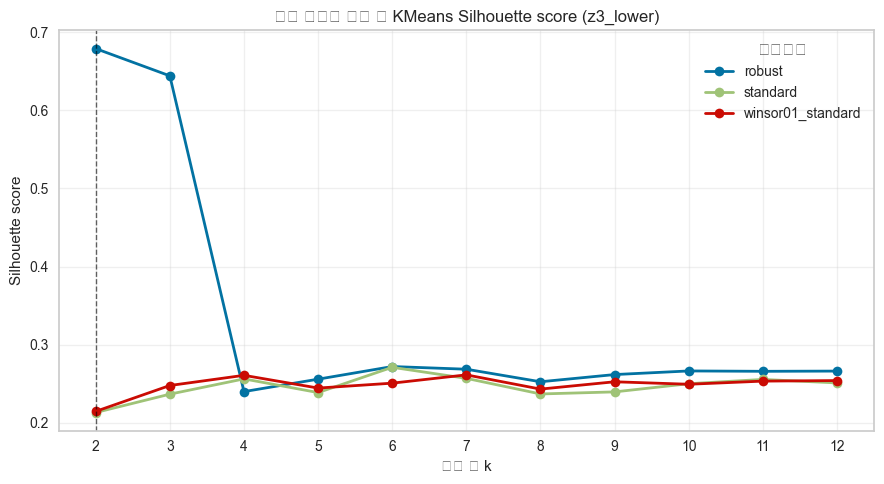

In [53]:
# 7-3. 강수 극단값 제외 후 KMeans Silhouette score 재점검
RAIN_EXTREME_RULE_FOR_RECHECK = "z3_lower"
RECHECK_K_MIN = 2
RECHECK_K_MAX = 12
RECHECK_MIN_CLUSTER_RATIO = 0.01
RECHECK_MIN_CLUSTER_N_ABS = 30


def make_standardized_frame(df, scaler):
    scaled = scaler.fit_transform(df)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)


def make_winsorized_frame(df, lower_q=0.01, upper_q=0.99):
    lower = df.quantile(lower_q)
    upper = df.quantile(upper_q)
    return df.clip(lower=lower, upper=upper, axis=1)


if RAIN_EXTREME_RULE_FOR_RECHECK not in rain_extreme_masks:
    raise KeyError(f"알 수 없는 극단값 기준입니다: {RAIN_EXTREME_RULE_FOR_RECHECK}")

rain_recheck_keep_mask = ~rain_extreme_masks[RAIN_EXTREME_RULE_FOR_RECHECK].reindex(cluster_score_df.index).fillna(False)
cluster_score_recheck_df = cluster_score_df.loc[rain_recheck_keep_mask].copy()
cluster_analysis_recheck_df = cluster_analysis_df.loc[rain_recheck_keep_mask].copy()

removed_n = len(cluster_score_df) - len(cluster_score_recheck_df)
recheck_min_cluster_n = max(
    RECHECK_MIN_CLUSTER_N_ABS,
    math.ceil(len(cluster_score_recheck_df) * RECHECK_MIN_CLUSTER_RATIO),
)

recheck_input_variants = {
    "standard": make_standardized_frame(cluster_score_recheck_df, StandardScaler()),
    "robust": make_standardized_frame(cluster_score_recheck_df, RobustScaler()),
}

cluster_score_recheck_winsor01 = make_winsorized_frame(
    cluster_score_recheck_df,
    lower_q=0.01,
    upper_q=0.99,
)
recheck_input_variants["winsor01_standard"] = make_standardized_frame(
    cluster_score_recheck_winsor01,
    StandardScaler(),
)

recheck_rows = []
for variant_name, variant_df in recheck_input_variants.items():
    data = variant_df.to_numpy()
    for k in range(RECHECK_K_MIN, RECHECK_K_MAX + 1):
        kmeans = KMeans(
            n_clusters=k,
            random_state=CLUSTER_RANDOM_STATE,
            n_init=10,
            init="k-means++",
        )
        labels = kmeans.fit_predict(data)
        sil_score = silhouette_score(data, labels)
        counts = pd.Series(labels).value_counts().sort_index()

        recheck_rows.append(
            {
                "입력버전": variant_name,
                "k": k,
                "silhouette_score": sil_score,
                "최소군집크기": int(counts.min()),
                "최대군집크기": int(counts.max()),
                "최소군집비율": counts.min() / len(labels),
                "최대군집비율": counts.max() / len(labels),
                "후보적합": bool(counts.min() >= recheck_min_cluster_n),
                "군집크기": ", ".join([f"C{idx}={count}" for idx, count in counts.items()]),
            }
        )

cluster_silhouette_recheck_results = (
    pd.DataFrame(recheck_rows)
    .sort_values(["입력버전", "k"])
    .reset_index(drop=True)
)

cluster_silhouette_recheck_pivot = cluster_silhouette_recheck_results.pivot(
    index="k",
    columns="입력버전",
    values="silhouette_score",
)

cluster_silhouette_recheck_best_by_variant = (
    cluster_silhouette_recheck_results
    .sort_values(["입력버전", "silhouette_score"], ascending=[True, False])
    .groupby("입력버전", as_index=False)
    .head(1)
    .sort_values("silhouette_score", ascending=False)
    .reset_index(drop=True)
)

valid_recheck_candidates = cluster_silhouette_recheck_results[
    cluster_silhouette_recheck_results["후보적합"]
].copy()

best_recheck_all = cluster_silhouette_recheck_results.loc[
    cluster_silhouette_recheck_results["silhouette_score"].idxmax()
]

if valid_recheck_candidates.empty:
    best_recheck_valid = best_recheck_all
    print("최소 군집 크기 기준을 만족하는 후보가 없어 전체 최고 후보를 임시 선택합니다.")
else:
    best_recheck_valid = valid_recheck_candidates.loc[
        valid_recheck_candidates["silhouette_score"].idxmax()
    ]

RECHECK_SELECTED_CLUSTER_INPUT_VARIANT = best_recheck_valid["입력버전"]
RECHECK_SELECTED_CLUSTER_K = int(best_recheck_valid["k"])

print(
    f"제외 기준: {RAIN_EXTREME_RULE_FOR_RECHECK} / "
    f"제외 사례 수: {removed_n:,} / 재점검 입력 n: {len(cluster_score_recheck_df):,}"
)
print(f"후보 적합 최소 군집 크기: {recheck_min_cluster_n:,}")
print(
    "전체 최고 후보: "
    f"{best_recheck_all['입력버전']}, k={int(best_recheck_all['k'])}, "
    f"score={best_recheck_all['silhouette_score']:.4f}, "
    f"최소군집크기={int(best_recheck_all['최소군집크기'])}"
)
print(
    "선택 후보: "
    f"{RECHECK_SELECTED_CLUSTER_INPUT_VARIANT}, k={RECHECK_SELECTED_CLUSTER_K}, "
    f"score={best_recheck_valid['silhouette_score']:.4f}, "
    f"최소군집크기={int(best_recheck_valid['최소군집크기'])}"
)

display(cluster_silhouette_recheck_pivot.round(4))
display(cluster_silhouette_recheck_best_by_variant.round(4))
display(cluster_silhouette_recheck_results.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
for variant_name in cluster_silhouette_recheck_pivot.columns:
    ax.plot(
        cluster_silhouette_recheck_pivot.index,
        cluster_silhouette_recheck_pivot[variant_name],
        marker="o",
        linewidth=2,
        label=variant_name,
    )

ax.axvline(
    RECHECK_SELECTED_CLUSTER_K,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
)
ax.set_title(f"강수 극단값 제외 후 KMeans Silhouette score ({RAIN_EXTREME_RULE_FOR_RECHECK})")
ax.set_xlabel("군집 수 k")
ax.set_ylabel("Silhouette score")
ax.set_xticks(range(RECHECK_K_MIN, RECHECK_K_MAX + 1))
ax.legend(title="입력버전", frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

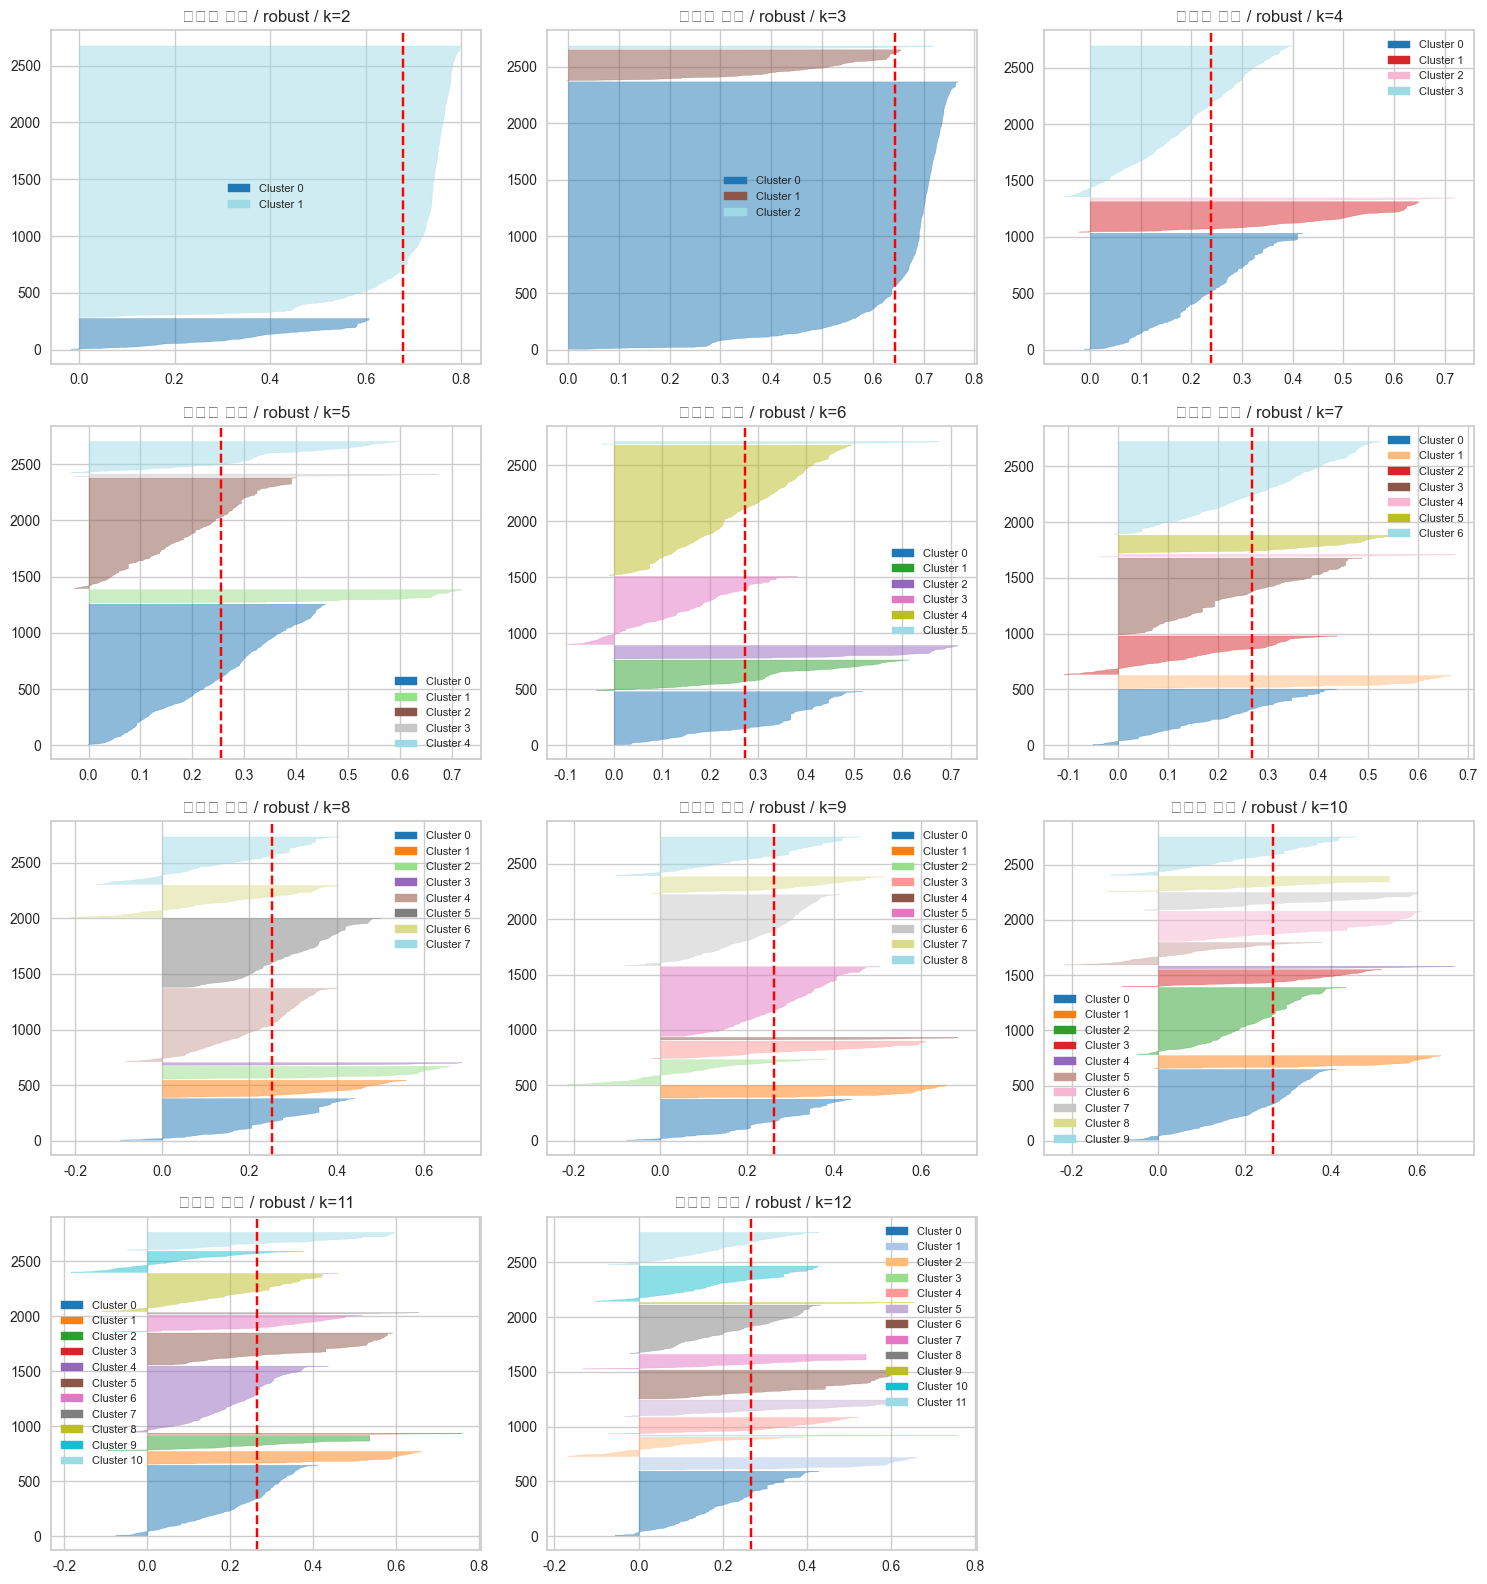

In [54]:
# 7-4. 강수 극단값 제외 후 SilhouetteVisualizer 시각화
# 7-3에서 후보적합 기준을 만족한 최고 후보의 입력 버전을 기본값으로 사용한다.
# 다른 입력 버전을 보고 싶으면 아래 값을 "standard", "robust", "winsor01_standard" 중 하나로 바꿔서 실행한다.
RECHECK_VISUALIZE_CLUSTER_INPUT_VARIANT = RECHECK_SELECTED_CLUSTER_INPUT_VARIANT

try:
    from yellowbrick.cluster import SilhouetteVisualizer
except ImportError as exc:
    raise ImportError(
        "SilhouetteVisualizer를 사용하려면 yellowbrick 패키지가 필요합니다. "
        "설치 후 이 셀을 다시 실행하세요: pip install yellowbrick"
    ) from exc

data = recheck_input_variants[RECHECK_VISUALIZE_CLUSTER_INPUT_VARIANT].to_numpy()

sil_k = RECHECK_K_MAX
rows = math.ceil((sil_k - 1) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(range(2, sil_k + 1)):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init="k-means++")

    cmap = colormaps["tab20"]
    colors = [cmap(i / (k - 1)) for i in range(k)]

    viz = SilhouetteVisualizer(kmeans, ax=axes[idx], colors=colors)
    viz.fit(data)
    axes[idx].set_title(
        f"극단값 제외 / {RECHECK_VISUALIZE_CLUSTER_INPUT_VARIANT} / k={k}"
    )

    handles = [
        mpatches.Patch(color=colors[i], label=f"Cluster {i}")
        for i in range(k)
    ]
    axes[idx].legend(handles=handles, loc="best", fontsize=8, frameon=False)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 7번 실행 결과 해석: 강수 극단값 제외 후 군집 재점검

`강수부족_score` 극단값을 확인한 결과, 이 축은 여전히 매우 비대칭적이다. 전체 `n=2,670`에서 중앙값은 `0.1403`, 1퍼센타일은 `-1.6756`, 99퍼센타일은 `0.2743`인데 최솟값은 `-31.9643`이다. 대부분의 값이 좁은 범위에 모여 있는 반면, 일부 음의 극단값이 매우 크게 떨어져 있다.

극단값 기준별 사례 수는 다음과 같다.

| 기준 | threshold | n | 비율 |
| --- | ---: | ---: | ---: |
| `z <= -3` | `-2.9272` | `13` | `0.0049` |
| 하위 0.5% | `-2.5099` | `14` | `0.0052` |
| 하위 1% | `-1.6756` | `28` | `0.0105` |
| 하위 5% | `-0.7582` | `134` | `0.0502` |
| IQR lower fence | `-0.1061` | `402` | `0.1506` |

`IQR lower fence` 기준은 402건, 전체의 15.06퍼센트를 극단값으로 잡으므로 이 분석에서는 과도하다. 하위 5퍼센트도 실제 강수 사건을 너무 많이 제외할 가능성이 있다. 따라서 군집 민감도 분석에서는 가장 보수적인 `z <= -3` 기준 13건만 제외하는 것이 적절하다.

강수 극단 하위 사례를 보면 최하위 2건은 같은 `2020-09-03 15:00`, 같은 `YD_0014`, 같은 `영동 해안형 / 일반번지`, 같은 `나지-인공나지`, 같은 `입산활동 발화 후보`이며 `강수부족_score = -31.9643`이다. 기존 군집분석에서 `robust k=2`가 거의 완벽한 Silhouette score를 보인 것은 이 극단 사례들이 거리 계산을 지배했기 때문으로 해석된다. 다만 `z <= -3` 극단 13건은 특정 하나의 메타데이터 범주에만 몰려 있지는 않다. `일반번지` 11건, `산불위험계절(11~5월)` 10건, `입산활동 발화 후보` 9건, `영서` 7건, `영동` 6건으로 여러 조건에 분산되어 있다.

`z <= -3` 기준 13건을 제외한 뒤 재점검한 입력 사례 수는 `n=2,657`이다.

| 입력버전 | 최고 후보 | Silhouette score | 군집 크기 | 판단 |
| --- | ---: | ---: | --- | --- |
| `robust` | `k=2` | `0.6790` | `270 / 2387` | 점수는 높지만 큰 본체 집단과 분리 집단의 2분할 구조 |
| `standard` | `k=6` | `0.2711` | `156 / 922 / 452 / 690 / 277 / 160` | 군집 크기는 비교적 안정적이나 분리력 낮음 |
| `winsor01_standard` | `k=7` | `0.2614` | 최소 `154`, 최대 `847` | 군집 크기는 안정적이나 분리력 낮음 |

극단값 13건을 제거해도 `standard`, `winsor01_standard`의 Silhouette score는 대체로 `0.21~0.27` 수준에 머문다. 선 그래프도 뚜렷한 최적 k 없이 평평하다. 이는 5개 요인점수 공간에서 산불 사례가 뚜렷한 덩어리로 나뉘기보다 연속적으로 분포한다는 신호이다.

`robust`는 극단값 제거 후에도 `k=2`에서 `0.6790`으로 높지만, 군집 크기가 `270 / 2387`로 매우 불균형하고 `k=3`부터는 최소 군집 크기 24건이 생긴다. 또한 `k=4` 이후에는 `0.24~0.27` 수준으로 급락한다. 따라서 `robust k=2`는 산불 유형을 여러 개로 나누는 군집이라기보다, 전체 본체와 한쪽으로 떨어진 사례군을 나누는 거친 2분할로 보는 것이 타당하다.

Silhouette score가 `0.24~0.27`이라고 해서 절대 사용할 수 없는 것은 아니다. 다만 이 수준은 군집 구조가 강하다는 근거가 되기 어렵다. 사용할 경우에는 `강한 자연 군집`이 아니라 `탐색적 유형 후보`로 표현해야 하며, 군집별 요인점수 프로파일과 메타데이터 분포가 명확하게 해석될 때만 보조 분석으로 제한하는 것이 안전하다.

따라서 현 단계의 결론은 다음과 같다.

- KMeans 군집분석은 본 분석의 핵심 방법으로 채택하지 않는다.
- `robust k=2`는 점수는 높지만 2분할 구조가 거칠고 불균형하므로 최종 유형화로 쓰지 않는다.
- `standard k=6` 또는 `winsor01_standard k=7`은 탐색적 군집 후보로만 검토할 수 있다.
- 다음 분석의 중심은 군집분석보다 메타데이터별 요인점수 차이 해석에 두는 것이 타당하다.

### 7번 실행 후 판단 기준

7번을 실행한 뒤에는 다음 순서로 판단한다.

- `z <= -3` 기준으로 제외된 사례가 실제 데이터 오류인지, 실제 강수 사건인지 확인한다.
- 극단값 제외 후에도 최고 Silhouette score가 `0.30` 미만이면 KMeans 군집분석은 본 분석으로 사용하지 않는다.
- Silhouette score가 약간 올라가더라도 작은 군집이 반복되면 군집분석은 탐색적 보조 분석에 한정한다.
- 극단값 제외 후 `winsor01_standard` 또는 `standard`에서 균형 잡힌 군집과 해석 가능한 k가 나타나는 경우에만, 다음 단계에서 군집별 요인점수 프로파일과 메타데이터 분포를 확인한다.

## 8. 메타데이터별 요인점수 순차 해석

군집분석 결과가 뚜렷하지 않았으므로, 이후 분석의 중심은 5개 방향 보정 요인점수를 메타데이터별로 해석하는 방식으로 둔다.

이 단계는 한꺼번에 진행하지 않는다. 하나의 메타데이터를 선택해 표와 플롯을 확인하고, 해석을 작성한 뒤 다음 메타데이터로 넘어간다.

첫 번째 순서는 `기후지형유형`이다. 이 변수는 EDA에서 확인한 영동 해안형, 영서 내륙형, 고지·산간형 차이를 FA 요인점수로 검증하는 핵심 메타데이터이다.

### 8-1. 기후지형유형별 요인점수 해석

확인할 질문은 다음과 같다.

- `영동 해안형`은 `강풍_score`가 높은가?
- `고지·산간형`은 `산지접근성_score`가 높은가?
- `영서 내륙형`은 상대적으로 어떤 요인점수가 높고 낮은가?
- `강수부족_score` 해석이 강수 극단값에 의해 왜곡되는가?

해석은 평균뿐 아니라 중앙값, 효과크기, 극단값 포함 여부를 함께 본다.

In [55]:
# 8-1-1. 기후지형유형별 요인점수 요약표
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print


SEQ_META_COL = "기후지형유형"
SEQ_FACTOR_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]


def resolve_analysis_dir_for_seq_meta():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "jsw" / "Analysis",
        Path("jsw/Analysis"),
    ]
    for candidate in candidates:
        if (candidate / "2026-06-08_FA.ipynb").exists() or (candidate / "outputs").exists():
            return candidate
    return cwd


SEQ_ANALYSIS_DIR = resolve_analysis_dir_for_seq_meta()
SEQ_OUTPUT_DIR = SEQ_ANALYSIS_DIR / "outputs"
oriented_scores_path = SEQ_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"

if "factor_scores_oriented_source" in globals():
    seq_factor_meta_df = factor_scores_oriented_source.copy()
    seq_factor_source = "memory: factor_scores_oriented_source"
elif "factor_scores_oriented" in globals():
    seq_factor_meta_df = factor_scores_oriented.copy()
    seq_factor_source = "memory: factor_scores_oriented"
elif oriented_scores_path.exists():
    seq_factor_meta_df = pd.read_csv(oriented_scores_path, encoding="utf-8-sig")
    seq_factor_source = str(oriented_scores_path)
else:
    raise FileNotFoundError(
        "방향 보정 요인점수 데이터가 없습니다. 먼저 '요인점수 생성' 섹션을 실행하거나 "
        f"{oriented_scores_path} 파일을 생성해야 합니다."
    )

missing_cols = [
    col for col in [SEQ_META_COL] + SEQ_FACTOR_SCORE_COLS
    if col not in seq_factor_meta_df.columns
]
if missing_cols:
    raise KeyError(f"기후지형유형 해석에 필요한 컬럼이 없습니다: {missing_cols}")

seq_meta_work = seq_factor_meta_df[[SEQ_META_COL] + SEQ_FACTOR_SCORE_COLS].copy()
for score_col in SEQ_FACTOR_SCORE_COLS:
    seq_meta_work[score_col] = pd.to_numeric(seq_meta_work[score_col], errors="coerce")

seq_meta_work = seq_meta_work.dropna(subset=[SEQ_META_COL] + SEQ_FACTOR_SCORE_COLS).copy()
seq_meta_work[SEQ_META_COL] = seq_meta_work[SEQ_META_COL].astype(str)

seq_overall = seq_meta_work[SEQ_FACTOR_SCORE_COLS].agg(["mean", "median", "std"]).T

summary_rows = []
total_n = len(seq_meta_work)
for group_name, group_df in seq_meta_work.groupby(SEQ_META_COL, dropna=False):
    for score_col in SEQ_FACTOR_SCORE_COLS:
        values = group_df[score_col].dropna()
        overall_mean = seq_overall.loc[score_col, "mean"]
        overall_median = seq_overall.loc[score_col, "median"]
        overall_std = seq_overall.loc[score_col, "std"]

        summary_rows.append(
            {
                "메타데이터": SEQ_META_COL,
                "그룹": group_name,
                "요인점수": score_col,
                "n": int(values.size),
                "비율": values.size / total_n,
                "평균": values.mean(),
                "중앙값": values.median(),
                "표준편차": values.std(ddof=1),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "평균차_sd": (values.mean() - overall_mean) / overall_std,
                "중앙값차_sd": (values.median() - overall_median) / overall_std,
            }
        )

climate_terrain_summary_long = pd.DataFrame(summary_rows)
climate_terrain_summary_wide_mean = climate_terrain_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="평균차_sd",
).loc[:, SEQ_FACTOR_SCORE_COLS]
climate_terrain_summary_wide_median = climate_terrain_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="중앙값차_sd",
).loc[:, SEQ_FACTOR_SCORE_COLS]

print(f"요인점수 원천: {seq_factor_source}")
print(f"{SEQ_META_COL} 해석 입력 n: {total_n:,}")
print("그룹별 평균차_sd")
display(climate_terrain_summary_wide_mean.round(4))
print("그룹별 중앙값차_sd")
display(climate_terrain_summary_wide_median.round(4))
print("상세 요약표")
display(
    climate_terrain_summary_long
    .sort_values(["요인점수", "평균차_sd"], ascending=[True, False])
    .round(4)
)

요인점수 원천: memory: factor_scores_oriented_source
기후지형유형 해석 입력 n: 2,670
그룹별 평균차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
고지·산간형,-0.3844,-0.2208,-0.1860,-0.0566,0.9341
영동 해안형,0.2070,0.1856,0.6118,0.0466,-0.5622
영서 내륙형,0.0133,-0.0496,-0.4326,-0.0119,0.0186


그룹별 중앙값차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
고지·산간형,-0.7252,-0.2042,-0.4372,-0.0168,0.9808
영동 해안형,0.3002,0.1947,0.8810,0.0185,-0.6036
영서 내륙형,0.0177,-0.0014,-0.4062,-0.0151,-0.0188


상세 요약표


,메타데이터,그룹,요인점수,n,비율,평균,중앙값,표준편차,Q1,Q3,평균차_sd,중앙값차_sd
8,기후지형유형,영동 해안형,강수부족_score,973,0.3644,0.0454,0.1583,1.5106,0.1248,0.1859,0.0466,0.0185
13,기후지형유형,영서 내륙형,강수부족_score,1134,0.4247,-0.0116,0.1256,0.3826,-0.0214,0.1718,-0.0119,-0.0151
3,기후지형유형,고지·산간형,강수부족_score,563,0.2109,-0.0552,0.1239,0.5226,-0.0377,0.1892,-0.0566,-0.0168
7,기후지형유형,영동 해안형,강풍_score,973,0.3644,0.5779,0.7351,0.7625,-0.0779,0.9616,0.6118,0.8810
2,기후지형유형,고지·산간형,강풍_score,563,0.2109,-0.1757,-0.5100,1.0629,-0.9428,0.5351,-0.1860,-0.4372
12,기후지형유형,영서 내륙형,강풍_score,1134,0.4247,-0.4086,-0.4807,0.7571,-0.9647,0.1335,-0.4326,-0.4062
4,기후지형유형,고지·산간형,산지접근성_score,563,0.2109,0.7658,0.6683,0.7451,0.1709,1.0127,0.9341,0.9808
14,기후지형유형,영서 내륙형,산지접근성_score,1134,0.4247,0.0153,-0.1512,0.7622,-0.5492,0.4217,0.0186,-0.0188
9,기후지형유형,영동 해안형,산지접근성_score,973,0.3644,-0.4609,-0.6307,0.5430,-0.8181,-0.1807,-0.5622,-0.6036
5,기후지형유형,영동 해안형,생활권접점_score,973,0.3644,0.1966,0.5478,0.8433,-0.3512,0.8853,0.2070,0.3002


In [56]:
# 8-1-2. 기후지형유형별 Kruskal-Wallis 검정 및 쌍별 비교
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = np.empty(n, dtype=float)
    cumulative = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        value = ranked[i] * n / rank
        cumulative = min(cumulative, value)
        adjusted[order[i]] = min(cumulative, 1.0)
    return adjusted


kruskal_rows = []
pairwise_rows = []
groups_in_order = list(seq_meta_work[SEQ_META_COL].dropna().unique())

for score_col in SEQ_FACTOR_SCORE_COLS:
    group_values = [
        seq_meta_work.loc[seq_meta_work[SEQ_META_COL] == group, score_col].dropna().to_numpy()
        for group in groups_in_order
    ]
    group_values = [values for values in group_values if len(values) > 0]

    if len(group_values) >= 2:
        h_stat, p_value = stats.kruskal(*group_values)
        n_total = sum(len(values) for values in group_values)
        k_groups = len(group_values)
        epsilon_sq = (h_stat - k_groups + 1) / (n_total - k_groups) if n_total > k_groups else np.nan
        epsilon_sq = max(epsilon_sq, 0) if pd.notna(epsilon_sq) else np.nan
    else:
        h_stat, p_value, epsilon_sq = np.nan, np.nan, np.nan

    kruskal_rows.append(
        {
            "메타데이터": SEQ_META_COL,
            "요인점수": score_col,
            "H": h_stat,
            "p_value": p_value,
            "epsilon_sq": epsilon_sq,
            "그룹수": len(group_values),
            "n": sum(len(values) for values in group_values),
        }
    )

    for group_a, group_b in combinations(groups_in_order, 2):
        values_a = seq_meta_work.loc[seq_meta_work[SEQ_META_COL] == group_a, score_col].dropna()
        values_b = seq_meta_work.loc[seq_meta_work[SEQ_META_COL] == group_b, score_col].dropna()
        if len(values_a) == 0 or len(values_b) == 0:
            continue

        u_stat, pair_p = stats.mannwhitneyu(values_a, values_b, alternative="two-sided")
        rank_biserial = (2 * u_stat / (len(values_a) * len(values_b))) - 1
        overall_std = seq_overall.loc[score_col, "std"]

        pairwise_rows.append(
            {
                "요인점수": score_col,
                "그룹A": group_a,
                "그룹B": group_b,
                "A_n": len(values_a),
                "B_n": len(values_b),
                "A_평균": values_a.mean(),
                "B_평균": values_b.mean(),
                "A-B_평균차_sd": (values_a.mean() - values_b.mean()) / overall_std,
                "A_중앙값": values_a.median(),
                "B_중앙값": values_b.median(),
                "A-B_중앙값차_sd": (values_a.median() - values_b.median()) / overall_std,
                "mannwhitney_p": pair_p,
                "rank_biserial_A_gt_B": rank_biserial,
            }
        )

climate_terrain_kruskal = pd.DataFrame(kruskal_rows)
climate_terrain_pairwise = pd.DataFrame(pairwise_rows)
if not climate_terrain_pairwise.empty:
    climate_terrain_pairwise["p_fdr"] = benjamini_hochberg(
        climate_terrain_pairwise["mannwhitney_p"].to_numpy()
    )

print("Kruskal-Wallis 검정")
display(
    climate_terrain_kruskal
    .sort_values("epsilon_sq", ascending=False)
    .round(6)
)

print("쌍별 비교: 평균차_sd 절대값 기준 상위")
display(
    climate_terrain_pairwise
    .assign(abs_mean_diff=lambda df: df["A-B_평균차_sd"].abs())
    .sort_values(["abs_mean_diff", "p_fdr"], ascending=[False, True])
    .drop(columns="abs_mean_diff")
    .round(6)
)

Kruskal-Wallis 검정


,메타데이터,요인점수,H,p_value,epsilon_sq,그룹수,n
4,기후지형유형,산지접근성_score,906.318617,0.0,0.339077,3,2670
2,기후지형유형,강풍_score,689.336009,0.0,0.257719,3,2670
3,기후지형유형,강수부족_score,178.874584,0.0,0.066320,3,2670
0,기후지형유형,생활권접점_score,159.016483,0.0,0.058874,3,2670
1,기후지형유형,선행건조_score,100.778303,0.0,0.037037,3,2670


쌍별 비교: 평균차_sd 절대값 기준 상위


,요인점수,그룹A,그룹B,A_n,B_n,A_평균,B_평균,A-B_평균차_sd,A_중앙값,B_중앙값,A-B_중앙값차_sd,mannwhitney_p,rank_biserial_A_gt_B,p_fdr
14,산지접근성_score,고지·산간형,영동 해안형,563,973,0.765790,-0.460887,1.496207,0.668313,-0.630691,1.584426,0.000000,0.861935,0.000000
7,강풍_score,영서 내륙형,영동 해안형,1134,973,-0.408633,0.577915,-1.044476,-0.480651,0.735103,-1.287141,0.000000,-0.648696,0.000000
12,산지접근성_score,영서 내륙형,고지·산간형,1134,563,0.015259,0.765790,-0.915440,-0.151188,0.668313,-0.999565,0.000000,-0.582991,0.000000
8,강풍_score,고지·산간형,영동 해안형,563,973,-0.175704,0.577915,-0.797870,-0.509997,0.735103,-1.318209,0.000000,-0.518667,0.000000
2,생활권접점_score,고지·산간형,영동 해안형,563,973,-0.365143,0.196606,-0.591341,-0.426284,0.547796,-1.025393,0.000000,-0.388685,0.000000
13,산지접근성_score,영서 내륙형,영동 해안형,1134,973,0.015259,-0.460887,0.580767,-0.151188,-0.630691,0.584860,0.000000,0.411730,0.000000
5,선행건조_score,고지·산간형,영동 해안형,563,973,-0.216622,0.182092,-0.406398,-0.110184,0.281250,-0.398977,0.000000,-0.262295,0.000000
0,생활권접점_score,영서 내륙형,고지·산간형,1134,563,0.012591,-0.365143,0.397633,0.279416,-0.426284,0.742876,0.000000,0.280831,0.000000
6,강풍_score,영서 내륙형,고지·산간형,1134,563,-0.408633,-0.175704,-0.246606,-0.480651,-0.509997,0.031069,0.022438,-0.067972,0.024041
4,선행건조_score,영서 내륙형,영동 해안형,1134,973,-0.048693,0.182092,-0.235232,0.088862,0.281250,-0.196095,0.000000,-0.194214,0.000000


In [57]:
# 8-1-3. 강수 극단값이 기후지형유형별 강수부족 해석에 미치는 영향 확인
rain_extreme_col = "강수극단_z3_lower"

if rain_extreme_col in seq_factor_meta_df.columns:
    climate_terrain_rain_extreme_source = seq_factor_meta_df[[SEQ_META_COL, rain_extreme_col]].copy()
else:
    rain_score = seq_factor_meta_df["강수부족_score"].astype(float)
    rain_z = (rain_score - rain_score.mean()) / rain_score.std(ddof=1)
    climate_terrain_rain_extreme_source = seq_factor_meta_df[[SEQ_META_COL]].copy()
    climate_terrain_rain_extreme_source[rain_extreme_col] = rain_z <= -3

climate_terrain_rain_extreme_summary = (
    climate_terrain_rain_extreme_source
    .dropna(subset=[SEQ_META_COL])
    .groupby(SEQ_META_COL, dropna=False)[rain_extreme_col]
    .agg(전체_n="size", 강수극단_n="sum")
    .reset_index()
)
climate_terrain_rain_extreme_summary["강수극단비율"] = (
    climate_terrain_rain_extreme_summary["강수극단_n"]
    / climate_terrain_rain_extreme_summary["전체_n"]
)

rain_score_by_group_with_without_extreme = []
for group_name, group_df in seq_factor_meta_df.dropna(subset=[SEQ_META_COL]).groupby(SEQ_META_COL):
    rain_values_all = pd.to_numeric(group_df["강수부족_score"], errors="coerce").dropna()
    if rain_extreme_col in group_df.columns:
        extreme_mask = group_df.loc[rain_values_all.index, rain_extreme_col].fillna(False).astype(bool)
    else:
        rain_z_group = (pd.to_numeric(seq_factor_meta_df["강수부족_score"], errors="coerce") - pd.to_numeric(seq_factor_meta_df["강수부족_score"], errors="coerce").mean()) / pd.to_numeric(seq_factor_meta_df["강수부족_score"], errors="coerce").std(ddof=1)
        extreme_mask = rain_z_group.loc[rain_values_all.index] <= -3
    rain_values_without = rain_values_all.loc[~extreme_mask]

    rain_score_by_group_with_without_extreme.append(
        {
            "그룹": group_name,
            "전체_n": len(rain_values_all),
            "극단제외_n": len(rain_values_without),
            "전체_평균": rain_values_all.mean(),
            "극단제외_평균": rain_values_without.mean(),
            "전체_중앙값": rain_values_all.median(),
            "극단제외_중앙값": rain_values_without.median(),
            "평균변화": rain_values_without.mean() - rain_values_all.mean(),
            "중앙값변화": rain_values_without.median() - rain_values_all.median(),
        }
    )

climate_terrain_rain_sensitivity = pd.DataFrame(rain_score_by_group_with_without_extreme)

print("기후지형유형별 강수 극단값 포함 현황")
display(climate_terrain_rain_extreme_summary.round(4))

print("강수 극단값 제외 전후 강수부족_score 변화")
display(climate_terrain_rain_sensitivity.round(4))

기후지형유형별 강수 극단값 포함 현황


,기후지형유형,전체_n,강수극단_n,강수극단비율
0,영동 해안형,973,6,0.0062
1,영서 내륙형,1134,3,0.0026
2,고지·산간형,563,4,0.0071


강수 극단값 제외 전후 강수부족_score 변화


,그룹,전체_n,극단제외_n,전체_평균,극단제외_평균,전체_중앙값,극단제외_중앙값,평균변화,중앙값변화
0,영동 해안형,973,967,0.0454,0.1344,0.1583,0.1591,0.0890,0.0008
1,영서 내륙형,1134,1131,-0.0116,-0.0026,0.1256,0.1256,0.0089,0.0000
2,고지·산간형,563,559,-0.0552,-0.0222,0.1239,0.1239,0.0330,0.0000


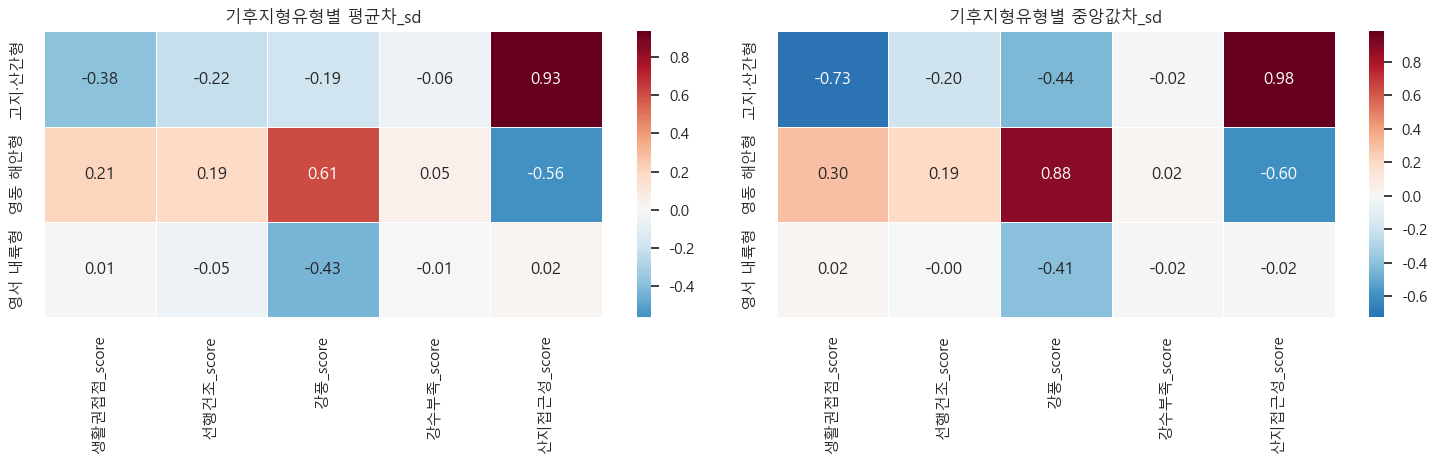

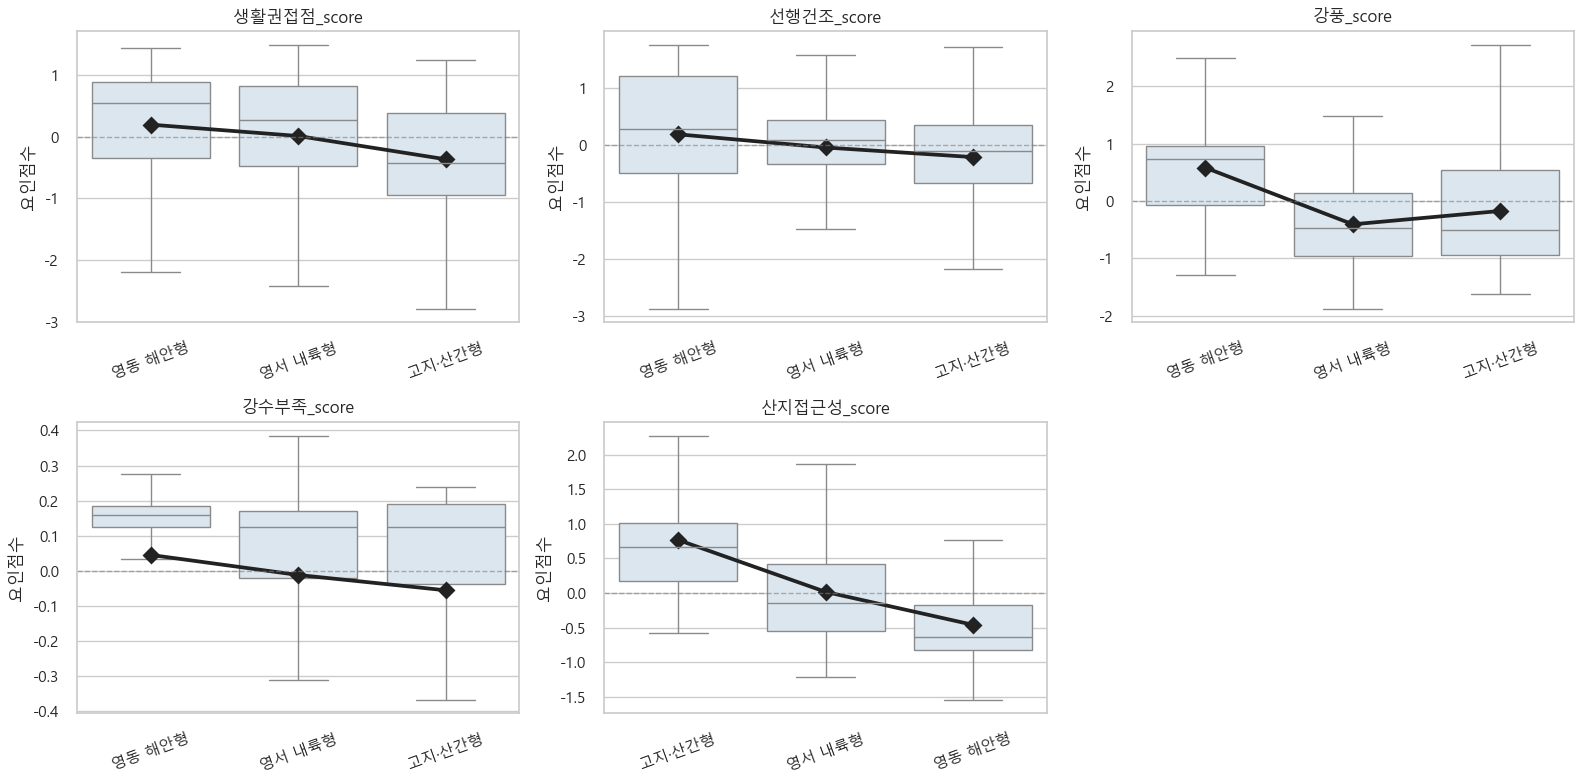

In [65]:
# 8-1-4. 기후지형유형별 요인점수 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

sns.heatmap(
    climate_terrain_summary_wide_mean,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("기후지형유형별 평균차_sd")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    climate_terrain_summary_wide_median,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("기후지형유형별 중앙값차_sd")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

plot_df = seq_meta_work.melt(
    id_vars=SEQ_META_COL,
    value_vars=SEQ_FACTOR_SCORE_COLS,
    var_name="요인점수",
    value_name="score",
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, score_col in enumerate(SEQ_FACTOR_SCORE_COLS):
    ax = axes[idx]
    score_plot_df = plot_df[plot_df["요인점수"] == score_col].copy()
    order = (
        score_plot_df
        .groupby(SEQ_META_COL)["score"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    sns.boxplot(
        data=score_plot_df,
        x=SEQ_META_COL,
        y="score",
        order=order,
        ax=ax,
        color="#d9e6f2",
        showfliers=False,
    )
    sns.pointplot(
        data=score_plot_df,
        x=SEQ_META_COL,
        y="score",
        order=order,
        ax=ax,
        color="#222222",
        markers="D",
        errorbar=None,
    )
    ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(score_col)
    ax.set_xlabel("")
    ax.set_ylabel("요인점수")
    ax.tick_params(axis="x", rotation=20)

for j in range(len(SEQ_FACTOR_SCORE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 8-1 실행 결과 해석: 기후지형유형별 요인점수

`기후지형유형`은 5개 요인점수 중 `강풍_score`와 `산지접근성_score`를 가장 명확하게 설명한다. 즉 이 메타데이터는 산불 발생지를 `영동 해안형 = 강풍형`, `고지·산간형 = 산지접근성형`, `영서 내륙형 = 상대적 저강풍·중간형`으로 구분하는 데 유효하다.

요약하면 다음과 같다.

| 기후지형유형 | 주요 해석 |
| --- | --- |
| `영동 해안형` | `강풍_score`가 뚜렷하게 높고, `산지접근성_score`는 낮음 |
| `고지·산간형` | `산지접근성_score`가 매우 높고, `생활권접점_score`는 낮음 |
| `영서 내륙형` | `강풍_score`가 낮고, 나머지 요인은 대체로 평균권 |

`강풍_score`는 EDA 결론과 가장 잘 맞는다. `영동 해안형`은 평균차 `+0.6118sd`, 중앙값차 `+0.8810sd`로 다른 유형보다 뚜렷하게 높다. 반대로 `영서 내륙형`은 평균차 `-0.4326sd`, `고지·산간형`은 평균차 `-0.1860sd`이다. 쌍별 비교에서도 `영서 내륙형 - 영동 해안형`의 평균차는 `-1.0445sd`, `고지·산간형 - 영동 해안형`은 `-0.7979sd`로 크다. 따라서 `영동 해안형`은 명확한 강풍형 산불 환경으로 해석할 수 있다.

`산지접근성_score`도 매우 뚜렷하다. `고지·산간형`은 평균차 `+0.9341sd`, 중앙값차 `+0.9808sd`로 높고, `영동 해안형`은 평균차 `-0.5622sd`로 낮다. 쌍별 비교에서 `고지·산간형 - 영동 해안형`의 평균차는 `+1.4962sd`, 중앙값차는 `+1.5844sd`이다. Kruskal-Wallis 효과크기도 `epsilon_sq = 0.3391`로 5개 요인 중 가장 크다. 따라서 `고지·산간형`은 산지접근성형으로 해석하는 것이 타당하다.

`생활권접점_score`는 보조 해석축이다. `영동 해안형`은 평균차 `+0.2070sd`, 중앙값차 `+0.3002sd`로 약간 높고, `고지·산간형`은 평균차 `-0.3844sd`, 중앙값차 `-0.7252sd`로 낮다. 다만 Kruskal-Wallis 효과크기는 `epsilon_sq = 0.0589`로 작아, 기후지형유형만으로 생활권접점을 강하게 설명한다고 보기는 어렵다.

`선행건조_score`는 방향성은 있으나 강하지 않다. `영동 해안형`은 평균차 `+0.1856sd`, `고지·산간형`은 `-0.2208sd`, `영서 내륙형`은 거의 평균권이다. 효과크기는 `epsilon_sq = 0.0370`으로 매우 작다. 따라서 기후지형유형별 건조 차이는 보조적으로만 해석한다.

`강수부족_score`는 기후지형유형의 주요 해석축으로 사용하지 않는다. 평균차가 모두 `±0.06sd` 이내이고, 중앙값차도 거의 없다. 강수 극단값은 `영동 해안형` 6건, `영서 내륙형` 3건, `고지·산간형` 4건으로 특정 유형에만 몰려 있지 않다. 극단값 제외 전후에도 중앙값 변화는 거의 없으므로, 기후지형유형별 강수부족 차이는 실질적으로 약하다고 판단한다.

검정 결과는 모든 요인에서 p-value가 매우 작지만, 표본 수가 크므로 p-value보다 효과크기를 기준으로 해석한다. 효과크기 기준으로는 `산지접근성_score`(`epsilon_sq = 0.3391`)와 `강풍_score`(`epsilon_sq = 0.2577`)만 강한 해석축이다. `생활권접점_score`, `선행건조_score`, `강수부족_score`는 통계적으로 유의하더라도 실제 차이는 상대적으로 작다.

따라서 다음 단계에서는 `기후지형유형`에 `addr_type`을 결합한 `기후지형_번지유형`을 확인한다. 이 결합 변수는 `영동 해안형` 내부에서 일반번지와 임야번지가 어떻게 갈리는지, `고지·산간형` 내부에서 임야번지가 산지접근성을 더 강하게 갖는지 확인하는 데 필요하다.

### 8-2. 기후지형_번지유형별 요인점수 해석

8-1에서 `기후지형유형`은 `강풍_score`와 `산지접근성_score`를 강하게 설명했다. 다만 생활권접점은 기후지형만으로는 약하게 설명되므로, 여기서는 `기후지형유형`과 `addr_type`을 결합한 `기후지형_번지유형`을 본다.

확인할 질문은 다음과 같다.

- `영동 해안형 / 일반번지`는 강풍과 생활권접점이 같이 높은가?
- `영동 해안형 / 임야번지(산)`은 강풍은 높지만 생활권접점은 낮아지는가?
- `고지·산간형 / 임야번지(산)`은 산지접근성이 가장 높은가?
- `고지·산간형 / 일반번지`는 산지형과 생활권형의 중간 성격인가?
- `영서 내륙형`은 번지유형에 따라 생활권접점과 산지접근성이 갈리는가?

이 단계도 CSV/이미지 저장 없이 노트북 출력으로만 확인한다.

In [59]:
# 8-2-1. 기후지형_번지유형별 요인점수 요약표
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print


SEQ2_META_COL = "기후지형_번지유형"
SEQ2_FACTOR_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]


def resolve_analysis_dir_for_seq2_meta():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "jsw" / "Analysis",
        Path("jsw/Analysis"),
    ]
    for candidate in candidates:
        if (candidate / "2026-06-08_FA.ipynb").exists() or (candidate / "outputs").exists():
            return candidate
    return cwd


SEQ2_ANALYSIS_DIR = resolve_analysis_dir_for_seq2_meta()
SEQ2_OUTPUT_DIR = SEQ2_ANALYSIS_DIR / "outputs"
oriented_scores_path = SEQ2_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"

if "factor_scores_oriented_source" in globals():
    seq2_factor_meta_df = factor_scores_oriented_source.copy()
    seq2_factor_source = "memory: factor_scores_oriented_source"
elif "factor_scores_oriented" in globals():
    seq2_factor_meta_df = factor_scores_oriented.copy()
    seq2_factor_source = "memory: factor_scores_oriented"
elif oriented_scores_path.exists():
    seq2_factor_meta_df = pd.read_csv(oriented_scores_path, encoding="utf-8-sig")
    seq2_factor_source = str(oriented_scores_path)
else:
    raise FileNotFoundError(
        "방향 보정 요인점수 데이터가 없습니다. 먼저 '요인점수 생성' 섹션을 실행하거나 "
        f"{oriented_scores_path} 파일을 생성해야 합니다."
    )

missing_cols = [
    col for col in [SEQ2_META_COL] + SEQ2_FACTOR_SCORE_COLS
    if col not in seq2_factor_meta_df.columns
]
if missing_cols:
    raise KeyError(f"기후지형_번지유형 해석에 필요한 컬럼이 없습니다: {missing_cols}")

seq2_meta_work = seq2_factor_meta_df[[SEQ2_META_COL] + SEQ2_FACTOR_SCORE_COLS].copy()
for score_col in SEQ2_FACTOR_SCORE_COLS:
    seq2_meta_work[score_col] = pd.to_numeric(seq2_meta_work[score_col], errors="coerce")

seq2_meta_work = seq2_meta_work.dropna(subset=[SEQ2_META_COL] + SEQ2_FACTOR_SCORE_COLS).copy()
seq2_meta_work[SEQ2_META_COL] = seq2_meta_work[SEQ2_META_COL].astype(str)

seq2_group_order = (
    seq2_meta_work[SEQ2_META_COL]
    .value_counts()
    .sort_index()
    .index
    .tolist()
)
seq2_overall = seq2_meta_work[SEQ2_FACTOR_SCORE_COLS].agg(["mean", "median", "std"]).T

summary_rows = []
total_n = len(seq2_meta_work)
for group_name, group_df in seq2_meta_work.groupby(SEQ2_META_COL, dropna=False):
    for score_col in SEQ2_FACTOR_SCORE_COLS:
        values = group_df[score_col].dropna()
        overall_mean = seq2_overall.loc[score_col, "mean"]
        overall_median = seq2_overall.loc[score_col, "median"]
        overall_std = seq2_overall.loc[score_col, "std"]

        summary_rows.append(
            {
                "메타데이터": SEQ2_META_COL,
                "그룹": group_name,
                "요인점수": score_col,
                "n": int(values.size),
                "비율": values.size / total_n,
                "평균": values.mean(),
                "중앙값": values.median(),
                "표준편차": values.std(ddof=1),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "평균차_sd": (values.mean() - overall_mean) / overall_std,
                "중앙값차_sd": (values.median() - overall_median) / overall_std,
            }
        )

climate_addr_summary_long = pd.DataFrame(summary_rows)
climate_addr_summary_wide_mean = climate_addr_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="평균차_sd",
).loc[seq2_group_order, SEQ2_FACTOR_SCORE_COLS]
climate_addr_summary_wide_median = climate_addr_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="중앙값차_sd",
).loc[seq2_group_order, SEQ2_FACTOR_SCORE_COLS]

climate_addr_group_n = (
    seq2_meta_work[SEQ2_META_COL]
    .value_counts()
    .rename_axis("그룹")
    .reset_index(name="n")
)
climate_addr_group_n["비율"] = climate_addr_group_n["n"] / total_n

print(f"요인점수 원천: {seq2_factor_source}")
print(f"{SEQ2_META_COL} 해석 입력 n: {total_n:,}")
print("그룹별 n")
display(climate_addr_group_n.round(4))
print("그룹별 평균차_sd")
display(climate_addr_summary_wide_mean.round(4))
print("그룹별 중앙값차_sd")
display(climate_addr_summary_wide_median.round(4))
print("상세 요약표")
display(
    climate_addr_summary_long
    .sort_values(["요인점수", "평균차_sd"], ascending=[True, False])
    .round(4)
)

요인점수 원천: memory: factor_scores_oriented_source
기후지형_번지유형 해석 입력 n: 2,670
그룹별 n


,그룹,n,비율
0,영서 내륙형 / 일반번지,867,0.3247
1,영동 해안형 / 일반번지,746,0.2794
2,고지·산간형 / 일반번지,358,0.1341
3,영서 내륙형 / 임야번지(산),267,0.1000
4,영동 해안형 / 임야번지(산),227,0.0850
5,고지·산간형 / 임야번지(산),205,0.0768


그룹별 평균차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
고지·산간형 / 일반번지,-0.0057,0.0289,-0.0113,-0.0974,0.8557
고지·산간형 / 임야번지(산),-1.0457,-0.6568,-0.4911,0.0148,1.0709
영동 해안형 / 일반번지,0.4645,0.0293,0.5361,0.0133,-0.6498
영동 해안형 / 임야번지(산),-0.6395,0.6992,0.8607,0.1560,-0.2742
영서 내륙형 / 일반번지,0.3615,-0.0689,-0.4417,-0.0397,-0.1714
영서 내륙형 / 임야번지(산),-1.1174,0.0129,-0.4033,0.0786,0.6355


그룹별 중앙값차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
고지·산간형 / 일반번지,-0.0422,-0.1209,-0.3202,-0.0518,0.9302
고지·산간형 / 임야번지(산),-1.2611,-0.5953,-0.8848,0.0501,1.0019
영동 해안형 / 일반번지,0.4901,0.0509,0.8245,0.0152,-0.6406
영동 해안형 / 임야번지(산),-0.9355,1.0720,0.9582,0.0326,-0.2983
영서 내륙형 / 일반번지,0.3192,-0.0214,-0.4352,-0.0363,-0.0956
영서 내륙형 / 임야번지(산),-1.3680,0.0939,-0.3357,0.0106,0.6574


상세 요약표


,메타데이터,그룹,요인점수,n,비율,평균,중앙값,표준편차,Q1,Q3,평균차_sd,중앙값차_sd
18,기후지형_번지유형,영동 해안형 / 임야번지(산),강수부족_score,227,0.0850,0.1522,0.1721,0.1307,0.1400,0.2003,0.1560,0.0326
28,기후지형_번지유형,영서 내륙형 / 임야번지(산),강수부족_score,267,0.1000,0.0767,0.1507,0.3701,0.1050,0.2087,0.0786,0.0106
8,기후지형_번지유형,고지·산간형 / 임야번지(산),강수부족_score,205,0.0768,0.0144,0.1892,0.4557,0.0523,0.2092,0.0148,0.0501
13,기후지형_번지유형,영동 해안형 / 일반번지,강수부족_score,746,0.2794,0.0129,0.1552,1.7226,0.1206,0.1793,0.0133,0.0152
23,기후지형_번지유형,영서 내륙형 / 일반번지,강수부족_score,867,0.3247,-0.0388,0.1049,0.3824,-0.1267,0.1577,-0.0397,-0.0363
3,기후지형_번지유형,고지·산간형 / 일반번지,강수부족_score,358,0.1341,-0.0951,0.0898,0.5540,-0.0625,0.1345,-0.0974,-0.0518
17,기후지형_번지유형,영동 해안형 / 임야번지(산),강풍_score,227,0.0850,0.8130,0.8080,0.6637,0.6502,1.0183,0.8607,0.9582
12,기후지형_번지유형,영동 해안형 / 일반번지,강풍_score,746,0.2794,0.5064,0.6817,0.7765,-0.1009,0.9604,0.5361,0.8245
2,기후지형_번지유형,고지·산간형 / 일반번지,강풍_score,358,0.1341,-0.0107,-0.3995,1.1097,-0.8273,0.6328,-0.0113,-0.3202
27,기후지형_번지유형,영서 내륙형 / 임야번지(산),강풍_score,267,0.1000,-0.3809,-0.4142,0.7016,-0.8905,0.1010,-0.4033,-0.3357


In [60]:
# 8-2-2. 기후지형_번지유형별 Kruskal-Wallis 검정 및 쌍별 비교
def seq2_benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = np.empty(n, dtype=float)
    cumulative = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        value = ranked[i] * n / rank
        cumulative = min(cumulative, value)
        adjusted[order[i]] = min(cumulative, 1.0)
    return adjusted


SEQ2_PAIRWISE_DISPLAY_N = 45

kruskal_rows = []
pairwise_rows = []
groups_in_order = seq2_group_order

for score_col in SEQ2_FACTOR_SCORE_COLS:
    group_values = [
        seq2_meta_work.loc[seq2_meta_work[SEQ2_META_COL] == group, score_col].dropna().to_numpy()
        for group in groups_in_order
    ]
    group_values = [values for values in group_values if len(values) > 0]

    if len(group_values) >= 2:
        h_stat, p_value = stats.kruskal(*group_values)
        n_total = sum(len(values) for values in group_values)
        k_groups = len(group_values)
        epsilon_sq = (h_stat - k_groups + 1) / (n_total - k_groups) if n_total > k_groups else np.nan
        epsilon_sq = max(epsilon_sq, 0) if pd.notna(epsilon_sq) else np.nan
    else:
        h_stat, p_value, epsilon_sq = np.nan, np.nan, np.nan

    kruskal_rows.append(
        {
            "메타데이터": SEQ2_META_COL,
            "요인점수": score_col,
            "H": h_stat,
            "p_value": p_value,
            "epsilon_sq": epsilon_sq,
            "그룹수": len(group_values),
            "n": sum(len(values) for values in group_values),
        }
    )

    for group_a, group_b in combinations(groups_in_order, 2):
        values_a = seq2_meta_work.loc[seq2_meta_work[SEQ2_META_COL] == group_a, score_col].dropna()
        values_b = seq2_meta_work.loc[seq2_meta_work[SEQ2_META_COL] == group_b, score_col].dropna()
        if len(values_a) == 0 or len(values_b) == 0:
            continue

        u_stat, pair_p = stats.mannwhitneyu(values_a, values_b, alternative="two-sided")
        rank_biserial = (2 * u_stat / (len(values_a) * len(values_b))) - 1
        overall_std = seq2_overall.loc[score_col, "std"]

        pairwise_rows.append(
            {
                "요인점수": score_col,
                "그룹A": group_a,
                "그룹B": group_b,
                "A_n": len(values_a),
                "B_n": len(values_b),
                "A_평균": values_a.mean(),
                "B_평균": values_b.mean(),
                "A-B_평균차_sd": (values_a.mean() - values_b.mean()) / overall_std,
                "A_중앙값": values_a.median(),
                "B_중앙값": values_b.median(),
                "A-B_중앙값차_sd": (values_a.median() - values_b.median()) / overall_std,
                "mannwhitney_p": pair_p,
                "rank_biserial_A_gt_B": rank_biserial,
            }
        )

climate_addr_kruskal = pd.DataFrame(kruskal_rows)
climate_addr_pairwise = pd.DataFrame(pairwise_rows)
if not climate_addr_pairwise.empty:
    climate_addr_pairwise["p_fdr"] = seq2_benjamini_hochberg(
        climate_addr_pairwise["mannwhitney_p"].to_numpy()
    )

print("Kruskal-Wallis 검정")
display(
    climate_addr_kruskal
    .sort_values("epsilon_sq", ascending=False)
    .round(6)
)

print(f"쌍별 비교: 평균차_sd 절대값 기준 상위 {SEQ2_PAIRWISE_DISPLAY_N}개")
display(
    climate_addr_pairwise
    .assign(abs_mean_diff=lambda df: df["A-B_평균차_sd"].abs())
    .sort_values(["abs_mean_diff", "p_fdr"], ascending=[False, True])
    .drop(columns="abs_mean_diff")
    .head(SEQ2_PAIRWISE_DISPLAY_N)
    .round(6)
)

Kruskal-Wallis 검정


,메타데이터,요인점수,H,p_value,epsilon_sq,그룹수,n
4,기후지형_번지유형,산지접근성_score,1091.528724,0.0,0.407856,6,2670
0,기후지형_번지유형,생활권접점_score,841.369042,0.0,0.313952,6,2670
2,기후지형_번지유형,강풍_score,734.282064,0.0,0.273755,6,2670
3,기후지형_번지유형,강수부족_score,342.952898,0.0,0.126859,6,2670
1,기후지형_번지유형,선행건조_score,244.034777,0.0,0.089728,6,2670


쌍별 비교: 평균차_sd 절대값 기준 상위 45개


,요인점수,그룹A,그룹B,A_n,B_n,A_평균,B_평균,A-B_평균차_sd,A_중앙값,B_중앙값,A-B_중앙값차_sd,mannwhitney_p,rank_biserial_A_gt_B,p_fdr
65,산지접근성_score,고지·산간형 / 임야번지(산),영동 해안형 / 일반번지,205,746,0.877998,-0.532719,1.720684,0.685616,-0.661023,1.642528,0.000000,0.908573,0.000000
11,생활권접점_score,영동 해안형 / 일반번지,영서 내륙형 / 임야번지(산),746,267,0.441280,-1.061498,1.581942,0.728210,-1.036870,1.858062,0.000000,0.761294,0.000000
5,생활권접점_score,고지·산간형 / 임야번지(산),영동 해안형 / 일반번지,205,746,-0.993389,0.441280,-1.510245,-0.935376,0.728210,-1.751222,0.000000,-0.829922,0.000000
61,산지접근성_score,고지·산간형 / 일반번지,영동 해안형 / 일반번지,358,746,0.701536,-0.532719,1.505450,0.626866,-0.661023,1.570869,0.000000,0.898378,0.000000
14,생활권접점_score,영서 내륙형 / 일반번지,영서 내륙형 / 임야번지(산),867,267,0.343366,-1.061498,1.478871,0.565831,-1.036870,1.687130,0.000000,0.709157,0.000000
7,생활권접점_score,고지·산간형 / 임야번지(산),영서 내륙형 / 일반번지,205,867,-0.993389,0.343366,-1.407174,-0.935376,0.565831,-1.580289,0.000000,-0.790643,0.000000
21,선행건조_score,고지·산간형 / 임야번지(산),영동 해안형 / 임야번지(산),205,227,-0.644432,0.686002,-1.356070,-0.493863,1.141897,-1.667280,0.000000,-0.666101,0.000000
36,강풍_score,고지·산간형 / 임야번지(산),영동 해안형 / 임야번지(산),205,227,-0.463827,0.812969,-1.351766,-0.932749,0.808017,-1.842980,0.000000,-0.707188,0.000000
66,산지접근성_score,고지·산간형 / 임야번지(산),영동 해안형 / 임야번지(산),205,227,0.877998,-0.224825,1.345139,0.685616,-0.380387,1.300229,0.000000,0.732975,0.000000
42,강풍_score,영동 해안형 / 임야번지(산),영서 내륙형 / 일반번지,227,867,0.812969,-0.417177,1.302377,0.808017,-0.508119,1.393417,0.000000,0.775244,0.000000


In [61]:
# 8-2-3. 핵심 질문 검증표
SEQ2_KEY_QUESTIONS = [
    {
        "질문": "영동 해안형 / 일반번지는 강풍과 생활권접점이 같이 높은가?",
        "그룹": "영동 해안형 / 일반번지",
        "확인요인": ["강풍_score", "생활권접점_score"],
    },
    {
        "질문": "영동 해안형 / 임야번지(산)은 강풍은 높고 생활권접점은 낮아지는가?",
        "그룹": "영동 해안형 / 임야번지(산)",
        "확인요인": ["강풍_score", "생활권접점_score", "산지접근성_score"],
    },
    {
        "질문": "고지·산간형 / 임야번지(산)은 산지접근성이 가장 높은가?",
        "그룹": "고지·산간형 / 임야번지(산)",
        "확인요인": ["산지접근성_score", "생활권접점_score"],
    },
    {
        "질문": "고지·산간형 / 일반번지는 산지형과 생활권형의 중간 성격인가?",
        "그룹": "고지·산간형 / 일반번지",
        "확인요인": ["산지접근성_score", "생활권접점_score"],
    },
    {
        "질문": "영서 내륙형은 번지유형에 따라 생활권접점과 산지접근성이 갈리는가?",
        "그룹": "영서 내륙형 / 일반번지",
        "확인요인": ["생활권접점_score", "산지접근성_score"],
    },
    {
        "질문": "영서 내륙형 임야번지는 일반번지보다 산지접근성이 높은가?",
        "그룹": "영서 내륙형 / 임야번지(산)",
        "확인요인": ["생활권접점_score", "산지접근성_score"],
    },
]

key_rows = []
for item in SEQ2_KEY_QUESTIONS:
    group_name = item["그룹"]
    for score_col in item["확인요인"]:
        matched = climate_addr_summary_long[
            (climate_addr_summary_long["그룹"] == group_name)
            & (climate_addr_summary_long["요인점수"] == score_col)
        ]
        if matched.empty:
            key_rows.append(
                {
                    "질문": item["질문"],
                    "그룹": group_name,
                    "요인점수": score_col,
                    "n": np.nan,
                    "평균차_sd": np.nan,
                    "중앙값차_sd": np.nan,
                    "판정": "그룹 없음",
                }
            )
            continue

        row = matched.iloc[0]
        mean_diff = row["평균차_sd"]
        median_diff = row["중앙값차_sd"]
        if mean_diff >= 0.30 and median_diff >= 0.30:
            decision = "높음"
        elif mean_diff <= -0.30 and median_diff <= -0.30:
            decision = "낮음"
        elif abs(mean_diff) < 0.30 and abs(median_diff) < 0.30:
            decision = "차이 약함"
        else:
            decision = "평균/중앙값 불일치"

        key_rows.append(
            {
                "질문": item["질문"],
                "그룹": group_name,
                "요인점수": score_col,
                "n": int(row["n"]),
                "평균차_sd": mean_diff,
                "중앙값차_sd": median_diff,
                "판정": decision,
            }
        )

climate_addr_key_questions = pd.DataFrame(key_rows)
display(climate_addr_key_questions.round(4))

,질문,그룹,요인점수,n,평균차_sd,중앙값차_sd,판정
0,영동 해안형 / 일반번지는 강풍과 생활권접점이 같이 높은가?,영동 해안형 / 일반번지,강풍_score,746,0.5361,0.8245,높음
1,영동 해안형 / 일반번지는 강풍과 생활권접점이 같이 높은가?,영동 해안형 / 일반번지,생활권접점_score,746,0.4645,0.4901,높음
2,영동 해안형 / 임야번지(산)은 강풍은 높고 생활권접점은 낮아지는가?,영동 해안형 / 임야번지(산),강풍_score,227,0.8607,0.9582,높음
3,영동 해안형 / 임야번지(산)은 강풍은 높고 생활권접점은 낮아지는가?,영동 해안형 / 임야번지(산),생활권접점_score,227,-0.6395,-0.9355,낮음
4,영동 해안형 / 임야번지(산)은 강풍은 높고 생활권접점은 낮아지는가?,영동 해안형 / 임야번지(산),산지접근성_score,227,-0.2742,-0.2983,차이 약함
5,고지·산간형 / 임야번지(산)은 산지접근성이 가장 높은가?,고지·산간형 / 임야번지(산),산지접근성_score,205,1.0709,1.0019,높음
6,고지·산간형 / 임야번지(산)은 산지접근성이 가장 높은가?,고지·산간형 / 임야번지(산),생활권접점_score,205,-1.0457,-1.2611,낮음
7,고지·산간형 / 일반번지는 산지형과 생활권형의 중간 성격인가?,고지·산간형 / 일반번지,산지접근성_score,358,0.8557,0.9302,높음
8,고지·산간형 / 일반번지는 산지형과 생활권형의 중간 성격인가?,고지·산간형 / 일반번지,생활권접점_score,358,-0.0057,-0.0422,차이 약함
9,영서 내륙형은 번지유형에 따라 생활권접점과 산지접근성이 갈리는가?,영서 내륙형 / 일반번지,생활권접점_score,867,0.3615,0.3192,높음


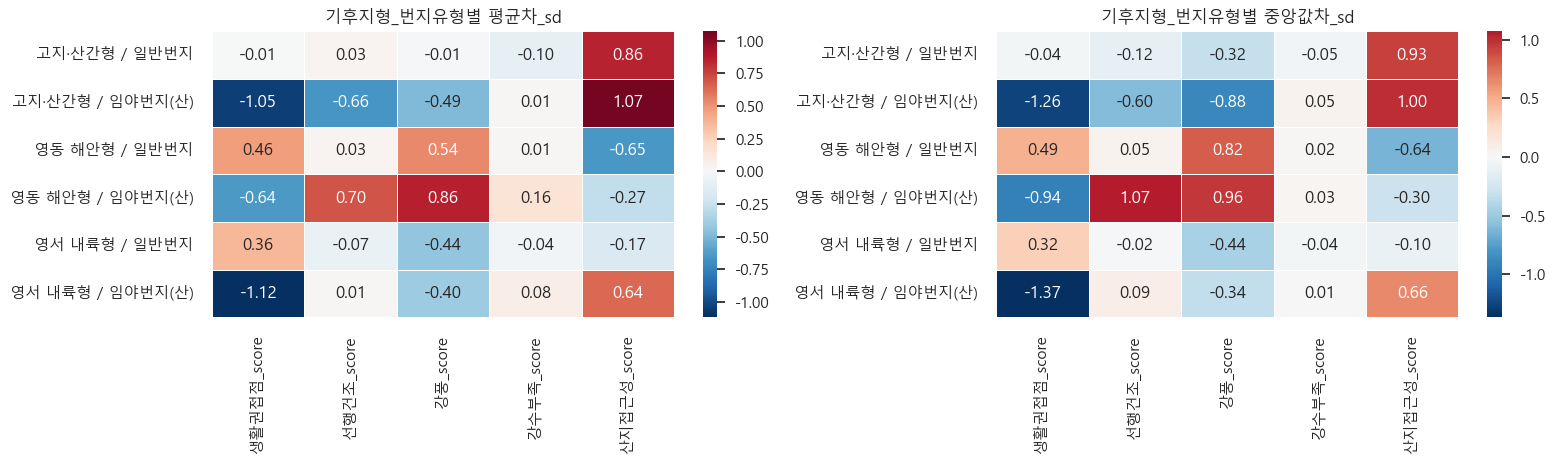

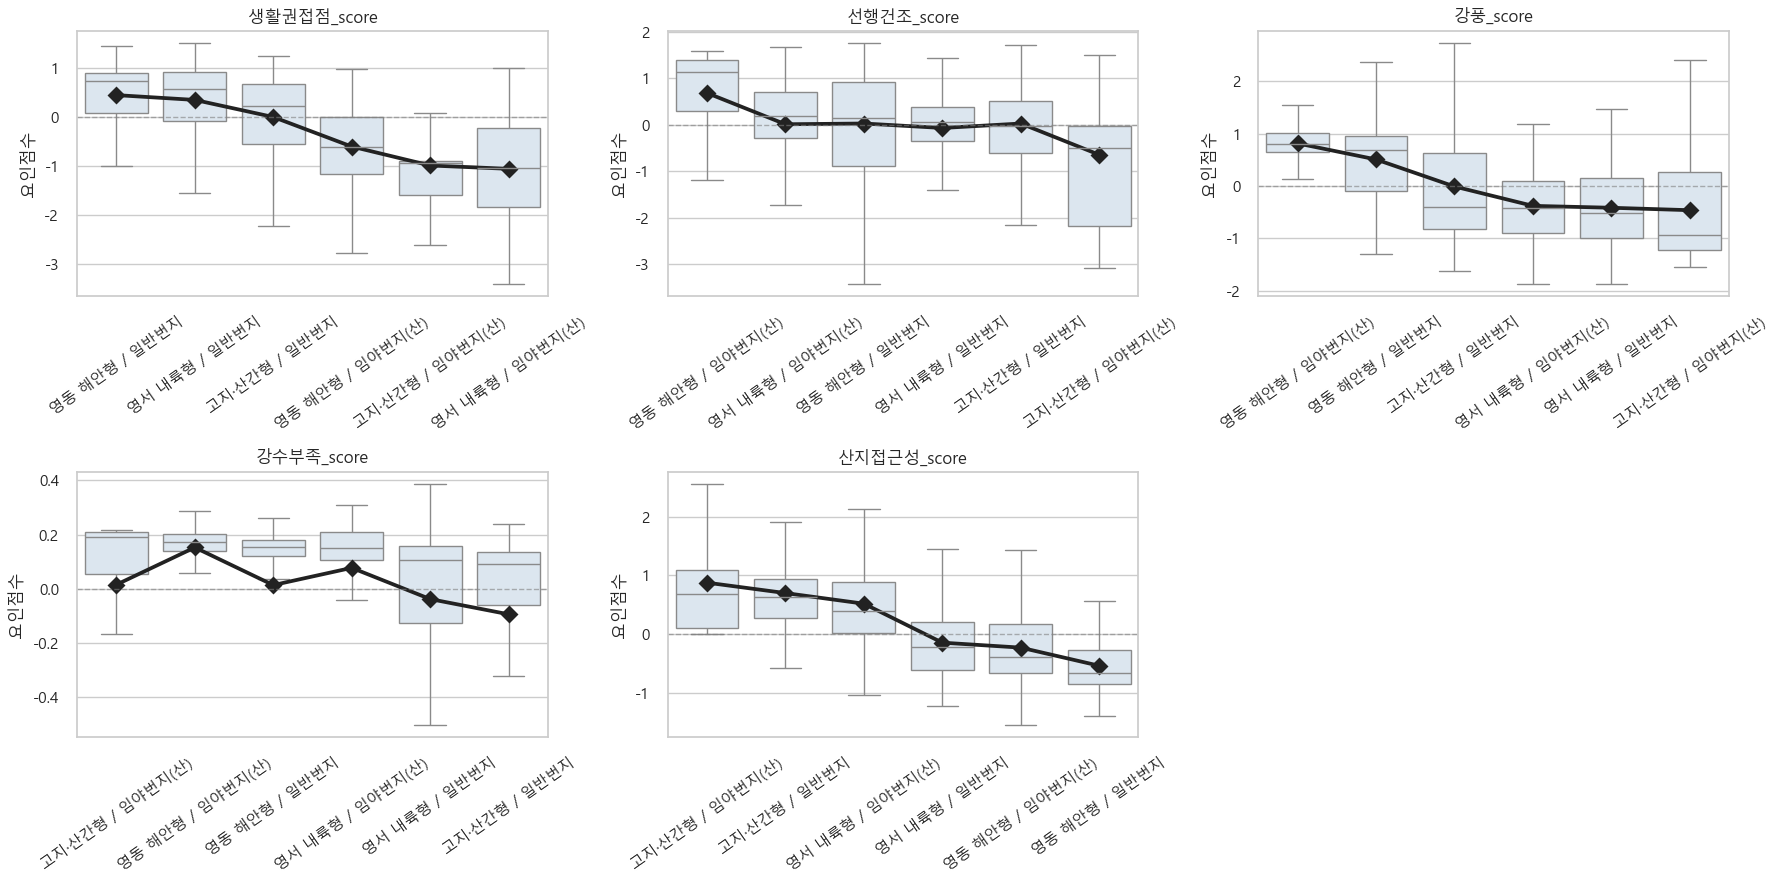

In [64]:
# 8-2-4. 기후지형_번지유형별 요인점수 시각화
fig_height = max(4.8, 0.45 * len(seq2_group_order))
fig, axes = plt.subplots(1, 2, figsize=(16, fig_height))

sns.heatmap(
    climate_addr_summary_wide_mean,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("기후지형_번지유형별 평균차_sd")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    climate_addr_summary_wide_median,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("기후지형_번지유형별 중앙값차_sd")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

plot_df = seq2_meta_work.melt(
    id_vars=SEQ2_META_COL,
    value_vars=SEQ2_FACTOR_SCORE_COLS,
    var_name="요인점수",
    value_name="score",
)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for idx, score_col in enumerate(SEQ2_FACTOR_SCORE_COLS):
    ax = axes[idx]
    score_plot_df = plot_df[plot_df["요인점수"] == score_col].copy()
    order = (
        score_plot_df
        .groupby(SEQ2_META_COL)["score"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    sns.boxplot(
        data=score_plot_df,
        x=SEQ2_META_COL,
        y="score",
        order=order,
        ax=ax,
        color="#d9e6f2",
        showfliers=False,
    )
    sns.pointplot(
        data=score_plot_df,
        x=SEQ2_META_COL,
        y="score",
        order=order,
        ax=ax,
        color="#222222",
        markers="D",
        errorbar=None,
    )
    ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(score_col)
    ax.set_xlabel("")
    ax.set_ylabel("요인점수")
    ax.tick_params(axis="x", rotation=35)

for j in range(len(SEQ2_FACTOR_SCORE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 8-2 실행 결과 해석: 기후지형_번지유형별 요인점수

`기후지형_번지유형`은 8-1의 `기후지형유형`보다 요인점수 차이를 더 잘 설명한다. 특히 `addr_type`이 결합되면서 `생활권접점_score`의 차이가 크게 드러났다. 8-1에서는 `생활권접점_score`의 효과크기가 `epsilon_sq = 0.0589`로 작았지만, 8-2에서는 `epsilon_sq = 0.3140`으로 커졌다. 즉 생활권 접점은 기후지형만으로 설명하기보다 일반번지와 임야번지 구분을 함께 봐야 한다.

분석 대상은 총 `n=2,670`이며, 그룹별 표본 수는 다음과 같다.

| 그룹 | n | 비율 |
| --- | ---: | ---: |
| `영서 내륙형 / 일반번지` | `867` | `0.3247` |
| `영동 해안형 / 일반번지` | `746` | `0.2794` |
| `고지·산간형 / 일반번지` | `358` | `0.1341` |
| `영서 내륙형 / 임야번지(산)` | `267` | `0.1000` |
| `영동 해안형 / 임야번지(산)` | `227` | `0.0850` |
| `고지·산간형 / 임야번지(산)` | `205` | `0.0768` |

Kruskal-Wallis 효과크기를 보면 `산지접근성_score`가 가장 크고, 그 다음이 `생활권접점_score`, `강풍_score`이다.

| 요인점수 | epsilon_sq | 해석 |
| --- | ---: | --- |
| `산지접근성_score` | `0.4079` | 가장 강한 구분축 |
| `생활권접점_score` | `0.3140` | 번지유형 결합 후 강한 구분축으로 상승 |
| `강풍_score` | `0.2738` | 영동 해안형을 구분하는 강한 축 |
| `강수부족_score` | `0.1269` | 통계적 차이는 있으나 평균·중앙값 차이는 작음 |
| `선행건조_score` | `0.0897` | 일부 그룹에서만 뚜렷한 보조 축 |

핵심 그룹별 해석은 다음과 같다.

| 그룹 | 해석 |
| --- | --- |
| `영동 해안형 / 일반번지` | 강풍과 생활권접점이 함께 높은 생활권-강풍형 |
| `영동 해안형 / 임야번지(산)` | 강풍과 선행건조가 높고 생활권접점은 낮은 영동 임야 강풍-건조형 |
| `고지·산간형 / 임야번지(산)` | 산지접근성이 가장 높고 생활권접점이 가장 낮은 산지 원격형 |
| `고지·산간형 / 일반번지` | 산지접근성은 높지만 생활권접점은 평균권인 산지 일반번지형 |
| `영서 내륙형 / 일반번지` | 생활권접점은 높지만 강풍과 산지접근성은 낮은 내륙 생활권형 |
| `영서 내륙형 / 임야번지(산)` | 생활권접점은 낮고 산지접근성은 높은 내륙 임야 산지형 |

`영동 해안형 / 일반번지`는 `강풍_score` 평균차 `+0.5361sd`, 중앙값차 `+0.8245sd`이고, `생활권접점_score` 평균차 `+0.4645sd`, 중앙값차 `+0.4901sd`이다. 따라서 이 그룹은 `영동 해안형`의 강풍 특성과 `일반번지`의 생활권 접점 특성이 결합된 유형이다. 플롯에서도 생활권접점과 강풍 분포가 모두 상위권에 위치한다.

`영동 해안형 / 임야번지(산)`은 `강풍_score`가 평균차 `+0.8607sd`, 중앙값차 `+0.9582sd`로 가장 높다. 동시에 `생활권접점_score`는 평균차 `-0.6395sd`, 중앙값차 `-0.9355sd`로 낮다. 즉 같은 영동 해안형이라도 일반번지는 생활권 접점형, 임야번지는 생활권과 떨어진 강풍형으로 분리된다. 또한 이 그룹은 `선행건조_score`도 평균차 `+0.6992sd`, 중앙값차 `+1.0720sd`로 높아, 영동 임야 지역에서는 강풍과 선행건조가 함께 나타나는 보조 패턴이 보인다.

`고지·산간형 / 임야번지(산)`은 `산지접근성_score`가 평균차 `+1.0709sd`, 중앙값차 `+1.0019sd`로 가장 높고, `생활권접점_score`는 평균차 `-1.0457sd`, 중앙값차 `-1.2611sd`로 매우 낮다. 이는 산지성이 강하고 생활권 접점이 낮은 전형적인 산지 원격형이다. 쌍별 비교에서도 이 그룹과 `영동 해안형 / 일반번지`의 `산지접근성_score` 평균차는 `+1.7207sd`로 가장 크다.

`고지·산간형 / 일반번지`는 `산지접근성_score`가 평균차 `+0.8557sd`, 중앙값차 `+0.9302sd`로 높지만, `생활권접점_score`는 평균차 `-0.0057sd`, 중앙값차 `-0.0422sd`로 평균권이다. 따라서 고지·산간형이라도 일반번지는 완전한 원격 산지형이라기보다 산지 접근성은 높지만 생활권 접점은 중간 수준인 유형으로 해석한다.

`영서 내륙형 / 일반번지`는 `생활권접점_score`가 평균차 `+0.3615sd`, 중앙값차 `+0.3192sd`로 높고, `강풍_score`는 평균차 `-0.4417sd`, 중앙값차 `-0.4352sd`로 낮다. `산지접근성_score`도 평균차 `-0.1714sd`로 낮은 편이다. 따라서 이 그룹은 강풍형이나 산지형보다는 내륙 생활권형에 가깝다.

`영서 내륙형 / 임야번지(산)`은 `생활권접점_score`가 평균차 `-1.1174sd`, 중앙값차 `-1.3680sd`로 가장 낮고, `산지접근성_score`는 평균차 `+0.6355sd`, 중앙값차 `+0.6574sd`로 높다. 같은 영서 내륙형 안에서도 일반번지와 임야번지의 차이가 명확하며, 번지유형이 생활권접점과 산지접근성을 크게 가른다.

`강수부족_score`는 효과크기만 보면 `epsilon_sq = 0.1269`로 8-1보다 커졌지만, 그룹별 평균차와 중앙값차는 크지 않다. 가장 큰 평균차도 `영동 해안형 / 임야번지(산)`의 `+0.1560sd` 수준이고, 중앙값차는 대부분 `±0.05sd` 안팎이다. 따라서 강수부족은 이 단계의 핵심 해석축으로 두지 않는다.

시각화도 표 해석을 지지한다. 히트맵에서는 일반번지 그룹들이 대체로 `생활권접점_score`에서 붉고, 임야번지 그룹들이 푸르게 나타난다. 반대로 `산지접근성_score`는 `고지·산간형 / 임야번지(산)`, `고지·산간형 / 일반번지`, `영서 내륙형 / 임야번지(산)`에서 높게 나타난다. boxplot에서도 `생활권접점_score`는 일반번지와 임야번지가 분리되고, `강풍_score`는 영동 해안형 두 그룹이 상위권에 위치하며, `산지접근성_score`는 고지·산간형과 영서 내륙형 임야번지가 상위권에 위치한다.

따라서 8-2의 결론은 다음과 같다.

- `기후지형_번지유형`은 8-1의 `기후지형유형`보다 산불 발생지의 공간 성격을 더 잘 구분한다.
- `영동 해안형`의 강풍 특성은 일반번지와 임야번지 모두에서 유지된다.
- `addr_type`은 `생활권접점_score`와 `산지접근성_score`를 강하게 가르는 핵심 메타데이터이다.
- `영동 해안형 / 일반번지`는 생활권-강풍형, `영동 해안형 / 임야번지(산)`은 강풍-건조형, `고지·산간형 / 임야번지(산)`은 산지 원격형으로 해석할 수 있다.
- 다음 단계에서는 `addr_type`만 별도로 확인해, 번지유형 자체가 생활권접점과 산지접근성을 얼마나 설명하는지 검증하는 것이 적절하다.

### 8-2 실행 후 해석 기준

실행 후에는 다음 순서로 해석한다.

- 먼저 `기후지형유형`만 봤을 때 확인한 `영동 해안형 = 강풍형`, `고지·산간형 = 산지접근성형` 결론이 유지되는지 본다.
- 같은 기후지형 안에서 `일반번지`와 `임야번지(산)`의 `생활권접점_score`, `산지접근성_score`가 갈리는지 확인한다.
- `영동 해안형 / 일반번지`가 강풍과 생활권 접점을 동시에 갖는지 확인한다.
- `고지·산간형 / 임야번지(산)`이 산지접근성이 가장 높고 생활권접점이 낮은지 확인한다.
- `강수부족_score`는 8-1에서 핵심 축이 아니었으므로, 큰 차이가 나타나더라도 평균/중앙값과 극단값 영향을 함께 보고 보조적으로만 해석한다.

### 8-3. addr_type별 요인점수 해석

8-2에서 `기후지형_번지유형`은 `생활권접점_score`와 `산지접근성_score`를 강하게 구분했다. 이 차이가 기후지형 결합 때문인지, 아니면 `addr_type` 자체의 영향인지 확인하기 위해 `addr_type`만 단독으로 비교한다.

확인할 질문은 다음과 같다.

- `일반번지`는 `생활권접점_score`가 높고 `산지접근성_score`가 낮은가?
- `임야번지(산)`은 `생활권접점_score`가 낮고 `산지접근성_score`가 높은가?
- `강풍_score`는 번지유형 자체보다 기후지형유형에 의해 설명되는가?
- `선행건조_score`, `강수부족_score`는 번지유형의 핵심 해석축인가?

이 단계도 CSV/이미지 저장 없이 노트북 출력으로만 확인한다.

In [66]:
# 8-3-1. addr_type별 요인점수 요약표
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print


SEQ3_META_COL = "addr_type"
SEQ3_FACTOR_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]


def resolve_analysis_dir_for_seq3_meta():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "jsw" / "Analysis",
        Path("jsw/Analysis"),
    ]
    for candidate in candidates:
        if (candidate / "2026-06-08_FA.ipynb").exists() or (candidate / "outputs").exists():
            return candidate
    return cwd


SEQ3_ANALYSIS_DIR = resolve_analysis_dir_for_seq3_meta()
SEQ3_OUTPUT_DIR = SEQ3_ANALYSIS_DIR / "outputs"
oriented_scores_path = SEQ3_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"

if "factor_scores_oriented_source" in globals():
    seq3_factor_meta_df = factor_scores_oriented_source.copy()
    seq3_factor_source = "memory: factor_scores_oriented_source"
elif "factor_scores_oriented" in globals():
    seq3_factor_meta_df = factor_scores_oriented.copy()
    seq3_factor_source = "memory: factor_scores_oriented"
elif oriented_scores_path.exists():
    seq3_factor_meta_df = pd.read_csv(oriented_scores_path, encoding="utf-8-sig")
    seq3_factor_source = str(oriented_scores_path)
else:
    raise FileNotFoundError(
        "방향 보정 요인점수 데이터가 없습니다. 먼저 '요인점수 생성' 섹션을 실행하거나 "
        f"{oriented_scores_path} 파일을 생성해야 합니다."
    )

missing_cols = [
    col for col in [SEQ3_META_COL] + SEQ3_FACTOR_SCORE_COLS
    if col not in seq3_factor_meta_df.columns
]
if missing_cols:
    raise KeyError(f"addr_type 해석에 필요한 컬럼이 없습니다: {missing_cols}")

seq3_meta_work = seq3_factor_meta_df[[SEQ3_META_COL] + SEQ3_FACTOR_SCORE_COLS].copy()
for score_col in SEQ3_FACTOR_SCORE_COLS:
    seq3_meta_work[score_col] = pd.to_numeric(seq3_meta_work[score_col], errors="coerce")

seq3_meta_work = seq3_meta_work.dropna(subset=[SEQ3_META_COL] + SEQ3_FACTOR_SCORE_COLS).copy()
seq3_meta_work[SEQ3_META_COL] = seq3_meta_work[SEQ3_META_COL].astype(str)

preferred_order = ["일반번지", "임야번지(산)"]
existing_groups = seq3_meta_work[SEQ3_META_COL].dropna().unique().tolist()
seq3_group_order = [group for group in preferred_order if group in existing_groups]
seq3_group_order += [group for group in existing_groups if group not in seq3_group_order]

seq3_overall = seq3_meta_work[SEQ3_FACTOR_SCORE_COLS].agg(["mean", "median", "std"]).T

summary_rows = []
total_n = len(seq3_meta_work)
for group_name, group_df in seq3_meta_work.groupby(SEQ3_META_COL, dropna=False):
    for score_col in SEQ3_FACTOR_SCORE_COLS:
        values = group_df[score_col].dropna()
        overall_mean = seq3_overall.loc[score_col, "mean"]
        overall_median = seq3_overall.loc[score_col, "median"]
        overall_std = seq3_overall.loc[score_col, "std"]

        summary_rows.append(
            {
                "메타데이터": SEQ3_META_COL,
                "그룹": group_name,
                "요인점수": score_col,
                "n": int(values.size),
                "비율": values.size / total_n,
                "평균": values.mean(),
                "중앙값": values.median(),
                "표준편차": values.std(ddof=1),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "평균차_sd": (values.mean() - overall_mean) / overall_std,
                "중앙값차_sd": (values.median() - overall_median) / overall_std,
            }
        )

addr_type_summary_long = pd.DataFrame(summary_rows)
addr_type_summary_wide_mean = addr_type_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="평균차_sd",
).loc[seq3_group_order, SEQ3_FACTOR_SCORE_COLS]
addr_type_summary_wide_median = addr_type_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="중앙값차_sd",
).loc[seq3_group_order, SEQ3_FACTOR_SCORE_COLS]

addr_type_group_n = (
    seq3_meta_work[SEQ3_META_COL]
    .value_counts()
    .rename_axis("그룹")
    .reset_index(name="n")
)
addr_type_group_n["비율"] = addr_type_group_n["n"] / total_n

print(f"요인점수 원천: {seq3_factor_source}")
print(f"{SEQ3_META_COL} 해석 입력 n: {total_n:,}")
print("그룹별 n")
display(addr_type_group_n.round(4))
print("그룹별 평균차_sd")
display(addr_type_summary_wide_mean.round(4))
print("그룹별 중앙값차_sd")
display(addr_type_summary_wide_median.round(4))
print("상세 요약표")
display(
    addr_type_summary_long
    .sort_values(["요인점수", "평균차_sd"], ascending=[True, False])
    .round(4)
)

요인점수 원천: memory: factor_scores_oriented_source
addr_type 해석 입력 n: 2,670
그룹별 n


,그룹,n,비율
0,일반번지,1971,0.7382
1,임야번지(산),699,0.2618


그룹별 평균차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
일반번지,0.3338,-0.0140,0.0066,-0.0302,-0.1659
임야번지(산),-0.9412,0.0394,-0.0185,0.0850,0.4678


그룹별 중앙값차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
일반번지,0.3272,-0.0120,-0.0036,-0.0087,-0.1455
임야번지(산),-1.2611,0.1634,0.0364,0.0268,0.4110


상세 요약표


,메타데이터,그룹,요인점수,n,비율,평균,중앙값,표준편차,Q1,Q3,평균차_sd,중앙값차_sd
8,addr_type,임야번지(산),강수부족_score,699,0.2618,0.0830,0.1665,0.3484,0.1135,0.2077,0.0850,0.0268
3,addr_type,일반번지,강수부족_score,1971,0.7382,-0.0294,0.1318,1.1152,0.0404,0.1710,-0.0302,-0.0087
2,addr_type,일반번지,강풍_score,1971,0.7382,0.0062,-0.1004,0.9423,-0.7606,0.7395,0.0066,-0.0036
7,addr_type,임야번지(산),강풍_score,699,0.2618,-0.0175,-0.0627,0.9513,-0.9318,0.7845,-0.0185,0.0364
9,addr_type,임야번지(산),산지접근성_score,699,0.2618,0.3835,0.2012,0.8945,-0.1865,0.7849,0.4678,0.4110
4,addr_type,일반번지,산지접근성_score,1971,0.7382,-0.1360,-0.2551,0.7460,-0.6941,0.3245,-0.1659,-0.1455
0,addr_type,일반번지,생활권접점_score,1971,0.7382,0.3171,0.5735,0.7157,-0.1774,0.8890,0.3338,0.3272
5,addr_type,임야번지(산),생활권접점_score,699,0.2618,-0.8941,-0.9354,0.9595,-1.5241,-0.2348,-0.9412,-1.2611
6,addr_type,임야번지(산),선행건조_score,699,0.2618,0.0386,0.2505,1.1511,-0.4939,0.9287,0.0394,0.1634
1,addr_type,일반번지,선행건조_score,1971,0.7382,-0.0137,0.0784,0.9132,-0.5294,0.5421,-0.0140,-0.0120


In [68]:
# 8-3-2. addr_type별 Mann-Whitney 검정 및 효과크기
def seq3_benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = np.empty(n, dtype=float)
    cumulative = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        value = ranked[i] * n / rank
        cumulative = min(cumulative, value)
        adjusted[order[i]] = min(cumulative, 1.0)
    return adjusted


pairwise_rows = []
groups_in_order = seq3_group_order

for score_col in SEQ3_FACTOR_SCORE_COLS:
    for group_a, group_b in combinations(groups_in_order, 2):
        values_a = seq3_meta_work.loc[seq3_meta_work[SEQ3_META_COL] == group_a, score_col].dropna()
        values_b = seq3_meta_work.loc[seq3_meta_work[SEQ3_META_COL] == group_b, score_col].dropna()
        if len(values_a) == 0 or len(values_b) == 0:
            continue

        u_stat, pair_p = stats.mannwhitneyu(values_a, values_b, alternative="two-sided")
        rank_biserial = (2 * u_stat / (len(values_a) * len(values_b))) - 1
        overall_std = seq3_overall.loc[score_col, "std"]

        pairwise_rows.append(
            {
                "요인점수": score_col,
                "그룹A": group_a,
                "그룹B": group_b,
                "A_n": len(values_a),
                "B_n": len(values_b),
                "A_평균": values_a.mean(),
                "B_평균": values_b.mean(),
                "A-B_평균차_sd": (values_a.mean() - values_b.mean()) / overall_std,
                "A_중앙값": values_a.median(),
                "B_중앙값": values_b.median(),
                "A-B_중앙값차_sd": (values_a.median() - values_b.median()) / overall_std,
                "mannwhitney_p": pair_p,
                "rank_biserial_A_gt_B": rank_biserial,
            }
        )

addr_type_pairwise = pd.DataFrame(pairwise_rows)
if not addr_type_pairwise.empty:
    addr_type_pairwise["p_fdr"] = seq3_benjamini_hochberg(
        addr_type_pairwise["mannwhitney_p"].to_numpy()
    )

print("addr_type 쌍별 비교")
display(
    addr_type_pairwise
    .assign(abs_mean_diff=lambda df: df["A-B_평균차_sd"].abs())
    .sort_values(["abs_mean_diff", "p_fdr"], ascending=[False, True])
    .drop(columns="abs_mean_diff")
    .round(6)
)

addr_type 쌍별 비교


,요인점수,그룹A,그룹B,A_n,B_n,A_평균,B_평균,A-B_평균차_sd,A_중앙값,B_중앙값,A-B_중앙값차_sd,mannwhitney_p,rank_biserial_A_gt_B,p_fdr
0,생활권접점_score,일반번지,임야번지(산),1971,699,0.317079,-0.894080,1.274961,0.573472,-0.935376,1.588333,0.000000,0.691251,0.000000
4,산지접근성_score,일반번지,임야번지(산),1971,699,-0.136005,0.383498,-0.633649,-0.255109,0.201208,-0.556580,0.000000,-0.373235,0.000000
3,강수부족_score,일반번지,임야번지(산),1971,699,-0.029421,0.082959,-0.115173,0.131813,0.166517,-0.035566,0.000000,-0.290642,0.000000
1,선행건조_score,일반번지,임야번지(산),1971,699,-0.013693,0.038612,-0.053313,0.078369,0.250541,-0.175489,0.000636,-0.086828,0.000796
2,강풍_score,일반번지,임야번지(산),1971,699,0.006209,-0.017508,0.025110,-0.100441,-0.062669,-0.039991,0.522764,0.016247,0.522764


In [69]:
# 8-3-3. addr_type 핵심 질문 검증표
SEQ3_KEY_QUESTIONS = [
    {
        "질문": "일반번지는 생활권접점이 높은가?",
        "그룹": "일반번지",
        "요인점수": "생활권접점_score",
        "기대방향": "높음",
    },
    {
        "질문": "일반번지는 산지접근성이 낮은가?",
        "그룹": "일반번지",
        "요인점수": "산지접근성_score",
        "기대방향": "낮음",
    },
    {
        "질문": "임야번지(산)은 생활권접점이 낮은가?",
        "그룹": "임야번지(산)",
        "요인점수": "생활권접점_score",
        "기대방향": "낮음",
    },
    {
        "질문": "임야번지(산)은 산지접근성이 높은가?",
        "그룹": "임야번지(산)",
        "요인점수": "산지접근성_score",
        "기대방향": "높음",
    },
    {
        "질문": "번지유형만으로 강풍 차이가 큰가?",
        "그룹": "일반번지",
        "요인점수": "강풍_score",
        "기대방향": "차이 약함",
    },
    {
        "질문": "번지유형만으로 선행건조 차이가 큰가?",
        "그룹": "일반번지",
        "요인점수": "선행건조_score",
        "기대방향": "차이 약함",
    },
    {
        "질문": "번지유형만으로 강수부족 차이가 큰가?",
        "그룹": "일반번지",
        "요인점수": "강수부족_score",
        "기대방향": "차이 약함",
    },
]


def classify_seq3_delta(mean_diff, median_diff, threshold=0.30):
    if pd.isna(mean_diff) or pd.isna(median_diff):
        return "판정불가"
    if mean_diff >= threshold and median_diff >= threshold:
        return "높음"
    if mean_diff <= -threshold and median_diff <= -threshold:
        return "낮음"
    if abs(mean_diff) < threshold and abs(median_diff) < threshold:
        return "차이 약함"
    return "평균/중앙값 불일치"


key_rows = []
for item in SEQ3_KEY_QUESTIONS:
    matched = addr_type_summary_long[
        (addr_type_summary_long["그룹"] == item["그룹"])
        & (addr_type_summary_long["요인점수"] == item["요인점수"])
    ]
    if matched.empty:
        key_rows.append(
            {
                "질문": item["질문"],
                "그룹": item["그룹"],
                "요인점수": item["요인점수"],
                "n": np.nan,
                "평균차_sd": np.nan,
                "중앙값차_sd": np.nan,
                "판정": "그룹 없음",
                "기대방향": item["기대방향"],
                "기대일치": False,
            }
        )
        continue

    row = matched.iloc[0]
    decision = classify_seq3_delta(row["평균차_sd"], row["중앙값차_sd"])
    key_rows.append(
        {
            "질문": item["질문"],
            "그룹": item["그룹"],
            "요인점수": item["요인점수"],
            "n": int(row["n"]),
            "평균차_sd": row["평균차_sd"],
            "중앙값차_sd": row["중앙값차_sd"],
            "판정": decision,
            "기대방향": item["기대방향"],
            "기대일치": decision == item["기대방향"],
        }
    )

addr_type_key_questions = pd.DataFrame(key_rows)
display(addr_type_key_questions.round(4))

,질문,그룹,요인점수,n,평균차_sd,중앙값차_sd,판정,기대방향,기대일치
0,일반번지는 생활권접점이 높은가?,일반번지,생활권접점_score,1971,0.3338,0.3272,높음,높음,True
1,일반번지는 산지접근성이 낮은가?,일반번지,산지접근성_score,1971,-0.1659,-0.1455,차이 약함,낮음,False
2,임야번지(산)은 생활권접점이 낮은가?,임야번지(산),생활권접점_score,699,-0.9412,-1.2611,낮음,낮음,True
3,임야번지(산)은 산지접근성이 높은가?,임야번지(산),산지접근성_score,699,0.4678,0.4110,높음,높음,True
4,번지유형만으로 강풍 차이가 큰가?,일반번지,강풍_score,1971,0.0066,-0.0036,차이 약함,차이 약함,True
5,번지유형만으로 선행건조 차이가 큰가?,일반번지,선행건조_score,1971,-0.0140,-0.0120,차이 약함,차이 약함,True
6,번지유형만으로 강수부족 차이가 큰가?,일반번지,강수부족_score,1971,-0.0302,-0.0087,차이 약함,차이 약함,True


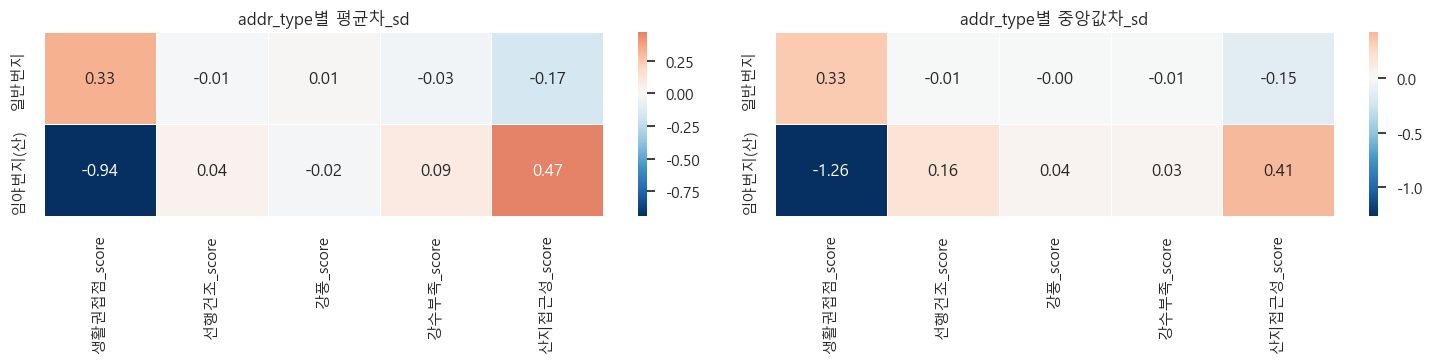

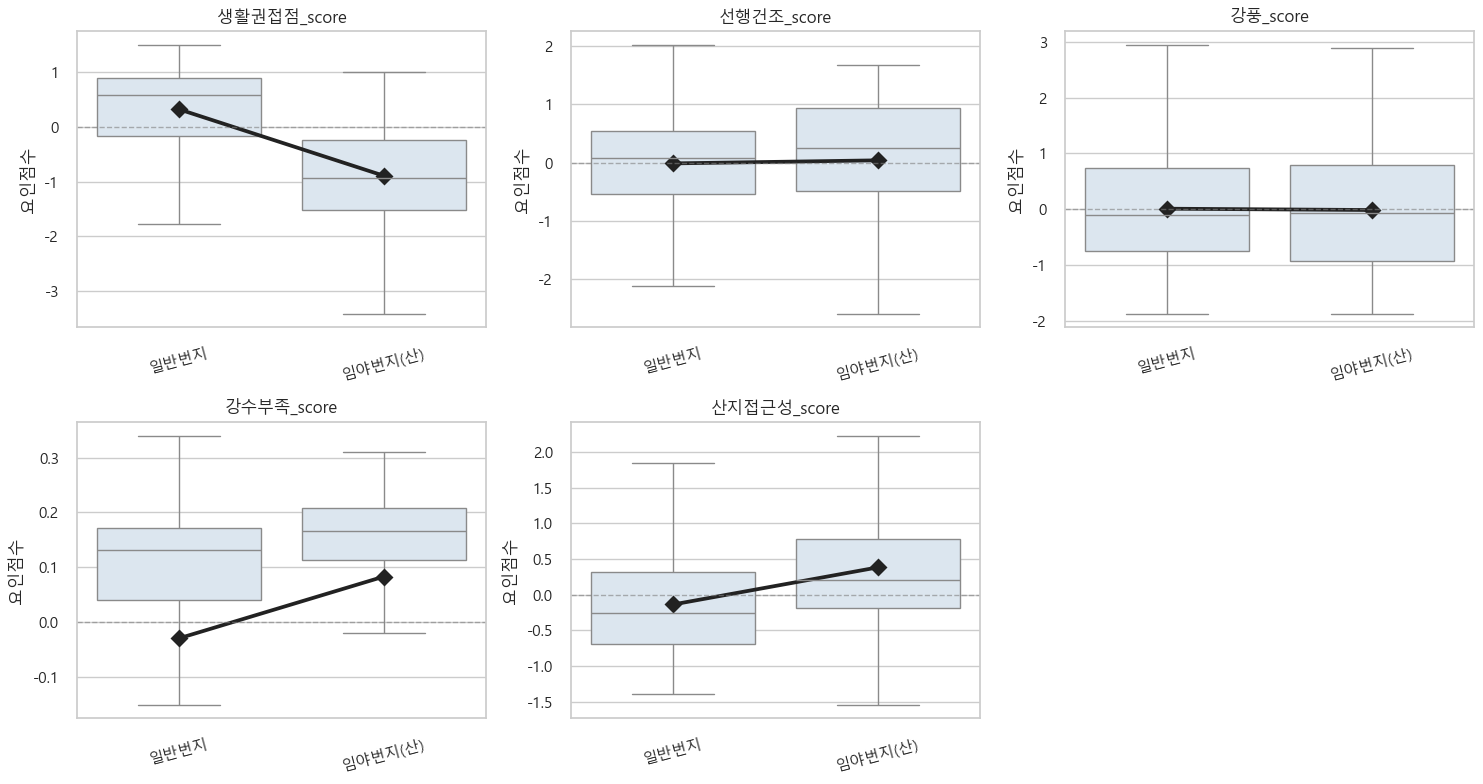

In [70]:
# 8-3-4. addr_type별 요인점수 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))

sns.heatmap(
    addr_type_summary_wide_mean,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("addr_type별 평균차_sd")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    addr_type_summary_wide_median,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("addr_type별 중앙값차_sd")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

plot_df = seq3_meta_work.melt(
    id_vars=SEQ3_META_COL,
    value_vars=SEQ3_FACTOR_SCORE_COLS,
    var_name="요인점수",
    value_name="score",
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, score_col in enumerate(SEQ3_FACTOR_SCORE_COLS):
    ax = axes[idx]
    score_plot_df = plot_df[plot_df["요인점수"] == score_col].copy()
    sns.boxplot(
        data=score_plot_df,
        x=SEQ3_META_COL,
        y="score",
        order=seq3_group_order,
        ax=ax,
        color="#d9e6f2",
        showfliers=False,
    )
    sns.pointplot(
        data=score_plot_df,
        x=SEQ3_META_COL,
        y="score",
        order=seq3_group_order,
        ax=ax,
        color="#222222",
        markers="D",
        errorbar=None,
    )
    ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(score_col)
    ax.set_xlabel("")
    ax.set_ylabel("요인점수")
    ax.tick_params(axis="x", rotation=15)

for j in range(len(SEQ3_FACTOR_SCORE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 8-3 실행 결과 해석: addr_type별 요인점수

`addr_type` 단독 비교 결과, 번지유형은 `생활권접점_score`와 `산지접근성_score`를 설명하는 데 유효하다. 다만 `강풍_score`, `선행건조_score`, `강수부족_score`는 번지유형 자체의 핵심 해석축으로 보기 어렵다.

분석 대상은 총 `n=2,670`이며, `일반번지`가 `1,971건(73.82%)`, `임야번지(산)`이 `699건(26.18%)`이다.

| addr_type | n | 비율 |
| --- | ---: | ---: |
| `일반번지` | `1,971` | `0.7382` |
| `임야번지(산)` | `699` | `0.2618` |

요인점수별 평균차와 중앙값차는 다음과 같다.

| 그룹 | 생활권접점 | 선행건조 | 강풍 | 강수부족 | 산지접근성 |
| --- | ---: | ---: | ---: | ---: | ---: |
| `일반번지` 평균차_sd | `+0.3338` | `-0.0140` | `+0.0066` | `-0.0302` | `-0.1659` |
| `일반번지` 중앙값차_sd | `+0.3272` | `-0.0120` | `-0.0036` | `-0.0087` | `-0.1455` |
| `임야번지(산)` 평균차_sd | `-0.9412` | `+0.0394` | `-0.0185` | `+0.0850` | `+0.4678` |
| `임야번지(산)` 중앙값차_sd | `-1.2611` | `+0.1634` | `+0.0364` | `+0.0268` | `+0.4110` |

가장 뚜렷한 차이는 `생활권접점_score`이다. `일반번지`는 평균차 `+0.3338sd`, 중앙값차 `+0.3272sd`로 높고, `임야번지(산)`은 평균차 `-0.9412sd`, 중앙값차 `-1.2611sd`로 매우 낮다. Mann-Whitney 비교에서도 `일반번지 - 임야번지(산)`의 평균차는 `+1.2750sd`, 중앙값차는 `+1.5883sd`, rank-biserial은 `+0.6913`이다. 따라서 `addr_type`은 생활권 접점 여부를 강하게 가르는 메타데이터이다.

`산지접근성_score`는 `임야번지(산)`에서 높다. `임야번지(산)`은 평균차 `+0.4678sd`, 중앙값차 `+0.4110sd`로 높고, `일반번지`는 평균차 `-0.1659sd`, 중앙값차 `-0.1455sd`로 약간 낮다. 쌍별 비교에서는 `일반번지 - 임야번지(산)`의 평균차가 `-0.6336sd`, 중앙값차가 `-0.5566sd`이다. 즉 `일반번지`가 절대적으로 강한 저산지형이라고 보기는 어렵지만, `임야번지(산)`에 비해 산지접근성이 낮은 것은 분명하다.

`강풍_score`는 번지유형으로 설명되지 않는다. `일반번지` 평균차는 `+0.0066sd`, `임야번지(산)` 평균차는 `-0.0185sd`이고, Mann-Whitney p-value도 `0.5228`로 유의하지 않다. 따라서 강풍은 8-1, 8-2에서 확인한 것처럼 `addr_type`보다 `영동 해안형` 같은 기후지형유형에 의해 설명되는 축이다.

`선행건조_score`와 `강수부족_score`는 통계적으로는 일부 차이가 있지만 실제 해석축으로는 약하다. `선행건조_score`는 `임야번지(산)` 중앙값차가 `+0.1634sd` 정도이고, `강수부족_score`도 `임야번지(산)` 평균차가 `+0.0850sd`에 그친다. 표본 수가 크기 때문에 p-value가 작게 나올 수 있으나, 평균차와 중앙값차 기준으로는 핵심 차이라고 보기 어렵다.

시각화도 같은 결론을 지지한다. `생활권접점_score` boxplot은 일반번지와 임야번지(산)의 분리가 가장 뚜렷하며, 임야번지(산)의 중앙값이 크게 낮다. `산지접근성_score`는 임야번지(산)이 일반번지보다 높지만 분포 겹침은 존재한다. `강풍_score`, `선행건조_score`, `강수부족_score`는 두 그룹의 박스가 상당히 겹쳐 번지유형의 핵심 구분축으로 보기 어렵다.

따라서 8-3의 결론은 다음과 같다.

- `addr_type`은 `생활권접점_score`를 가장 강하게 설명한다.
- `임야번지(산)`은 생활권접점이 낮고 산지접근성이 높은 유형으로 해석할 수 있다.
- `일반번지`는 생활권접점이 높지만, 산지접근성이 절대적으로 낮다고 단정하기보다는 `임야번지(산)`보다 낮다고 해석하는 것이 정확하다.
- `강풍_score`는 번지유형이 아니라 `기후지형유형`, 특히 `영동 해안형`에서 해석해야 한다.
- `선행건조_score`, `강수부족_score`는 addr_type의 핵심 해석축이 아니다.

8-2와 8-3을 종합하면, 산불 발생지의 공간 성격은 `기후지형유형`과 `addr_type`을 함께 볼 때 가장 잘 설명된다. `기후지형유형`은 강풍과 산지성을, `addr_type`은 생활권접점과 산지접근성을 구분한다.

### 8-3 실행 후 해석 기준

실행 후에는 다음 순서로 해석한다.

- `생활권접점_score`: 일반번지가 높고 임야번지(산)이 낮은지 확인한다.
- `산지접근성_score`: 임야번지(산)이 높고 일반번지가 낮은지 확인한다.
- `강풍_score`: 8-1/8-2에서 영동 해안형이 주해석축이었으므로, addr_type만으로 큰 차이가 나는지 확인한다.
- `선행건조_score`, `강수부족_score`: 평균과 중앙값이 모두 같은 방향으로 충분히 차이 나는지 확인한다.
- 최종적으로 `addr_type`을 독립 메타데이터로 해석할지, `기후지형_번지유형` 안에서만 보조적으로 해석할지 판단한다.

### 8-4. 산불위험계절별 요인점수 해석

8-1~8-3에서는 공간 메타데이터를 중심으로 요인점수를 해석했다. 그 결과 `기후지형유형`은 `강풍_score`와 `산지접근성_score`, `addr_type`은 `생활권접점_score`와 `산지접근성_score`를 주로 설명했다.

아직 상대적으로 설명이 약한 축은 `선행건조_score`와 `강수부족_score`이다. 이 두 축은 공간 메타데이터보다 계절성에서 더 잘 설명될 가능성이 있으므로, 8-4에서는 `산불위험계절`을 확인한다.

확인할 질문은 다음과 같다.

- `산불위험계절(11~5월)`은 `선행건조_score`가 높은가?
- `산불위험계절(11~5월)`은 `강풍_score`도 높은가?
- `기타계절`은 `강수부족_score` 또는 강수 극단값의 영향을 더 받는가?
- `생활권접점_score`, `산지접근성_score`는 계절보다 공간 메타데이터에서 해석하는 것이 맞는가?

이 단계도 CSV/이미지 저장 없이 노트북 출력으로만 확인한다.

In [71]:
# 8-4-1. 산불위험계절별 요인점수 요약표
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print


SEQ4_META_COL = "산불위험계절"
SEQ4_FACTOR_SCORE_COLS = [
    "생활권접점_score",
    "선행건조_score",
    "강풍_score",
    "강수부족_score",
    "산지접근성_score",
]


def resolve_analysis_dir_for_seq4_meta():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "jsw" / "Analysis",
        Path("jsw/Analysis"),
    ]
    for candidate in candidates:
        if (candidate / "2026-06-08_FA.ipynb").exists() or (candidate / "outputs").exists():
            return candidate
    return cwd


SEQ4_ANALYSIS_DIR = resolve_analysis_dir_for_seq4_meta()
SEQ4_OUTPUT_DIR = SEQ4_ANALYSIS_DIR / "outputs"
oriented_scores_path = SEQ4_OUTPUT_DIR / "2026-06-08_FA_factor_scores_oriented.csv"

if "factor_scores_oriented_source" in globals():
    seq4_factor_meta_df = factor_scores_oriented_source.copy()
    seq4_factor_source = "memory: factor_scores_oriented_source"
elif "factor_scores_oriented" in globals():
    seq4_factor_meta_df = factor_scores_oriented.copy()
    seq4_factor_source = "memory: factor_scores_oriented"
elif oriented_scores_path.exists():
    seq4_factor_meta_df = pd.read_csv(oriented_scores_path, encoding="utf-8-sig")
    seq4_factor_source = str(oriented_scores_path)
else:
    raise FileNotFoundError(
        "방향 보정 요인점수 데이터가 없습니다. 먼저 '요인점수 생성' 섹션을 실행하거나 "
        f"{oriented_scores_path} 파일을 생성해야 합니다."
    )

missing_cols = [
    col for col in [SEQ4_META_COL] + SEQ4_FACTOR_SCORE_COLS
    if col not in seq4_factor_meta_df.columns
]
if missing_cols:
    raise KeyError(f"산불위험계절 해석에 필요한 컬럼이 없습니다: {missing_cols}")

seq4_meta_work = seq4_factor_meta_df[[SEQ4_META_COL] + SEQ4_FACTOR_SCORE_COLS].copy()
for score_col in SEQ4_FACTOR_SCORE_COLS:
    seq4_meta_work[score_col] = pd.to_numeric(seq4_meta_work[score_col], errors="coerce")

seq4_meta_work = seq4_meta_work.dropna(subset=[SEQ4_META_COL] + SEQ4_FACTOR_SCORE_COLS).copy()
seq4_meta_work[SEQ4_META_COL] = seq4_meta_work[SEQ4_META_COL].astype(str)

preferred_order = ["산불위험계절(11~5월)", "기타계절"]
existing_groups = seq4_meta_work[SEQ4_META_COL].dropna().unique().tolist()
seq4_group_order = [group for group in preferred_order if group in existing_groups]
seq4_group_order += [group for group in existing_groups if group not in seq4_group_order]

seq4_overall = seq4_meta_work[SEQ4_FACTOR_SCORE_COLS].agg(["mean", "median", "std"]).T

summary_rows = []
total_n = len(seq4_meta_work)
for group_name, group_df in seq4_meta_work.groupby(SEQ4_META_COL, dropna=False):
    for score_col in SEQ4_FACTOR_SCORE_COLS:
        values = group_df[score_col].dropna()
        overall_mean = seq4_overall.loc[score_col, "mean"]
        overall_median = seq4_overall.loc[score_col, "median"]
        overall_std = seq4_overall.loc[score_col, "std"]

        summary_rows.append(
            {
                "메타데이터": SEQ4_META_COL,
                "그룹": group_name,
                "요인점수": score_col,
                "n": int(values.size),
                "비율": values.size / total_n,
                "평균": values.mean(),
                "중앙값": values.median(),
                "표준편차": values.std(ddof=1),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "평균차_sd": (values.mean() - overall_mean) / overall_std,
                "중앙값차_sd": (values.median() - overall_median) / overall_std,
            }
        )

fire_risk_season_summary_long = pd.DataFrame(summary_rows)
fire_risk_season_summary_wide_mean = fire_risk_season_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="평균차_sd",
).loc[seq4_group_order, SEQ4_FACTOR_SCORE_COLS]
fire_risk_season_summary_wide_median = fire_risk_season_summary_long.pivot(
    index="그룹",
    columns="요인점수",
    values="중앙값차_sd",
).loc[seq4_group_order, SEQ4_FACTOR_SCORE_COLS]

fire_risk_season_group_n = (
    seq4_meta_work[SEQ4_META_COL]
    .value_counts()
    .rename_axis("그룹")
    .reset_index(name="n")
)
fire_risk_season_group_n["비율"] = fire_risk_season_group_n["n"] / total_n

print(f"요인점수 원천: {seq4_factor_source}")
print(f"{SEQ4_META_COL} 해석 입력 n: {total_n:,}")
print("그룹별 n")
display(fire_risk_season_group_n.round(4))
print("그룹별 평균차_sd")
display(fire_risk_season_summary_wide_mean.round(4))
print("그룹별 중앙값차_sd")
display(fire_risk_season_summary_wide_median.round(4))
print("상세 요약표")
display(
    fire_risk_season_summary_long
    .sort_values(["요인점수", "평균차_sd"], ascending=[True, False])
    .round(4)
)

요인점수 원천: memory: factor_scores_oriented_source
산불위험계절 해석 입력 n: 2,670
그룹별 n


,그룹,n,비율
0,산불위험계절(11~5월),1992,0.7461
1,기타계절,678,0.2539


그룹별 평균차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
산불위험계절(11~5월),-0.0126,0.1965,0.2690,-0.0184,0.0466
기타계절,0.0369,-0.5773,-0.7903,0.0541,-0.1369


그룹별 중앙값차_sd


요인점수,생활권접점_score,선행건조_score,강풍_score,강수부족_score,산지접근성_score
그룹,,,,,
산불위험계절(11~5월),-0.0198,0.2172,0.3768,-0.0155,0.0349
기타계절,0.0976,-0.4197,-0.7968,0.0171,-0.0329


상세 요약표


,메타데이터,그룹,요인점수,n,비율,평균,중앙값,표준편차,Q1,Q3,평균차_sd,중앙값차_sd
3,산불위험계절,기타계절,강수부족_score,678,0.2539,0.0528,0.1570,1.7537,0.1333,0.1920,0.0541,0.0171
8,산불위험계절,산불위험계절(11~5월),강수부족_score,1992,0.7461,-0.0180,0.1252,0.4788,-0.0042,0.1751,-0.0184,-0.0155
7,산불위험계절,산불위험계절(11~5월),강풍_score,1992,0.7461,0.2541,0.2589,0.9197,-0.4583,0.8668,0.2690,0.3768
2,산불위험계절,기타계절,강풍_score,678,0.2539,-0.7465,-0.8496,0.5305,-1.1228,-0.3750,-0.7903,-0.7968
9,산불위험계절,산불위험계절(11~5월),산지접근성_score,1992,0.7461,0.0382,-0.1071,0.8808,-0.6284,0.5502,0.0466,0.0349
4,산불위험계절,기타계절,산지접근성_score,678,0.2539,-0.1122,-0.1628,0.5926,-0.6553,0.3849,-0.1369,-0.0329
0,산불위험계절,기타계절,생활권접점_score,678,0.2539,0.0350,0.3553,0.9538,-0.9056,0.8884,0.0369,0.0976
5,산불위험계절,산불위험계절(11~5월),생활권접점_score,1992,0.7461,-0.0119,0.2438,0.9486,-0.5986,0.7616,-0.0126,-0.0198
6,산불위험계절,산불위험계절(11~5월),선행건조_score,1992,0.7461,0.1928,0.3033,0.9754,-0.2391,0.8798,0.1965,0.2172
1,산불위험계절,기타계절,선행건조_score,678,0.2539,-0.5664,-0.3216,0.7525,-1.0923,-0.0255,-0.5773,-0.4197


In [72]:
# 8-4-2. 산불위험계절별 Mann-Whitney 검정 및 효과크기
def seq4_benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = np.empty(n, dtype=float)
    cumulative = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        value = ranked[i] * n / rank
        cumulative = min(cumulative, value)
        adjusted[order[i]] = min(cumulative, 1.0)
    return adjusted


pairwise_rows = []
groups_in_order = seq4_group_order

for score_col in SEQ4_FACTOR_SCORE_COLS:
    for group_a, group_b in combinations(groups_in_order, 2):
        values_a = seq4_meta_work.loc[seq4_meta_work[SEQ4_META_COL] == group_a, score_col].dropna()
        values_b = seq4_meta_work.loc[seq4_meta_work[SEQ4_META_COL] == group_b, score_col].dropna()
        if len(values_a) == 0 or len(values_b) == 0:
            continue

        u_stat, pair_p = stats.mannwhitneyu(values_a, values_b, alternative="two-sided")
        rank_biserial = (2 * u_stat / (len(values_a) * len(values_b))) - 1
        overall_std = seq4_overall.loc[score_col, "std"]

        pairwise_rows.append(
            {
                "요인점수": score_col,
                "그룹A": group_a,
                "그룹B": group_b,
                "A_n": len(values_a),
                "B_n": len(values_b),
                "A_평균": values_a.mean(),
                "B_평균": values_b.mean(),
                "A-B_평균차_sd": (values_a.mean() - values_b.mean()) / overall_std,
                "A_중앙값": values_a.median(),
                "B_중앙값": values_b.median(),
                "A-B_중앙값차_sd": (values_a.median() - values_b.median()) / overall_std,
                "mannwhitney_p": pair_p,
                "rank_biserial_A_gt_B": rank_biserial,
            }
        )

fire_risk_season_pairwise = pd.DataFrame(pairwise_rows)
if not fire_risk_season_pairwise.empty:
    fire_risk_season_pairwise["p_fdr"] = seq4_benjamini_hochberg(
        fire_risk_season_pairwise["mannwhitney_p"].to_numpy()
    )

print("산불위험계절 쌍별 비교")
display(
    fire_risk_season_pairwise
    .assign(abs_mean_diff=lambda df: df["A-B_평균차_sd"].abs())
    .sort_values(["abs_mean_diff", "p_fdr"], ascending=[False, True])
    .drop(columns="abs_mean_diff")
    .round(6)
)

산불위험계절 쌍별 비교


,요인점수,그룹A,그룹B,A_n,B_n,A_평균,B_평균,A-B_평균차_sd,A_중앙값,B_중앙값,A-B_중앙값차_sd,mannwhitney_p,rank_biserial_A_gt_B,p_fdr
2,강풍_score,산불위험계절(11~5월),기타계절,1992,678,0.254077,-0.746493,1.059322,0.258900,-0.849601,1.173590,0.000000,0.659178,0.000000
1,선행건조_score,산불위험계절(11~5월),기타계절,1992,678,0.192770,-0.566368,0.773766,0.303250,-0.321607,0.636898,0.000000,0.537106,0.000000
4,산지접근성_score,산불위험계절(11~5월),기타계절,1992,678,0.038196,-0.112221,0.183467,-0.107134,-0.162764,0.067854,0.017203,0.061168,0.021503
3,강수부족_score,산불위험계절(11~5월),기타계절,1992,678,-0.017980,0.052825,-0.072565,0.125230,0.156965,-0.032525,0.000000,-0.335036,0.000000
0,생활권접점_score,산불위험계절(11~5월),기타계절,1992,678,-0.011928,0.035045,-0.049447,0.243799,0.355309,-0.117385,0.053937,-0.049486,0.053937


In [73]:
# 8-4-3. 산불위험계절 핵심 질문 검증표
SEQ4_KEY_QUESTIONS = [
    {
        "질문": "산불위험계절(11~5월)은 선행건조가 높은가?",
        "그룹": "산불위험계절(11~5월)",
        "요인점수": "선행건조_score",
        "기대방향": "높음",
    },
    {
        "질문": "산불위험계절(11~5월)은 강풍도 높은가?",
        "그룹": "산불위험계절(11~5월)",
        "요인점수": "강풍_score",
        "기대방향": "높음",
    },
    {
        "질문": "산불위험계절(11~5월)은 강수부족이 높은가?",
        "그룹": "산불위험계절(11~5월)",
        "요인점수": "강수부족_score",
        "기대방향": "높음",
    },
    {
        "질문": "기타계절은 강수부족 또는 강수사건 영향이 다른가?",
        "그룹": "기타계절",
        "요인점수": "강수부족_score",
        "기대방향": "차이 약함",
    },
    {
        "질문": "계절만으로 생활권접점 차이가 큰가?",
        "그룹": "산불위험계절(11~5월)",
        "요인점수": "생활권접점_score",
        "기대방향": "차이 약함",
    },
    {
        "질문": "계절만으로 산지접근성 차이가 큰가?",
        "그룹": "산불위험계절(11~5월)",
        "요인점수": "산지접근성_score",
        "기대방향": "차이 약함",
    },
]


def classify_seq4_delta(mean_diff, median_diff, threshold=0.30):
    if pd.isna(mean_diff) or pd.isna(median_diff):
        return "판정불가"
    if mean_diff >= threshold and median_diff >= threshold:
        return "높음"
    if mean_diff <= -threshold and median_diff <= -threshold:
        return "낮음"
    if abs(mean_diff) < threshold and abs(median_diff) < threshold:
        return "차이 약함"
    return "평균/중앙값 불일치"


key_rows = []
for item in SEQ4_KEY_QUESTIONS:
    matched = fire_risk_season_summary_long[
        (fire_risk_season_summary_long["그룹"] == item["그룹"])
        & (fire_risk_season_summary_long["요인점수"] == item["요인점수"])
    ]
    if matched.empty:
        key_rows.append(
            {
                "질문": item["질문"],
                "그룹": item["그룹"],
                "요인점수": item["요인점수"],
                "n": np.nan,
                "평균차_sd": np.nan,
                "중앙값차_sd": np.nan,
                "판정": "그룹 없음",
                "기대방향": item["기대방향"],
                "기대일치": False,
            }
        )
        continue

    row = matched.iloc[0]
    decision = classify_seq4_delta(row["평균차_sd"], row["중앙값차_sd"])
    key_rows.append(
        {
            "질문": item["질문"],
            "그룹": item["그룹"],
            "요인점수": item["요인점수"],
            "n": int(row["n"]),
            "평균차_sd": row["평균차_sd"],
            "중앙값차_sd": row["중앙값차_sd"],
            "판정": decision,
            "기대방향": item["기대방향"],
            "기대일치": decision == item["기대방향"],
        }
    )

fire_risk_season_key_questions = pd.DataFrame(key_rows)
display(fire_risk_season_key_questions.round(4))

,질문,그룹,요인점수,n,평균차_sd,중앙값차_sd,판정,기대방향,기대일치
0,산불위험계절(11~5월)은 선행건조가 높은가?,산불위험계절(11~5월),선행건조_score,1992,0.1965,0.2172,차이 약함,높음,False
1,산불위험계절(11~5월)은 강풍도 높은가?,산불위험계절(11~5월),강풍_score,1992,0.2690,0.3768,평균/중앙값 불일치,높음,False
2,산불위험계절(11~5월)은 강수부족이 높은가?,산불위험계절(11~5월),강수부족_score,1992,-0.0184,-0.0155,차이 약함,높음,False
3,기타계절은 강수부족 또는 강수사건 영향이 다른가?,기타계절,강수부족_score,678,0.0541,0.0171,차이 약함,차이 약함,True
4,계절만으로 생활권접점 차이가 큰가?,산불위험계절(11~5월),생활권접점_score,1992,-0.0126,-0.0198,차이 약함,차이 약함,True
5,계절만으로 산지접근성 차이가 큰가?,산불위험계절(11~5월),산지접근성_score,1992,0.0466,0.0349,차이 약함,차이 약함,True


In [74]:
# 8-4-4. 강수 극단값이 산불위험계절별 강수부족 해석에 미치는 영향 확인
RAIN_EXTREME_COL_SEQ4 = "강수극단_z3_lower"

if RAIN_EXTREME_COL_SEQ4 in seq4_factor_meta_df.columns:
    season_rain_extreme_source = seq4_factor_meta_df[[SEQ4_META_COL, RAIN_EXTREME_COL_SEQ4]].copy()
else:
    rain_score_seq4 = pd.to_numeric(seq4_factor_meta_df["강수부족_score"], errors="coerce")
    rain_z_seq4 = (rain_score_seq4 - rain_score_seq4.mean()) / rain_score_seq4.std(ddof=1)
    season_rain_extreme_source = seq4_factor_meta_df[[SEQ4_META_COL]].copy()
    season_rain_extreme_source[RAIN_EXTREME_COL_SEQ4] = rain_z_seq4 <= -3

season_rain_extreme_summary = (
    season_rain_extreme_source
    .dropna(subset=[SEQ4_META_COL])
    .groupby(SEQ4_META_COL, dropna=False)[RAIN_EXTREME_COL_SEQ4]
    .agg(전체_n="size", 강수극단_n="sum")
    .reset_index()
)
season_rain_extreme_summary["강수극단비율"] = (
    season_rain_extreme_summary["강수극단_n"]
    / season_rain_extreme_summary["전체_n"]
)

rain_score_by_season_with_without_extreme = []
rain_score_all_seq4 = pd.to_numeric(seq4_factor_meta_df["강수부족_score"], errors="coerce")
rain_z_all_seq4 = (rain_score_all_seq4 - rain_score_all_seq4.mean()) / rain_score_all_seq4.std(ddof=1)

for group_name, group_df in seq4_factor_meta_df.dropna(subset=[SEQ4_META_COL]).groupby(SEQ4_META_COL):
    rain_values_all = pd.to_numeric(group_df["강수부족_score"], errors="coerce").dropna()
    if RAIN_EXTREME_COL_SEQ4 in group_df.columns:
        extreme_mask = group_df.loc[rain_values_all.index, RAIN_EXTREME_COL_SEQ4].fillna(False).astype(bool)
    else:
        extreme_mask = rain_z_all_seq4.loc[rain_values_all.index] <= -3

    rain_values_without = rain_values_all.loc[~extreme_mask]
    rain_score_by_season_with_without_extreme.append(
        {
            "그룹": group_name,
            "전체_n": len(rain_values_all),
            "극단제외_n": len(rain_values_without),
            "전체_평균": rain_values_all.mean(),
            "극단제외_평균": rain_values_without.mean(),
            "전체_중앙값": rain_values_all.median(),
            "극단제외_중앙값": rain_values_without.median(),
            "평균변화": rain_values_without.mean() - rain_values_all.mean(),
            "중앙값변화": rain_values_without.median() - rain_values_all.median(),
        }
    )

season_rain_sensitivity = pd.DataFrame(rain_score_by_season_with_without_extreme)

print("산불위험계절별 강수 극단값 포함 현황")
display(season_rain_extreme_summary.round(4))

print("강수 극단값 제외 전후 강수부족_score 변화")
display(season_rain_sensitivity.round(4))

산불위험계절별 강수 극단값 포함 현황


,산불위험계절,전체_n,강수극단_n,강수극단비율
0,기타계절,678,3,0.0044
1,산불위험계절(11~5월),1992,10,0.0050


강수 극단값 제외 전후 강수부족_score 변화


,그룹,전체_n,극단제외_n,전체_평균,극단제외_평균,전체_중앙값,극단제외_중앙값,평균변화,중앙값변화
0,기타계절,678,675,0.0528,0.1542,0.1570,0.1572,0.1013,0.0003
1,산불위험계절(11~5월),1992,1982,-0.0180,0.0053,0.1252,0.1253,0.0233,0.0001


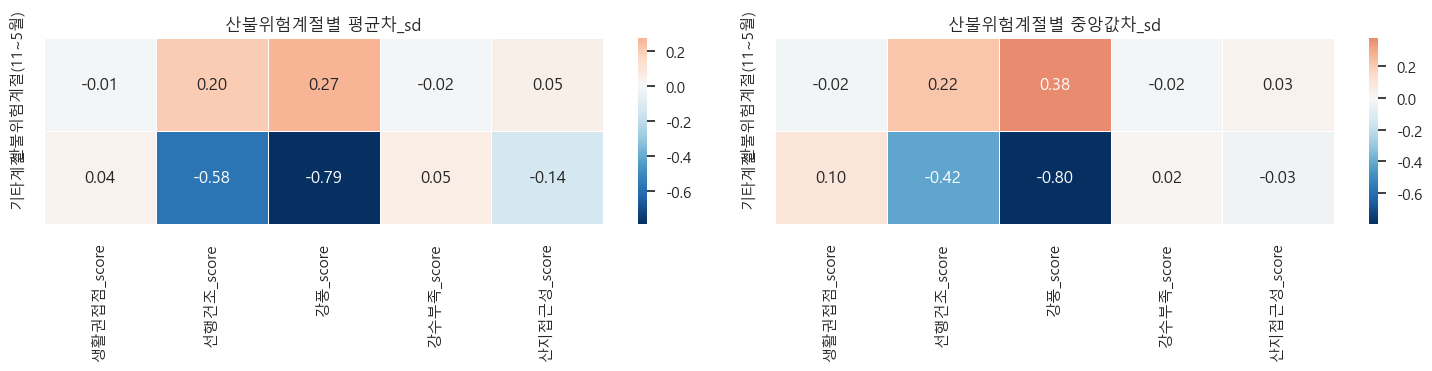

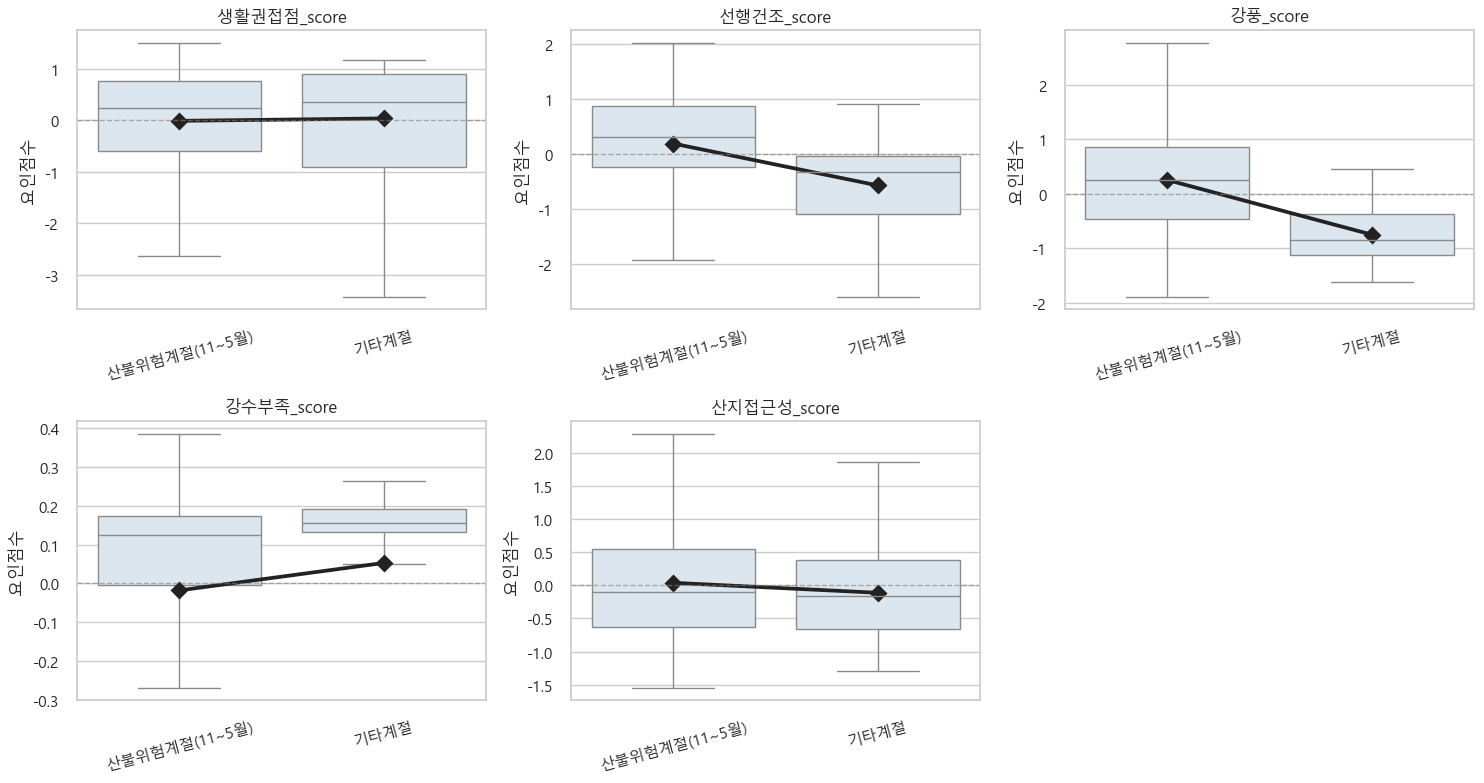

In [75]:
# 8-4-5. 산불위험계절별 요인점수 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))

sns.heatmap(
    fire_risk_season_summary_wide_mean,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("산불위험계절별 평균차_sd")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    fire_risk_season_summary_wide_median,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("산불위험계절별 중앙값차_sd")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

plot_df = seq4_meta_work.melt(
    id_vars=SEQ4_META_COL,
    value_vars=SEQ4_FACTOR_SCORE_COLS,
    var_name="요인점수",
    value_name="score",
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, score_col in enumerate(SEQ4_FACTOR_SCORE_COLS):
    ax = axes[idx]
    score_plot_df = plot_df[plot_df["요인점수"] == score_col].copy()
    sns.boxplot(
        data=score_plot_df,
        x=SEQ4_META_COL,
        y="score",
        order=seq4_group_order,
        ax=ax,
        color="#d9e6f2",
        showfliers=False,
    )
    sns.pointplot(
        data=score_plot_df,
        x=SEQ4_META_COL,
        y="score",
        order=seq4_group_order,
        ax=ax,
        color="#222222",
        markers="D",
        errorbar=None,
    )
    ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(score_col)
    ax.set_xlabel("")
    ax.set_ylabel("요인점수")
    ax.tick_params(axis="x", rotation=15)

for j in range(len(SEQ4_FACTOR_SCORE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 8-4 실행 결과 해석: 산불위험계절별 요인점수

`산불위험계절`은 공간 메타데이터와 달리 `강풍_score`와 `선행건조_score`에서 차이를 보인다. 다만 기대했던 것처럼 `선행건조_score`가 강한 핵심축으로 나타나기보다는, `강풍_score`의 계절 차이가 더 뚜렷하다. `생활권접점_score`와 `산지접근성_score`는 계절보다 8-1~8-3의 공간 메타데이터에서 해석하는 것이 적절하다.

분석 대상은 총 `n=2,670`이며, `산불위험계절(11~5월)`이 `1,992건(74.61%)`, `기타계절`이 `678건(25.39%)`이다.

| 산불위험계절 | n | 비율 |
| --- | ---: | ---: |
| `산불위험계절(11~5월)` | `1,992` | `0.7461` |
| `기타계절` | `678` | `0.2539` |

요인점수별 평균차와 중앙값차는 다음과 같다.

| 그룹 | 생활권접점 | 선행건조 | 강풍 | 강수부족 | 산지접근성 |
| --- | ---: | ---: | ---: | ---: | ---: |
| `산불위험계절(11~5월)` 평균차_sd | `-0.0126` | `+0.1965` | `+0.2690` | `-0.0184` | `+0.0466` |
| `산불위험계절(11~5월)` 중앙값차_sd | `-0.0198` | `+0.2172` | `+0.3768` | `-0.0155` | `+0.0349` |
| `기타계절` 평균차_sd | `+0.0369` | `-0.5773` | `-0.7903` | `+0.0541` | `-0.1369` |
| `기타계절` 중앙값차_sd | `+0.0976` | `-0.4197` | `-0.7968` | `+0.0171` | `-0.0329` |

가장 큰 차이는 `강풍_score`이다. `산불위험계절(11~5월)`은 평균차 `+0.2690sd`, 중앙값차 `+0.3768sd`로 높고, `기타계절`은 평균차 `-0.7903sd`, 중앙값차 `-0.7968sd`로 낮다. 두 그룹의 쌍별 평균차는 `+1.0593sd`, 중앙값차는 `+1.1736sd`, rank-biserial은 `+0.6592`이다. 따라서 산불위험계절에는 강풍 요인이 상대적으로 높게 나타난다. 다만 산불위험계절 자체의 평균차는 `+0.30sd` 기준에 약간 못 미치고 중앙값차는 넘기 때문에, 표현은 `강풍이 뚜렷하게 높다`보다는 `강풍 경향이 높다` 또는 `기타계절 대비 강풍 요인이 높다`가 더 정확하다.

`선행건조_score`도 계절 차이를 보이지만, 산불위험계절 단독 기준으로는 강한 수준까지는 아니다. `산불위험계절(11~5월)`은 평균차 `+0.1965sd`, 중앙값차 `+0.2172sd`이고, `기타계절`은 평균차 `-0.5773sd`, 중앙값차 `-0.4197sd`이다. 쌍별 평균차는 `+0.7738sd`, 중앙값차는 `+0.6369sd`, rank-biserial은 `+0.5371`이다. 즉 산불위험계절이 기타계절보다 건조한 방향으로 이동하는 것은 맞지만, 전체 평균 대비로는 `+0.30sd`를 넘지 않아 `산불위험계절 = 강한 선행건조형`으로 단정하기보다는 `기타계절 대비 선행건조가 높은 경향`으로 해석한다.

`강수부족_score`는 계절의 핵심 해석축이 아니다. `산불위험계절(11~5월)`은 평균차 `-0.0184sd`, 중앙값차 `-0.0155sd`이고, `기타계절`은 평균차 `+0.0541sd`, 중앙값차 `+0.0171sd`로 모두 매우 작다. Mann-Whitney p-value는 작지만, 이는 표본 수와 분포 차이의 영향으로 보이며 실제 효과는 작다. 강수 극단값은 `산불위험계절(11~5월)` 10건, `기타계절` 3건으로 비율도 각각 `0.0050`, `0.0044`로 거의 비슷하다. 극단값 제외 전후에도 중앙값 변화는 거의 없으므로, 계절별 강수부족 차이는 실질적으로 약하다.

`생활권접점_score`와 `산지접근성_score`는 계절로 설명되지 않는다. `생활권접점_score`는 산불위험계절 평균차 `-0.0126sd`, 기타계절 평균차 `+0.0369sd`로 차이가 거의 없다. `산지접근성_score`도 산불위험계절 평균차 `+0.0466sd`, 기타계절 평균차 `-0.1369sd`로 작다. 따라서 이 두 요인은 8-1~8-3에서 확인한 대로 `기후지형유형`, `기후지형_번지유형`, `addr_type` 같은 공간 메타데이터에서 해석하는 것이 맞다.

시각화도 같은 결론을 지지한다. `강풍_score` boxplot은 산불위험계절이 기타계절보다 위에 위치하고, 기타계절의 분포가 낮은 쪽에 몰린다. `선행건조_score`도 산불위험계절이 상대적으로 높지만 두 그룹의 분포 겹침은 존재한다. `강수부족_score`는 중앙값 차이가 거의 없고, `생활권접점_score`, `산지접근성_score`도 두 그룹이 크게 분리되지 않는다.

따라서 8-4의 결론은 다음과 같다.

- `산불위험계절`은 `강풍_score`와 `선행건조_score`를 일부 설명한다.
- 특히 `강풍_score`는 기타계절 대비 산불위험계절에서 높게 나타나며, 계절성 강풍 패턴으로 해석할 수 있다.
- `선행건조_score`는 기타계절보다 높지만 전체 평균 대비 강한 수준은 아니므로 보조 해석축으로 둔다.
- `강수부족_score`는 계절별 핵심 해석축으로 보기 어렵다.
- `생활권접점_score`, `산지접근성_score`는 계절보다 공간 메타데이터에서 해석해야 한다.
- 8-1~8-4를 종합하면, FA 요인점수 해석은 `공간축(생활권접점·산지접근성)`, `영동/계절 강풍축`, `보조적 선행건조축`으로 정리하는 것이 적절하다.

### 8-4 실행 후 해석 기준

실행 후에는 다음 순서로 해석한다.

- `선행건조_score`: 산불위험계절이 실제로 높은지 확인한다. 평균과 중앙값이 모두 `+0.30sd` 이상이면 계절성 건조 축으로 해석할 수 있다.
- `강풍_score`: 산불위험계절에서도 높게 나오면 계절-강풍 복합 패턴으로 해석하되, 8-1의 `영동 해안형` 효과와 구분한다.
- `강수부족_score`: 평균이 극단값에 의해 흔들리는지 `강수 극단값 제외 전후` 표로 확인한다.
- `생활권접점_score`, `산지접근성_score`: 차이가 약하면 공간 메타데이터에서 해석하는 것으로 정리한다.
- 8-4 이후에도 `선행건조_score`, `강수부족_score`가 약하면, 이 두 요인은 메타데이터보다 원 기상 시계열 자체에서 해석하는 축으로 정리한다.